# Электродинамический расчёт волнового двигателя с внутренним расходом энергии Ф.Ф.Менде (MenDrive)

А.Ю.Дроздов

опираясь на выкладки из параграфа 20 Электродинамики Зоммерфельда

рассчитаем тягу в

http://fmnauka.narod.ru/dvigatel_emdrive.pdf

Ф.Ф. МЕНДЕ, ВОЛНОВОЙ ДВИГАТЕЛЬ С ВНУТРЕННИМ РАСХОДОМ ЭНЕРГИИ ЭЛЕКТРОМАГНИТНЫХ КОЛЕБАНИЙ

геометрия задачи следующая: 

поверхность хорошего проводника $x<=-a$

вакуум внутри резонатора заполняет область $-a<=x<=a$

В области $x>a$ - плохой проводник

переходим к **более физической постановке задачи**, где вместо поиска комплексного $k_z$ при фиксированной частоте $\omega$ (как в `MenDrive_real`) ищем **комплексные собственные частоты** $\omega = \omega_r + i\omega_i$ при фиксированной геометрии ($L_z = \text{const}$). Это — **метод квазинормальных мод (QNMs)**, и он естественно включает потери, излучение и резонансную структуру.


1. **Корректные граничные условия** для резонатора с генератором (входом),  
2. **Четверть- и полуволновые режимы**,  
3. **Возбуждение через импедансную нагрузку** (моделирующую магнетрон/усилитель),



1. Где генератор излучения в граничных условиях?

В классической постановке **резонатор = замкнутая система**, и генератор — **внешний источник**, который обычно моделируется как:

- **Граничное условие третьего рода (импедансное)**:
  $$
  E_z(0) = Z \cdot H_y(0),\quad Z = Z_0 + i X
  $$
  где $Z_0$ — активная часть (потери в генераторе), $X$ — реактивная (настройка).

- Или как **негомогенное условие** (внешняя накачка):
  $$
  E_z(0) = E_0 e^{-i\omega t},\quad \text{(внешний источник)}
  $$
  — но тогда это **не собственная мода**, а вынужденные колебания.

→ В расчёте **собственных комплексных частот** генератор **не включается** — он нужен только для **возбуждения** одной из мод. А сама тяга определяется **формой моды** и **параметрами потерь в стенках** — как в вашем текущем расчёте.

 2. Четвертьволновой резонатор — как задать?

Для TM-моды ($E_z \ne 0$) в плоском резонаторе:

| Тип | Граничные условия | Физический смысл |
|-----|-------------------|------------------|
| **Полуволновой** | $E_z(0) = 0,\ E_z(L_z) = 0$ | Короткое замыкание на обоих концах (металлические крышки) |
| **Четвертьволновой** | $E_z(0) = 0,\ \partial_z E_z(L_z) = 0$ | Короткое замыкание слева, **разомкнутый конец** справа (high-Z, например, ферритовая заглушка или воздушный зазор) |

→ $\partial_z E_z = 0$ эквивалентно $H_y = 0$ (из уравнения $\partial_z E_z \propto H_y$), т.е. **магнитное поле = 0** → высокий импеданс.

---

### 🔹 3. Почему расчёт по $\omega$ лучше, чем по $k_z$?

| Параметр | Фиксировать $\omega$, искать $k_z$ | Фиксировать $L_z$, искать $\omega$ |
|----------|----------------------------------------|----------------------------------------|
| Подходит для | Бесконечных волноводов, распространение | Замкнутых резонаторов, экспериментов |
| Потери | $k_z = k_r + i k_i$ → затухание вдоль $z$ | $\omega = \omega_r - i \omega_i$ → затухание во времени |
| Q-фактор | $Q = \frac{k_r}{2|k_i|}$ (нестандартно) | $Q = \frac{\omega_r}{2|\omega_i|}$ — **физический смысл** |
| Тяга | Сложно связать с мощностью накачки | Прямо пропорциональна $\frac{F}{P} = \frac{F}{\omega_i U}$ |

→ Вычислять $\omega_n$ — **физически правильнее для резонатора**.


1. ✅ **аналитический вывод** дисперсионного уравнения $\det M(\omega) = 0$ при фиксированных $\varepsilon, \mu, \sigma_e, \sigma_m, L_z$,
2. ✅ Реализованы **три типа граничных условий**:
   - `BC = "half-wave"` → $E_z(0) = E_z(L_z) = 0$
   - `BC = "quarter-wave"` → $E_z(0) = 0,\ \partial_z E_z(L_z) = 0$
   - `BC = "impedance"` → $E_z(0) = Z H_y(0),\ E_z(L_z) = 0$
3. ✅ Будет **поиск первых 3 комплексных частот** методом Ньютона в $\mathbb{C}$,


In [1]:
from sage.all import RealField, ComplexField

# Create a SageMath RealField with high precision
complex128 = ComplexField(128)
real128    = RealField(128)

In [2]:
"""
MenDrive_QNM_v2.ipynb — расчёт по комплексной частоте ω
✅ k_z — вещественная переменная
✅ Режим по умолчанию: is_TE = True, is_TM = False
✅ Полное соответствие вашему выводу волнового уравнения
"""

import numpy as np

sgs = True

if sgs:
    c_d = real128(299792458 * 100)
    sigma_0_d = np.float128(9*10^9)
    mu_0_d = np.float128(1)
    epsilon_0_d = np.float128(1)
    sm = np.float128(1)
else:
    c_d         = real128(299792458)
    sigma_0_d   = np.float128(1)
    mu_0_d      = np.float128(4 * pi * 10^(-7))
    epsilon_0_d = np.float128(1/(4*pi*c_d^2) * 10^(+7))
    sm          = np.float128(0.01)

sm = np.float128(1)
# sgs
A = np.float128(0.5) * sm     # полуширина вакуума, см
# A = np.float128(0.18) * sm


B = np.float128(0.5) * sm     # полуширина в направлении игрек, см
B = np.float128(5.0) * sm     # полуширина в направлении игрек, см
y_step = np.float128(1.0) * sm
m_d = 0 # мода волны в направлении игрек (0,1,2,...)


L_z_d = real128(1000.0)                 # длина резонатора вдоль z, см
L_z_d = real128(10.0)                   # длина резонатора вдоль z, см

j0_ext_d = real128(1.0)    # амплитуда внешнего тока возбуждения

# Импеданс (активный + реактивный, можно настраивать)
# Z0_real_d = 50.0              # Ом, активная часть
# Z0_react_d = 0.0              # Ом, реактивная часть (0 → резистивная нагрузка)
# Z0_d = Z0_real_d + I * Z0_react_d # комплексный импеданс при x = 0

# на низких частотах ферриты обладают высокой относительной диэлектрической проницаемостью, примерно 10^5
#epsilon_l_d = real128(1000)
#epsilon_r_d = real128(100)

epsilon_l_xx_d = real128(1)
epsilon_r_xx_d = real128(4)
epsilon_r_xx_d = real128(16)

epsilon_l_yy_d = real128(1)
epsilon_r_yy_d = real128(16)

epsilon_l_zz_d = real128(1)
epsilon_r_zz_d = real128(16)

mu_l_xx_d = real128(1)
mu_r_xx_d = real128(1e+2)

mu_l_yy_d = real128(1)
mu_r_yy_d = real128(1e+2) #* 2

mu_l_zz_d = real128(1)
mu_r_zz_d = real128(1e+2) #* 2

mu_l_yz_d = real128(0)
mu_l_zy_d = real128(0)

# mu_r_yz_d = complex128(- I * 466)
# mu_r_zy_d = complex128(+ I * 466)

# mu_r_yz_d = real128(466)
# mu_r_zy_d = real128(466)

mu_r_yz_d = real128(0)
mu_r_zy_d = real128(0)


# https://ru.wikipedia.org/wiki/%D0%AD%D0%BB%D0%B5%D0%BA%D1%82%D1%80%D0%BE%D0%BF%D1%80%D0%BE%D0%B2%D0%BE%D0%B4%D0%BD%D0%BE%D1%81%D1%82%D1%8C
# В системе СИ удельная электропроводность измеряется в сименсах на метр (См/м) или в Ом−1·м−1.
# В СГСЭ единицей удельной электропроводности является обратная секунда (с−1).
# серебро    62 500 000
# медь       59 500 000
# константан  2 000 000

# См/м
# 1 См = 1 / Ом

sigma_e_l_d = real128(62500000 * (9*10^9))
sigma_e_r_d = real128(1100     * (9*10^9))

#sigma_e_l_d = sigma_e_l_d / 100000
#sigma_e_r_d = sigma_e_r_d / 100000

#sigma_e_l_d = real128(1000)*1000*1000
#sigma_e_r_d = real128(1000)



sigma_m_l_d = real128(0)
# sigma_m_r_d = real128(10 * (9*10^9))
sigma_m_r_d = real128(0.0072 * (9*10^9))


sigma_e_l_xx_d = sigma_e_l_d
sigma_e_r_xx_d = sigma_e_r_d

sigma_e_l_yy_d = sigma_e_l_d
sigma_e_r_yy_d = sigma_e_r_d #* 10

sigma_e_l_zz_d = sigma_e_l_d
sigma_e_r_zz_d = sigma_e_r_d #* 10

sigma_m_l_xx_d = sigma_m_l_d
sigma_m_r_xx_d = sigma_m_r_d

sigma_m_l_yy_d = sigma_m_l_d
sigma_m_r_yy_d = sigma_m_r_d #* 10

sigma_m_l_zz_d = sigma_m_l_d
sigma_m_r_zz_d = sigma_m_r_d #* 10

#lambda_d = real128(632*100*10^-9) * sm
# 632 nm

#lambda_d = real128(632*100*10^-6) * sm
# 0.632 mm

#lambda_d = real128(632*100*10^-4*1000) * sm
# 63.2 mm
# 6.32 sm

c_d = real128(299792458 * 100)

# if False:
#     lambda_d = real128(632*100*10^-4*1000*5 * sm)
#     omega_d  = ((real128(2*pi) * c_d) / lambda_d)
# else:
#     omega_d  = real128(1.00e+7)
#     #omega_d  = real128(2*pi*7957747)
#     #omega_d  = real128(2*pi*79577)
#     lambda_d = ((real128(2*pi) * c_d) / omega_d )
# lambda_d, omega_d

In [3]:
is_TM = False
is_TE = True
is_4x4 = True

In [4]:
use_old_solver = True

In [5]:
from IPython.display import display, Math, Latex

def disp_sp(ex):
    from sympy import latex as sp_latex
    display(Math(sp_latex(ex._sympy_())))

def disp(ex):
    try:
        display(Math(latex(ex)))
    except:
        # print(ex)
        disp_sp(ex)
    
def displ(tex):
    display(Math(tex))

mu_l_zy_c = var('mu_l_zy_c')
mu_l_yz_c = var('mu_l_yz_c')

mu_r_xx_c = var('mu_r_xx_c')
mu_r_yy_c = var('mu_r_yy_c')
mu_r_zz_c = var('mu_r_zz_c')

mu_l_xx_c = var('mu_l_xx_c')
mu_l_yy_c = var('mu_l_yy_c')
mu_l_zz_c = var('mu_l_zz_c')

assume(mu_l_xx_c, 'complex')
assume(mu_l_yy_c, 'complex')
assume(mu_l_zz_c, 'complex')

mu_l_xx = var('mu_l_xx')
mu_l_yy = var('mu_l_yy')
mu_l_zz = var('mu_l_zz')

assume(mu_l_xx, 'real')
assume(mu_l_yy, 'real')
assume(mu_l_zz, 'real')

assume(mu_l_xx>0)
assume(mu_l_yy>0)
assume(mu_l_zz>0)

mu_r_xx = var('mu_r_xx')
mu_r_yy = var('mu_r_yy')
mu_r_zz = var('mu_r_zz')

assume(mu_r_xx, 'real')
assume(mu_r_yy, 'real')
assume(mu_r_zz, 'real')

assume(mu_r_xx>0)
assume(mu_r_yy>0)
assume(mu_r_zz>0)

mu_r_zy_c = var('mu_r_zy_c')
mu_r_yz_c = var('mu_r_yz_c')

epsilon_l_xx_c = var('epsilon_l_xx_c')
epsilon_l_yy_c = var('epsilon_l_yy_c')
epsilon_l_zz_c = var('epsilon_l_zz_c')

assume(epsilon_l_xx_c, 'complex')
assume(epsilon_l_yy_c, 'complex')
assume(epsilon_l_zz_c, 'complex')

epsilon_l_xx = var('epsilon_l_xx')
epsilon_l_yy = var('epsilon_l_yy')
epsilon_l_zz = var('epsilon_l_zz')

assume(epsilon_l_xx, 'real')
assume(epsilon_l_yy, 'real')
assume(epsilon_l_zz, 'real')

assume(epsilon_l_xx>0)
assume(epsilon_l_yy>0)
assume(epsilon_l_zz>0)

epsilon_r_xx_c = var('epsilon_r_xx_c')
epsilon_r_yy_c = var('epsilon_r_yy_c')
epsilon_r_zz_c = var('epsilon_r_zz_c')

assume(epsilon_r_xx_c, 'complex')
assume(epsilon_r_yy_c, 'complex')
assume(epsilon_r_zz_c, 'complex')

epsilon_r_xx = var('epsilon_r_xx')
epsilon_r_yy = var('epsilon_r_yy')
epsilon_r_zz = var('epsilon_r_zz')

assume(epsilon_r_xx, 'real')
assume(epsilon_r_yy, 'real')
assume(epsilon_r_zz, 'real')

assume(epsilon_r_xx>0)
assume(epsilon_r_yy>0)
assume(epsilon_r_zz>0)

epsilon_r_xy_c = var('epsilon_r_xy_c')
epsilon_r_yx_c = var('epsilon_r_yx_c')

epsilon_r_xz_c = var('epsilon_r_xz_c')
epsilon_r_zx_c = var('epsilon_r_zx_c')

epsilon_r_zy_c = var('epsilon_r_zy_c')
epsilon_r_yz_c = var('epsilon_r_yz_c')

mu_0 = var("mu_0")
assume(mu_0, "real")
assume(mu_0>0)

epsilon_0 = var("epsilon_0")
assume(epsilon_0, "real")
assume(epsilon_0>0)

# sigma_0 = var("sigma_0")
# assume(sigma_0, "real")
# assume(sigma_0>0)

# left conductor
sigma_e_l_xx = var('sigma_e_l_xx')
sigma_e_l_yy = var('sigma_e_l_yy')
sigma_e_l_zz = var('sigma_e_l_zz')

assume(sigma_e_l_xx, 'real')
assume(sigma_e_l_yy, 'real')
assume(sigma_e_l_zz, 'real')

assume(sigma_e_l_xx>0)
assume(sigma_e_l_yy>0)
assume(sigma_e_l_zz>0)

# left conductor
sigma_m_l_xx = var('sigma_m_l_xx')
sigma_m_l_yy = var('sigma_m_l_yy')
sigma_m_l_zz = var('sigma_m_l_zz')

assume(sigma_m_l_xx, 'real')
assume(sigma_m_l_yy, 'real')
assume(sigma_m_l_zz, 'real')

assume(sigma_m_l_xx>0)
assume(sigma_m_l_yy>0)
assume(sigma_m_l_zz>0)

#right conductor
sigma_e_r_xx = var('sigma_e_r_xx')
sigma_e_r_yy = var('sigma_e_r_yy')
sigma_e_r_zz = var('sigma_e_r_zz')

assume(sigma_e_r_xx, 'real')
assume(sigma_e_r_yy, 'real')
assume(sigma_e_r_zz, 'real')

assume(sigma_e_r_xx>0)
assume(sigma_e_r_yy>0)
assume(sigma_e_r_zz>0)

#right conductor
sigma_m_r_xx = var('sigma_m_r_xx')
sigma_m_r_yy = var('sigma_m_r_yy')
sigma_m_r_zz = var('sigma_m_r_zz')

assume(sigma_m_r_xx, 'real')
assume(sigma_m_r_yy, 'real')
assume(sigma_m_r_zz, 'real')

assume(sigma_m_r_xx>0)
assume(sigma_m_r_yy>0)
assume(sigma_m_r_zz>0)



kappa_vacuum = var ('kappa_vacuum')
assume(kappa_vacuum, 'real')
assume(kappa_vacuum>0)

# left conductor
kappa_l = var('kappa_l')
assume(kappa_l, 'complex')

# right conductor
kappa_r = var('kappa_r')
assume(kappa_r, 'complex')

k_y_E = var ('k_y_E')
assume(k_y_E, 'real')

k_y_H = var ('k_y_H')
assume(k_y_H, 'real')

# Импеданс (активный + реактивный, можно настраивать)
# Z0_real  = var("Z0_real",  domain='real')              # Ом, активная часть
# Z0_react = var("Z0_react", domain='real')              # Ом, реактивная часть (0 → резистивная нагрузка)
# Z0 = Z0_real + I * Z0_react # комплексный импеданс при x = 0

a = var('a')
assume(a, 'real')
assume(a>0)

x = var('x')
y = var('y')
z = var('z')

assume(x, 'real')
assume(y, 'real')
assume(z, 'real')

c = var('c')
assume(c, 'real')
assume(c>0)

# K_vacuum = sqrt(kappa_vacuum^2-k_z^2)
# K_conductor = sqrt(kappa^2-k_z^2)

# K_vacuum    = var("K_vacuum", domain='complex')
# K_left_conductor = var("K_left_conductor", domain='complex')
# K_right_conductor = var("K_right_conductor", domain='complex')

In [6]:
# K_vacuum = sqrt(kappa_vacuum^2-k_z^2)
# K_conductor = sqrt(kappa^2-k_z^2)

K_E_vacuum = var("K_E_vacuum")
K_H_vacuum = var("K_H_vacuum")
K_E_left_conductor = var("K_E_left_conductor")
K_H_left_conductor = var("K_H_left_conductor")
K_E_right_conductor = var("K_E_right_conductor")
K_H_right_conductor = var("K_H_right_conductor")

In [7]:
L_z =  var("L_z", domain='real')        # длина резонатора вдоль z, см
omega = var('omega', domain='complex')  # частота в общем виде
                                        # применяется до подстановки
                                        # для решения в общем виде обеих задач: QNM и drive
omega_drive = var('omega_drive', domain='real') # частота возбуждения
omega_re = var("omega_re", domain='real')       # компоненты комплексной частоты в задаче QNM
omega_im = var("omega_im", domain='real')       # компоненты комплексной частоты в задаче QNM
resonator_type = "quarter"  # ← "quarter", "half", "impedance"

# ======================================================
# 1. Продольное волновое число k_z (вещественное при резонансе)
# ======================================================
k_z = var('k_z', domain='real')

k_y = var ('k_y')
assume(k_y, 'complex')

if resonator_type == "quarter":
    # Четвертьволновой резонатор:
    #   — закорочен на x = -A (E_z = 0 при TM, H_z = 0 при TE),
    #   — разомкнут на x = +A (∂_z E_z = 0 ⇔ H_y = 0 при TM, ∂_z H_z = 0 ⇔ E_y = 0 при TE).
    # → k_z = π / (2 L_z) — фундаментальный режим.
    k_z_val = pi / (2 * L_z)
    print(f"k_z = π/(2L_z) = {k_z_val} см⁻¹")

elif resonator_type == "half":
    # Полуволновой резонатор:
    #   — закорочен на обоих концах (E_z = 0 при TM, H_z = 0 при TE).
    # → k_z = π / L_z — фундаментальный режим.
    k_z_val = pi / L_z
    print(f"k_z = π/L_z = {k_z_val} см⁻¹")

elif resonator_type == "impedance":
    # Импедансный резонатор:
    #   — на x = -A: закорочено (E_z = 0 / H_z = 0),
    #   — на x = +A: нагрузка Z0 (E_z = Z0 * H_y при TM и т.п.).
    # → k_z — **не фиксировано**, ищется из det(M) = 0.
    k_z_val = None  # будет оптимизироваться
    print("k_z — не фиксировано, определяется из резонансного условия det(M)=0.")

else:
    raise ValueError("Неверный тип резонатора: выберите 'quarter', 'half' или 'impedance'.")


k_z = π/(2L_z) = 1/2*pi/L_z см⁻¹


In [8]:
k_z_val

1/2*pi/L_z

In [9]:
is_cos_y_TM = True
is_cos_y_TE = False
use_phase_y = True

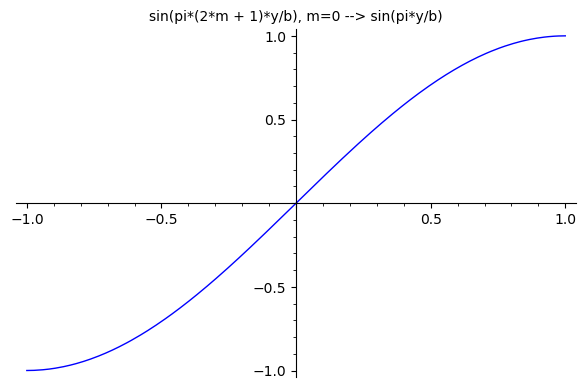

In [10]:
var("m b y")
ky_TE_sin = (2*m+1)*pi/(2*b)
ky_TE_cos = (2*m+1)*pi/(b)
TE_Hz_sin = sin(ky_TE_sin*y)
TE_Hz_cos = cos(ky_TE_cos*y)
if is_TE:
    b_val = 1
    for m_val in [m_d]:
        if not is_cos_y_TE:
            plot(TE_Hz_sin.subs(b == b_val, m == m_val), y, -b_val, b_val).show(
                title=f"sin({ky_TE_cos*y}), m={m_val} --> sin({ky_TE_cos.subs(m==m_val)*y})")
        else:
            plot(TE_Hz_cos.subs(b == b_val, m == m_val), y, -b_val, b_val).show(
                title=f"cos({ky_TE_cos*y}), m={m_val} --> cos({ky_TE_cos.subs(m==m_val)*y})")

In [11]:
var("m b y")
ky_TM_cos = (1+2*m)*pi/(2*b)
ky_TM_sin = (1+m)*pi/(b)
TM_Ez_cos = cos(ky_TM_cos*y)
TM_Ez_sin = sin(ky_TM_sin*y)
if is_TM:
    b_val = 1
    for m_val in [m_d]:
        if not is_cos_y_TM:
            plot(TM_Ez_cos.subs(b == b_val, m == m_val), y, -b_val, b_val).show(
                title=f"cos({ky_TM_cos*y}), m={m_val} --> cos({ky_TM_cos.subs(m==m_val)*y})")
        else:
            plot(TM_Ez_sin.subs(b == b_val, m == m_val), y, -b_val, b_val).show(
                title=f"sin({ky_TM_sin*y}), m={m_val} --> sin({ky_TM_cos.subs(m==m_val)*y})")

In [12]:
if is_TM or True:
    if is_cos_y_TM:
        phase_y_TM = TM_Ez_cos
        phase_y_TM = cos(ky_TM_cos*y)
        phase_y_TM = cos(k_y_E*y)
    else:
        phase_y_TM = TM_Ez_sin
        phase_y_TM = sin(ky_TM_sin*y)
        phase_y_TM = sin(k_y_E*y)
if is_TE or True:
    if is_cos_y_TE:
        phase_y_TE = TE_Hz_cos
        phase_y_TE = cos(ky_TE_cos*y)
        phase_y_TE = cos(k_y_H*y)
    else:
        phase_y_TE = TE_Hz_sin
        phase_y_TE = sin(ky_TE_sin*y)
        phase_y_TE = sin(k_y_H*y)

In [13]:
# отсутствие изменения поля вдоль оси y
# no field variation along the y axis
#k_re_im_subs = [k_z == kz + I * sz]
k_subs = [k_z == k_z_val]
if False:
    if is_TM or True:
        if is_cos_y_TM:
            k_subs += [k_y_E == ky_TM_cos]
        else:
            k_subs += [k_y_E == ky_TM_sin]
    if is_TE or True:
        if is_cos_y_TE:
            k_subs += [k_y_H == ky_TE_cos]
        else:
            k_subs += [k_y_H == ky_TE_sin]
else:
    # старый режим рассчета когда поле не зависит от y
    k_subs += [k_y_E == 0]
    k_subs += [k_y_H == 0]
    phase_y_TE = 1
    phase_y_TM = 1
    # B = 1
k_subs

[k_z == 1/2*pi/L_z, k_y_E == 0, k_y_H == 0]

In [14]:
# --- Символьное представление j_ext ---
# j_ext_y_sym(x) — символьная функция, зависящая от x
# Её профиль задаём позже при подстановке числовых значений

j_ext_amplitude = var('j0_ext', domain='complex')   # амплитуда внешнего тока [СГС: с⁻¹]
j_ext_y_op = function('j_ext_y')                    # оператор функции внешнего тока
j_ext_y_sym = j_ext_y_op(x)                         # символьная функция от x внешнего тока

# Конкретный профиль (подставляется при численных расчётах):
# было:
# j_ext_y_profile(x) = j0_ext * exp(-I * K_left_conductor * (x + a))
# стало (источник несёт тот же y-профиль, что и поля -> mode-matched):
if is_TE:
    j_ext_y_profile(x) = j0_ext * exp(-I * K_H_left_conductor * (x + a)) * phase_y_TE

# т.е. тот же скин-профиль, что и у собственной моды

In [15]:
c_sgs_value       = [ c == c_d]
# c_sgns_value      = [ c == real128(299792458 * 100 * 1e-9)]
# omega_value       = [ omega  == omega_d ]
# omega_value       = [ omega  == ((real128(2*pi) * c)/ lambda_d).subs (c_sgns_value) ]
# kz_subs          = [k_z == k_z_val]
Lz_value          = [L_z == L_z_d]
digit_values_init = [a == real128(A),
                     k_y == 0,
                     mu_l_xx == mu_l_xx_d,
                     mu_l_yy == mu_l_yy_d,
                     mu_l_zz == mu_l_zz_d,

                     mu_r_xx == mu_r_xx_d,
                     mu_r_yy == mu_r_yy_d,
                     mu_r_zz == mu_r_zz_d,

                     mu_l_yz_c == mu_l_yz_d,
                     mu_l_zy_c == mu_l_zy_d,

                     mu_r_yz_c == mu_r_yz_d,
                     mu_r_zy_c == mu_r_zy_d,

                     sigma_e_l_xx == sigma_e_l_xx_d,
                     sigma_e_l_yy == sigma_e_l_yy_d,
                     sigma_e_l_zz == sigma_e_l_zz_d,

                     sigma_e_r_xx == sigma_e_r_xx_d, 
                     sigma_e_r_yy == sigma_e_r_yy_d, 
                     sigma_e_r_zz == sigma_e_r_zz_d, 

                     sigma_m_l_xx == sigma_m_l_xx_d,
                     sigma_m_l_yy == sigma_m_l_yy_d,
                     sigma_m_l_zz == sigma_m_l_zz_d,

                     sigma_m_r_xx == sigma_m_r_xx_d, 
                     sigma_m_r_yy == sigma_m_r_yy_d, 
                     sigma_m_r_zz == sigma_m_r_zz_d,

                     epsilon_l_xx == epsilon_l_xx_d,
                     epsilon_l_yy == epsilon_l_yy_d,
                     epsilon_l_zz == epsilon_l_zz_d,

                     epsilon_r_xx == epsilon_r_xx_d,
                     epsilon_r_yy == epsilon_r_yy_d,
                     epsilon_r_zz == epsilon_r_zz_d,
                    ] + c_sgs_value

In [16]:
# толщина проводника
h_conductor_l = float(0.000375*A)
h_conductor_r = float(0.0125*A)

$$\kappa^2 = \epsilon \mu \frac{\omega^2}{c^2} + i\,\omega\,\sigma\,\mu\,\frac{4\pi}{c^2}$$

$$\kappa^2 = \mu \left(\epsilon  + i\,\frac{4\pi\,\sigma}{\omega} \right) \frac{\omega^2}{c^2}$$

In [17]:
# исходя из вида дифференциальных уравнений для вакуума внутри резонатора и проводящего металла с потерями
# записываем соотнощения для волнового вектора в виде уравнений
eq_kappa_inner_vacuum = kappa_vacuum^2 == omega^2 / c^2

print("eq_kappa_inner_vacuum =")
display(Math(latex(eq_kappa_inner_vacuum)))

eq_kappa_inner_vacuum =


<IPython.core.display.Math object>

принимая модель комплексного представления диэлектрической проницаемости $\epsilon' = \epsilon + \frac{4\pi\,\sigma}{\omega}\,i$ (плохой проводник)

In [18]:
# Тензор epsilon'
epsilon_l_c = matrix([
    [epsilon_l_xx_c,               0,              0],
    [             0,  epsilon_l_yy_c,              0],
    [             0,               0, epsilon_l_zz_c]
])

show(epsilon_l_c)

[epsilon_l_xx_c              0              0]
[             0 epsilon_l_yy_c              0]
[             0              0 epsilon_l_zz_c]

In [19]:
# Тензор epsilon'
epsilon_r_c = matrix([
    [epsilon_r_xx_c,               0,              0],
    [             0,  epsilon_r_yy_c,              0],
    [             0,               0, epsilon_r_zz_c]
])

show(epsilon_r_c)

[epsilon_r_xx_c              0              0]
[             0 epsilon_r_yy_c              0]
[             0              0 epsilon_r_zz_c]

In [20]:
mu_l_c = matrix([
    [mu_l_xx_c,   0,               0        ],
    [0,           mu_l_yy_c,       0        ],
    [0,           0,               mu_l_zz_c],
])
show(mu_l_c)

[mu_l_xx_c         0         0]
[        0 mu_l_yy_c         0]
[        0         0 mu_l_zz_c]

In [21]:
mu_r_c = matrix([
    [mu_r_xx_c,   0,               0        ],
    [0,           mu_r_yy_c,       0        ],
    [0,           0,               mu_r_zz_c],
])
show(mu_r_c)

[mu_r_xx_c         0         0]
[        0 mu_r_yy_c         0]
[        0         0 mu_r_zz_c]

In [22]:
epsilon_l_xx_complex = epsilon_l_xx + I * 4 * pi * sigma_e_l_xx / omega
epsilon_l_yy_complex = epsilon_l_yy + I * 4 * pi * sigma_e_l_yy / omega
epsilon_l_zz_complex = epsilon_l_zz + I * 4 * pi * sigma_e_l_zz / omega

epsilon_r_xx_complex = epsilon_r_xx + I * 4 * pi * sigma_e_r_xx / omega
epsilon_r_yy_complex = epsilon_r_yy + I * 4 * pi * sigma_e_r_yy / omega
epsilon_r_zz_complex = epsilon_r_zz + I * 4 * pi * sigma_e_r_zz / omega

In [23]:
epsilon_mu_subs = [epsilon_l_zz_c == epsilon_l_zz_complex,
                   epsilon_l_yy_c == epsilon_l_yy_complex,
                   epsilon_l_xx_c == epsilon_l_xx_complex,
                   epsilon_r_zz_c == epsilon_r_zz_complex,
                   epsilon_r_yy_c == epsilon_r_yy_complex,
                   epsilon_r_xx_c == epsilon_r_xx_complex,
                  ]

принимая модель комплексного представления магнитной проницаемости $\mu' = \mu + \frac{4\pi\,\sigma_m}{\omega}\,i$ (магнитный проводник)

In [24]:
mu_l_xx_complex = mu_l_xx + I * 4 * pi * sigma_m_l_xx / omega
mu_l_yy_complex = mu_l_yy + I * 4 * pi * sigma_m_l_yy / omega
mu_l_zz_complex = mu_l_zz + I * 4 * pi * sigma_m_l_zz / omega

mu_r_xx_complex = mu_r_xx + I * 4 * pi * sigma_m_r_xx / omega
mu_r_yy_complex = mu_r_yy + I * 4 * pi * sigma_m_r_yy / omega
mu_r_zz_complex = mu_r_zz + I * 4 * pi * sigma_m_r_zz / omega

In [25]:
epsilon_mu_subs += [
    mu_l_zz_c == mu_l_zz_complex,
    mu_l_yy_c == mu_l_yy_complex,
    mu_l_xx_c == mu_l_xx_complex,
    mu_r_zz_c == mu_r_zz_complex,
    mu_r_yy_c == mu_r_yy_complex,
    mu_r_xx_c == mu_r_xx_complex,
]

$${k'_z}^2=\left(k_z + i\,s_z \right)^2 = k_z^2 - s_z^2 + 2\,i\,k_z\,s_z$$

зависимость поля от $y$ отсутствует

In [26]:
B_E_zl = var ('B_E_zl')
B_H_zl = var ('B_H_zl')

B_E_zr = var ('B_E_zr')
B_H_zr = var ('B_H_zr')

A1_E_z = var ('A1_E_z')
A2_E_z = var ('A2_E_z')
A1_H_z = var ('A1_H_z')
A2_H_z = var ('A2_H_z')

A1_E_z_re = var("A1_E_z_re")
A1_E_z_im = var("A1_E_z_im")
A1_H_z_re = var("A1_H_z_re")
A1_H_z_im = var("A1_H_z_im")

A2_E_z_re = var("A2_E_z_re")
A2_E_z_im = var("A2_E_z_im")
A2_H_z_re = var("A2_H_z_re")
A2_H_z_im = var("A2_H_z_im")

B_E_zl_re = var("B_E_zl_re")
B_E_zl_im = var("B_E_zl_im")
B_H_zl_re = var("B_H_zl_re")
B_H_zl_im = var("B_H_zl_im")

B_E_zr_re = var("B_E_zr_re")
B_E_zr_im = var("B_E_zr_im")
B_H_zr_re = var("B_H_zr_re")
B_H_zr_im = var("B_H_zr_im")

assume(A1_E_z, "complex")
assume(A1_H_z, "complex")

assume(A1_E_z_re, "real")
assume(A1_E_z_im, "real")
assume(A1_H_z_re, "real")
assume(A1_H_z_im, "real")

assume(A2_E_z, "complex")
assume(A2_H_z, "complex")

assume(A2_E_z_re, "real")
assume(A2_E_z_im, "real")
assume(A2_H_z_re, "real")
assume(A2_H_z_im, "real")

assume(B_E_zl, "complex")
assume(B_H_zl, "complex")

assume(B_E_zl_re, "real")
assume(B_E_zl_im, "real")
assume(B_H_zl_re, "real")
assume(B_H_zl_im, "real")

assume(B_E_zr, "complex")
assume(B_H_zr, "complex")

assume(B_E_zr_re, "real")
assume(B_E_zr_im, "real")
assume(B_H_zr_re, "real")
assume(B_H_zr_im, "real")

A1_z_re_im_subs   = []
A2_z_re_im_subs   = []

B_zl_re_im_subs   = []
B_zr_re_im_subs   = []

In [27]:
coefs_re_im_subs = []

# отсутствие изменения поля вдоль оси y
# no field variation along the y axis
# k_re_im_subs = [k_z == kz + I * sz, k_y == 0]

# k_subs = [k_z == k_z_val, k_y_E == 0, k_y_H == 0]
omega_qnm_subs = [omega == omega_re + I * omega_im]
omega_drive_subs = [omega == omega_re]

In [28]:
E_inner_vacuum_f_z = function("E_inner_vacuum_f_z")
E_left_conductor_f_z = function("E_left_conductor_f_z")
E_right_conductor_f_z = function("E_right_conductor_f_z")

E_inner_vacuum_f_x = function("E_inner_vacuum_f_x")
E_left_conductor_f_x = function("E_left_conductor_f_x")
E_right_conductor_f_x = function("E_right_conductor_f_x")

E_inner_vacuum_f_y = function("E_inner_vacuum_f_y")
E_left_conductor_f_y = function("E_left_conductor_f_y")
E_right_conductor_f_y = function("E_right_conductor_f_y")

E_inner_vacuum_fxy_x = function("E_inner_vacuum_fxy_x")(x,y)
E_left_conductor_fxy_x = function("E_left_conductor_fxy_x")(x,y)
E_right_conductor_fxy_x = function("E_right_conductor_fxy_x")(x,y)

E_inner_vacuum_fxy_y = function("E_inner_vacuum_fxy_y")(x,y)
E_left_conductor_fxy_y = function("E_left_conductor_fxy_y")(x,y)
E_right_conductor_fxy_y = function("E_right_conductor_fxy_y")(x,y)

In [29]:
H_inner_vacuum_f_x    = function("H_inner_vacuum_f_x")
H_left_conductor_f_x  = function("H_left_conductor_f_x")
H_right_conductor_f_x = function("H_right_conductor_f_x")

H_inner_vacuum_f_y    = function("H_inner_vacuum_f_y")
H_left_conductor_f_y  = function("H_left_conductor_f_y")
H_right_conductor_f_y = function("H_right_conductor_f_y")

H_inner_vacuum_f_z      = function("H_inner_vacuum_f_z")
H_left_conductor_f_z    = function("H_left_conductor_f_z")
H_right_conductor_f_z   = function("H_right_conductor_f_z")

H_inner_vacuum_fxy_x    = function("H_inner_vacuum_fxy_x")(x,y)
H_left_conductor_fxy_x  = function("H_left_conductor_fxy_x")(x,y)
H_right_conductor_fxy_x = function("H_right_conductor_fxy_x")(x,y)

H_inner_vacuum_fxy_y    = function("H_inner_vacuum_fxy_y")(x,y)
H_left_conductor_fxy_y  = function("H_left_conductor_fxy_y")(x,y)
H_right_conductor_fxy_y = function("H_right_conductor_fxy_y")(x,y)


#if is_TE:
H_inner_vacuum_fxy_z    = H_inner_vacuum_f_z(x) * phase_y_TE
H_left_conductor_fxy_z  = H_left_conductor_f_z(x) * phase_y_TE
H_right_conductor_fxy_z = H_right_conductor_f_z(x) * phase_y_TE

#if is_TM:
E_inner_vacuum_fxy_z    = E_inner_vacuum_f_z(x) * phase_y_TM
E_left_conductor_fxy_z  = E_left_conductor_f_z(x) * phase_y_TM
E_right_conductor_fxy_z = E_right_conductor_f_z(x) * phase_y_TM

In [30]:
# выражения для электрического поля
# в вакууме внутри резонатора

# знак перед корнем (K_vacuum) будем выбирать всегда так
# чтобы корень имел положительную мнимую часть

if is_TM:
    E_inner_vacuum_sol_z (x) = (A1_E_z*exp(- I * K_E_vacuum*x) + A2_E_z*exp( I * K_E_vacuum*x)) # * phase_y_TM

    if is_4x4:
        H_inner_vacuum_sol_z (x) = 0

    print ("E_inner_vacuum_sol_z (x) ")
    display(Math(latex(E_inner_vacuum_sol_z (x))))
    
if is_TE:
    H_inner_vacuum_sol_z (x) = (A1_H_z*exp(- I * K_H_vacuum*x) + A2_H_z*exp( I * K_H_vacuum*x)) # * phase_y_TE

    if is_4x4:
        E_inner_vacuum_sol_z (x) = 0

    print ("H_inner_vacuum_sol_z (x) ")
    display(Math(latex(H_inner_vacuum_sol_z (x))))

H_inner_vacuum_sol_z (x) 


<IPython.core.display.Math object>

решение для проводящего металла с потерями

для TМ волны

$\vec{E} = \vec{E}\,e^{i\,k_x'\,x}\,e^{i\,k_z\,z}\,e^{-i\,\omega\,t}$

$k_x' = k_x + i\,s_x$

$\vec{E} = \vec{E}\,e^{-s_x\,x}\,e^{i\,k_x\,x}\,e^{i\,k_z\,z}\,e^{-i\,\omega\,t}$


для TE волны

$\vec{H} = \vec{H}\,e^{i\,k_x'\,x}\,e^{i\,k_z\,z}\,e^{-i\,\omega\,t}$

$k_x' = k_x + i\,s_x$

$\vec{H} = \vec{H}\,e^{-s_x\,x}\,e^{i\,k_x\,x}\,e^{i\,k_z\,z}\,e^{-i\,\omega\,t}$


In [31]:
# знак перед корнем корнем будем всегда выбирать так,
# чтобы корень имел положительнею мнимую часть
# (Зоммерфельд, Электродинамика, параграф 20, Б.
# Волновое поле и скин-эффект в полупространстве)
sign_K_E_l = var("sign_K_E_l")
sign_K_E_r = var("sign_K_E_r")
sign_K_H_l = var("sign_K_H_l")
sign_K_H_r = var("sign_K_H_r")

In [32]:
# x > a-{k'_x}^{2}-{k'_y}^{2} +
# в проводящем металле с потерями

# знак перед корнем будем выбирать всегда так
# чтобы корень имел положительную мнимую часть

if is_TM:
    E_left_conductor_sol_z (x) = (B_E_zl*exp(-I * sign_K_E_l * K_E_left_conductor*(x+a))) # * phase_y_TM

    if is_4x4:
        H_left_conductor_sol_z (x) = 0

    print ("E_left_conductor_sol_z (x) ")
    display(Math(latex(E_left_conductor_sol_z (x))))

if is_TE:
    H_left_conductor_sol_z (x) = (B_H_zl*exp(-I * sign_K_H_l * K_H_left_conductor*(x+a))) # * phase_y_TE

    if is_4x4:
        E_left_conductor_sol_z (x) = 0

    print ("H_left_conductor_sol_z (x) ")
    display(Math(latex(H_left_conductor_sol_z (x))))

H_left_conductor_sol_z (x) 


<IPython.core.display.Math object>

In [33]:
# x > a-{k'_x}^{2}-{k'_y}^{2} +
# в проводящем металле с потерями

# знак перед корнем будем выбирать всегда так
# чтобы корень имел положительную мнимую часть

if is_TM:
    E_right_conductor_sol_z (x) = (B_E_zr*exp(+I * sign_K_E_r * K_E_right_conductor*(x-a))) # * phase_y_TM

    if is_4x4:
        H_right_conductor_sol_z (x) = 0

    print ("E_right_conductor_sol_z (x) ")
    display(Math(latex(E_right_conductor_sol_z (x))))

if is_TE:
    H_right_conductor_sol_z (x) = (B_H_zr*exp(+I * sign_K_H_r * K_H_right_conductor*(x-a))) # * phase_y_TE

    if is_4x4:
        E_right_conductor_sol_z (x) = 0

    print ("H_right_conductor_sol_z (x) ")
    display(Math(latex(H_right_conductor_sol_z (x))))

H_right_conductor_sol_z (x) 


<IPython.core.display.Math object>

In [34]:
# выражения для магнитного поля в вакууме внутри резонатора и в проводящем металле с потерями
# rot E = -1/c dB/dt
# rot_E_x = diff(E_z, y) - diff(E_y, z)
# rot_E_y = diff(E_x, z) - diff(E_z, x)
# rot_E_z = diff(E_y, x) - diff(E_x, y)

# rot_E_x = diff(E_z, y) - diff(E_y, z)
if use_phase_y:
    rot_E_inner_vacuum_x    = diff(E_inner_vacuum_fxy_z, y)    - I*k_z*E_inner_vacuum_fxy_y
    rot_E_left_conductor_x  = diff(E_left_conductor_fxy_z, y)  - I*k_z*E_left_conductor_fxy_y
    rot_E_right_conductor_x = diff(E_right_conductor_fxy_z, y) - I*k_z*E_right_conductor_fxy_y
else:
    rot_E_inner_vacuum_x    = I*k_y_E*E_inner_vacuum_f_z(x)    - I*k_z*E_inner_vacuum_f_y(x)
    rot_E_left_conductor_x  = I*k_y_E*E_left_conductor_f_z(x)  - I*k_z*E_left_conductor_f_y(x)
    rot_E_right_conductor_x = I*k_y_E*E_right_conductor_f_z(x) - I*k_z*E_right_conductor_f_y(x)

# rot_E_y = diff(E_x, z) - diff(E_z, x)
if use_phase_y:
    rot_E_inner_vacuum_y    = I*k_z*E_inner_vacuum_fxy_x  - diff(E_inner_vacuum_fxy_z, x)
    rot_E_left_conductor_y  = I*k_z*E_left_conductor_fxy_x - diff(E_left_conductor_fxy_z, x)
    rot_E_right_conductor_y = I*k_z*E_right_conductor_fxy_x - diff(E_right_conductor_fxy_z, x)
else:
    rot_E_inner_vacuum_y    = I*k_z*E_inner_vacuum_f_x(x)  - diff(E_inner_vacuum_f_z(x), x)
    rot_E_left_conductor_y  = I*k_z*E_left_conductor_f_x(x) - diff(E_left_conductor_f_z(x), x)
    rot_E_right_conductor_y = I*k_z*E_right_conductor_f_x(x) - diff(E_right_conductor_f_z(x), x)

# rot_E_z = diff(E_y, x) - diff(E_x, y)
if use_phase_y:
    rot_E_inner_vacuum_z    = diff(E_inner_vacuum_fxy_y , x)   - diff(E_inner_vacuum_fxy_x, y)
    rot_E_left_conductor_z  = diff(E_left_conductor_fxy_y, x)  - diff(E_left_conductor_fxy_x, y)
    rot_E_right_conductor_z = diff(E_right_conductor_fxy_y, x) - diff(E_right_conductor_fxy_x, y)
else:
    rot_E_inner_vacuum_z    = diff(E_inner_vacuum_f_y(x) , x)   - I*k_y_E*E_inner_vacuum_f_x(x)
    rot_E_left_conductor_z  = diff(E_left_conductor_f_y(x), x)  - I*k_y_E*E_left_conductor_f_x(x)
    rot_E_right_conductor_z = diff(E_right_conductor_f_y(x), x) - I*k_y_E*E_right_conductor_f_x(x)

displ("rot\\_E\\_left\\_conductor\\_x =" + latex(rot_E_left_conductor_x))
displ("rot\\_E\\_left\\_conductor\\_y =" + latex(rot_E_left_conductor_y))
displ("rot\\_E\\_left\\_conductor\\_z =" + latex(rot_E_left_conductor_z))

displ("rot\\_E\\_inner\\_vacuum\\_x =" + latex(rot_E_inner_vacuum_x))
displ("rot\\_E\\_inner\\_vacuum\\_y =" + latex(rot_E_inner_vacuum_y))
displ("rot\\_E\\_inner\\_vacuum\\_z =" + latex(rot_E_inner_vacuum_z))

displ("rot\\_E\\_right\\_conductor\\_x =" + latex(rot_E_right_conductor_x))
displ("rot\\_E\\_right\\_conductor\\_y =" + latex(rot_E_right_conductor_y))
displ("rot\\_E\\_right\\_conductor\\_z =" + latex(rot_E_right_conductor_z))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [35]:
if use_phase_y:
    H_l = matrix([[H_left_conductor_fxy_x],
                  [H_left_conductor_fxy_y],
                  [H_left_conductor_fxy_z]])
else:
    H_l = matrix([[H_left_conductor_f_x(x)],
                  [H_left_conductor_f_y(x)],
                  [H_left_conductor_f_z(x)]])

show(H_l)
if use_phase_y:
    H_r = matrix([[H_right_conductor_fxy_x],
                  [H_right_conductor_fxy_y],
                  [H_right_conductor_fxy_z]])
else:
    H_r = matrix([[H_right_conductor_f_x(x)],
                  [H_right_conductor_f_y(x)],
                  [H_right_conductor_f_z(x)]])
    
show(H_r)

[H_left_conductor_fxy_x(x, y)]
[H_left_conductor_fxy_y(x, y)]
[     H_left_conductor_f_z(x)]

[H_right_conductor_fxy_x(x, y)]
[H_right_conductor_fxy_y(x, y)]
[     H_right_conductor_f_z(x)]

In [36]:
B_l = mu_l_c * H_l
show(B_l)
B_r = mu_r_c * H_r
show(B_r)

[mu_l_xx_c*H_left_conductor_fxy_x(x, y)]
[mu_l_yy_c*H_left_conductor_fxy_y(x, y)]
[     mu_l_zz_c*H_left_conductor_f_z(x)]

[mu_r_xx_c*H_right_conductor_fxy_x(x, y)]
[mu_r_yy_c*H_right_conductor_fxy_y(x, y)]
[     mu_r_zz_c*H_right_conductor_f_z(x)]

In [37]:
eq_rot_E_left_conductor_x = rot_E_left_conductor_x == (I*omega/c*B_l[0])[0]
eq_rot_E_left_conductor_y = rot_E_left_conductor_y == (I*omega/c*B_l[1])[0]
eq_rot_E_left_conductor_z = rot_E_left_conductor_z == (I*omega/c*B_l[2])[0]

In [38]:
eq_rot_E_left_conductor = [
    eq_rot_E_left_conductor_x,
    eq_rot_E_left_conductor_y,
    eq_rot_E_left_conductor_z,
]

show(eq_rot_E_left_conductor[0])
show(eq_rot_E_left_conductor[1])
show(eq_rot_E_left_conductor[2])

-I*k_z*E_left_conductor_fxy_y(x, y) == I*mu_l_xx_c*omega*H_left_conductor_fxy_x(x, y)/c

I*k_z*E_left_conductor_fxy_x(x, y) - diff(E_left_conductor_f_z(x), x) == I*mu_l_yy_c*omega*H_left_conductor_fxy_y(x, y)/c

-diff(E_left_conductor_fxy_x(x, y), y) + diff(E_left_conductor_fxy_y(x, y), x) == I*mu_l_zz_c*omega*H_left_conductor_f_z(x)/c

In [39]:
eq_rot_E_right_conductor_x = rot_E_right_conductor_x == (I*omega/c*B_r[0])[0]
eq_rot_E_right_conductor_y = rot_E_right_conductor_y == (I*omega/c*B_r[1])[0]
eq_rot_E_right_conductor_z = rot_E_right_conductor_z == (I*omega/c*B_r[2])[0]

In [40]:
eq_rot_E_right_conductor = [
    eq_rot_E_right_conductor_x,
    eq_rot_E_right_conductor_y,
    eq_rot_E_right_conductor_z,
]

show(eq_rot_E_right_conductor[0])
show(eq_rot_E_right_conductor[1])
show(eq_rot_E_right_conductor[2])

-I*k_z*E_right_conductor_fxy_y(x, y) == I*mu_r_xx_c*omega*H_right_conductor_fxy_x(x, y)/c

I*k_z*E_right_conductor_fxy_x(x, y) - diff(E_right_conductor_f_z(x), x) == I*mu_r_yy_c*omega*H_right_conductor_fxy_y(x, y)/c

-diff(E_right_conductor_fxy_x(x, y), y) + diff(E_right_conductor_fxy_y(x, y), x) == I*mu_r_zz_c*omega*H_right_conductor_f_z(x)/c

In [41]:
if use_phase_y:
    eq_rot_E_inner_vacuum_x = rot_E_inner_vacuum_x == I*omega/c*H_inner_vacuum_fxy_x
    eq_rot_E_inner_vacuum_y = rot_E_inner_vacuum_y == I*omega/c*H_inner_vacuum_fxy_y
    eq_rot_E_inner_vacuum_z = rot_E_inner_vacuum_z == I*omega/c*H_inner_vacuum_fxy_z
else:
    eq_rot_E_inner_vacuum_x = rot_E_inner_vacuum_x == I*omega/c*H_inner_vacuum_f_x(x)
    eq_rot_E_inner_vacuum_y = rot_E_inner_vacuum_y == I*omega/c*H_inner_vacuum_f_y(x)
    eq_rot_E_inner_vacuum_z = rot_E_inner_vacuum_z == I*omega/c*H_inner_vacuum_f_z(x)

eq_rot_E_inner_vacuum = [
    eq_rot_E_inner_vacuum_x,
    eq_rot_E_inner_vacuum_y,
    eq_rot_E_inner_vacuum_z,
]
for eq in eq_rot_E_inner_vacuum:
    show(eq)

-I*k_z*E_inner_vacuum_fxy_y(x, y) == I*omega*H_inner_vacuum_fxy_x(x, y)/c

I*k_z*E_inner_vacuum_fxy_x(x, y) - diff(E_inner_vacuum_f_z(x), x) == I*omega*H_inner_vacuum_fxy_y(x, y)/c

-diff(E_inner_vacuum_fxy_x(x, y), y) + diff(E_inner_vacuum_fxy_y(x, y), x) == I*omega*H_inner_vacuum_f_z(x)/c

In [42]:
# уравнение Максвелла для тока смещения
# rot_H   = - I * epsilon * omega / c * E
# rot_H_x = diff(H_z, y) - diff(H_y, z)
# rot_H_y = diff(H_x, z) - diff(H_z, x)
# rot_H_z = diff(H_y, x) - diff(H_x, y)

# rot_H_x = diff(H_z, y) - diff(H_y, z)
if use_phase_y:
    rot_H_inner_vacuum_x    = diff(H_inner_vacuum_fxy_z, y)    - I*k_z*H_inner_vacuum_fxy_y
    rot_H_left_conductor_x  = diff(H_left_conductor_fxy_z, y)  - I*k_z*H_left_conductor_fxy_y
    rot_H_right_conductor_x = diff(H_right_conductor_fxy_z, y) - I*k_z*H_right_conductor_fxy_y
else:
    rot_H_inner_vacuum_x    = I*k_y_H*H_inner_vacuum_f_z(x)    - I*k_z*H_inner_vacuum_f_y(x)
    rot_H_left_conductor_x  = I*k_y_H*H_left_conductor_f_z(x)  - I*k_z*H_left_conductor_f_y(x)
    rot_H_right_conductor_x = I*k_y_H*H_right_conductor_f_z(x) - I*k_z*H_right_conductor_f_y(x)

# rot_H_y = diff(H_x, z) - diff(H_z, x)
if use_phase_y:
    rot_H_inner_vacuum_y    = I*k_z*H_inner_vacuum_fxy_x    - diff(H_inner_vacuum_fxy_z, x)
    rot_H_left_conductor_y  = I*k_z*H_left_conductor_fxy_x  - diff(H_left_conductor_fxy_z, x)
    rot_H_right_conductor_y = I*k_z*H_right_conductor_fxy_x - diff(H_right_conductor_fxy_z, x)
else:
    rot_H_inner_vacuum_y    = I*k_z*H_inner_vacuum_f_x(x)    - diff(H_inner_vacuum_f_z(x), x)
    rot_H_left_conductor_y  = I*k_z*H_left_conductor_f_x(x)  - diff(H_left_conductor_f_z(x), x)
    rot_H_right_conductor_y = I*k_z*H_right_conductor_f_x(x) - diff(H_right_conductor_f_z(x), x)

# rot_H_z = diff(H_y, x) - diff(H_x, y)
if use_phase_y:
    rot_H_inner_vacuum_z    = diff(H_inner_vacuum_fxy_y , x)   - diff(H_inner_vacuum_fxy_x, y)
    rot_H_left_conductor_z  = diff(H_left_conductor_fxy_y, x)  - diff(H_left_conductor_fxy_x, y)
    rot_H_right_conductor_z = diff(H_right_conductor_fxy_y, x) - diff(H_right_conductor_fxy_x, y)
else:
    rot_H_inner_vacuum_z    = diff(H_inner_vacuum_f_y(x) , x)   - I*k_y_H*H_inner_vacuum_f_x(x)
    rot_H_left_conductor_z  = diff(H_left_conductor_f_y(x), x)  - I*k_y_H*H_left_conductor_f_x(x)
    rot_H_right_conductor_z = diff(H_right_conductor_f_y(x), x) - I*k_y_H*H_right_conductor_f_x(x)

displ("rot\\_H\\_left\\_conductor\\_x =" + latex(rot_H_left_conductor_x))
displ("rot\\_H\\_left\\_conductor\\_y =" + latex(rot_H_left_conductor_y))
displ("rot\\_H\\_left\\_conductor\\_z =" + latex(rot_H_left_conductor_z))

displ("rot\\_H\\_inner\\_vacuum\\_x =" + latex(rot_H_inner_vacuum_x))
displ("rot\\_H\\_inner\\_vacuum\\_y =" + latex(rot_H_inner_vacuum_y))
displ("rot\\_H\\_inner\\_vacuum\\_z =" + latex(rot_H_inner_vacuum_z))

displ("rot\\_H\\_right\\_conductor\\_x =" + latex(rot_H_right_conductor_x))
displ("rot\\_H\\_right\\_conductor\\_y =" + latex(rot_H_right_conductor_y))
displ("rot\\_H\\_right\\_conductor\\_z =" + latex(rot_H_right_conductor_z))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [43]:
H_inner_vacuum_fxy = [
    H_inner_vacuum_fxy_x,
    H_inner_vacuum_fxy_y,
    H_inner_vacuum_fxy_z,
]

H_left_conductor_fxy = [
    H_left_conductor_fxy_x,
    H_left_conductor_fxy_y,
    H_left_conductor_fxy_z,
]

H_right_conductor_fxy = [
    H_right_conductor_fxy_x,
    H_right_conductor_fxy_y,
    H_right_conductor_fxy_z,
]

H_inner_vacuum_fxy, H_left_conductor_fxy, H_right_conductor_fxy

([H_inner_vacuum_fxy_x(x, y),
  H_inner_vacuum_fxy_y(x, y),
  H_inner_vacuum_f_z(x)],
 [H_left_conductor_fxy_x(x, y),
  H_left_conductor_fxy_y(x, y),
  H_left_conductor_f_z(x)],
 [H_right_conductor_fxy_x(x, y),
  H_right_conductor_fxy_y(x, y),
  H_right_conductor_f_z(x)])

In [44]:
H_inner_vacuum_f = [
    H_inner_vacuum_f_x,
    H_inner_vacuum_f_y,
    H_inner_vacuum_f_z,
]

H_left_conductor_f = [
    H_left_conductor_f_x,
    H_left_conductor_f_y,
    H_left_conductor_f_z,
]

H_right_conductor_f = [
    H_right_conductor_f_x,
    H_right_conductor_f_y,
    H_right_conductor_f_z,
]

H_inner_vacuum_f, H_left_conductor_f, H_right_conductor_f

([H_inner_vacuum_f_x, H_inner_vacuum_f_y, H_inner_vacuum_f_z],
 [H_left_conductor_f_x, H_left_conductor_f_y, H_left_conductor_f_z],
 [H_right_conductor_f_x, H_right_conductor_f_y, H_right_conductor_f_z])

In [45]:
E_inner_vacuum_fxy = [
    E_inner_vacuum_fxy_x,
    E_inner_vacuum_fxy_y,
    E_inner_vacuum_fxy_z,
]

E_left_conductor_fxy = [
    E_left_conductor_fxy_x,
    E_left_conductor_fxy_y,
    E_left_conductor_fxy_z,
]

E_right_conductor_fxy = [
    E_right_conductor_fxy_x,
    E_right_conductor_fxy_y,
    E_right_conductor_fxy_z,
]

E_inner_vacuum_fxy, E_left_conductor_fxy, E_right_conductor_fxy

([E_inner_vacuum_fxy_x(x, y),
  E_inner_vacuum_fxy_y(x, y),
  E_inner_vacuum_f_z(x)],
 [E_left_conductor_fxy_x(x, y),
  E_left_conductor_fxy_y(x, y),
  E_left_conductor_f_z(x)],
 [E_right_conductor_fxy_x(x, y),
  E_right_conductor_fxy_y(x, y),
  E_right_conductor_f_z(x)])

In [46]:
E_inner_vacuum_f = [
    E_inner_vacuum_f_x,
    E_inner_vacuum_f_y,
    E_inner_vacuum_f_z,
]

E_left_conductor_f = [
    E_left_conductor_f_x,
    E_left_conductor_f_y,
    E_left_conductor_f_z,
]

E_right_conductor_f = [
    E_right_conductor_f_x,
    E_right_conductor_f_y,
    E_right_conductor_f_z,
]

E_inner_vacuum_f, E_left_conductor_f, E_right_conductor_f

([E_inner_vacuum_f_x, E_inner_vacuum_f_y, E_inner_vacuum_f_z],
 [E_left_conductor_f_x, E_left_conductor_f_y, E_left_conductor_f_z],
 [E_right_conductor_f_x, E_right_conductor_f_y, E_right_conductor_f_z])

$$rot\,\vec{H} = \frac{1}{c}\frac{\partial \vec E}{\partial t} = - \frac{i\,\omega}{c} \vec{E}$$

$$rot\,\vec{H} = \frac{1}{c}\frac{\partial \vec D}{\partial t} + \frac{4\pi}{c} \vec j = - \frac{i\,\omega}{c} \epsilon \vec{E} + \frac{4\pi}{c}\sigma \vec E$$

принимая модель комплексного представления диэлектрической проницаемости $\epsilon' = \epsilon + \frac{4\pi\,\sigma}{\omega}\,i$ (плохой проводник)

$$rot\,\vec{H} = \frac{1}{c}\frac{\partial \vec D}{\partial t} + \frac{4\pi}{c} \vec j = - \frac{i\,\omega}{c} \epsilon \vec{E} + \frac{4\pi}{c}\sigma \vec E  = - \frac{i\,\omega}{c} \epsilon' \vec{E}$$

In [47]:
if use_phase_y:
    E_l = matrix([[E_left_conductor_fxy_x],
                  [E_left_conductor_fxy_y],
                  [E_left_conductor_fxy_z]])
else:
    E_l = matrix([[E_left_conductor_f_x(x)],
                  [E_left_conductor_f_y(x)],
                  [E_left_conductor_f_z(x)]])

show(E_l)
if use_phase_y:
    E_r = matrix([[E_right_conductor_fxy_x],
                  [E_right_conductor_fxy_y],
                  [E_right_conductor_fxy_z]])
else:
    E_r = matrix([[E_right_conductor_f_x(x)],
                  [E_right_conductor_f_y(x)],
                  [E_right_conductor_f_z(x)]])

show(E_r)

[E_left_conductor_fxy_x(x, y)]
[E_left_conductor_fxy_y(x, y)]
[     E_left_conductor_f_z(x)]

[E_right_conductor_fxy_x(x, y)]
[E_right_conductor_fxy_y(x, y)]
[     E_right_conductor_f_z(x)]

In [48]:
D_l = epsilon_l_c * E_l
show(D_l)
D_r = epsilon_r_c * E_r
show(D_r)

[epsilon_l_xx_c*E_left_conductor_fxy_x(x, y)]
[epsilon_l_yy_c*E_left_conductor_fxy_y(x, y)]
[     epsilon_l_zz_c*E_left_conductor_f_z(x)]

[epsilon_r_xx_c*E_right_conductor_fxy_x(x, y)]
[epsilon_r_yy_c*E_right_conductor_fxy_y(x, y)]
[     epsilon_r_zz_c*E_right_conductor_f_z(x)]

In [49]:
if use_phase_y:
    eq_rot_H_inner_vacuum_x  = rot_H_inner_vacuum_x  == -I*omega/c*E_inner_vacuum_fxy_x
    eq_rot_H_inner_vacuum_y  = rot_H_inner_vacuum_y  == -I*omega/c*E_inner_vacuum_fxy_y
    eq_rot_H_inner_vacuum_z  = rot_H_inner_vacuum_z  == -I*omega/c*E_inner_vacuum_fxy_z
else:
    eq_rot_H_inner_vacuum_x  = rot_H_inner_vacuum_x  == -I*omega/c*E_inner_vacuum_f_x(x)
    eq_rot_H_inner_vacuum_y  = rot_H_inner_vacuum_y  == -I*omega/c*E_inner_vacuum_f_y(x)
    eq_rot_H_inner_vacuum_z  = rot_H_inner_vacuum_z  == -I*omega/c*E_inner_vacuum_f_z(x)
eq_rot_H_inner_vacuum = [
    eq_rot_H_inner_vacuum_x,
    eq_rot_H_inner_vacuum_y,
    eq_rot_H_inner_vacuum_z,
]
for eq in eq_rot_H_inner_vacuum:
    show(eq)

-I*k_z*H_inner_vacuum_fxy_y(x, y) == -I*omega*E_inner_vacuum_fxy_x(x, y)/c

I*k_z*H_inner_vacuum_fxy_x(x, y) - diff(H_inner_vacuum_f_z(x), x) == -I*omega*E_inner_vacuum_fxy_y(x, y)/c

-diff(H_inner_vacuum_fxy_x(x, y), y) + diff(H_inner_vacuum_fxy_y(x, y), x) == -I*omega*E_inner_vacuum_f_z(x)/c

In [50]:
eq_rot_H_left_conductor_x = rot_H_left_conductor_x == -(I*omega/c*D_l[0])[0]
eq_rot_H_left_conductor_y = rot_H_left_conductor_y == -(I*omega/c*D_l[1])[0]
eq_rot_H_left_conductor_z = rot_H_left_conductor_z == -(I*omega/c*D_l[2])[0]

In [51]:
eq_rot_H_left_conductor = [
    eq_rot_H_left_conductor_x,
    eq_rot_H_left_conductor_y,
    eq_rot_H_left_conductor_z,
]
for eq in eq_rot_H_left_conductor:
    show(eq)

-I*k_z*H_left_conductor_fxy_y(x, y) == -I*epsilon_l_xx_c*omega*E_left_conductor_fxy_x(x, y)/c

I*k_z*H_left_conductor_fxy_x(x, y) - diff(H_left_conductor_f_z(x), x) == -I*epsilon_l_yy_c*omega*E_left_conductor_fxy_y(x, y)/c

-diff(H_left_conductor_fxy_x(x, y), y) + diff(H_left_conductor_fxy_y(x, y), x) == -I*epsilon_l_zz_c*omega*E_left_conductor_f_z(x)/c

In [52]:
eq_rot_H_right_conductor_x = rot_H_right_conductor_x == -(I*omega/c*D_r[0])[0]
eq_rot_H_right_conductor_y = rot_H_right_conductor_y == -(I*omega/c*D_r[1])[0]
eq_rot_H_right_conductor_z = rot_H_right_conductor_z == -(I*omega/c*D_r[2])[0]

In [53]:
eq_rot_H_right_conductor = [
    eq_rot_H_right_conductor_x,
    eq_rot_H_right_conductor_y,
    eq_rot_H_right_conductor_z,
]
for eq in eq_rot_H_right_conductor:
    show(eq)

-I*k_z*H_right_conductor_fxy_y(x, y) == -I*epsilon_r_xx_c*omega*E_right_conductor_fxy_x(x, y)/c

I*k_z*H_right_conductor_fxy_x(x, y) - diff(H_right_conductor_f_z(x), x) == -I*epsilon_r_yy_c*omega*E_right_conductor_fxy_y(x, y)/c

-diff(H_right_conductor_fxy_x(x, y), y) + diff(H_right_conductor_fxy_y(x, y), x) == -I*epsilon_r_zz_c*omega*E_right_conductor_f_z(x)/c

In [54]:
# --- Модифицированное уравнение ротора H для левого металла (TE) ---
# Было:
#   eq_rot_H_left_conductor_y = rot_H_left_conductor_y == -(I*omega/c * D_l[1])[0]
# Стало (добавляем 4*pi/c * j_ext_y в правую часть):

eq_rot_H_left_conductor_x = rot_H_left_conductor_x == -(I*omega/c*D_l[0])[0]
eq_rot_H_left_conductor_y = rot_H_left_conductor_y == -(I*omega/c*D_l[1])[0] \
                                                         + 4*pi/c * j_ext_y_sym
eq_rot_H_left_conductor_z = rot_H_left_conductor_z == -(I*omega/c*D_l[2])[0]

# Для TE-моды j_ext направлен вдоль y (та же компонента, что E_y):
# j_ext_y ≠ 0, j_ext_x = j_ext_z = 0

eq_rot_H_left_conductor = [
    eq_rot_H_left_conductor_x,
    eq_rot_H_left_conductor_y,
    eq_rot_H_left_conductor_z,
]

# Правое и вакуумное уравнения ротора H без изменений:
# eq_rot_H_right_conductor (ячейка 346) — j_ext = 0 на правой стенке
# eq_rot_H_inner_vacuum     (ячейка 343) — j_ext = 0 в вакууме

print("eq_rot_H_left_conductor_y_ext:")
show(eq_rot_H_left_conductor_y)

eq_rot_H_left_conductor_y_ext:


I*k_z*H_left_conductor_fxy_x(x, y) - diff(H_left_conductor_f_z(x), x) == -I*epsilon_l_yy_c*omega*E_left_conductor_fxy_y(x, y)/c + 4*pi*j_ext_y(x)/c

In [55]:
if is_TM:
    # ТМ - волна
    if is_4x4:
        # H_z = 0
        H_inner_vacuum_sol_z   (x) = 0
        H_left_conductor_sol_z (x) = 0
        H_right_conductor_sol_z(x) = 0
    
if is_TE:
    # ТE - волна
    if is_4x4:
        # E_z = 0
        E_inner_vacuum_sol_z   (x) = 0
        E_left_conductor_sol_z (x) = 0
        E_right_conductor_sol_z(x) = 0
    
    eq_rot_E_left_conductor_x = eq_rot_E_left_conductor_x.subs(E_left_conductor_f_z(x) == 0)
    eq_rot_E_right_conductor_x = eq_rot_E_right_conductor_x.subs(E_right_conductor_f_z(x) == 0)
    
    eq_rot_H_left_conductor_y = eq_rot_H_left_conductor_y.subs(E_left_conductor_f_z(x) == 0)
    eq_rot_H_right_conductor_y = eq_rot_H_right_conductor_y.subs(E_right_conductor_f_z(x) == 0)
    
    eq_rot_H_left_conductor_z = eq_rot_H_left_conductor_z.subs(E_left_conductor_f_z(x) == 0)
    eq_rot_H_right_conductor_z = eq_rot_H_right_conductor_z.subs(E_right_conductor_f_z(x) == 0)

In [56]:
def get_field(eq_rot_E, eq_rot_H, eq_rot_E_index, eq_rot_H_index, field_for_exclude, field_for_solve):
    # Группируем уравнения в пары,
    # удобные для исключения переменных поля в левой части
    excluding_1 = solve(eq_rot_E[eq_rot_E_index], field_for_exclude)
    excluding_2 = solve(eq_rot_H[eq_rot_H_index], field_for_exclude)
    if len(excluding_1) > 0 and len(excluding_2):
        # Получаем выражение для поперечных
        # (по отношению к оси волновода z)
        # компонент поля через продольные
        return (solve(
            excluding_1[0].rhs() == \
            excluding_2[0].rhs(),
        field_for_solve))[0]
    else:
        print("eq_rot_E[eq_rot_E_index]")
        show(eq_rot_E[eq_rot_E_index])
        print("eq_rot_H[eq_rot_H_index]")
        show(eq_rot_H[eq_rot_H_index])
        print("field_for_exclude")
        show(field_for_exclude)
        print("field_for_solve")
        show(field_for_solve)

In [57]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if use_phase_y:
    field_for_exclude = H_left_conductor_fxy[0]
    field_for_solve   = E_left_conductor_fxy[1]
else:
    field_for_exclude = H_left_conductor_f[0](x)
    field_for_solve   = E_left_conductor_f[1](x)

E_left_conductor_sb_y = get_field(eq_rot_E_left_conductor, eq_rot_H_left_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(E_left_conductor_sb_y)

E_left_conductor_fxy_y(x, y) == -(-4*I*pi*mu_l_xx_c*omega*j_ext_y(x) - I*c*mu_l_xx_c*omega*diff(H_left_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

In [58]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if use_phase_y:
    field_for_exclude = H_right_conductor_fxy[0]
    field_for_solve   = E_right_conductor_fxy[1]
else:
    field_for_exclude = H_right_conductor_f[0](x)
    field_for_solve   = E_right_conductor_f[1](x)

E_right_conductor_sb_y = get_field(eq_rot_E_right_conductor, eq_rot_H_right_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(E_right_conductor_sb_y)

E_right_conductor_fxy_y(x, y) == I*c*mu_r_xx_c*omega*diff(H_right_conductor_f_z(x), x)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

In [59]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if use_phase_y:
    field_for_exclude = E_left_conductor_fxy[1]
    field_for_solve   = H_left_conductor_fxy[0]
else:
    field_for_exclude = E_left_conductor_f[1](x)
    field_for_solve   = H_left_conductor_f[0](x)

H_left_conductor_sb_x = get_field(eq_rot_E_left_conductor, eq_rot_H_left_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(H_left_conductor_sb_x)

H_left_conductor_fxy_x(x, y) == -(4*I*pi*c*k_z*j_ext_y(x) + I*c^2*k_z*diff(H_left_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

In [60]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if use_phase_y:
    field_for_exclude = E_right_conductor_fxy[1]
    field_for_solve   = H_right_conductor_fxy[0]
else:
    field_for_exclude = E_right_conductor_f[1](x)
    field_for_solve   = H_right_conductor_f[0](x)

H_right_conductor_sb_x = get_field(eq_rot_E_right_conductor, eq_rot_H_right_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(H_right_conductor_sb_x)

H_right_conductor_fxy_x(x, y) == -I*c^2*k_z*diff(H_right_conductor_f_z(x), x)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

In [61]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if use_phase_y:
    field_for_exclude = H_left_conductor_fxy[1]
    field_for_solve   = E_left_conductor_fxy[0]
else:
    field_for_exclude = H_left_conductor_f[1](x)
    field_for_solve   = E_left_conductor_f[0](x)

E_left_conductor_sb_x = get_field(eq_rot_E_left_conductor, eq_rot_H_left_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(E_left_conductor_sb_x)

E_left_conductor_fxy_x(x, y) == -I*c^2*k_z*diff(E_left_conductor_f_z(x), x)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

In [62]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if use_phase_y:
    field_for_exclude = H_right_conductor_fxy[1]
    field_for_solve   = E_right_conductor_fxy[0]
else:
    field_for_exclude = H_right_conductor_f[1](x)
    field_for_solve   = E_right_conductor_f[0](x)

E_right_conductor_sb_x = get_field(eq_rot_E_right_conductor, eq_rot_H_right_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(E_right_conductor_sb_x)

E_right_conductor_fxy_x(x, y) == -I*c^2*k_z*diff(E_right_conductor_f_z(x), x)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

In [63]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if use_phase_y:
    field_for_exclude = E_left_conductor_fxy[0]
    field_for_solve   = H_left_conductor_fxy[1]
else:
    field_for_exclude = E_left_conductor_f[0](x)
    field_for_solve   = H_left_conductor_f[1](x)

H_left_conductor_sb_y = get_field(eq_rot_E_left_conductor, eq_rot_H_left_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(H_left_conductor_sb_y)

H_left_conductor_fxy_y(x, y) == -I*c*epsilon_l_xx_c*omega*diff(E_left_conductor_f_z(x), x)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

In [64]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if use_phase_y:
    field_for_exclude = E_right_conductor_fxy[0]
    field_for_solve   = H_right_conductor_fxy[1]
else:
    field_for_exclude = E_right_conductor_f[0](x)
    field_for_solve   = H_right_conductor_f[1](x)

H_right_conductor_sb_y = get_field(eq_rot_E_right_conductor, eq_rot_H_right_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(H_right_conductor_sb_y)

H_right_conductor_fxy_y(x, y) == -I*c*epsilon_r_xx_c*omega*diff(E_right_conductor_f_z(x), x)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

In [65]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if use_phase_y:
    field_for_exclude = H_inner_vacuum_fxy[0]
    field_for_solve   = E_inner_vacuum_fxy[1]
else:
    field_for_exclude = H_inner_vacuum_f[0](x)
    field_for_solve   = E_inner_vacuum_f[1](x)
    
E_inner_vacuum_sb_y = get_field(eq_rot_E_inner_vacuum, eq_rot_H_inner_vacuum,
                               eq_rot_E_index, eq_rot_H_index,
                               field_for_exclude, field_for_solve)
show(E_inner_vacuum_sb_y)

E_inner_vacuum_fxy_y(x, y) == I*c*omega*diff(H_inner_vacuum_f_z(x), x)/(c^2*k_z^2 - omega^2)

In [66]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if use_phase_y:
    field_for_exclude = E_inner_vacuum_fxy[1]
    field_for_solve   = H_inner_vacuum_fxy[0]
else:
    field_for_exclude = E_inner_vacuum_f[1](x)
    field_for_solve   = H_inner_vacuum_f[0](x)

H_inner_vacuum_sb_x = get_field(eq_rot_E_inner_vacuum, eq_rot_H_inner_vacuum,
                               eq_rot_E_index, eq_rot_H_index,
                               field_for_exclude, field_for_solve)
show(H_inner_vacuum_sb_x)

H_inner_vacuum_fxy_x(x, y) == -I*c^2*k_z*diff(H_inner_vacuum_f_z(x), x)/(c^2*k_z^2 - omega^2)

In [67]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if use_phase_y:
    field_for_exclude = H_inner_vacuum_fxy[1]
    field_for_solve   = E_inner_vacuum_fxy[0]
else:
    field_for_exclude = H_inner_vacuum_f[1](x)
    field_for_solve   = E_inner_vacuum_f[0](x)

E_inner_vacuum_sb_x = get_field(eq_rot_E_inner_vacuum, eq_rot_H_inner_vacuum,
                               eq_rot_E_index, eq_rot_H_index,
                               field_for_exclude, field_for_solve)
show(E_inner_vacuum_sb_x)

E_inner_vacuum_fxy_x(x, y) == -I*c^2*k_z*diff(E_inner_vacuum_f_z(x), x)/(c^2*k_z^2 - omega^2)

In [68]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if use_phase_y:
    field_for_exclude = E_inner_vacuum_fxy[0]
    field_for_solve   = H_inner_vacuum_fxy[1]
else:
    field_for_exclude = E_inner_vacuum_f[0](x)
    field_for_solve   = H_inner_vacuum_f[1](x)

H_inner_vacuum_sb_y = get_field(eq_rot_E_inner_vacuum, eq_rot_H_inner_vacuum,
                               eq_rot_E_index, eq_rot_H_index,
                               field_for_exclude, field_for_solve)
show(H_inner_vacuum_sb_y)

H_inner_vacuum_fxy_y(x, y) == -I*c*omega*diff(E_inner_vacuum_f_z(x), x)/(c^2*k_z^2 - omega^2)

In [69]:
# Получаем выражение для продольной (по отношению к оси волновода z) компоненте H_z поля
# исходя из выражения для ротора E

In [70]:
# Получаем выражение для продольной (по отношению к оси волновода z) компоненте E_z поля
# исходя из выражения для ротора H

In [71]:
H_inner_vacuum_sub_y (x, y) = H_inner_vacuum_sb_y.rhs() \
    .substitute_function(E_inner_vacuum_f_z,
                         E_inner_vacuum_sol_z) \
    .substitute_function(H_inner_vacuum_f_z,
                         H_inner_vacuum_sol_z).expand()
show(H_inner_vacuum_sub_y)

(x, y) |--> 0

In [72]:
H_left_conductor_sub_y (x, y) = H_left_conductor_sb_y.rhs() \
    .substitute_function(E_left_conductor_f_z,
                         E_left_conductor_sol_z) \
    .substitute_function(H_left_conductor_f_z,
                         H_left_conductor_sol_z) \
    .substitute_function(j_ext_y_op,
                         j_ext_y_profile) \
    .expand()
show(H_left_conductor_sb_y)
show(H_left_conductor_sub_y)

H_left_conductor_fxy_y(x, y) == -I*c*epsilon_l_xx_c*omega*diff(E_left_conductor_f_z(x), x)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

(x, y) |--> 0

In [73]:
H_right_conductor_sub_y (x, y) = H_right_conductor_sb_y.rhs() \
    .substitute_function(E_right_conductor_f_z,
                         E_right_conductor_sol_z) \
    .substitute_function(H_right_conductor_f_z,
                         H_right_conductor_sol_z).expand()
show(H_right_conductor_sb_y)
show(H_right_conductor_sub_y)

H_right_conductor_fxy_y(x, y) == -I*c*epsilon_r_xx_c*omega*diff(E_right_conductor_f_z(x), x)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

(x, y) |--> 0

In [74]:
H_inner_vacuum_sub_x (x, y) = H_inner_vacuum_sb_x.rhs() \
    .substitute_function(H_inner_vacuum_f_z,
                         H_inner_vacuum_sol_z) \
    .substitute_function(E_inner_vacuum_f_z,
                         E_inner_vacuum_sol_z) \
    .expand()
show(H_inner_vacuum_sb_x)
show(H_inner_vacuum_sub_x)

H_inner_vacuum_fxy_x(x, y) == -I*c^2*k_z*diff(H_inner_vacuum_f_z(x), x)/(c^2*k_z^2 - omega^2)

(x, y) |--> A2_H_z*K_H_vacuum*c^2*k_z*e^(I*K_H_vacuum*x)/(c^2*k_z^2 - omega^2) - A1_H_z*K_H_vacuum*c^2*k_z*e^(-I*K_H_vacuum*x)/(c^2*k_z^2 - omega^2)

In [75]:
H_left_conductor_sub_x (x, y) = H_left_conductor_sb_x.rhs() \
    .substitute_function(H_left_conductor_f_z,
                         H_left_conductor_sol_z) \
    .substitute_function(E_left_conductor_f_z,
                         E_left_conductor_sol_z) \
    .substitute_function(j_ext_y_op,
                         j_ext_y_profile) \
    .expand()
show(H_left_conductor_sb_x)
show(H_left_conductor_sub_x)

H_left_conductor_fxy_x(x, y) == -(4*I*pi*c*k_z*j_ext_y(x) + I*c^2*k_z*diff(H_left_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

(x, y) |--> -B_H_zl*K_H_left_conductor*c^2*k_z*sign_K_H_l*e^(-I*K_H_left_conductor*a*sign_K_H_l - I*K_H_left_conductor*sign_K_H_l*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) - 4*I*pi*c*j0_ext*k_z*e^(-I*K_H_left_conductor*a - I*K_H_left_conductor*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

In [76]:
H_right_conductor_sub_x (x, y) = H_right_conductor_sb_x.rhs() \
    .substitute_function(H_right_conductor_f_z,
                         H_right_conductor_sol_z) \
    .substitute_function(E_right_conductor_f_z,
                         E_right_conductor_sol_z) \
    .expand()
show(H_right_conductor_sb_x)
show(H_right_conductor_sub_x)

H_right_conductor_fxy_x(x, y) == -I*c^2*k_z*diff(H_right_conductor_f_z(x), x)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

(x, y) |--> B_H_zr*K_H_right_conductor*c^2*k_z*sign_K_H_r*e^(-I*K_H_right_conductor*a*sign_K_H_r + I*K_H_right_conductor*sign_K_H_r*x)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

In [77]:
E_inner_vacuum_sub_y (x, y) = E_inner_vacuum_sb_y.rhs() \
    .substitute_function(H_inner_vacuum_f_z,
                         H_inner_vacuum_sol_z) \
    .substitute_function(E_inner_vacuum_f_z,
                         E_inner_vacuum_sol_z) \
    .expand()
show(E_inner_vacuum_sb_y)
show(E_inner_vacuum_sub_y (x))

E_inner_vacuum_fxy_y(x, y) == I*c*omega*diff(H_inner_vacuum_f_z(x), x)/(c^2*k_z^2 - omega^2)

-A2_H_z*K_H_vacuum*c*omega*e^(I*K_H_vacuum*x)/(c^2*k_z^2 - omega^2) + A1_H_z*K_H_vacuum*c*omega*e^(-I*K_H_vacuum*x)/(c^2*k_z^2 - omega^2)

In [78]:
E_left_conductor_sub_y (x, y) = E_left_conductor_sb_y.rhs() \
    .substitute_function(H_left_conductor_f_z,
                         H_left_conductor_sol_z) \
    .substitute_function(E_left_conductor_f_z,
                         E_left_conductor_sol_z) \
    .substitute_function(j_ext_y_op,
                         j_ext_y_profile) \
    .expand()
show(E_left_conductor_sb_y)
show(E_left_conductor_sub_y (x))

E_left_conductor_fxy_y(x, y) == -(-4*I*pi*mu_l_xx_c*omega*j_ext_y(x) - I*c*mu_l_xx_c*omega*diff(H_left_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

B_H_zl*K_H_left_conductor*c*mu_l_xx_c*omega*sign_K_H_l*e^(-I*K_H_left_conductor*a*sign_K_H_l - I*K_H_left_conductor*sign_K_H_l*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) + 4*I*pi*j0_ext*mu_l_xx_c*omega*e^(-I*K_H_left_conductor*a - I*K_H_left_conductor*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

In [79]:
E_right_conductor_sub_y (x, y) = E_right_conductor_sb_y.rhs() \
    .substitute_function(H_right_conductor_f_z,
                         H_right_conductor_sol_z) \
    .substitute_function(E_right_conductor_f_z,
                         E_right_conductor_sol_z) \
    .expand()
show(E_right_conductor_sb_y)
show(E_right_conductor_sub_y (x))

E_right_conductor_fxy_y(x, y) == I*c*mu_r_xx_c*omega*diff(H_right_conductor_f_z(x), x)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

-B_H_zr*K_H_right_conductor*c*mu_r_xx_c*omega*sign_K_H_r*e^(-I*K_H_right_conductor*a*sign_K_H_r + I*K_H_right_conductor*sign_K_H_r*x)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

In [80]:
E_inner_vacuum_sub_x (x, y) = E_inner_vacuum_sb_x.rhs() \
    .substitute_function(E_inner_vacuum_f_z,
                         E_inner_vacuum_sol_z) \
    .substitute_function(H_inner_vacuum_f_z,
                         H_inner_vacuum_sol_z).expand()
show(E_inner_vacuum_sb_x)
show(E_inner_vacuum_sub_x)

E_inner_vacuum_fxy_x(x, y) == -I*c^2*k_z*diff(E_inner_vacuum_f_z(x), x)/(c^2*k_z^2 - omega^2)

(x, y) |--> 0

In [81]:
E_left_conductor_sub_x (x, y) = E_left_conductor_sb_x.rhs() \
    .substitute_function(E_left_conductor_f_z,
                         E_left_conductor_sol_z) \
    .substitute_function(H_left_conductor_f_z,
                         H_left_conductor_sol_z) \
    .substitute_function(j_ext_y_op,
                         j_ext_y_profile) \
    .expand()
show(E_left_conductor_sb_x)
show(E_left_conductor_sub_x)

E_left_conductor_fxy_x(x, y) == -I*c^2*k_z*diff(E_left_conductor_f_z(x), x)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

(x, y) |--> 0

In [82]:
E_right_conductor_sub_x (x, y) = E_right_conductor_sb_x.rhs() \
    .substitute_function(E_right_conductor_f_z,
                         E_right_conductor_sol_z) \
    .substitute_function(H_right_conductor_f_z,
                         H_right_conductor_sol_z).expand()
show(E_right_conductor_sb_x)
show(E_right_conductor_sub_x)

E_right_conductor_fxy_x(x, y) == -I*c^2*k_z*diff(E_right_conductor_f_z(x), x)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

(x, y) |--> 0

$$\nabla \cdot \vec{B} = 0$$

$$\partial_x B_x + \partial_y B_y + \partial_z B_z = 0$$

$$
\hat{\mu}(\omega) = 
\begin{pmatrix}
\mu & i\kappa & 0 \\
-i\kappa & \mu & 0 \\
0 & 0 &  \mu_{||}
\end{pmatrix} =
\begin{pmatrix}
\mu_{11} & \mu_{12} & 0 \\
\mu_{21} & \mu_{22} & 0 \\
0 & 0 & \mu_{33}
\end{pmatrix}  =
\begin{pmatrix}
\mu_{xx} & \mu_{xy} & 0 \\
\mu_{yx} & \mu_{yy} & 0 \\
0 & 0 & \mu_{zz}
\end{pmatrix} 
$$


$$B'_x = \mu'_{xx} H_x + \mu'_{xy} H_y + \mu'_{xz} H_z$$
$$B'_y = \mu'_{yx} H_x + \mu'_{yy} H_y + \mu'_{yz} H_z$$
$$B'_x = \mu'_{zx} H_x + \mu'_{zy} H_y + \mu'_{zz} H_z$$

$$\nabla \cdot \vec{B}
= \frac{\partial}{\partial x}\left(\mu_{xx} H_x + \mu_{xy} H_y + \mu_{xz} H_z\right)
+ \frac{\partial}{\partial y}\left(\mu_{yx} H_x + \mu_{yy} H_y + \mu_{yz} H_z\right)
+ \frac{\partial}{\partial z}\left(\mu_{zx} H_x + \mu_{zy} H_y + \mu_{zz} H_z\right)
$$

In [83]:
H_inner_vacuum_sub_x(x,y)

A2_H_z*K_H_vacuum*c^2*k_z*e^(I*K_H_vacuum*x)/(c^2*k_z^2 - omega^2) - A1_H_z*K_H_vacuum*c^2*k_z*e^(-I*K_H_vacuum*x)/(c^2*k_z^2 - omega^2)

In [84]:
Bx_vacuum = (H_inner_vacuum_sub_x(x,y))
By_vacuum = (H_inner_vacuum_sub_y(x,y))
Bz_vacuum = (H_inner_vacuum_sol_z(x) * phase_y_TE)

In [85]:
Dx_vacuum = (E_inner_vacuum_sub_x(x,y))
Dy_vacuum = (E_inner_vacuum_sub_y(x,y))
Dz_vacuum = (E_inner_vacuum_sol_z(x) * phase_y_TM)

In [86]:
Bx_left_conductor = B_l[0][0] \
    .substitute_function(H_left_conductor_fxy_x == H_left_conductor_sub_x)
By_left_conductor = B_l[1][0] \
    .substitute_function(H_left_conductor_fxy_y == H_left_conductor_sub_y)
Bz_left_conductor = B_l[2][0] \
    .substitute_function(H_left_conductor_f_z,
                         H_left_conductor_sol_z)
show(Bx_left_conductor)
show(By_left_conductor)
show(Bz_left_conductor)

-(B_H_zl*K_H_left_conductor*c^2*k_z*sign_K_H_l*e^(-I*K_H_left_conductor*a*sign_K_H_l - I*K_H_left_conductor*sign_K_H_l*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) + 4*I*pi*c*j0_ext*k_z*e^(-I*K_H_left_conductor*a - I*K_H_left_conductor*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2))*mu_l_xx_c

0

B_H_zl*mu_l_zz_c*e^(-I*K_H_left_conductor*(a + x)*sign_K_H_l)

In [87]:
B_l_sub = matrix([[Bx_left_conductor],
                  [By_left_conductor],
                  [Bz_left_conductor]])
show(B_l_sub)

[-(B_H_zl*K_H_left_conductor*c^2*k_z*sign_K_H_l*e^(-I*K_H_left_conductor*a*sign_K_H_l - I*K_H_left_conductor*sign_K_H_l*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) + 4*I*pi*c*j0_ext*k_z*e^(-I*K_H_left_conductor*a - I*K_H_left_conductor*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2))*mu_l_xx_c]
[                                                                                                                                                                                                                                                                                                            0]
[                                                                                                                                                                                                                                                B_H_zl*mu_l_zz_c*e^(-I*K_H_left_conductor*(a + x)*sign_K_H_l)]

In [88]:
Dx_left_conductor = D_l[0][0] \
    .substitute_function(E_left_conductor_fxy_x == E_left_conductor_sub_x)
Dy_left_conductor = D_l[1][0] \
    .substitute_function(E_left_conductor_fxy_y == E_left_conductor_sub_y)
Dz_left_conductor = D_l[2][0] \
    .substitute_function(E_left_conductor_f_z,
                         E_left_conductor_sol_z)
show(Dx_left_conductor)
show(Dy_left_conductor)
show(Dz_left_conductor)

0

(B_H_zl*K_H_left_conductor*c*mu_l_xx_c*omega*sign_K_H_l*e^(-I*K_H_left_conductor*a*sign_K_H_l - I*K_H_left_conductor*sign_K_H_l*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) + 4*I*pi*j0_ext*mu_l_xx_c*omega*e^(-I*K_H_left_conductor*a - I*K_H_left_conductor*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2))*epsilon_l_yy_c

0

In [89]:
D_l_sub = matrix([[Dx_left_conductor],
                  [Dy_left_conductor],
                  [Dz_left_conductor]])
show(D_l_sub)

[                                                                                                                                                                                                                                                                                                                                    0]
[(B_H_zl*K_H_left_conductor*c*mu_l_xx_c*omega*sign_K_H_l*e^(-I*K_H_left_conductor*a*sign_K_H_l - I*K_H_left_conductor*sign_K_H_l*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) + 4*I*pi*j0_ext*mu_l_xx_c*omega*e^(-I*K_H_left_conductor*a - I*K_H_left_conductor*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2))*epsilon_l_yy_c]
[                                                                                                                                                                                                                                                                                                                                    0]

In [90]:
Bx_right_conductor = B_r[0][0] \
    .substitute_function(H_right_conductor_fxy_x == H_right_conductor_sub_x)
By_right_conductor = B_r[1][0] \
    .substitute_function(H_right_conductor_fxy_y == H_right_conductor_sub_y)
Bz_right_conductor = B_r[2][0] \
    .substitute_function(H_right_conductor_f_z,
                         H_right_conductor_sol_z)
show(Bx_right_conductor)
show(By_right_conductor)
show(Bz_right_conductor)

B_H_zr*K_H_right_conductor*c^2*k_z*mu_r_xx_c*sign_K_H_r*e^(-I*K_H_right_conductor*a*sign_K_H_r + I*K_H_right_conductor*sign_K_H_r*x)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

0

B_H_zr*mu_r_zz_c*e^(-I*K_H_right_conductor*(a - x)*sign_K_H_r)

In [91]:
B_r_sub = matrix([[Bx_right_conductor],
                  [By_right_conductor],
                  [Bz_right_conductor]])
show(B_r_sub)

[B_H_zr*K_H_right_conductor*c^2*k_z*mu_r_xx_c*sign_K_H_r*e^(-I*K_H_right_conductor*a*sign_K_H_r + I*K_H_right_conductor*sign_K_H_r*x)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)]
[                                                                                                                                                                                  0]
[                                                                                                                     B_H_zr*mu_r_zz_c*e^(-I*K_H_right_conductor*(a - x)*sign_K_H_r)]

In [92]:
Dx_right_conductor = D_r[0][0] \
    .substitute_function(E_right_conductor_fxy_x == E_right_conductor_sub_x)
Dy_right_conductor = D_r[1][0] \
    .substitute_function(E_right_conductor_fxy_y == E_right_conductor_sub_y)
Dz_right_conductor = D_r[2][0] \
    .substitute_function(E_right_conductor_f_z,
                         E_right_conductor_sol_z)
show(Dx_right_conductor)
show(Dy_right_conductor)
show(Dz_right_conductor)

0

-B_H_zr*K_H_right_conductor*c*epsilon_r_yy_c*mu_r_xx_c*omega*sign_K_H_r*e^(-I*K_H_right_conductor*a*sign_K_H_r + I*K_H_right_conductor*sign_K_H_r*x)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

0

In [93]:
D_r_sub = matrix([[Dx_right_conductor],
                  [Dy_right_conductor],
                  [Dz_right_conductor]])
show(D_r_sub)

[                                                                                                                                                                                                  0]
[-B_H_zr*K_H_right_conductor*c*epsilon_r_yy_c*mu_r_xx_c*omega*sign_K_H_r*e^(-I*K_H_right_conductor*a*sign_K_H_r + I*K_H_right_conductor*sign_K_H_r*x)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)]
[                                                                                                                                                                                                  0]

In [94]:
div_B_inner_vacuum =(diff(Bx_vacuum*e^(I*k_z*z), x) \
                   + diff(By_vacuum*e^(I*k_z*z), y) \
                   + diff(Bz_vacuum*e^(I*k_z*z), z))

In [95]:
div_D_inner_vacuum =(diff(Dx_vacuum*e^(I*k_z*z), x) \
                   + diff(Dy_vacuum*e^(I*k_z*z), y) \
                   + diff(Dz_vacuum*e^(I*k_z*z), z))

In [96]:
div_B_left_conductor =(diff(B_l[0]*e^(I*k_z*z), x) \
                     + diff(B_l[1]*e^(I*k_z*z), y) \
                     + diff(B_l[2]*e^(I*k_z*z), z)).subs(epsilon_mu_subs)

In [97]:
div_D_left_conductor =(diff(D_l[0]*e^(I*k_z*z), x) \
                     + diff(D_l[1]*e^(I*k_z*z), y) \
                     + diff(D_l[2]*e^(I*k_z*z), z)).subs(epsilon_mu_subs)

In [98]:
div_B_right_conductor  =(diff(B_r[0]*e^(I*k_z*z), x) \
                       + diff(B_r[1]*e^(I*k_z*z), y) \
                       + diff(B_r[2]*e^(I*k_z*z), z)).subs(epsilon_mu_subs)

In [99]:
div_D_right_conductor  =(diff(D_r[0]*e^(I*k_z*z), x) \
                       + diff(D_r[1]*e^(I*k_z*z), y) \
                       + diff(D_r[2]*e^(I*k_z*z), z)).subs(epsilon_mu_subs)

In [100]:
displ("\\nabla \\cdot \\vec{B}_{vac} =" + latex(div_B_inner_vacuum))

<IPython.core.display.Math object>

In [101]:
displ("\\nabla \\cdot \\vec{D}_{vac} =" + latex(div_D_inner_vacuum))

<IPython.core.display.Math object>

In [102]:
displ("\\nabla \\cdot \\vec{B'}_l =" + latex(div_B_left_conductor))

<IPython.core.display.Math object>

In [103]:
displ("\\nabla \\cdot \\vec{D'}_l =" + latex(div_D_left_conductor))

<IPython.core.display.Math object>

In [104]:
displ("\\nabla \\cdot \\vec{B'}_r =" + latex(div_B_right_conductor))

<IPython.core.display.Math object>

In [105]:
displ("\\nabla \\cdot \\vec{D'}_r =" + latex(div_D_right_conductor))

<IPython.core.display.Math object>

In [106]:
div_B_inner_vacuum_subs = div_B_inner_vacuum \
    .substitute_function(H_inner_vacuum_f_z,
                         H_inner_vacuum_sol_z) \
    .substitute_function(H_inner_vacuum_fxy_y == H_inner_vacuum_sub_y) \
    .substitute_function(H_inner_vacuum_fxy_x == H_inner_vacuum_sub_x)
displ("\\nabla \\cdot \\vec{B}_{vac} =" + latex(div_B_inner_vacuum_subs))

<IPython.core.display.Math object>

In [107]:
div_B_left_conductor_subs = div_B_left_conductor[0] \
    .substitute_function(H_left_conductor_f_z,
                         H_left_conductor_sol_z) \
    .substitute_function(H_left_conductor_fxy_y == H_left_conductor_sub_y) \
    .substitute_function(H_left_conductor_fxy_x == H_left_conductor_sub_x) \
    .substitute_function(j_ext_y_op,
                         j_ext_y_profile)

displ("\\nabla \\cdot \\vec{B} =" + latex(div_B_left_conductor_subs))

<IPython.core.display.Math object>

In [108]:
div_B_right_conductor_subs = div_B_right_conductor[0] \
    .substitute_function(H_right_conductor_f_z,
                         H_right_conductor_sol_z) \
    .substitute_function(H_right_conductor_fxy_y == H_right_conductor_sub_y) \
    .substitute_function(H_right_conductor_fxy_x == H_right_conductor_sub_x)
displ("\\nabla \\cdot \\vec{B'}_r =" + latex(div_B_right_conductor_subs))

<IPython.core.display.Math object>

In [109]:
div_D_inner_vacuum_subs = div_D_inner_vacuum \
    .substitute_function(H_inner_vacuum_f_z,
                         H_inner_vacuum_sol_z) \
    .substitute_function(H_inner_vacuum_f_y,
                         H_inner_vacuum_sub_y) \
    .substitute_function(H_inner_vacuum_f_x,
                         H_inner_vacuum_sub_x)
displ("\\nabla \\cdot \\vec{D}_{vac} =" + latex(div_D_inner_vacuum_subs))

<IPython.core.display.Math object>

In [110]:
div_D_left_conductor_subs = div_D_left_conductor[0] \
    .substitute_function(E_left_conductor_f_z,
                         E_left_conductor_sol_z) \
    .substitute_function(E_left_conductor_fxy_y == E_left_conductor_sub_y) \
    .substitute_function(E_left_conductor_fxy_x == E_left_conductor_sub_x)
displ("\\nabla \\cdot \\vec{D} =" + latex(div_D_left_conductor_subs))

<IPython.core.display.Math object>

In [111]:
div_D_right_conductor_subs = div_D_right_conductor[0] \
    .substitute_function(E_right_conductor_f_z,
                         E_right_conductor_sol_z) \
    .substitute_function(E_right_conductor_fxy_y == E_right_conductor_sub_y) \
    .substitute_function(E_right_conductor_fxy_x == E_right_conductor_sub_x)
displ("\\nabla \\cdot \\vec{D'}_r =" + latex(div_D_right_conductor_subs))

<IPython.core.display.Math object>

In [112]:
# выражения для электрического поля
# в вакууме внутри резонатора 
#    E_inner_vacuum_z (x) = A1_z_re*cos(sqrt(kappa_vacuum^2-k_z^2)*x) + A1_z_im*sin(sqrt(kappa_vacuum^2-k_z^2)*x)
#    E_inner_vacuum_x (x) = A1_x_re*cos(sqrt(kappa_vacuum^2-k_z^2)*x) + A1_x_im*sin(sqrt(kappa_vacuum^2-k_z^2)*x)
#    E_inner_vacuum_y (x) = A1_y_re*cos(sqrt(kappa_vacuum^2-k_z^2)*x) + A1_y_im*sin(sqrt(kappa_vacuum^2-k_z^2)*x)

In [113]:
# граничные условия на границе вакуума внутри резонатора и проводящего металла с потерями
# тангенциальная компонента электрического поля
eqEz_r = E_right_conductor_sol_z(a) == E_inner_vacuum_sol_z(a)
eq_Ey_r = E_right_conductor_sub_y(a) == E_inner_vacuum_sub_y(a)

print ("eqEz_r = ")
display(Math(latex(eqEz_r)))

print ("eq_Ey_r = ")
display(Math(latex(eq_Ey_r)))

eqEz_r = 


<IPython.core.display.Math object>

eq_Ey_r = 


<IPython.core.display.Math object>

In [114]:
# граничные условия на границе вакуума внутри резонатора и проводящего металла с потерями
# тангенциальная компонента электрического поля
eqEz_l = E_left_conductor_sol_z(-a) == E_inner_vacuum_sol_z(-a)
eq_Ey_l = E_left_conductor_sub_y(-a) == E_inner_vacuum_sub_y(-a)

print ("eqEz_l = ")
display(Math(latex(eqEz_l)))

print ("eq_Ey_l = ")
display(Math(latex(eq_Ey_l)))

eqEz_l = 


<IPython.core.display.Math object>

eq_Ey_l = 


<IPython.core.display.Math object>

In [115]:
# нормальная компонента электрического смещения
# численно равна заряду, "накапливающемуся" на поверхности раздела двух сред,
# деленному на площадь этой поверхности.
# Это связано с тем, что электрическое смещение связано с полным зарядом
# (как свободным, так и связанным) в данной области

# это уравнение исключаем так как поверхностная плотность свободных зарядов нам не известна

eq_Dx_l = Dx_left_conductor(x=-a) == E_inner_vacuum_sub_x(-a)
eq_Dx_r = E_inner_vacuum_sub_x(a) == Dx_right_conductor(x=a)

displ("eq_Dx_l ="+latex(eq_Dx_l))
displ("eq_Dx_r ="+latex(eq_Dx_r))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [116]:
# тангенциальная компонента напряженности магнитного поля
eqHz_l  = (H_left_conductor_sol_z(-a) == H_inner_vacuum_sol_z(-a))
eq_Hy_l = (H_left_conductor_sub_y(-a) == H_inner_vacuum_sub_y(-a))

print ("eqHz_l =")
display(Math(latex(eqHz_l)))

print ("eq_Hy_l =")
display(Math(latex(eq_Hy_l)))

eqHz_l =


<IPython.core.display.Math object>

eq_Hy_l =


<IPython.core.display.Math object>

In [117]:
# тангенциальная компонента напряженности магнитного поля
eqHz_r  = (H_right_conductor_sol_z(a) == H_inner_vacuum_sol_z(a))
eq_Hy_r = (H_right_conductor_sub_y(a) == H_inner_vacuum_sub_y(a))

print ("eqHz_r =")
display(Math(latex(eqHz_r)))

print ("eq_Hy_r =")
display(Math(latex(eq_Hy_r)))

eqHz_r =


<IPython.core.display.Math object>

eq_Hy_r =


<IPython.core.display.Math object>

In [118]:
# нормальная компонента индукции магнитного поля
eq_Bx_l = Bx_left_conductor (x=-a) == H_inner_vacuum_sub_x (-a)

print ("eq_Bx_l =")
display(Math(latex(eq_Bx_l)))

eq_Bx_l =


<IPython.core.display.Math object>

In [119]:
# граничные условия на границе вакуума внутри резонатора и проводящего металла с потерями
# нормальная компонента индукции магнитного поля
eq_Bx_r  = Bx_right_conductor(x=a)  == H_inner_vacuum_sub_x (a)
eq_Bx_r  = Bx_right_conductor(x=a)  == Bx_vacuum (x=a)

print ("eq_Bx_r =")
display(Math(latex(eq_Bx_r)))

eq_Bx_r =


<IPython.core.display.Math object>

Из первой и второй троек уравнений Максвелла, учитывая зависимость фазового множителя от координаты и времени получаем

$$rot\,\vec{H} = \frac{1}{c}\frac{\partial \vec E}{\partial t} = - \frac{i\,\omega}{c} \vec{E} = - i\,\kappa \vec{E}$$

$$rot\,\vec{E} = \mu\,\frac{i\,\omega}{c}\,\vec{H}$$

In [120]:
K_E_v_s = sqrt(kappa_vacuum^2-k_z^2-k_y_E^2)
K_H_v_s = sqrt(kappa_vacuum^2-k_z^2-k_y_H^2)

In [121]:
K_E_vacuum_subs = K_E_vacuum == K_E_v_s
K_H_vacuum_subs = K_H_vacuum == K_H_v_s
K_vacuum_subs = [K_E_vacuum_subs, K_H_vacuum_subs]
show(K_vacuum_subs)

[K_E_vacuum == sqrt(-k_y_E^2 - k_z^2 + kappa_vacuum^2),
 K_H_vacuum == sqrt(-k_y_H^2 - k_z^2 + kappa_vacuum^2)]

В случае если $\mu'_{yy}=\mu'_{xx}$

$$K_{x, TM}^2 = \left(\frac{\omega^2}{c^2} {\mu'}_{yy} {\epsilon'}_{zz} - { {k'_z}^2} \frac{ \epsilon'_{zz}}{ {\epsilon'}_{xx} }\right)$$

$$K_{x,TM}^2 = \frac{ \mu'_{xx}\epsilon'_{zz} \frac{\omega^2}{c^2}}{\left(1 - \frac{k'_z}{\left({ {k'_z}} - \frac{\omega^2}{{k'_z}c^2} {\mu'}_{yy} {\epsilon'}_{xx} \right)} - \frac{\left(\mu'_{yy}-\mu'_{xx}\right)}{\left({\mu'}_{yy}  - \frac{{k'_z}^2 c^2}{\omega^2 {\epsilon'}_{xx}} \right)}\right)}$$

In [122]:
epsilon_xx, epsilon_yy, epsilon_zz = var('epsilon_xx epsilon_yy epsilon_zz', domain='complex')
mu_xx, mu_yy, mu_zz                = var('mu_xx mu_yy mu_zz', domain='complex')
# from MenDrive_wave_equation
K2_x_TE = -(c^2*k_y_H^2*mu_yy + c^2*k_z^2*mu_zz - epsilon_xx*mu_yy*mu_zz*omega^2) \
          * (c^2*k_z^2 - epsilon_yy*mu_xx*omega^2) \
          /((c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)*c^2*mu_xx)

K2_x_TM = -(c^2*epsilon_yy*k_y_E^2 + c^2*epsilon_zz*k_z^2 - epsilon_yy*epsilon_zz*mu_xx*omega^2) \
          * (c^2*k_z^2 - epsilon_xx*mu_yy*omega^2) \
          /((c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)*c^2*epsilon_xx)
show(K2_x_TE)
show(K2_x_TM)

-(c^2*k_y_H^2*mu_yy + c^2*k_z^2*mu_zz - epsilon_xx*mu_yy*mu_zz*omega^2)*(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)/((c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)*c^2*mu_xx)

-(c^2*epsilon_yy*k_y_E^2 + c^2*epsilon_zz*k_z^2 - epsilon_yy*epsilon_zz*mu_xx*omega^2)*(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)/((c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)*c^2*epsilon_xx)

In [123]:
K2_x_TE = -(k_y_H^2*mu_yy + mu_zz*(k_z^2 - epsilon_xx*mu_yy*omega^2/c^2)) \
          * (k_z^2 - epsilon_yy*mu_xx*omega^2/c^2) \
          /((k_z^2 - epsilon_xx*mu_yy*omega^2/c^2)*mu_xx)

K2_x_TM = -(epsilon_yy*k_y_E^2 + epsilon_zz*(k_z^2 - epsilon_yy*mu_xx*omega^2/c^2)) \
          * (k_z^2 - epsilon_xx*mu_yy*omega^2/c^2) \
          /((k_z^2 - epsilon_yy*mu_xx*omega^2/c^2)*epsilon_xx)
show(K2_x_TE)
show(K2_x_TM)

-(k_y_H^2*mu_yy + (k_z^2 - epsilon_xx*mu_yy*omega^2/c^2)*mu_zz)*(k_z^2 - epsilon_yy*mu_xx*omega^2/c^2)/((k_z^2 - epsilon_xx*mu_yy*omega^2/c^2)*mu_xx)

-(epsilon_yy*k_y_E^2 + (k_z^2 - epsilon_yy*mu_xx*omega^2/c^2)*epsilon_zz)*(k_z^2 - epsilon_xx*mu_yy*omega^2/c^2)/((k_z^2 - epsilon_yy*mu_xx*omega^2/c^2)*epsilon_xx)

In [124]:
# Правильная ячейка 128: K²_x = -(kᵧ²·μ/D + μ_zz) · D_y / μ_xx
K2_x_TE = -(k_y_H**2*mu_yy/(k_z**2 - epsilon_xx*mu_yy*omega**2/c**2) + mu_zz) \
          * (k_z**2 - epsilon_yy*mu_xx*omega**2/c**2) / mu_xx

K2_x_TM = -(epsilon_yy*k_y_E**2/(k_z**2 - epsilon_yy*mu_xx*omega**2/c**2) + epsilon_zz) \
          * (k_z**2 - epsilon_xx*mu_yy*omega**2/c**2) / epsilon_xx
show(K2_x_TE)
show(K2_x_TM)

-(k_z^2 - epsilon_yy*mu_xx*omega^2/c^2)*(k_y_H^2*mu_yy/(k_z^2 - epsilon_xx*mu_yy*omega^2/c^2) + mu_zz)/mu_xx

-(epsilon_yy*k_y_E^2/(k_z^2 - epsilon_yy*mu_xx*omega^2/c^2) + epsilon_zz)*(k_z^2 - epsilon_xx*mu_yy*omega^2/c^2)/epsilon_xx

In [125]:
K2_x_TE = K2_x_TE.subs(omega_qnm_subs)
K2_x_TM = K2_x_TM.subs(omega_qnm_subs)

In [126]:
show(K2_x_TE)
show(K2_x_TM)

-(k_z^2 - epsilon_yy*mu_xx*(I*omega_im + omega_re)^2/c^2)*(k_y_H^2*mu_yy/(k_z^2 - epsilon_xx*mu_yy*(I*omega_im + omega_re)^2/c^2) + mu_zz)/mu_xx

-(epsilon_yy*k_y_E^2/(k_z^2 - epsilon_yy*mu_xx*(I*omega_im + omega_re)^2/c^2) + epsilon_zz)*(k_z^2 - epsilon_xx*mu_yy*(I*omega_im + omega_re)^2/c^2)/epsilon_xx

In [127]:
K_E_l_s = sqrt(K2_x_TM).subs([
               epsilon_xx == epsilon_l_xx_c,
               epsilon_yy == epsilon_l_yy_c,
               epsilon_zz == epsilon_l_zz_c,
               mu_xx == mu_l_xx_c,
               mu_yy == mu_l_yy_c,
               mu_zz == mu_l_zz_c,
              ])

K_E_r_s = sqrt(K2_x_TM).subs([
               epsilon_xx == epsilon_r_xx_c,
               epsilon_yy == epsilon_r_yy_c,
               epsilon_zz == epsilon_r_zz_c,
               mu_xx == mu_r_xx_c,
               mu_yy == mu_r_yy_c,
               mu_zz == mu_r_zz_c,
              ])

K_H_l_s  = sqrt(K2_x_TE).subs([
               epsilon_xx == epsilon_l_xx_c,
               epsilon_yy == epsilon_l_yy_c,
               epsilon_zz == epsilon_l_zz_c,
               mu_xx == mu_l_xx_c,
               mu_yy == mu_l_yy_c,
               mu_zz == mu_l_zz_c,
              ])

K_H_r_s = sqrt(K2_x_TE).subs([
               epsilon_xx == epsilon_r_xx_c,
               epsilon_yy == epsilon_r_yy_c,
               epsilon_zz == epsilon_r_zz_c,
               mu_xx == mu_r_xx_c,
               mu_yy == mu_r_yy_c,
               mu_zz == mu_r_zz_c,
              ])

In [128]:
if is_TM:
    K_E_left_conductor_subs  = K_E_left_conductor  == K_E_l_s
    K_E_right_conductor_subs = K_E_right_conductor == K_E_r_s
    show(K_E_left_conductor_subs)
    show(K_E_right_conductor_subs)

if is_TE:
    K_H_left_conductor_subs  = K_H_left_conductor  == K_H_l_s
    K_H_right_conductor_subs = K_H_right_conductor == K_H_r_s
    show(K_H_left_conductor_subs)
    show(K_H_right_conductor_subs)

K_H_left_conductor == sqrt(-(k_z^2 - epsilon_l_yy_c*mu_l_xx_c*(I*omega_im + omega_re)^2/c^2)*(k_y_H^2*mu_l_yy_c/(k_z^2 - epsilon_l_xx_c*mu_l_yy_c*(I*omega_im + omega_re)^2/c^2) + mu_l_zz_c)/mu_l_xx_c)

K_H_right_conductor == sqrt(-(k_z^2 - epsilon_r_yy_c*mu_r_xx_c*(I*omega_im + omega_re)^2/c^2)*(k_y_H^2*mu_r_yy_c/(k_z^2 - epsilon_r_xx_c*mu_r_yy_c*(I*omega_im + omega_re)^2/c^2) + mu_r_zz_c)/mu_r_xx_c)

В случае если $\epsilon'_{yy}=\epsilon'_{xx}$

$$K_{x, TE}^2 = \left( \frac{\omega^2 }{c^2}{\epsilon'}_{xx} {\mu'}_{xx} - {k'_z}^2\frac{\epsilon'_{xx}}{{\epsilon'}_{yy}}\right)  \frac{  \left( \mu'_{zz} - 
\frac{\mu'_{zy}{\mu'}_{yz}}{\left({\mu'}_{yy} - \frac{c^2 {k'_z}^2 }{\omega^2 {\epsilon'}_{xx}} \right) } \right)}{{\mu'}_{xx}}$$

$$K_{x,TE}^2 = \frac{\frac{\omega^2}{c^2} \epsilon'_{xx} \left( \mu'_{zz} - 
\frac{\mu'_{zy}{\mu'}_{yz}}{\left({\mu'}_{yy}  - \frac{c^2 {k'_z}^2 }{\omega^2 {\epsilon'}_{xx}} \right) } \right)}{\left(1  - \frac{{k'_z}}{ {k'_z} - \left(\frac{\omega^2 }{{k'_z} c^2}{\epsilon'}_{yy} {\mu'}_{xx} \right)}- \frac{\left(\epsilon'_{yy}-\epsilon'_{xx}\right)}{\left({\epsilon'}_{yy} - \frac{{k'_z}^2 c^2}{\omega^2 {\mu'}_{xx}} \right)}\right)}$$

In [129]:
if is_TM:
    show(K_E_left_conductor_subs)

In [130]:
if is_TE:
    show(K_H_left_conductor_subs)

K_H_left_conductor == sqrt(-(k_z^2 - epsilon_l_yy_c*mu_l_xx_c*(I*omega_im + omega_re)^2/c^2)*(k_y_H^2*mu_l_yy_c/(k_z^2 - epsilon_l_xx_c*mu_l_yy_c*(I*omega_im + omega_re)^2/c^2) + mu_l_zz_c)/mu_l_xx_c)

In [131]:
if is_TM:
    show(K_E_right_conductor_subs)

In [132]:
if is_TE:
    show(K_H_right_conductor_subs)

K_H_right_conductor == sqrt(-(k_z^2 - epsilon_r_yy_c*mu_r_xx_c*(I*omega_im + omega_re)^2/c^2)*(k_y_H^2*mu_r_yy_c/(k_z^2 - epsilon_r_xx_c*mu_r_yy_c*(I*omega_im + omega_re)^2/c^2) + mu_r_zz_c)/mu_r_xx_c)

In [133]:
if is_TM:
    K_E_left_conductor_subs = K_E_left_conductor_subs.subs(epsilon_mu_subs)

In [134]:
if is_TE:
    K_H_left_conductor_subs = K_H_left_conductor_subs.subs(epsilon_mu_subs)

In [135]:
if is_TM:
    K_E_right_conductor_subs = K_E_right_conductor_subs.subs(epsilon_mu_subs)

In [136]:
if is_TE:
    K_H_right_conductor_subs = K_H_right_conductor_subs.subs(epsilon_mu_subs)

In [137]:
if is_TM:
    show(K_E_left_conductor_subs)

In [138]:
if is_TE:
    show(K_H_left_conductor_subs)

K_H_left_conductor == sqrt(-(k_z^2 - (epsilon_l_yy + 4*I*pi*sigma_e_l_yy/omega)*(mu_l_xx + 4*I*pi*sigma_m_l_xx/omega)*(I*omega_im + omega_re)^2/c^2)*(k_y_H^2*(mu_l_yy + 4*I*pi*sigma_m_l_yy/omega)/(k_z^2 - (epsilon_l_xx + 4*I*pi*sigma_e_l_xx/omega)*(mu_l_yy + 4*I*pi*sigma_m_l_yy/omega)*(I*omega_im + omega_re)^2/c^2) + mu_l_zz + 4*I*pi*sigma_m_l_zz/omega)/(mu_l_xx + 4*I*pi*sigma_m_l_xx/omega))

In [139]:
if is_TM:
    show(K_E_right_conductor_subs)

In [140]:
if is_TE:
    show(K_H_right_conductor_subs)

K_H_right_conductor == sqrt(-(k_z^2 - (epsilon_r_yy + 4*I*pi*sigma_e_r_yy/omega)*(mu_r_xx + 4*I*pi*sigma_m_r_xx/omega)*(I*omega_im + omega_re)^2/c^2)*(k_y_H^2*(mu_r_yy + 4*I*pi*sigma_m_r_yy/omega)/(k_z^2 - (epsilon_r_xx + 4*I*pi*sigma_e_r_xx/omega)*(mu_r_yy + 4*I*pi*sigma_m_r_yy/omega)*(I*omega_im + omega_re)^2/c^2) + mu_r_zz + 4*I*pi*sigma_m_r_zz/omega)/(mu_r_xx + 4*I*pi*sigma_m_r_xx/omega))

In [141]:
K_left_conductor_subs = []
if is_TM:
    K_left_conductor_subs += [K_E_left_conductor_subs]
if is_TE:
    K_left_conductor_subs += [K_H_left_conductor_subs]

In [142]:
K_right_conductor_subs = []
if is_TM:
    K_right_conductor_subs += [K_E_right_conductor_subs]
if is_TE:
    K_right_conductor_subs += [K_H_right_conductor_subs]

проверяем чему равен градиент дивергенции

$$\left(grad \, div\,\vec{E}\right)_x = \left(\frac{\partial^2 E_x(x, y)}{\partial x^2} +  i\,k'_z \frac{\partial E_z(x, y)}{\partial x}\right)$$

$$\left(grad \, div\,\vec{E}\right)_y = 0$$

$$\left(grad \, div\,\vec{E}\right)_z = \left(i \,k'_z\,\frac{\partial E_x(x, y)}{\partial x} -\,{k'_z}^2 E_z(x, y)\right)$$

In [143]:
grad_div_left_E_z \
    = I * k_z * E_left_conductor_sub_x(x).subs(K_left_conductor_subs).diff(x).expand() \
    - k_z^2   * E_left_conductor_sol_z(x).subs(K_left_conductor_subs).expand()
grad_div_left_E_z.variables()

()

In [144]:
grad_div_right_E_z \
    = I * k_z * E_right_conductor_sub_x(x).subs(K_right_conductor_subs).diff(x).expand() \
    - k_z^2   * E_right_conductor_sol_z(x).subs(K_right_conductor_subs).expand()
grad_div_right_E_z.variables()

()

In [145]:
kappa_vacuum_sol = solve(eq_kappa_inner_vacuum, kappa_vacuum)
kappa_vacuum_sol = kappa_vacuum_sol[len(kappa_vacuum_sol) - 1]
print(kappa_vacuum_sol)

kappa_vacuum == omega/c


In [146]:
# display(Math(latex(omega_sol)))

In [147]:
# тангенциальная компонента напряженности магнитного поля
print ("eqHz_l =")
display(Math(latex(eqHz_l)))
print ("eqHz_r =")
display(Math(latex(eqHz_r)))


eqHz_l =


<IPython.core.display.Math object>

eqHz_r =


<IPython.core.display.Math object>

In [148]:
# граничные условия на границе вакуума внутри резонатора и проводящего металла с потерями
# тангенциальная компонента электрического поля

print ("eqEz_l = ")
display(Math(latex(eqEz_l)))

print ("eqEz_r = ")
display(Math(latex(eqEz_r)))


eqEz_l = 


<IPython.core.display.Math object>

eqEz_r = 


<IPython.core.display.Math object>

In [149]:
# нормальная компонента индукции магнитного поля
#eqBx_a  = mu * H_bad_conductor_sol_x (0)  == H_inner_vacuum_sol_x (0)

print ("eq_Bx_l =")
display(Math(latex(eq_Bx_l)))
print ("eq_Bx_r =")
display(Math(latex(eq_Bx_r)))


eq_Bx_l =


<IPython.core.display.Math object>

eq_Bx_r =


<IPython.core.display.Math object>

In [150]:
def GenerateMatrix(equsys, vars):
    A=matrix(SR, [[(equ.lhs() - equ.rhs()).expand().coefficient(v) for v in vars] for equ in equsys])
    return A

def GenerateRHS(equsys, vars):
    """
    Зеркало GenerateMatrix: извлекает свободные члены уравнений --
    то, что GenerateMatrix отбрасывает при .coefficient(v).

    Для неоднородной системы M*X = B:
      M = GenerateMatrix(equsys, vars)   -- коэффициенты при неизвестных
      B = GenerateRHS(equsys, vars)      -- свободные члены (правая часть)

    При j_ext = 0:  B = нулевой вектор  →  однородная задача (det = 0)
    При j_ext ≠ 0:  B ≠ 0              →  вынужденные колебания (M*X = B)

    M4_K при этом НЕ меняется -- корни det(M4_K) = 0 те же самые.
    """
    return vector(SR, [
        -(equ.lhs() - equ.rhs()).expand().subs({v: 0 for v in vars})
        for equ in equsys
    ])

In [151]:
# sqrt(mu / epsilon_complex) = omega/c * mu / kappa
# sqrt(mu / epsilon_complex) = omega/c * mu_rel * mu_0 / kappa

# kappa/mu == omega * sqrt(epsilon_complex/mu)
# sqrt(mu_0 / epsilon_0) = omega * mu_0 / kappa_vacuum

# kappa_vacuum == omega/c
# sqrt(mu_0 / epsilon_0) = c * mu_0
# c = 1 / sqrt(mu_0 * epsilon_0)

# kappa = omega/c * sqrt(epsilon_comlex*mu)
# kappa_vacuum = omega/c * sqrt(epsilon_0*mu_0) = omega/c

# sqrt(mu_0 / epsilon_0) = 1/(c*epsilon_0) = omega/c * mu_0 / kappa_vacuum
# sqrt(mu / epsilon_complex) = 1/(c*epsilon_complex) = omega/c * mu / kappa

# 1/mu_0 = c^2*epsolon_0

In [152]:
Hz_left_conductor  (x, y) = H_left_conductor_sol_z(x)  * phase_y_TE
Hz_vacuum          (x, y) = H_inner_vacuum_sol_z(x)    * phase_y_TE
Hz_right_conductor (x, y) = H_right_conductor_sol_z(x) * phase_y_TE

In [153]:
Hy_left_conductor  = H_left_conductor_sub_y(x)
Hy_vacuum          = H_inner_vacuum_sub_y(x)
Hy_right_conductor = H_right_conductor_sub_y(x)

In [154]:
Hx_left_conductor  = H_left_conductor_sub_x(x)
Hx_vacuum          = H_inner_vacuum_sub_x(x)
Hx_right_conductor = H_right_conductor_sub_x(x)

In [155]:
Ex_left_conductor  = E_left_conductor_sub_x(x)
Ex_vacuum          = E_inner_vacuum_sub_x(x)
Ex_right_conductor = E_right_conductor_sub_x(x)

In [156]:
Ey_left_conductor  = E_left_conductor_sub_y(x)
Ey_vacuum          = E_inner_vacuum_sub_y(x)
Ey_right_conductor = E_right_conductor_sub_y(x)

In [157]:
Ez_left_conductor  (x, y) = E_left_conductor_sol_z(x)  * phase_y_TM
Ez_vacuum          (x, y) = E_inner_vacuum_sol_z(x)    * phase_y_TM
Ez_right_conductor (x, y) = E_right_conductor_sol_z(x) * phase_y_TM

сшивая решения уравнений Максвелла на границах сред, учитывая известные граничные условия

In [158]:
sys8_boundaries = []
if is_TM:
    sys8_boundaries += [
        eqEz_l,
        eqEz_r,
        eq_Hy_l,
        eq_Hy_r,
]

if is_TE:
    sys8_boundaries += [
        eqHz_l,
        eqHz_r,
        eq_Ey_l,
        eq_Ey_r,
]

# должны расходиться на величину объёмных магнитного и электрического зарядов
sys8_boundaries += [
    eq_Bx_l,
    eq_Bx_r,
    eq_Dx_l,
    eq_Dx_r,
]

for eq in sys8_boundaries:
    show(eq)
    print("")

B_H_zl == A1_H_z*e^(I*K_H_vacuum*a) + A2_H_z*e^(-I*K_H_vacuum*a)

B_H_zr == A2_H_z*e^(I*K_H_vacuum*a) + A1_H_z*e^(-I*K_H_vacuum*a)

B_H_zl*K_H_left_conductor*c*mu_l_xx_c*omega*sign_K_H_l/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) + 4*I*pi*j0_ext*mu_l_xx_c*omega/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) == A1_H_z*K_H_vacuum*c*omega*e^(I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2) - A2_H_z*K_H_vacuum*c*omega*e^(-I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2)

-B_H_zr*K_H_right_conductor*c*mu_r_xx_c*omega*sign_K_H_r/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2) == -A2_H_z*K_H_vacuum*c*omega*e^(I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2) + A1_H_z*K_H_vacuum*c*omega*e^(-I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2)

-(B_H_zl*K_H_left_conductor*c^2*k_z*sign_K_H_l/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) + 4*I*pi*c*j0_ext*k_z/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2))*mu_l_xx_c == -A1_H_z*K_H_vacuum*c^2*k_z*e^(I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2) + A2_H_z*K_H_vacuum*c^2*k_z*e^(-I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2)

B_H_zr*K_H_right_conductor*c^2*k_z*mu_r_xx_c*sign_K_H_r/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2) == A2_H_z*K_H_vacuum*c^2*k_z*e^(I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2) - A1_H_z*K_H_vacuum*c^2*k_z*e^(-I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2)

0 == 0

0 == 0

Получаем систему 4 комплексных уравнений относительно 4 неизвестных комплексных коэффициентов $B1_{zl},A1_z, A2_z, B1_{zr}$.

In [159]:
sys4 = []

if not use_phase_y:
    if is_TM:
        sys4 += [
            eqEz_l,
            eqEz_r,
            eq_Hy_l,
            eq_Hy_r,
            ]

    if is_TE:
        sys4 += [
            eqHz_l,
            eqHz_r,
            eq_Ey_l,
            eq_Ey_r,
            ]
else:
    if is_TM:
        sys4 += [
            eqEz_l,
            eqEz_r,
            (eq_Hy_l/phase_y_TM).expand(),
            (eq_Hy_r/phase_y_TM).expand(),
            ]

    if is_TE:
        sys4 += [
            eqHz_l,
            eqHz_r,
            (eq_Ey_l/phase_y_TE).expand(),
            (eq_Ey_r/phase_y_TE).expand(),
            ]


**Проблема с eq_Bx:**

Невязка eq_Bx_r - самая большая невязка. Условия eq_Bx (непрерывность нормальной компоненты B_x) не включены в систему для решения. Их большая невязка указывает на то, что для полного описания задачи нужно учитывать экспоненциально убывающую плотность заряда в объёме правой и левой пластины - объёмную плотность электрического заряда и объёмную плотность магнитного через дивергенцию D и B.

с учётом налиния магнитного объёмного заряда нормальная компонента В уже не будет сохраняться, таким образом я могу редуцировать мою систему до 8 на 8, а плотности магнитного и электрического зарядов затем искать уже через дивергенцию D и B

In [160]:
for eq in sys4:
    show(eq)
    print("")

B_H_zl == A1_H_z*e^(I*K_H_vacuum*a) + A2_H_z*e^(-I*K_H_vacuum*a)

B_H_zr == A2_H_z*e^(I*K_H_vacuum*a) + A1_H_z*e^(-I*K_H_vacuum*a)

B_H_zl*K_H_left_conductor*c*mu_l_xx_c*omega*sign_K_H_l/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) + 4*I*pi*j0_ext*mu_l_xx_c*omega/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) == A1_H_z*K_H_vacuum*c*omega*e^(I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2) - A2_H_z*K_H_vacuum*c*omega*e^(-I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2)

-B_H_zr*K_H_right_conductor*c*mu_r_xx_c*omega*sign_K_H_r/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2) == -A2_H_z*K_H_vacuum*c*omega*e^(I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2) + A1_H_z*K_H_vacuum*c*omega*e^(-I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2)

In [161]:
vars4 = []

if is_TM:
    vars4 += [
        B_E_zl,
        A1_E_z,
        A2_E_z,
        B_E_zr,
    ]
if is_TE:
    vars4 += [
        B_H_zl,
        A1_H_z,
        A2_H_z,
        B_H_zr,
    ]

In [162]:
M_boundaries_K = GenerateMatrix(sys8_boundaries, vars4)
# M_boundaries_K

Данная система имеет нетривиальные решения, если ее определитель равен нулю

Составляем матрицу определителя

In [163]:
M4_K = GenerateMatrix(sys4, vars4)
B4_K = GenerateRHS(sys4, vars4)

# --- Быстрая проверка ---
print("B4_K (должен содержать j0_ext только в [2], остальные = 0):")
for i, b in enumerate(B4_K):
    print(f"  B4_K[{i}]: {'0' if b == 0 else str(b)[:80]}")

# --- Контрольная проверка разбиения: M4_K * vars4 - B4_K == исходное уравнение ---
print("\nКонтроль: разбиение без потерь (должны быть нули):")
for i, equ in enumerate(sys4):
    original   = (equ.lhs() - equ.rhs()).expand()
    restored   = sum(M4_K[i,j] * vars4[j] for j in range(len(vars4))) - B4_K[i]
    difference = (original - restored).simplify_full()
    status     = 'OK' if difference == 0 else f'ОШИБКА: {difference}'
    print(f"  sys4[{i}]: {status}")

B4_K (должен содержать j0_ext только в [2], остальные = 0):
  B4_K[0]: 0
  B4_K[1]: 0
  B4_K[2]: -4*I*pi*j0_ext*mu_l_xx_c*omega/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)
  B4_K[3]: 0

Контроль: разбиение без потерь (должны быть нули):
  sys4[0]: OK
  sys4[1]: OK
  sys4[2]: OK
  sys4[3]: OK


In [164]:
M4_K.nrows(), M4_K.ncols()

(4, 4)

In [165]:
disp(M4_K)

<IPython.core.display.Math object>

Находим выражение детерминанта

In [166]:
M4_det_K = M4_K.det()

In [167]:
show(M4_det_K)

-K_H_left_conductor*K_H_right_conductor*c^2*mu_l_xx_c*mu_r_xx_c*omega^2*sign_K_H_l*sign_K_H_r*e^(2*I*K_H_vacuum*a)/((c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)*(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)) + K_H_left_conductor*K_H_right_conductor*c^2*mu_l_xx_c*mu_r_xx_c*omega^2*sign_K_H_l*sign_K_H_r*e^(-2*I*K_H_vacuum*a)/((c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)*(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)) + K_H_left_conductor*K_H_vacuum*c^2*mu_l_xx_c*omega^2*sign_K_H_l*e^(2*I*K_H_vacuum*a)/((c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)*(c^2*k_z^2 - omega^2)) + K_H_right_conductor*K_H_vacuum*c^2*mu_r_xx_c*omega^2*sign_K_H_r*e^(2*I*K_H_vacuum*a)/((c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)*(c^2*k_z^2 - omega^2)) + K_H_left_conductor*K_H_vacuum*c^2*mu_l_xx_c*omega^2*sign_K_H_l*e^(-2*I*K_H_vacuum*a)/((c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)*(c^2*k_z^2 - omega^2)) + K_H_right_conductor*K_H_vacuum*c^2*mu_r_xx_c*omega^2*sign_K_H_r*e^(-2*I*K_H_vacuum*a)/((c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)*(c^2*k_z^2 - omega^2)) - K_H_vacuum^2*c^2*omega^2*e^(2*I*K_H_vacuum*a)/(c^4*k_z^4 - 2*c^2*k_z^2*omega^2 + omega^4) + K_H_vacuum^2*c^2*omega^2*e^(-2*I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2)^2

In [168]:
M4_det_K.variables()

(K_H_left_conductor,
 K_H_right_conductor,
 K_H_vacuum,
 a,
 c,
 epsilon_l_yy_c,
 epsilon_r_yy_c,
 k_z,
 mu_l_xx_c,
 mu_r_xx_c,
 omega,
 sign_K_H_l,
 sign_K_H_r)

In [169]:
M4_det = M4_det_K \
    .subs(K_vacuum_subs) \
    .subs(K_left_conductor_subs) \
    .subs(K_right_conductor_subs) \
    .subs(kappa_vacuum_sol) \
    .subs(epsilon_mu_subs)

In [170]:
M4 = M4_K \
    .subs(K_vacuum_subs) \
    .subs(K_left_conductor_subs) \
    .subs(K_right_conductor_subs) \
    .subs(kappa_vacuum_sol) \
    .subs(epsilon_mu_subs)

In [171]:
K_vacuum_subs

[K_E_vacuum == sqrt(-k_y_E^2 - k_z^2 + kappa_vacuum^2),
 K_H_vacuum == sqrt(-k_y_H^2 - k_z^2 + kappa_vacuum^2)]

In [172]:
show(K_left_conductor_subs)

[K_H_left_conductor == sqrt(-(k_z^2 - (epsilon_l_yy + 4*I*pi*sigma_e_l_yy/omega)*(mu_l_xx + 4*I*pi*sigma_m_l_xx/omega)*(I*omega_im + omega_re)^2/c^2)*(k_y_H^2*(mu_l_yy + 4*I*pi*sigma_m_l_yy/omega)/(k_z^2 - (epsilon_l_xx + 4*I*pi*sigma_e_l_xx/omega)*(mu_l_yy + 4*I*pi*sigma_m_l_yy/omega)*(I*omega_im + omega_re)^2/c^2) + mu_l_zz + 4*I*pi*sigma_m_l_zz/omega)/(mu_l_xx + 4*I*pi*sigma_m_l_xx/omega))]

In [173]:
M4_det_K_omega_re_im = M4_det_K.subs(epsilon_mu_subs).subs(k_subs).subs(omega_qnm_subs).expand()
M4_det_K_omega_re_im.variables()

(K_H_left_conductor,
 K_H_right_conductor,
 K_H_vacuum,
 L_z,
 a,
 c,
 epsilon_l_yy,
 epsilon_r_yy,
 mu_l_xx,
 mu_r_xx,
 omega_im,
 omega_re,
 sigma_e_l_yy,
 sigma_e_r_yy,
 sigma_m_l_xx,
 sigma_m_r_xx,
 sign_K_H_l,
 sign_K_H_r)

In [174]:
K_E_v_sub = K_E_v_s.subs(kappa_vacuum_sol).subs(k_subs).subs(omega_qnm_subs)
K_H_v_sub = K_H_v_s.subs(kappa_vacuum_sol).subs(k_subs).subs(omega_qnm_subs)

K_E_l_sub = K_E_l_s.subs(kappa_vacuum_sol).subs(epsilon_mu_subs).subs(k_subs).subs(omega_qnm_subs)
K_H_l_sub = K_H_l_s.subs(kappa_vacuum_sol).subs(epsilon_mu_subs).subs(k_subs).subs(omega_qnm_subs)

K_E_r_sub = K_E_r_s.subs(kappa_vacuum_sol).subs(epsilon_mu_subs).subs(k_subs).subs(omega_qnm_subs)
K_H_r_sub = K_H_r_s.subs(kappa_vacuum_sol).subs(epsilon_mu_subs).subs(k_subs).subs(omega_qnm_subs)

In [175]:
M4_det_omega_re_im = M4_det.subs(k_subs).subs(omega_qnm_subs)
M4_det_omega_re_im.variables()

(L_z,
 a,
 c,
 epsilon_l_yy,
 epsilon_r_yy,
 mu_l_xx,
 mu_l_zz,
 mu_r_xx,
 mu_r_zz,
 omega_im,
 omega_re,
 sigma_e_l_yy,
 sigma_e_r_yy,
 sigma_m_l_xx,
 sigma_m_l_zz,
 sigma_m_r_xx,
 sigma_m_r_zz,
 sign_K_H_l,
 sign_K_H_r)

генерация C-кода

In [176]:
MENDRIVE_LIB_PRECISION='long_double'
# MENDRIVE_LIB_PRECISION='float128'

In [177]:
def sage_expr_to_c_with_params(expr, precision, assign_to="det_v"):
    import sympy as sp

    # 1) sage → sympy
    sym_expr = expr._sympy_()

    # 2) подготавливаем замену
    symbol_to_cfield = {
        c:             "params.c",
        L_z:           "params.L_z",
        a:             "params.a",
        #ifdef KY
        b:             "params.b",
        m:             "params.m",
        #endif

        # левый проводник
        epsilon_l_xx:  "params.eps_l_xx",
        epsilon_l_yy:  "params.eps_l_yy",
        epsilon_l_zz:  "params.eps_l_zz",
        mu_l_xx:       "params.mu_l_xx",
        mu_l_yy:       "params.mu_l_yy",
        mu_l_zz:       "params.mu_l_zz",
        mu_l_yz_c:     "params.mu_l_yz",
        mu_l_zy_c:     "params.mu_l_zy",
        sigma_e_l_xx:  "params.sigma_e_l_xx",
        sigma_e_l_yy:  "params.sigma_e_l_yy",
        sigma_e_l_zz:  "params.sigma_e_l_zz",
        sigma_m_l_xx:  "params.sigma_m_l_xx",
        sigma_m_l_yy:  "params.sigma_m_l_yy",
        sigma_m_l_zz:  "params.sigma_m_l_zz",

        # правый проводник
        epsilon_r_xx:  "params.eps_r_xx",
        epsilon_r_yy:  "params.eps_r_yy",
        epsilon_r_zz:  "params.eps_r_zz",
        mu_r_xx:       "params.mu_r_xx",
        mu_r_yy:       "params.mu_r_yy",
        mu_r_zz:       "params.mu_r_zz",
        mu_r_yz_c:     "params.mu_r_yz",
        mu_r_zy_c:     "params.mu_r_zy",
        sigma_e_r_xx:  "params.sigma_e_r_xx",
        sigma_e_r_yy:  "params.sigma_e_r_yy",
        sigma_e_r_zz:  "params.sigma_e_r_zz",
        sigma_m_r_xx:  "params.sigma_m_r_xx",
        sigma_m_r_yy:  "params.sigma_m_r_yy",
        sigma_m_r_zz:  "params.sigma_m_r_zz",

        mu_0:          "params.mu_0",
        epsilon_0:     "params.epsilon_0",
    }

    # 3) заменяем на dummy-символы
    dummy_subs = {}
    dummy_to_cfield = {}
    for sage_sym, cfield in symbol_to_cfield.items():
        # Имя dummy: например, dummy_c, dummy_omega, dummy_epsilon_l_xx → безопасное в C
        dummy_name = 'dummy_' + str(sage_sym)#.replace('_', '__')  # защищаем от коллизий
        dummy_sym = sp.Symbol(dummy_name)
        sage_sym_sp = sp.Symbol(str(sage_sym))
        dummy_subs[sage_sym_sp] = dummy_sym
        dummy_to_cfield[dummy_name] = cfield

    # 4) делаем замену
    sym_expr_replaced = sym_expr.xreplace(dummy_subs)

    # 4. Генерация кода
    if precision == 'mpfr_512':
        # Для MPFR генерируем код с явными операциями над mpfr_t
        c_str = _generate_mpfr_code(sym_expr, assign_to)
    else:
        # Для float128/long double — стандартный C-код
        c_str = sp.ccode(sym_expr, assign_to=f"__tmp_{assign_to}__")
     
        # 5) ccode
        c_str = sp.ccode(sym_expr_replaced, assign_to=assign_to)

        # 6) заменяем dummy_X → params.X
        for dummy_name, cfield in dummy_to_cfield.items():
            c_str = c_str.replace(dummy_name, cfield)

        # Замена тригонометрических функций
        c_str = c_str.replace('sqrt(', 'MENDRIVE_COMPLEX_SQRT(')
        c_str = c_str.replace('exp(',  'MENDRIVE_COMPLEX_EXP(')
        c_str = c_str.replace('sin(',  'MENDRIVE_COMPLEX_SIN(')
        c_str = c_str.replace('cos(',  'MENDRIVE_COMPLEX_COS(')
        c_str = c_str.replace('pow(',  'MENDRIVE_COMPLEX_POW(')
    
    return c_str

In [178]:
def create_det_c( M_det, M_det_K,
                  K_E_v, K_H_v,
                  K_E_l, K_E_r,
                  K_H_l, K_H_r,
                  precision = MENDRIVE_LIB_PRECISION
                ):
    c_expr_det   = sage_expr_to_c_with_params(M_det,   precision=precision, assign_to="det_v"     )
    c_expr_det_K = sage_expr_to_c_with_params(M_det_K, precision=precision, assign_to="det_K_v"   )
    c_expr_K_E_v = sage_expr_to_c_with_params(K_E_v,   precision=precision, assign_to="(*K_E_v_v)")
    c_expr_K_H_v = sage_expr_to_c_with_params(K_H_v,   precision=precision, assign_to="(*K_H_v_v)")
    c_expr_K_E_l = sage_expr_to_c_with_params(K_E_l,   precision=precision, assign_to="(*K_E_l_v)")
    c_expr_K_E_r = sage_expr_to_c_with_params(K_E_r,   precision=precision, assign_to="(*K_E_r_v)")
    c_expr_K_H_l = sage_expr_to_c_with_params(K_H_l,   precision=precision, assign_to="(*K_H_l_v)")
    c_expr_K_H_r = sage_expr_to_c_with_params(K_H_r,   precision=precision, assign_to="(*K_H_r_v)")

    # выражения для производной комплексной функции по каждой компоненте аргумента
    M_det_diff_omega_re = M_det.diff(omega_re)
    M_det_diff_omega_im = M_det.diff(omega_im)

    # выражения для отношения каждой компоненты комплексной функции к ее производной по каждой компоненте аргумента
    M_det_div_diff_omega_re = (M_det / M_det_diff_omega_re)
    M_det_div_diff_omega_im = (M_det / M_det_diff_omega_im)

    # выражения для производной комплексной функции по каждой компоненте аргумента
    c_expr_det_diff_omega_re = sage_expr_to_c_with_params( M_det_diff_omega_re, precision=precision, assign_to="df_domega_re" )
    c_expr_det_diff_omega_im = sage_expr_to_c_with_params( M_det_diff_omega_im, precision=precision, assign_to="df_domega_im" )

    # выражения для отношения каждой компоненты комплексной функции к ее производной по каждой компоненте аргумента
    c_expr_det_div_diff_omega_re = sage_expr_to_c_with_params( M_det_div_diff_omega_re, precision=precision, assign_to="det_div_diff_omega_re" )
    c_expr_det_div_diff_omega_im = sage_expr_to_c_with_params( M_det_div_diff_omega_im, precision=precision, assign_to="det_div_diff_omega_im" )

    mendrive_det_c="""
        #include <stdio.h>
        #include <math.h>
        #include <complex.h>
        #include "mendrive_det.h"
        #include "mendrive_log.h"

        // Статическая копия параметров — инициализируется один раз
        static mendrive_params_t params;

        static int sign_K_H_l = 1;
        static int sign_K_E_l = 1;
        static int sign_K_H_r = 1;
        static int sign_K_E_r = 1;

        void get_sign_K( int * sign_K_H_l_d, int * sign_K_E_l_d,
                         int * sign_K_H_r_d, int * sign_K_E_r_d ) {{
            *sign_K_H_l_d = sign_K_H_l;
            *sign_K_E_l_d = sign_K_E_l;
            *sign_K_H_r_d = sign_K_H_r;
            *sign_K_E_r_d = sign_K_E_r;
        }}

        void minus_sign_K_H_l() {{
            sign_K_H_l = -1;
        }}
        void plus_sign_K_H_l() {{
            sign_K_H_l = +1;
        }}
        void minus_sign_K_H_r() {{
            sign_K_H_r = -1;
        }}
        void plus_sign_K_H_r() {{
            sign_K_H_r = +1;
        }}
        void minus_sign_K_E_l() {{
            sign_K_E_l = -1;
        }}
        void plus_sign_K_E_l() {{
            sign_K_E_l = +1;
        }}
        void minus_sign_K_E_r() {{
            sign_K_E_r = -1;
        }}
        void plus_sign_K_E_r() {{
            sign_K_E_r = +1;
        }}

        void K_E_v_eval(mendrive_scalar_t omega_re, mendrive_scalar_t omega_im,
            mendrive_complex_t *K_E_v_v) {{

            {K_E_v}
        }}

        void K_H_v_eval(mendrive_scalar_t omega_re, mendrive_scalar_t omega_im,
            mendrive_complex_t *K_H_v_v) {{

            {K_H_v}
        }}

        void K_E_l_eval(mendrive_scalar_t omega_re, mendrive_scalar_t omega_im,
            mendrive_complex_t *K_E_l_v) {{

            {K_E_l}

            if (MENDRIVE_COMPLEX_IMAG(*K_E_l_v) < 0) {{
                minus_sign_K_E_l();
            }}
            else {{
                plus_sign_K_E_l();
            }}
        }}

        void K_H_l_eval(mendrive_scalar_t omega_re, mendrive_scalar_t omega_im,
            mendrive_complex_t *K_H_l_v) {{

            {K_H_l}

            if (MENDRIVE_COMPLEX_IMAG(*K_H_l_v) < 0) {{
                minus_sign_K_H_l();
            }}
            else {{
                plus_sign_K_H_l();
            }}
        }}

        void K_E_r_eval(mendrive_scalar_t omega_re, mendrive_scalar_t omega_im,
            mendrive_complex_t *K_E_r_v) {{

            {K_E_r}

            if (MENDRIVE_COMPLEX_IMAG(*K_E_r_v) < 0) {{
                minus_sign_K_E_r();
            }}
            else {{
                plus_sign_K_E_r();
            }}
        }}

        void K_H_r_eval(mendrive_scalar_t omega_re, mendrive_scalar_t omega_im,
            mendrive_complex_t *K_H_r_v) {{

            {K_H_r}

            if (MENDRIVE_COMPLEX_IMAG(*K_H_r_v) < 0) {{
                minus_sign_K_H_r();
            }}
            else {{
                plus_sign_K_H_r();
            }}
        }}

        void det_eval(mendrive_scalar_t omega_re, mendrive_scalar_t omega_im,
            mendrive_scalar_t *det_re, mendrive_scalar_t *det_im) {{
            
            mendrive_complex_t K_E_vacuum;
            K_E_v_eval(omega_re, omega_im, &K_E_vacuum);

            mendrive_complex_t K_H_vacuum;
            K_H_v_eval(omega_re, omega_im, &K_H_vacuum);

            mendrive_complex_t K_E_left_conductor;
            K_E_l_eval(omega_re, omega_im, &K_E_left_conductor);

            mendrive_complex_t K_H_left_conductor;
            K_H_l_eval(omega_re, omega_im, &K_H_left_conductor);

            mendrive_complex_t K_E_right_conductor;
            K_E_r_eval(omega_re, omega_im, &K_E_right_conductor);

            mendrive_complex_t K_H_right_conductor;
            K_H_r_eval(omega_re, omega_im, &K_H_right_conductor);

            mendrive_complex_t {det_K}

            *det_re = MENDRIVE_COMPLEX_REAL(det_K_v);
            *det_im = MENDRIVE_COMPLEX_IMAG(det_K_v);
        }}

        void det_init(const mendrive_params_t* p) {{
            params = *p;

            #ifdef LOGGING
            MPREC_LOG_DEBUG("params.c=" MPREC_LOG_FMT_SCALAR "\\n", params.c);
#ifndef QNM
            MPREC_LOG_DEBUG("params.omega=" MPREC_LOG_FMT_SCALAR "\\n", params.omega);
#else
            MPREC_LOG_DEBUG("params.L_z=" MPREC_LOG_FMT_SCALAR "\\n", params.L_z);
#endif
            MPREC_LOG_DEBUG("params.a=" MPREC_LOG_FMT_SCALAR "\\n", params.a);
#ifdef KY
            MPREC_LOG_DEBUG("params.b=" MPREC_LOG_FMT_SCALAR "\\n", params.b);
            MPREC_LOG_DEBUG("params.m=%d\\n",  params.m);
#endif
            MPREC_LOG_DEBUG("params.mu_l_xx=" MPREC_LOG_FMT_SCALAR "\\n", params.mu_l_xx);
            MPREC_LOG_DEBUG("params.mu_l_yy=" MPREC_LOG_FMT_SCALAR "\\n", params.mu_l_yy);
            MPREC_LOG_DEBUG("params.mu_l_zz=" MPREC_LOG_FMT_SCALAR "\\n", params.mu_l_zz);
            MPREC_LOG_DEBUG("params.mu_r_xx=" MPREC_LOG_FMT_SCALAR "\\n", params.mu_r_xx);
            MPREC_LOG_DEBUG("params.mu_r_yy=" MPREC_LOG_FMT_SCALAR "\\n", params.mu_r_yy);
            MPREC_LOG_DEBUG("params.mu_r_zz=" MPREC_LOG_FMT_SCALAR "\\n", params.mu_r_zz);
            MPREC_LOG_DEBUG("params.mu_l_yz=" MPREC_LOG_FMT_SCALAR "\\n", params.mu_l_yz);
            MPREC_LOG_DEBUG("params.mu_l_zy=" MPREC_LOG_FMT_SCALAR "\\n", params.mu_l_zy);
            MPREC_LOG_DEBUG("params.mu_r_yz=" MPREC_LOG_FMT_SCALAR "\\n", params.mu_r_yz);
            MPREC_LOG_DEBUG("params.mu_r_zy=" MPREC_LOG_FMT_SCALAR "\\n", params.mu_r_zy);
            MPREC_LOG_DEBUG("params.sigma_e_l_xx=" MPREC_LOG_FMT_SCALAR "\\n", params.sigma_e_l_xx);
            MPREC_LOG_DEBUG("params.sigma_e_l_yy=" MPREC_LOG_FMT_SCALAR "\\n", params.sigma_e_l_yy);
            MPREC_LOG_DEBUG("params.sigma_e_l_zz=" MPREC_LOG_FMT_SCALAR "\\n", params.sigma_e_l_zz);
            MPREC_LOG_DEBUG("params.sigma_e_r_xx=" MPREC_LOG_FMT_SCALAR "\\n", params.sigma_e_r_xx);
            MPREC_LOG_DEBUG("params.sigma_e_r_yy=" MPREC_LOG_FMT_SCALAR "\\n", params.sigma_e_r_yy);
            MPREC_LOG_DEBUG("params.sigma_e_r_zz=" MPREC_LOG_FMT_SCALAR "\\n", params.sigma_e_r_zz);
            MPREC_LOG_DEBUG("params.sigma_m_l_xx=" MPREC_LOG_FMT_SCALAR "\\n", params.sigma_m_l_xx);
            MPREC_LOG_DEBUG("params.sigma_m_l_yy=" MPREC_LOG_FMT_SCALAR "\\n", params.sigma_m_l_yy);
            MPREC_LOG_DEBUG("params.sigma_m_l_zz=" MPREC_LOG_FMT_SCALAR "\\n", params.sigma_m_l_zz);
            MPREC_LOG_DEBUG("params.sigma_m_r_xx=" MPREC_LOG_FMT_SCALAR "\\n", params.sigma_m_r_xx);
            MPREC_LOG_DEBUG("params.sigma_m_r_yy=" MPREC_LOG_FMT_SCALAR "\\n", params.sigma_m_r_yy);
            MPREC_LOG_DEBUG("params.sigma_m_r_zz=" MPREC_LOG_FMT_SCALAR "\\n", params.sigma_m_r_zz);
            MPREC_LOG_DEBUG("params.eps_l_xx=" MPREC_LOG_FMT_SCALAR "\\n", params.eps_l_xx);
            MPREC_LOG_DEBUG("params.eps_l_yy=" MPREC_LOG_FMT_SCALAR "\\n", params.eps_l_yy);
            MPREC_LOG_DEBUG("params.eps_l_zz=" MPREC_LOG_FMT_SCALAR "\\n", params.eps_l_zz);
            MPREC_LOG_DEBUG("params.eps_r_xx=" MPREC_LOG_FMT_SCALAR "\\n", params.eps_r_xx);
            MPREC_LOG_DEBUG("params.eps_r_yy=" MPREC_LOG_FMT_SCALAR "\\n", params.eps_r_yy);
            MPREC_LOG_DEBUG("params.eps_r_zz=" MPREC_LOG_FMT_SCALAR "\\n", params.eps_r_zz);
            MPREC_LOG_DEBUG("params.mu_0=" MPREC_LOG_FMT_SCALAR "\\n", params.mu_0);
            MPREC_LOG_DEBUG("params.epsilon_0=" MPREC_LOG_FMT_SCALAR "\\n", params.epsilon_0);
            fflush(stdout);
            #endif
        }}

        void det_eval_old(mendrive_scalar_t omega_re, mendrive_scalar_t omega_im,
            mendrive_scalar_t *det_re, mendrive_scalar_t *det_im) {{
            mendrive_complex_t {det}

            *det_re = MENDRIVE_COMPLEX_REAL(det_v);
            *det_im = MENDRIVE_COMPLEX_IMAG(det_v);
        }}

        void det_derivatives(mendrive_scalar_t omega_re, mendrive_scalar_t omega_im,
                             mendrive_scalar_t* dfdomegare_re, mendrive_scalar_t* dfdomegare_im,
                             mendrive_scalar_t* dfdgamma_re, mendrive_scalar_t* dfdgamma_im) {{

            mendrive_complex_t K_E_left_conductor;
            mendrive_complex_t K_H_left_conductor;
            mendrive_complex_t K_E_right_conductor;
            mendrive_complex_t K_H_right_conductor;
            K_E_l_eval(omega_re, omega_im, &K_E_left_conductor);
            K_H_l_eval(omega_re, omega_im, &K_H_left_conductor);
            K_E_r_eval(omega_re, omega_im, &K_E_right_conductor);
            K_H_r_eval(omega_re, omega_im, &K_H_right_conductor);

            // ∂f/∂kz ≈ (f(kz+h) - f(kz-h)) / (2h)
            mendrive_complex_t {dfdomega_re}

            // ∂f/∂sz ≈ (f(sz+h) - f(sz-h)) / (2h)
            mendrive_complex_t {dfdomega_im}

            *dfdomegare_re = MENDRIVE_COMPLEX_REAL(df_domega_re);
            *dfdomegare_im = MENDRIVE_COMPLEX_IMAG(df_domega_re);
            *dfdgamma_re = MENDRIVE_COMPLEX_REAL(df_domega_im);
            *dfdgamma_im = MENDRIVE_COMPLEX_IMAG(df_domega_im);                
        }}

        int newton_eval(
            mendrive_scalar_t omega_re, mendrive_scalar_t omega_im,
            mendrive_scalar_t* f_re, mendrive_scalar_t* f_im,
            mendrive_scalar_t* dfdomega_re_re, mendrive_scalar_t* dfdomega_re_im,
            mendrive_scalar_t* dfdomega_im_re, mendrive_scalar_t* dfdomega_im_im
        ) {{
            det_eval(omega_re, omega_im, f_re, f_im);  // ваша функция
            det_derivatives(omega_re, omega_im, dfdomega_re_re, dfdomega_re_im, dfdomega_im_re, dfdomega_im_im);
            return 0;
        }}

        void det_div_diff_kz_eval(long double omega_re, long double omega_im,
            mendrive_scalar_t *div_re, mendrive_scalar_t *div_im) {{

            mendrive_complex_t K_E_left_conductor;
            mendrive_complex_t K_H_left_conductor;
            mendrive_complex_t K_E_right_conductor;
            mendrive_complex_t K_H_right_conductor;
            K_E_l_eval(omega_re, omega_im, &K_E_left_conductor);
            K_H_l_eval(omega_re, omega_im, &K_H_left_conductor);
            K_E_r_eval(omega_re, omega_im, &K_E_right_conductor);
            K_H_r_eval(omega_re, omega_im, &K_H_right_conductor);

            mendrive_complex_t {divomega_re}

            *div_re = MENDRIVE_COMPLEX_REAL(det_div_diff_omega_re);
            *div_im = MENDRIVE_COMPLEX_IMAG(det_div_diff_omega_re);
        }}

        void det_div_diff_sz_eval(long double omega_re, long double omega_im,
            mendrive_scalar_t *div_re, mendrive_scalar_t *div_im) {{

            mendrive_complex_t K_E_left_conductor;
            mendrive_complex_t K_H_left_conductor;
            mendrive_complex_t K_E_right_conductor;
            mendrive_complex_t K_H_right_conductor;
            K_E_l_eval(omega_re, omega_im, &K_E_left_conductor);
            K_H_l_eval(omega_re, omega_im, &K_H_left_conductor);
            K_E_r_eval(omega_re, omega_im, &K_E_right_conductor);
            K_H_r_eval(omega_re, omega_im, &K_H_right_conductor);

            mendrive_complex_t {divomega_im}

            *div_re = MENDRIVE_COMPLEX_REAL(det_div_diff_omega_im);
            *div_im = MENDRIVE_COMPLEX_IMAG(det_div_diff_omega_im);
        }}

        """.format(det=c_expr_det,
                   det_K = c_expr_det_K,
                   K_E_v = c_expr_K_E_v, K_H_v = c_expr_K_H_v, 
                   K_E_l = c_expr_K_E_l, K_E_r = c_expr_K_E_r, 
                   K_H_l = c_expr_K_H_l, K_H_r = c_expr_K_H_r, 
                   dfdomega_re = c_expr_det_diff_omega_re,
                   dfdomega_im = c_expr_det_diff_omega_im,
                   divomega_re = c_expr_det_div_diff_omega_re,
                   divomega_im = c_expr_det_div_diff_omega_im)

    # print(mendrive_det_c)

    with open("mendrive_det_qnm.c", "w") as file:
        file.write(mendrive_det_c)

In [179]:
import ctypes
from ctypes.util import find_library

def unload_lib(lib):
    """Выгрузить загруженную CDLL-библиотеку из памяти."""
    if not hasattr(lib, "_handle"):
        raise ValueError("Объект не является загруженной CDLL-библиотекой.")

    # Ищем libdl
    libdl_path = find_library("dl")
    if not libdl_path:
        raise RuntimeError("libdl не найдена — выгрузка .so невозможна.")

    libdl = ctypes.CDLL(libdl_path)

    dlclose = libdl.dlclose
    dlclose.argtypes = [ctypes.c_void_p]
    dlclose.restype = ctypes.c_int

    handle = lib._handle
    ret = dlclose(handle)

    if ret == 0:
        print(f"✅ Библиотека {lib._name} выгружена из памяти.")
        return True
    else:
        # можно вызвать ctypes.get_errno(), но dlclose не устанавливает errno на всех системах
        print(f"❌ dlclose вернул код {ret}. Библиотека, возможно, не выгружена.")
        return False

In [180]:
def compile_lib(name, precision=MENDRIVE_LIB_PRECISION, loglevel='DEBUG'):
    # Command to execute -lgsl -lgslcblas -lm
    # cmd = "gcc -shared -fPIC -O3 -o {name}.so {name}.c -lm".format(name=name)
    """
    Компилирует библиотеку с заданной арифметикой.

    Args:
        name: имя библиотеки (без расширения)
        precision: 'long_double' | 'float128' | 'mpfr_512'
    """

    # Базовые файлы проекта
    source_files = [
        "mendrive_det_qnm.c",
        "mendrive_isolines.c",
        "mendrive_isolines_traced.c",
        "mendrive_contour_intersections.c",
        "mendrive_contour_intersections_sharp.c",
        "mendrive_characteristic_roots.c",
        "mendrive_root.c",
        "mendrive_newton.c",
        "mendrive_newton_classic/mendrive_newton_classic.c",
        "mendrive_linsolve.c"
    ]

    # Выбор флагов компиляции
    if precision == 'float128':
        define_flag = "-DARITH_FLOAT128"
        extra_libs = "-lquadmath"
    elif precision == 'mpfr_512':
        define_flag = "-DARITH_MPFR_512"
        extra_libs = "-lmpfr -lgmp"
    else:  # long_double
        define_flag = "-DARITH_LONG_DOUBLE"
        extra_libs = "-lm"

    if 'DEBUG' == loglevel:
        define_flag += ' -DMPREC_LOG_LEVEL=MPREC_LOG_LEVEL_DEBUG'
    elif 'TRACE' == loglevel:
        define_flag += ' -DMPREC_LOG_LEVEL=MPREC_LOG_LEVEL_TRACE'
    else:
        define_flag += ' -DMPREC_LOG_LEVEL=MPREC_LOG_LEVEL_OFF'

    define_flag += ' -DLOGGING'

    cmd = f"gcc -shared -fPIC -O3 -DQNM {define_flag} -I../vimaniks/gsl/local/include " \
          f"-L../vimaniks/gsl/local/lib -Wl,-rpath='$ORIGIN/../vimaniks/gsl/local/lib' " \
          f"{' '.join(source_files)} -o {name}.so {extra_libs} " \
          f"-DKY -Wl,-rpath='$ORIGIN/../vimaniks/gsl/local/lib'-lgsl -lgslcblas -lm"

    cmd = f"""gcc -shared -fPIC -O3 -DQNM -o {name}.so \
        mendrive_det.c \
        mendrive_isolines.c \
        mendrive_isolines_traced.c \
        mendrive_contour_intersections.c \
        mendrive_contour_intersections_sharp.c \
        mendrive_characteristic_roots.c \
        mendrive_root.c \
        mendrive_newton.c \
        mendrive_newton_classic/mendrive_newton_classic.c \
        mendrive_linsolve.c \
        -I../vimaniks/gsl/local/include \
        -L../vimaniks/gsl/local/lib \
        {define_flag} \
        -DKY \
        -Wl,-rpath='$ORIGIN/../vimaniks/gsl/local/lib' \
        -lgsl -lgslcblas -lm {extra_libs}
    """#.format(name=name, precision=precision)

    import os 
    # Using os.system() method

    
    print(f"🔧 Компиляция ({precision}):")
    print(f"   {cmd}")
    ret = os.system(cmd)
    
    if ret == 0:
        print(f"✅ Библиотека {name}.so скомпилирована ({precision})")
    else:
        raise RuntimeError(f"❌ Ошибка компиляции (код {ret})")
    
    return ret == 0

In [181]:
import struct
from ctypes import Structure, c_longdouble, c_void_p, c_byte, c_ubyte, c_double

# === Глобальное определение Float128 ===
class Float128(Structure):
    """Структура для IEEE 754 binary128 (quad precision)"""
    # Create a byte array type of size 16
    # This ensures no extra padding is added, making the total size exactly 16 bytes
    _pack_ = 1 
    _fields_ = [
        ("field_0", ctypes.c_ubyte), # 1 byte
        ("field_1", ctypes.c_ubyte), # 1 byte
        ("field_2", ctypes.c_ubyte), # 1 byte
        ("field_3", ctypes.c_ubyte), # 1 byte
        ("field_4", ctypes.c_ubyte), # 1 byte
        ("field_5", ctypes.c_ubyte), # 1 byte
        ("field_6", ctypes.c_ubyte), # 1 byte
        ("field_7", ctypes.c_ubyte), # 1 byte
        ("field_8", ctypes.c_ubyte), # 1 byte
        ("field_9", ctypes.c_ubyte), # 1 byte
        ("field_a", ctypes.c_ubyte), # 1 byte
        ("field_b", ctypes.c_ubyte), # 1 byte
        ("field_c", ctypes.c_ubyte), # 1 byte
        ("field_d", ctypes.c_ubyte), # 1 byte
        ("field_e", ctypes.c_ubyte), # 1 byte
        ("field_f", ctypes.c_ubyte), # 1 byte
    ]

    def __repr__(self):
        return f"Float128({bytes(self.bytes).hex()})"

def get_numeric_type(precision):
    """
    Возвращает ctypes-тип для заданной точности.
    
    Args:
        precision: 'long_double' | 'float128' | 'mpfr_512'
    
    Returns:
        ctypes type для использования в библиотеке
    """
    if precision == 'float128':
        return Float128
    elif precision == 'mpfr_512':
        # Для MPFR используем указатель на структуру mpfr_t
        return c_void_p
    else:  # long_double (80-bit x87)
        return c_longdouble


def to_numeric(val, precision):
    """
    Конвертирует значение SageMath/Python в ctypes-тип.
    
    Args:
        val: числовое значение (real128, float, Decimal, str)
        precision: 'long_double' | 'float128' | 'mpfr_512'
    
    Returns:
        ctypes-объект готовый для передачи в C
    """
    if precision == 'mpfr_512':
        # MPFR требует инициализации через библиотеку
        # Используем строковое представление для максимальной точности
        raise NotImplementedError(
            "MPFR requires library initialization. "
            "Use mpfr_init2() + mpfr_set_str() in C code."
        )
    
    elif precision == 'float128':
        return _to_float128(val)
    
    else:  # long_double
        return _to_long_double(val)


def _to_long_double(val):
    """
    Конвертирует в long double с сохранением точности.
    """
    # Если val — объект SageMath RealField, используем строку
    val_str = str(val)
    
    # c_longdouble может принимать строку через промежуточный float
    # Для большей точности используем numpy
    try:
        import numpy as np
        return c_longdouble(np.longdouble(val_str))
    except (ImportError, ValueError):
        # Fallback: теряем часть точности
        return c_longdouble(float(val))


def _to_float128(val):
    """
    Конвертирует значение в IEEE 754 binary128 (quad precision).
    
    Использует libquadmath через ctypes или mpmath для эмуляции.
    """
    f128 = Float128()
    
    # Метод 1: Через libquadmath (если доступна)
    try:
        from ctypes import CDLL, c_char_p
        libquadmath = CDLL("libquadmath.so.0")
        
        # strtoflt128 конвертирует строку в __float128
        libquadmath.strtoflt128.argtypes = [c_char_p, c_void_p]
        libquadmath.strtoflt128.restype = Float128
        
        val_str = str(val).encode('ascii')
        f128 = libquadmath.strtoflt128(val_str, None)
        return f128
    except OSError:
        pass
    
    # Метод 2: Через mpmath для получения байтов
    try:
        from mpmath import mpf, mp
        mp.prec = 113  # binary128 имеет 113 бит мантиссы
        
        mpval = mpf(str(val))
        
        # Получаем компоненты IEEE 754
        sign, man, exp, bc = mpval._mpf_
        
        # Собираем binary128: 1 бит знак + 15 бит экспонента + 112 бит мантисса
        if man == 0:
            # Ноль
            f128.bytes[:] = [0] * 16
        else:
            # Нормализованное число
            # bias = 16383 для binary128
            biased_exp = exp + bc - 1 + 16383
            
            if biased_exp <= 0:
                # Денормализованное или underflow
                biased_exp = 0
                man = man >> (1 - (exp + bc - 1 + 16383))
            elif biased_exp >= 0x7FFF:
                # Overflow -> Infinity
                biased_exp = 0x7FFF
                man = 0
            
            # Убираем скрытый бит
            man_bits = man & ((1 << 112) - 1)
            
            # Собираем 128 бит: sign(1) | exp(15) | mantissa(112)
            bits = (sign << 127) | (biased_exp << 112) | man_bits
            
            # Конвертируем в little-endian bytes
            for i in range(16):
                f128.bytes[i] = (bits >> (8 * i)) & 0xFF
        
        return f128
        
    except ImportError:
        pass
    
    # Метод 3: Fallback через double (потеря точности!)
    import warnings
    warnings.warn(
        f"Converting {val} to float128 via double - precision loss!",
        RuntimeWarning
    )
    
    dval = float(val)
    # Записываем как double в первые 8 байт (это НЕПРАВИЛЬНО для реальных расчётов!)
    dbytes = struct.pack('<d', dval)
    f128.bytes[0:8] = list(dbytes)
    f128.bytes[8:16] = [0] * 8
    
    return f128


# === Вспомогательные функции для отладки ===

def float128_to_str(f128):
    """Конвертирует Float128 обратно в строку (для проверки)."""
    try:
        from ctypes import CDLL, c_char_p, create_string_buffer
        libquadmath = CDLL("libquadmath.so.0")
        
        buf = create_string_buffer(50)
        libquadmath.quadmath_snprintf(buf, 50, b"%.36Qe", f128)
        return buf.value.decode('ascii')
    except:
        return f"<Float128: {bytes(f128.bytes).hex()}>"


In [182]:
def load_lib(name, precision=MENDRIVE_LIB_PRECISION):
    import ctypes
    num_type = get_numeric_type(precision)
    
    # Загрузка библиотеки
    lib = CDLL("./{name}.so".format(name=name))

    lib.det_eval.argtypes = [num_type,
                             num_type,
                             POINTER(num_type),
                             POINTER(num_type)]
    lib.det_eval.restype  = None
 
    lib.get_sign_K.argtypes = [POINTER(c_int),
                               POINTER(c_int),
                               POINTER(c_int),
                               POINTER(c_int)]
    lib.get_sign_K.restype  = None
 
    return lib

def init_lib(lib, digit_values, precision=MENDRIVE_LIB_PRECISION):

    #from ctypes import Structure, c_longdouble, POINTER, CDLL, byref, c_int
    
    num_type = get_numeric_type(precision)

    class MendriveParams(Structure):
        _fields_ = [
            ("c",     num_type),
            ("L_z",   num_type),
            ("a",     num_type),
            ("b",     num_type),
            ("m",     c_int),

            ("eps_l_xx",     num_type), ("eps_l_yy",     num_type), ("eps_l_zz",     num_type),
            ("mu_l_xx",      num_type), ("mu_l_yy",      num_type), ("mu_l_zz",      num_type),
            ("mu_l_yz",      num_type), ("mu_l_zy",      num_type),
            ("sigma_e_l_xx", num_type), ("sigma_e_l_yy", num_type), ("sigma_e_l_zz", num_type),
            ("sigma_m_l_xx", num_type), ("sigma_m_l_yy", num_type), ("sigma_m_l_zz", num_type),

            ("eps_r_xx",     num_type), ("eps_r_yy",     num_type), ("eps_r_zz",     num_type),
            ("mu_r_xx",      num_type), ("mu_r_yy",      num_type), ("mu_r_zz",      num_type),
            ("mu_r_yz",      num_type), ("mu_r_zy",      num_type),
            ("sigma_e_r_xx", num_type), ("sigma_e_r_yy", num_type), ("sigma_e_r_zz", num_type),
            ("sigma_m_r_xx", num_type), ("sigma_m_r_yy", num_type), ("sigma_m_r_zz", num_type),

            ("mu_0",         num_type),
            ("epsilon_0",    num_type),
        ]

    # Привязка функций
    lib.det_init.argtypes = [POINTER(MendriveParams)]
    lib.det_init.restype  = None

    # === Формируем параметры из digit_values ===
    p = MendriveParams()
    for k_v in digit_values:
        name = str(k_v.lhs())
        v = to_numeric(real128(k_v.rhs()), precision=precision)
        if name == 'c':        p.c = v
        elif name == 'L_z':    p.L_z = v
        elif name == 'a':      p.a = v
        elif name == 'b':      p.b = v
        elif name == 'm':      p.m = int(k_v.rhs())
        # left conductor
        elif name == 'epsilon_l_xx': p.eps_l_xx = v
        elif name == 'epsilon_l_yy': p.eps_l_yy = v
        elif name == 'epsilon_l_zz': p.eps_l_zz = v
        elif name == 'mu_l_xx':      p.mu_l_xx = v
        elif name == 'mu_l_yy':      p.mu_l_yy = v
        elif name == 'mu_l_zz':      p.mu_l_zz = v
        elif name == 'mu_l_yz_c':    p.mu_l_yz = v
        elif name == 'mu_l_zy_c':    p.mu_l_zy = v
        elif name == 'sigma_e_l_xx': p.sigma_e_l_xx = v
        elif name == 'sigma_e_l_yy': p.sigma_e_l_yy = v
        elif name == 'sigma_e_l_zz': p.sigma_e_l_zz = v
        elif name == 'sigma_m_l_xx': p.sigma_m_l_xx = v
        elif name == 'sigma_m_l_yy': p.sigma_m_l_yy = v
        elif name == 'sigma_m_l_zz': p.sigma_m_l_zz = v
        # right conductor
        elif name == 'epsilon_r_xx': p.eps_r_xx = v
        elif name == 'epsilon_r_yy': p.eps_r_yy = v
        elif name == 'epsilon_r_zz': p.eps_r_zz = v
        elif name == 'mu_r_xx':      p.mu_r_xx = v
        elif name == 'mu_r_yy':      p.mu_r_yy = v
        elif name == 'mu_r_zz':      p.mu_r_zz = v
        elif name == 'mu_r_yz_c':    p.mu_r_yz = v
        elif name == 'mu_r_zy_c':    p.mu_r_zy = v
        elif name == 'sigma_e_r_xx': p.sigma_e_r_xx = v
        elif name == 'sigma_e_r_yy': p.sigma_e_r_yy = v
        elif name == 'sigma_e_r_zz': p.sigma_e_r_zz = v
        elif name == 'sigma_m_r_xx': p.sigma_m_r_xx = v
        elif name == 'sigma_m_r_yy': p.sigma_m_r_yy = v
        elif name == 'sigma_m_r_zz': p.sigma_m_r_zz = v
        elif name == 'mu_0': p.mu_0 = v
        elif name == 'epsilon_0': p.epsilon_0 = v

    # Инициализация один раз:
    lib.det_init(byref(p))


# Функция вызова:
def det_eval_fast(lib, kz, sz, precision=MENDRIVE_LIB_PRECISION):
    from ctypes import byref
    num_type = get_numeric_type(precision)
    re = num_type()
    im = num_type()
    lib.det_eval(num_type(kz), num_type(sz), byref(re), byref(im))
    return real128(re.value), real128(im.value)

# Функция вызова:
def get_sign_K_fast(lib):
    from ctypes import byref, c_int
    sign_K_H_l_d = c_int()
    sign_K_E_l_d = c_int()
    sign_K_H_r_d = c_int()
    sign_K_E_r_d = c_int()
    lib.get_sign_K(
        byref(sign_K_H_l_d), byref(sign_K_E_l_d),
        byref(sign_K_H_r_d), byref(sign_K_E_r_d))
    return \
        real128(sign_K_H_l_d.value), real128(sign_K_E_l_d.value), \
        real128(sign_K_H_r_d.value), real128(sign_K_E_r_d.value),

In [183]:
make_investigation_plots = True
NK = 1000
NS = 1000

In [184]:
# deprecated
def init_det_plot2d(omegare_min, omegare_max, nk, gamma_min, gamma_max, ns):
    import numpy as np

    omegare_linspace = np.linspace(real128(omegare_min), real128(omegare_max), nk)
    gamma_linspace = np.linspace(real128(gamma_min), real128(gamma_max), ns)

    omegare_list = omegare_linspace.tolist()
    gamma_list = gamma_linspace.tolist()

    omegare_grid, gamma_grid = np.meshgrid(omegare_linspace, gamma_linspace)

    u = omegare_grid * np.nan
    v = gamma_grid * np.nan
    
    return omegare_grid, gamma_grid, omegare_list, gamma_list, u, v

In [185]:
# deprecated
def make_det_plot2d(lib, omega_re_list, omega_im_list, u, v):
    import numpy as np
    for ikz in np.arange(0, len(omega_re_list), 1):
        # print(ikz, len(omegare_list))
        for isz in np.arange(0, len(omega_im_list), 1):
            omega_re_i = omega_re_list[ikz]
            omega_im_i = omega_im_list[isz]
            u[isz][ikz], v[isz][ikz] = det_eval_fast(lib, omega_re_i, omega_im_i)
    return u, v

In [186]:
def find_matplotlib_contour_intersections_c(lib, seg_u, seg_v,
                                            eps_det=1e-6,
                                            eps_sin_r_s=1e-3,
                                            extrap_len = 1e-3,
                                            cos_max_angle = 0.3,
                                            max_n=100):
    """
    cu, cv — объекты matplotlib.contour.QuadContourSet
    cu_idx, cv_idx — индексы нулевых уровней (например, cu_index_of_zero_level)
    """
    import numpy as np
    from ctypes import Structure, c_longdouble, POINTER, c_int

    class Point2D(Structure):
        _fields_ = [("kz", c_longdouble),
                    ("sz", c_longdouble),
                    ("sin_r_s", c_longdouble)]

    intersections = (Point2D * int(max_n))()

    # Берём первую замкнутую линию на каждом уровне (если их несколько — расширьте цикл)
    #seg_u = cu.allsegs[cu_idx][0]  # (N, 2)
    #seg_v = cv.allsegs[cv_idx][0]  # (M, 2)
    #seg_u = cu.allsegs[cu_idx][i]
    #seg_v = cv.allsegs[cv_idx][j]

    cu_x = np.ascontiguousarray(seg_u[:, 0], dtype=np.longdouble)
    cu_y = np.ascontiguousarray(seg_u[:, 1], dtype=np.longdouble)
    cv_x = np.ascontiguousarray(seg_v[:, 0], dtype=np.longdouble)
    cv_y = np.ascontiguousarray(seg_v[:, 1], dtype=np.longdouble)

    # Объявляем
    lib.find_contour_intersections.argtypes = [
        POINTER(c_longdouble), POINTER(c_longdouble), c_int,
        POINTER(c_longdouble), POINTER(c_longdouble), c_int,
        POINTER(Point2D),
        c_int,              # int max_intersections,
        c_longdouble,       # long double eps_det,
        c_longdouble,       # long double eps_sin_r_s
    ]
    lib.find_contour_intersections.restype = c_int

    n_found = lib.find_contour_intersections(
        cu_x.ctypes.data_as(POINTER(c_longdouble)),
        cu_y.ctypes.data_as(POINTER(c_longdouble)), len(cu_x),
        cv_x.ctypes.data_as(POINTER(c_longdouble)),
        cv_y.ctypes.data_as(POINTER(c_longdouble)), len(cv_y),
        intersections, max_n,
        c_longdouble(eps_det),
        c_longdouble(eps_sin_r_s)
    )

    result = []
    for i in range(n_found):
        pt = intersections[i]
        result.append((float(pt.kz), float(pt.sz)))
    return result

In [187]:
def find_resonance_roots_fast(lib, omega_re_range, omega_im_range, n_re=100, n_im=100, make_plot=False, debug_plot=False):
    """
    Быстрый поиск резонансных корней с использованием C-библиотеки.
    
    Returns:
        Список кортежей (kz, sz) - приближённые положения корней
    """
    import numpy as np

    omega_re_min, omega_re_max = omega_re_range
    omega_im_min, omega_im_max = omega_im_range

    omegare_linspace = np.linspace(float(omega_re_min), float(omega_re_max), n_re)
    gamma_linspace   = np.linspace(float(omega_im_min), float(omega_im_max), n_im)

    omegare_list = omegare_linspace.tolist()
    gamma_list   = gamma_linspace.tolist()

    omegare_grid, gamma_grid = np.meshgrid(omegare_linspace, gamma_linspace)

    u = omegare_grid * np.nan
    v = gamma_grid * np.nan

    for i, omegare_val in enumerate(omegare_linspace):
        for j, gamma_val in enumerate(gamma_linspace):
            re, im = det_eval_fast(lib, omegare_val, gamma_val)
            # print(i, j, omegare_val, gamma_val, re, im)
            u[j, i] = float(re)
            v[j, i] = float(im)
    
    # Находим пересечения контуров Re=0 и Im=0
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots()
    cu = ax.contour(omegare_linspace, gamma_linspace, u, levels=[0])
    cv = ax.contour(omegare_linspace, gamma_linspace, v, levels=[0])
    if True:
        plt.close(fig)
    else:
        ax.set_title('M8_subs_det_re')
        ax.set_xlabel('kz')
        ax.set_ylabel('sz')
        plt.show()    
    
    # Извлекаем точки пересечения
    k_z_graphic_solutions_ = []
    if len(cu.allsegs) > 0 and len(cv.allsegs) > 0:
        for seg_u in cu.allsegs[0]:
            for seg_v in cv.allsegs[0]:
                # Находим ближайшие точки между контурами

                if debug_plot:
                    pl = Graphics()
                    pl += list_plot(seg_u, size = 5)
                    pl += list_plot(seg_v, color="red", size = 1)
                    pl.show()

                result = find_matplotlib_contour_intersections_c(lib, seg_u, seg_v)

                if None == result:
                    continue

                for found in result:
                    k_z_graphic_solutions_ += [found]

    if make_plot:
        # Define your lists of x and y coordinates
        x_coords = [k_z[0] for k_z in k_z_graphic_solutions_]
        y_coords = [k_z[0] for k_z in k_z_graphic_solutions_]

        # Create a scatter plot
        plt.scatter(x_coords, y_coords)
        plt.show()

    return k_z_graphic_solutions_

метод ньютона для комплексной функции от комплексного аргумента
комплексная функция представляется в виде двух функций: ее действительной и мнимой частей
также мы предварительно должны посчитать все четыре варианта первых производных: действительной компоненты функции от обоих компонент аргумента и также и для мнимой части

на вход метода find_newton_complex_root() подается:

- выражения для действительной и мнимой частей исследуемой комплексной функции

- четыре выражения для отношения каждой компоненты комплексной функции к ее производной по каждой компоненте аргумента

- символьное представление действительной и мнимой части аргумента

- начальные значения действительной и мнимой части аргумента

In [188]:
from ctypes import *

class NewtonPrecC:
    def __init__(self, lib, precision):
        self.precision = precision
        self.num_type = get_numeric_type(self.precision)

        self.lib = lib
        self.lib.newton_adaptive_step.argtypes = [
            POINTER(self.num_type),  # kz
            POINTER(self.num_type),  # sz
            POINTER(self.num_type),  # step_re_re
            POINTER(self.num_type),  # step_im_re
            POINTER(self.num_type),  # step_re_im
            POINTER(self.num_type),  # step_im_im
            POINTER(self.num_type),  # f_abs_out
            self.num_type,           # step_decrease
            self.num_type,           # step_increase
            self.num_type,           # delta_eps
            self.num_type,           # f_abs_eps
            c_int                   # max_retries
        ]

        self.lib.newton_adaptive_step.restype = c_int

    def solve(self, kz0, sz0, nsteps=1000, logging=False):

        kz = self.num_type(kz0)
        sz = self.num_type(sz0)

        # 4 адаптивных шага (как в Python newton_prec)
        step_init = 0.95
        step_re_re = self.num_type(step_init)
        step_im_re = self.num_type(step_init)
        step_re_im = self.num_type(step_init)
        step_im_im = self.num_type(step_init)

        f_abs = self.num_type()

        # Параметры алгоритма
        step_decrease = self.num_type(0.999)
        step_increase = self.num_type(0.999999)
        delta_eps     = self.num_type(1e-64)
        f_abs_eps     = self.num_type(1e-64)
        max_retries   = c_int(2)

        for i in range(nsteps):
            f_abs_prev = f_abs

            ret = self.lib.newton_adaptive_step(
                byref(kz), byref(sz),
                byref(step_re_re), byref(step_im_re),
                byref(step_re_im), byref(step_im_im),
                byref(f_abs),
                step_decrease, step_increase,
                delta_eps, f_abs_eps,
                max_retries
            )

            if logging:
                print(f"  iter {i}: kz={kz.value:.10e}, sz={sz.value:.10e}, "
                      f"|f|={f_abs.value:.36e}, ret={ret}")

            delta_f = abs(f_abs.value - f_abs_prev.value)
            # Защита от зацикливания
            if (delta_f < 1e-128L and i > 5 and -2 != ret):
                if logging:
                    print(f"  ⚠️  Сходимость остановилась (|Δf| {delta_f}" )
                break

            if ret == 1:
                if logging:
                    print(f"✅ converged by delta at step {i}, |f|={f_abs.value:.36e}")
                break
            if ret == 2:
                if logging:
                    print(f"✅ converged by |f| at step {i}, |f|={f_abs.value:.36e}")
                break
            if -1 == ret < 0:
                raise RuntimeError(f"Derivative near zero at step {i}")
        else:
            if logging:
                print(f"⚠️  max iterations ({nsteps}) reached, |f|={f_abs.value:.36e}")

        return real128(kz.value), real128(sz.value)

In [189]:
from ctypes import *

class NewtonRootSolver:
    def __init__(self, lib):
        self.lib = lib

        # solve_newton_root
        self.lib.solve_newton_root.argtypes = [
            POINTER(c_double), POINTER(c_double),
            POINTER(c_double), POINTER(c_double),
            c_double, c_int
        ]
        self.lib.solve_newton_root.restype = c_int

    def solve(self, kz0, sz0, epsabs=1e-12, max_iter=100):
        kz = c_double(kz0)
        sz = c_double(sz0)
        omegare_sol = c_double()
        gamma_sol = c_double()
        ret = self.lib.solve_newton_root(byref(kz), byref(sz),
                                    byref(omegare_sol), byref(gamma_sol),
                                    epsabs, max_iter)

        return real128(omegare_sol.value), real128(gamma_sol.value)

In [190]:
class newton_prec():
    def __init__(self, M_det, xn_re, xn_im, digit_values):
        self.xn_re = xn_re
        self.xn_im = xn_im
        # выражения для действительной и мнимой частей исследуемой комплексной функции
        self.M_det = M_det

        # четыре выражения для производной комплексной функции по каждой компоненте аргумента
        self.M_det_diff_omega_re = self.M_det.diff(omega_re)
        self.M_det_diff_omega_im = self.M_det.diff(omega_im)

        # четыре выражения для отношения каждой компоненты комплексной функции к ее производной по каждой компоненте аргумента
        self.M_det_div_diff_omega_re = (self.M_det / self.M_det_diff_omega_re)
        self.M_det_div_diff_omega_im = (self.M_det / self.M_det_diff_omega_im)
        
        self.M_det_d = self.M_det.subs(digit_values)

        self.M_det_div_diff_omega_re_d = self.M_det_div_diff_omega_re.subs(digit_values)
        self.M_det_div_diff_omega_im_d = self.M_det_div_diff_omega_im.subs(digit_values)

    def get_root(self):
        return self.xn_re, self.xn_im

    # инициализируем метод ньютона значениями найденными графическим методом
    def prec_root(self, nsteps = 100):
        self.find_newton_complex_root(nsteps = nsteps)

    def find_newton_complex_root(self, nsteps):
    
        f = self.M_det_d
        f_div_df_re = self.M_det_div_diff_omega_re_d
        f_div_df_im = self.M_det_div_diff_omega_im_d
        xre = omega_re
        xim = omega_im
        self.xn_re = self.xn_re
        self.xn_im = self.xn_im
        
        def NewtonIt(f_div_df, x, xn, step, re):
            #print("xn", xn)
            #print("(f/df)", f_div_df)

            #delta = (f/df).subs(x == xn)
            if True == re:
                delta = complex128(f_div_df.subs(x == xn)).real()
            else:
                delta = complex128(f_div_df.subs(x == xn)).imag()

            #print("delta", delta)
            #print("step", step)
            step_delta = step*delta
            #print("step_delta", step_delta)

            res = xn-step_delta
            #print ("res", res)
            return res, step_delta

        logging = False

        if logging:
            print ("xre", xre)
            print ("xim", xim)
            print ("xn_re", self.xn_re)
            print ("xn_im", self.xn_im)
            #print ("f_div_df_re", f_div_df_re)
            #print ("f_div_df_im", f_div_df_im)

        step_init = real128(0.95)

        step_re_im = step_init
        step_im_im = step_init
        step_re_re = step_init
        step_im_re = step_init

        step__m = real128(0.1)
        step_m = real128(0.2)
        abs_m = real128(1.0)

        delta_epsilon = real128(1e-32)
        f_abs_epsilon = real128(1e-32)

        f_new = complex128(f.subs(xre == self.xn_re).subs(xim == self.xn_im))
        if logging:
            print("\nf_new = ", f_new)

        f_abs = f_new.abs()

        if logging:
            print("\nf_abs = ", f_abs)
        N = 10

        for i in range(nsteps):
            n = N
            while n > 0:
                n = n-1
                if logging:
                    print("\nre_d_re xn = ", self.xn_re, self.xn_im, "step = ", step_re_re)

                xn_re_new, delta_re_re = NewtonIt(f_div_df_re.subs(xim == self.xn_im), xre, self.xn_re, step_re_re, re=True)
                f_new = complex128(f.subs(xre == xn_re_new).subs(xim == self.xn_im))
                f_abs_new = f_new.abs()


                if logging:
                    print("f_abs_new", f_abs_new)

                if f_abs_new > abs_m*f_abs:
                    step_re_re *= step__m
                    continue
                else:
                    self.xn_re = xn_re_new
                    f_abs = f_abs_new
                    if step_re_re < 0.9:
                        step_re_re /= step_m

                    if logging:
                        print ("f_new", f_new)
                        print("f_abs_new", f_abs_new)
                    break

            n = N
            while n > 0:
                n = n-1
                if logging:
                    print("\nim_d_re xn = ", self.xn_re, self.xn_im, "step = ", step_im_re)

                xn_re_new, delta_im_re = NewtonIt(f_div_df_re.subs(xim == self.xn_im), xre, self.xn_re, step_im_re, re=False)
                f_new = complex128(f.subs(xre == xn_re_new).subs(xim == self.xn_im))
                f_abs_new = f_new.abs()

                if logging:
                    print("f_abs_new", f_abs_new)

                if f_abs_new > abs_m*f_abs:
                    step_im_re *= step__m
                    continue
                else:
                    self.xn_re = xn_re_new
                    f_abs = f_abs_new
                    if step_im_re < 0.9:
                        step_im_re /= step_m

                    if logging:
                        print ("f_new", f_new)
                        print("f_abs_new", f_abs_new)
                    break

            n = N
            while n > 0:
                n = n-1
                if logging:
                    print("\nre_d_im xn = ", self.xn_re, self.xn_im, "step = ", step_re_im)

                xn_im_new, delta_re_im = NewtonIt(f_div_df_im.subs(xre == self.xn_re), xim, self.xn_im, step_re_im, re=True)
                f_new = complex128(f.subs(xre == self.xn_re).subs(xim == xn_im_new))
                f_abs_new = f_new.abs()

                if logging:
                    print("f_abs_new", f_abs_new)

                if f_abs_new > abs_m*f_abs:
                    step_re_im *= step__m
                    continue
                else:
                    self.xn_im = xn_im_new
                    f_abs = f_abs_new
                    if step_re_im < 0.9:
                        step_re_im /= step_m

                    if logging:
                        print ("f_new", f_new)
                        print("f_abs_new", f_abs_new)
                    break

            n = N
            while n > 0:
                n = n-1
                if logging:
                    print("\nim_d_im xn = ", xn_re, xn_im, "step = ", step_im_im)

                xn_im_new, delta_im_im = NewtonIt(f_div_df_im.subs(xre == self.xn_re), xim, self.xn_im, step_im_im, re=False)
                f_new = complex128(f.subs(xre == self.xn_re).subs(xim == xn_im_new))
                f_abs_new = f_new.abs()

                if logging:
                    print("f_abs_new", f_abs_new)

                if f_abs_new > abs_m*f_abs:
                    step_im_im *= step__m
                    continue
                else:
                    self.xn_im = xn_im_new
                    f_abs = f_abs_new
                    if step_im_im < 0.9:
                        step_im_im /= step_m

                    if logging:
                        print ("f_new", f_new)
                        print("f_abs_new", f_abs_new)
                    break

            if abs(delta_re_re) < delta_epsilon and \
               abs(delta_re_im) < delta_epsilon and \
               abs(delta_im_re) < delta_epsilon and \
               abs(delta_im_im) < delta_epsilon:
                print("algorithm finished via delta_epsilon",
                      delta_re_re,
                      delta_re_im,
                      delta_im_re,
                      delta_im_im
                     )
                break
            if f_abs < f_abs_epsilon:
                print("algorithm finished via f_abs_epsilon",
                      f_abs
                     )
                break

In [191]:
def GenerateMatrixReIm(ring, equsys, coefs_re_im_subs, vars):
    A=matrix(ring, [[(complex128((equ.lhs() - equ.rhs()) \
                   .coefficient(v))).real() for v in vars] \
                  for equ in equsys] \
               + [[(complex128((equ.lhs() - equ.rhs()) \
                   .coefficient(v))).imag() for v in vars] \
                  for equ in equsys])
    return A

In [192]:
sign_K_1_subs_l = [sign_K_H_l == 1, sign_K_E_l == 1]
sign_K_1_subs_r = [sign_K_H_r == 1, sign_K_E_r == 1]
sign_K_1_subs = sign_K_1_subs_l + sign_K_1_subs_r

In [193]:
def subs_fields(omega_sol, K_left_conductor_subs_d, K_vacuum_subs_d, K_right_conductor_subs_d, coeffs_subs, digit_values):
#     Dx_left_conductor_subs, Dx_right_conductor_subs, Dx_vacuum_subs,
#     Dy_left_conductor_subs, Dy_right_conductor_subs, Dy_vacuum_subs,
#     Ex_left_conductor_subs, Ex_right_conductor_subs, Ex_vacuum_subs,
#     Ey_left_conductor_subs, Ey_right_conductor_subs, Ey_vacuum_subs,
#     Bx_left_conductor_subs, Bx_right_conductor_subs, Bx_vacuum_subs,
#     By_left_conductor_subs, By_right_conductor_subs, By_vacuum_subs,
#     Bz_left_conductor_subs, Bz_right_conductor_subs, Bz_vacuum_subs,
#     Hy_left_conductor_subs, Hy_right_conductor_subs, Hy_vacuum_subs,
#     Hx_left_conductor_subs, Hx_right_conductor_subs, Hx_vacuum_subs,

#     Ex_left_conductor_d, Ex_right_conductor_d, Ex_vacuum_d,
#     Ey_left_conductor_d, Ey_right_conductor_d, Ey_vacuum_d,
#     Ez_left_conductor_d, Ez_right_conductor_d, Ez_vacuum_d,

#     Dx_left_conductor_d, Dx_right_conductor_d, Dx_vacuum_d,
#     Dy_left_conductor_d, Dy_right_conductor_d, Dy_vacuum_d,
#     Dz_left_conductor_d, Dz_right_conductor_d, Dz_vacuum_d,

#     Hx_left_conductor_d, Hx_right_conductor_d, Hx_vacuum_d,
#     Hy_left_conductor_d, Hy_right_conductor_d, Hy_vacuum_d,
#     Hz_left_conductor_d, Hz_right_conductor_d, Hz_vacuum_d,

#     Bx_left_conductor_d, Bx_right_conductor_d, Bx_vacuum_d,
#     By_left_conductor_d, By_right_conductor_d, By_vacuum_d,
#     Bz_left_conductor_d, Bz_right_conductor_d, Bz_vacuum_d,

    Dx_left_conductor_subs  = Dx_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Dx_right_conductor_subs = Dx_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Dx_vacuum_subs          = Dx_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol).subs(omega_sol)

    Dy_left_conductor_subs  = Dy_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Dy_right_conductor_subs = Dy_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Dy_vacuum_subs          = Dy_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol).subs(omega_sol)

    Dz_left_conductor_subs  = Dz_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Dz_right_conductor_subs = Dz_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Dz_vacuum_subs          = Dz_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol).subs(omega_sol)

    Ex_left_conductor_subs  = Ex_left_conductor.subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Ex_right_conductor_subs = Ex_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Ex_vacuum_subs          = Ex_vacuum        .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol).subs(omega_sol)

    Ey_left_conductor_subs  = Ey_left_conductor.subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Ey_right_conductor_subs = Ey_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Ey_vacuum_subs          = Ey_vacuum       .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol).subs(omega_sol)

    Bx_left_conductor_subs  = Bx_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Bx_right_conductor_subs = Bx_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Bx_vacuum_subs          = Bx_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol).subs(omega_sol)

    By_left_conductor_subs  = By_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    By_right_conductor_subs = By_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    By_vacuum_subs          = By_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol).subs(omega_sol)

    Bz_left_conductor_subs  = Bz_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Bz_right_conductor_subs = Bz_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Bz_vacuum_subs          = Bz_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol).subs(omega_sol)


    Hy_left_conductor_subs  = Hy_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Hy_right_conductor_subs = Hy_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Hy_vacuum_subs          = Hy_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol).subs(omega_sol)

    Hx_left_conductor_subs  = Hx_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Hx_right_conductor_subs = Hx_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol).subs(omega_sol)
    Hx_vacuum_subs          = Hx_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol).subs(omega_sol)



    Ex_left_conductor_d  = Ex_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Ex_right_conductor_d = Ex_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Ex_vacuum_d          = Ex_vacuum_subs         .subs(k_subs).subs(digit_values).subs(coeffs_subs)

    Ey_left_conductor_d  = Ey_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Ey_right_conductor_d = Ey_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Ey_vacuum_d          = Ey_vacuum_subs         .subs(k_subs).subs(digit_values).subs(coeffs_subs)

    Dx_left_conductor_d  = Dx_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Dx_right_conductor_d = Dx_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Dx_vacuum_d          = Dx_vacuum_subs         .subs(k_subs).subs(digit_values).subs(coeffs_subs)

    Dy_left_conductor_d  = Dy_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Dy_right_conductor_d = Dy_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Dy_vacuum_d          = Dy_vacuum_subs         .subs(k_subs).subs(digit_values).subs(coeffs_subs)

    Dz_left_conductor_d  = Dz_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Dz_right_conductor_d = Dz_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Dz_vacuum_d          = Dz_vacuum_subs         .subs(k_subs).subs(digit_values).subs(coeffs_subs)

    Hy_left_conductor_d  = Hy_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Hy_right_conductor_d = Hy_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Hy_vacuum_d          = Hy_vacuum_subs         .subs(k_subs).subs(digit_values).subs(coeffs_subs)

    Hx_left_conductor_d  = Hx_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Hx_right_conductor_d = Hx_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Hx_vacuum_d          = Hx_vacuum_subs         .subs(k_subs).subs(digit_values).subs(coeffs_subs)

    Bx_left_conductor_d  = Bx_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Bx_right_conductor_d = Bx_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    Bx_vacuum_d          = Bx_vacuum_subs         .subs(k_subs).subs(digit_values).subs(coeffs_subs)

    By_left_conductor_d  = By_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    By_right_conductor_d = By_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(digit_values).subs(coeffs_subs)
    By_vacuum_d          = By_vacuum_subs         .subs(k_subs).subs(digit_values).subs(coeffs_subs)

    Bz_left_conductor_d  = Bz_left_conductor_subs .subs(k_subs).subs(epsilon_mu_subs).subs(digit_values).subs(coeffs_subs)
    Bz_right_conductor_d = Bz_right_conductor_subs.subs(k_subs).subs(epsilon_mu_subs).subs(digit_values).subs(coeffs_subs)
    Bz_vacuum_d          = Bz_vacuum_subs         .subs(k_subs).subs(digit_values).subs(coeffs_subs)

    Ez_vacuum          = E_inner_vacuum_sol_z   .subs(K_vacuum_subs_d).subs(kappa_vacuum_sol)
    Ez_left_conductor  = E_left_conductor_sol_z .subs(K_left_conductor_subs_d)
    Ez_right_conductor = E_right_conductor_sol_z.subs(K_right_conductor_subs_d)

    Ez_left_conductor_d  = Ez_left_conductor .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Ez_right_conductor_d = Ez_right_conductor.subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Ez_vacuum_d          = Ez_vacuum         .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    Hz_left_conductor_d  = Hz_left_conductor .subs(k_subs).subs(K_left_conductor_subs_d).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Hz_right_conductor_d = Hz_right_conductor.subs(k_subs).subs(K_right_conductor_subs_d).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Hz_vacuum_d          = Hz_vacuum         .subs(k_subs).subs(K_vacuum_subs_d).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    div_B_left_conductor_d  = div_B_left_conductor_subs .subs(k_subs).subs(K_left_conductor_subs_d) .subs(omega_sol).subs(epsilon_mu_subs).subs(digit_values).subs(coeffs_subs).subs(sign_K_1_subs_l).subs(z == 0)
    div_B_vacuum_d          = div_B_inner_vacuum_subs   .subs(k_subs).subs(K_vacuum_subs_d).subs(k_subs).subs(kappa_vacuum_sol).subs(omega_sol).subs(digit_values).subs(coeffs_subs).subs(z == 0)
    div_B_right_conductor_d = div_B_right_conductor_subs.subs(k_subs).subs(K_right_conductor_subs_d).subs(omega_sol).subs(epsilon_mu_subs).subs(digit_values).subs(coeffs_subs).subs(sign_K_1_subs_r).subs(z == 0)

    div_D_left_conductor_d  = div_D_left_conductor_subs .subs(k_subs).subs(K_left_conductor_subs_d) .subs(omega_sol).subs(epsilon_mu_subs).subs(digit_values).subs(coeffs_subs).subs(sign_K_1_subs_l).subs(z == 0)
    div_D_vacuum_d          = div_D_inner_vacuum_subs   .subs(k_subs).subs(K_vacuum_subs_d).subs(k_subs).subs(kappa_vacuum_sol).subs(omega_sol).subs(digit_values).subs(coeffs_subs).subs(z == 0)
    div_D_right_conductor_d = div_D_right_conductor_subs.subs(k_subs).subs(K_right_conductor_subs_d).subs(omega_sol).subs(epsilon_mu_subs).subs(digit_values).subs(coeffs_subs).subs(sign_K_1_subs_r).subs(z == 0)

    Ex_left_conductor_d  = Ex_left_conductor_d .subs(sign_K_1_subs_l)
    Ex_right_conductor_d = Ex_right_conductor_d.subs(sign_K_1_subs_r)

    Ey_left_conductor_d  = Ey_left_conductor_d .subs(sign_K_1_subs_l)
    Ey_right_conductor_d = Ey_right_conductor_d.subs(sign_K_1_subs_r)

    Ez_left_conductor_d  = Ez_left_conductor_d .subs(sign_K_1_subs_l)
    Ez_right_conductor_d = Ez_right_conductor_d.subs(sign_K_1_subs_r)

    Dx_left_conductor_d  = Dx_left_conductor_d .subs(sign_K_1_subs_l)
    Dx_right_conductor_d = Dx_right_conductor_d.subs(sign_K_1_subs_r)

    Dy_left_conductor_d  = Dy_left_conductor_d .subs(sign_K_1_subs_l)
    Dy_right_conductor_d = Dy_right_conductor_d.subs(sign_K_1_subs_r)

    Dz_left_conductor_d  = Dz_left_conductor_d .subs(sign_K_1_subs_l)
    Dz_right_conductor_d = Dz_right_conductor_d.subs(sign_K_1_subs_r)

    Hx_left_conductor_d  = Hx_left_conductor_d .subs(sign_K_1_subs_l)
    Hx_right_conductor_d = Hx_right_conductor_d.subs(sign_K_1_subs_r)

    Hy_left_conductor_d  = Hy_left_conductor_d .subs(sign_K_1_subs_l)
    Hy_right_conductor_d = Hy_right_conductor_d.subs(sign_K_1_subs_r)

    Hz_left_conductor_d  = Hz_left_conductor_d .subs(sign_K_1_subs_l)
    Hz_right_conductor_d = Hz_right_conductor_d.subs(sign_K_1_subs_r)

    Bx_left_conductor_d  = Bx_left_conductor_d .subs(sign_K_1_subs_l)
    Bx_right_conductor_d = Bx_right_conductor_d.subs(sign_K_1_subs_r)

    By_left_conductor_d  = By_left_conductor_d .subs(sign_K_1_subs_l)
    By_right_conductor_d = By_right_conductor_d.subs(sign_K_1_subs_r)

    Bz_left_conductor_d  = Bz_left_conductor_d .subs(sign_K_1_subs_l)
    Bz_right_conductor_d = Bz_right_conductor_d.subs(sign_K_1_subs_r)

    return \
        Ex_left_conductor_d, Ex_right_conductor_d, Ex_vacuum_d, \
        Ey_left_conductor_d, Ey_right_conductor_d, Ey_vacuum_d, \
        Ez_left_conductor_d, Ez_right_conductor_d, Ez_vacuum_d, \
        Dx_left_conductor_d, Dx_right_conductor_d, Dx_vacuum_d, \
        Dy_left_conductor_d, Dy_right_conductor_d, Dy_vacuum_d, \
        Dz_left_conductor_d, Dz_right_conductor_d, Dz_vacuum_d, \
        Hx_left_conductor_d, Hx_right_conductor_d, Hx_vacuum_d, \
        Hy_left_conductor_d, Hy_right_conductor_d, Hy_vacuum_d, \
        Hz_left_conductor_d, Hz_right_conductor_d, Hz_vacuum_d, \
        Bx_left_conductor_d, Bx_right_conductor_d, Bx_vacuum_d, \
        By_left_conductor_d, By_right_conductor_d, By_vacuum_d, \
        Bz_left_conductor_d, Bz_right_conductor_d, Bz_vacuum_d, \
        div_B_left_conductor_d, div_B_right_conductor_d, div_B_vacuum_d, \
        div_D_left_conductor_d, div_D_right_conductor_d, div_D_vacuum_d,

In [194]:
def compute_maxwell_stress_tensor_symbolic_ED(
    Ex, Ey, Ez,
    Dx, Dy, Dz,
    Hx, Hy, Hz,
    Bx, By, Bz,
):
    """
    Символьное вычисление компонент тензора Максвелла и их дивергенции
    
    Параметры:
    ----------
    Ex, Ey, Ez : символьные выражения компонент E поля
    Dx, Dy, Dz : символьные выражения компонент D поля
    Hx, Hy, Hz : символьные выражения компонент H поля
    Bx, By, Bz : символьные выражения компонент B поля
    
    Возвращает:
    -----------
    dict : словарь с символьными выражениями:
        - 'T_xx', 'T_xy', 'T_xz' : компоненты тензора
        - 'div_T_x' : дивергенция sum_k dT_xk/dx_k
        - dT_xx_dx = diff(T_xx, x)
        - dT_xy_dy = diff(T_xy, y)
        - dT_xz_dz = diff(T_xz, z)
    """

    # Скалярные произведения E·D и H·B
    ED = Ex*conjugate(Dx) + Ey*conjugate(Dy) + Ez*conjugate(Dz)
    # HB = Hx*conjugate(Bx) + Hy*conjugate(By) + Hz*conjugate(Bz)

    # Компоненты тензора Максвелла (формула 105.1 Тамма)
    # T_{ik} = 1/(8π) { E_i D_k + E_k D_i + H_i B_k + H_k B_i - δ_{ik}(E·D + H·B) }

    # Стандартный тензор Тамма (формула 105.1)
    # T_xx = 1/(8π) * { 2ExDx + 2HxBx - (ED + HB) }

    # T_xx (i=k=x, δ_xx = 1)
    T_xx = (1/(8*pi)) * (
        avg_over_y(2*Ex*conjugate(Dx) - (ED))/2
    )
    
    # T_xy (i=x, k=y, δ_xy = 0)
    T_xy = (1/(8*pi)) * (
        avg_over_y(Ex*conjugate(Dy) + Ey*conjugate(Dx))/2
    )
    
    # T_xz (i=x, k=z, δ_xz = 0)
    T_xz = (1/(8*pi)) * (
        avg_over_y(Ex*conjugate(Dz) + Ez*conjugate(Dx))/2
    )
    
    # Дивергенция: div T_x = ∂T_xx/∂x + ∂T_xy/∂y + ∂T_xz/∂z
    dT_xx_dx = diff(T_xx, x)
    dT_xy_dy = diff(T_xy, y)
    dT_xz_dz = diff(T_xz, z)
    
    div_T_x = dT_xx_dx + dT_xy_dy + dT_xz_dz
    
    return {
        'T_xx': T_xx,
        'T_xy': T_xy,
        'T_xz': T_xz,
        'div_T_x': div_T_x,
        'dT_xx_dx': dT_xx_dx,
        'dT_xy_dy': dT_xy_dy,
        'dT_xz_dz': dT_xz_dz,
    }

In [195]:
def compute_maxwell_stress_tensor_symbolic_HB(
    Ex, Ey, Ez,
    Dx, Dy, Dz,
    Hx, Hy, Hz,
    Bx, By, Bz,
):
    """
    Символьное вычисление компонент тензора Максвелла и их дивергенции
    
    Параметры:
    ----------
    Ex, Ey, Ez : символьные выражения компонент E поля
    Dx, Dy, Dz : символьные выражения компонент D поля
    Hx, Hy, Hz : символьные выражения компонент H поля
    Bx, By, Bz : символьные выражения компонент B поля
    
    Возвращает:
    -----------
    dict : словарь с символьными выражениями:
        - 'T_xx', 'T_xy', 'T_xz' : компоненты тензора
        - 'div_T_x' : дивергенция sum_k dT_xk/dx_k
        - dT_xx_dx = diff(T_xx, x)
        - dT_xy_dy = diff(T_xy, y)
        - dT_xz_dz = diff(T_xz, z)
    """

    # Скалярные произведения E·D и H·B
    # ED = Ex*conjugate(Dx) + Ey*conjugate(Dy) + Ez*conjugate(Dz)
    HB = Hx*conjugate(Bx) + Hy*conjugate(By) + Hz*conjugate(Bz)

    # Компоненты тензора Максвелла (формула 105.1 Тамма)
    # T_{ik} = 1/(8π) { E_i D_k + E_k D_i + H_i B_k + H_k B_i - δ_{ik}(E·D + H·B) }

    # Стандартный тензор Тамма (формула 105.1)
    # T_xx = 1/(8π) * { 2ExDx + 2HxBx - (ED + HB) }

    # T_xx (i=k=x, δ_xx = 1)
    T_xx = (1/(8*pi)) * (
        avg_over_y(2*Hx*conjugate(Bx) - (HB))/2
    )
    
    # T_xy (i=x, k=y, δ_xy = 0)
    T_xy = (1/(8*pi)) * (
        avg_over_y(Hx*conjugate(By) + Hy*conjugate(Bx))/2
    )
    
    # T_xz (i=x, k=z, δ_xz = 0)
    T_xz = (1/(8*pi)) * (
        avg_over_y(Hx*conjugate(Bz) + Hz*conjugate(Bx))/2
    )
    
    # Дивергенция: div T_x = ∂T_xx/∂x + ∂T_xy/∂y + ∂T_xz/∂z
    dT_xx_dx = diff(T_xx, x)
    dT_xy_dy = diff(T_xy, y)
    dT_xz_dz = diff(T_xz, z)
    
    div_T_x = dT_xx_dx + dT_xy_dy + dT_xz_dz
    
    return {
        'T_xx': T_xx,
        'T_xy': T_xy,
        'T_xz': T_xz,
        'div_T_x': div_T_x,
        'dT_xx_dx': dT_xx_dx,
        'dT_xy_dy': dT_xy_dy,
        'dT_xz_dz': dT_xz_dz,
    }

In [196]:
def compute_maxwell_stress_tensor_symbolic(
    Ex, Ey, Ez,
    Dx, Dy, Dz,
    Hx, Hy, Hz,
    Bx, By, Bz,
):
    """
    Символьное вычисление компонент тензора Максвелла и их дивергенции
    
    Параметры:
    ----------
    Ex, Ey, Ez : символьные выражения компонент E поля
    Dx, Dy, Dz : символьные выражения компонент D поля
    Hx, Hy, Hz : символьные выражения компонент H поля
    Bx, By, Bz : символьные выражения компонент B поля
    
    Возвращает:
    -----------
    dict : словарь с символьными выражениями:
        - 'T_xx', 'T_xy', 'T_xz' : компоненты тензора
        - 'div_T_x' : дивергенция sum_k dT_xk/dx_k
        - dT_xx_dx = diff(T_xx, x)
        - dT_xy_dy = diff(T_xy, y)
        - dT_xz_dz = diff(T_xz, z)
    """

    # Скалярные произведения E·D и H·B
    ED = Ex*conjugate(Dx) + Ey*conjugate(Dy) + Ez*conjugate(Dz)
    HB = Hx*conjugate(Bx) + Hy*conjugate(By) + Hz*conjugate(Bz)

    # Компоненты тензора Максвелла (формула 105.1 Тамма)
    # T_{ik} = 1/(8π) { E_i D_k + E_k D_i + H_i B_k + H_k B_i - δ_{ik}(E·D + H·B) }

    # Стандартный тензор Тамма (формула 105.1)
    # T_xx = 1/(8π) * { 2ExDx + 2HxBx - (ED + HB) }

    # T_xx (i=k=x, δ_xx = 1)
    T_xx = (1/(8*pi)) * (
        avg_over_y(2*Ex*conjugate(Dx) + 2*Hx*conjugate(Bx) - (ED + HB))/2
    )
    
    # T_xy (i=x, k=y, δ_xy = 0)
    T_xy = (1/(8*pi)) * (
        avg_over_y(Ex*conjugate(Dy) + Ey*conjugate(Dx) + Hx*conjugate(By) + Hy*conjugate(Bx))/2
    )
    
    # T_xz (i=x, k=z, δ_xz = 0)
    T_xz = (1/(8*pi)) * (
        avg_over_y(Ex*conjugate(Dz) + Ez*conjugate(Dx) + Hx*conjugate(Bz) + Hz*conjugate(Bx))/2
    )
    
    # Дивергенция: div T_x = ∂T_xx/∂x + ∂T_xy/∂y + ∂T_xz/∂z
    dT_xx_dx = diff(T_xx, x)
    dT_xy_dy = diff(T_xy, y)
    dT_xz_dz = diff(T_xz, z)
    
    div_T_x = dT_xx_dx + dT_xy_dy + dT_xz_dz
    
    return {
        'T_xx': T_xx,
        'T_xy': T_xy,
        'T_xz': T_xz,
        'div_T_x': div_T_x,
        'dT_xx_dx': dT_xx_dx,
        'dT_xy_dy': dT_xy_dy,
        'dT_xz_dz': dT_xz_dz,
    }

In [197]:
def compute_convective_stress_tensor_symbolic_PE(
    Ex, Ey, Ez,
    Dx, Dy, Dz,
    Hx, Hy, Hz,
    Bx, By, Bz,
):
    """
    Символьное вычисление компонент тензора Максвелла и их дивергенции
    
    Параметры:
    ----------
    Ex, Ey, Ez : символьные выражения компонент E поля
    Dx, Dy, Dz : символьные выражения компонент D поля
    Hx, Hy, Hz : символьные выражения компонент H поля
    Bx, By, Bz : символьные выражения компонент B поля
    
    Возвращает:
    -----------
    dict : словарь с символьными выражениями:
        - 'T_xx', 'T_xy', 'T_xz' : компоненты тензора
        - 'div_T_x' : дивергенция sum_k dT_xk/dx_k
        - dT_xx_dx = diff(T_xx, x)
        - dT_xy_dy = diff(T_xy, y)
        - dT_xz_dz = diff(T_xz, z)
    """

    # Скалярные произведения E·D и H·B
    EE = avg_over_y(Ex*conjugate(Ex) + Ey*conjugate(Ey) + Ez*conjugate(Ez))/2
    ED = avg_over_y(Ex*conjugate(Dx) + Ey*conjugate(Dy) + Ez*conjugate(Dz))/2
    HH = avg_over_y(Hx*conjugate(Hx) + Hy*conjugate(Hy) + Hz*conjugate(Hz))/2
    HB = avg_over_y(Hx*conjugate(Bx) + Hy*conjugate(By) + Hz*conjugate(Bz))/2

    # T_xx (i=k=x, δ_xx = 1)
    T_xx = (1/(8*pi)) * (
        ED - EE 
    )
    
    # T_xy (i=x, k=y, δ_xy = 0)
    T_xy = (1/(8*pi)) * (
        0
    )
    
    # T_xz (i=x, k=z, δ_xz = 0)
    T_xz = (1/(8*pi)) * (
        0
    )
    
    # Дивергенция: div T_x = ∂T_xx/∂x + ∂T_xy/∂y + ∂T_xz/∂z
    dT_xx_dx = diff(T_xx, x)
    dT_xy_dy = diff(T_xy, y)
    dT_xz_dz = diff(T_xz, z)
    
    div_T_x = dT_xx_dx + dT_xy_dy + dT_xz_dz
    
    return {
        'T_xx': T_xx,
        'T_xy': T_xy,
        'T_xz': T_xz,
        'div_T_x': div_T_x,
        'dT_xx_dx': dT_xx_dx,
        'dT_xy_dy': dT_xy_dy,
        'dT_xz_dz': dT_xz_dz,
    }

In [198]:
def compute_convective_stress_tensor_symbolic_IH(
    Ex, Ey, Ez,
    Dx, Dy, Dz,
    Hx, Hy, Hz,
    Bx, By, Bz,
):
    """
    Символьное вычисление компонент тензора Максвелла и их дивергенции
    
    Параметры:
    ----------
    Ex, Ey, Ez : символьные выражения компонент E поля
    Dx, Dy, Dz : символьные выражения компонент D поля
    Hx, Hy, Hz : символьные выражения компонент H поля
    Bx, By, Bz : символьные выражения компонент B поля
    
    Возвращает:
    -----------
    dict : словарь с символьными выражениями:
        - 'T_xx', 'T_xy', 'T_xz' : компоненты тензора
        - 'div_T_x' : дивергенция sum_k dT_xk/dx_k
        - dT_xx_dx = diff(T_xx, x)
        - dT_xy_dy = diff(T_xy, y)
        - dT_xz_dz = diff(T_xz, z)
    """

    # Скалярные произведения E·D и H·B
    EE = avg_over_y(Ex*conjugate(Ex) + Ey*conjugate(Ey) + Ez*conjugate(Ez))/2
    ED = avg_over_y(Ex*conjugate(Dx) + Ey*conjugate(Dy) + Ez*conjugate(Dz))/2
    HH = avg_over_y(Hx*conjugate(Hx) + Hy*conjugate(Hy) + Hz*conjugate(Hz))/2
    HB = avg_over_y(Hx*conjugate(Bx) + Hy*conjugate(By) + Hz*conjugate(Bz))/2

    # T_xx (i=k=x, δ_xx = 1)
    T_xx = (1/(8*pi)) * (
        HB - HH
    )
    
    # T_xy (i=x, k=y, δ_xy = 0)
    T_xy = (1/(8*pi)) * (
        0
    )
    
    # T_xz (i=x, k=z, δ_xz = 0)
    T_xz = (1/(8*pi)) * (
        0
    )
    
    # Дивергенция: div T_x = ∂T_xx/∂x + ∂T_xy/∂y + ∂T_xz/∂z
    dT_xx_dx = diff(T_xx, x)
    dT_xy_dy = diff(T_xy, y)
    dT_xz_dz = diff(T_xz, z)
    
    div_T_x = dT_xx_dx + dT_xy_dy + dT_xz_dz
    
    return {
        'T_xx': T_xx,
        'T_xy': T_xy,
        'T_xz': T_xz,
        'div_T_x': div_T_x,
        'dT_xx_dx': dT_xx_dx,
        'dT_xy_dy': dT_xy_dy,
        'dT_xz_dz': dT_xz_dz,
    }

## Аналитический вывод формул пондеромоторных сил

посчитаем:

1) пондеромоторную силу, приложенную к хорошему проводнику

2) пондеромоторную силу, приложенную к магнетику типа феррита


In [199]:
mu_l_perp_c = mu_l_zz_c
mu_r_perp_c = mu_r_zz_c

In [200]:
omega_t = var("omega_t")
assume(omega_t, "real")

In [201]:
K_E_r = var("K_E_r")
K_H_r = var("K_H_r")
assume(K_E_r, "complex")
assume(K_H_r, "complex")

assume(imag_part(K_H_r)>0)
assume(imag_part(K_E_r)>0)


K_E_l = var("K_E_l")
K_H_l = var("K_H_l")
assume(K_E_l, "complex")
assume(K_H_l, "complex")

assume(imag_part(K_H_l)>0)
assume(imag_part(K_E_l)>0)


CE_zr = var("CE_zr")
assume(CE_zr,"complex")
CH_zr = var("CH_zr")
assume(CH_zr,"complex")

CE_zl = var("CE_zl")
assume(CE_zl,"complex")
CH_zl = var("CH_zl")
assume(CH_zl,"complex")

# phi_zr = - arg(C1_zr)
# phi_zr

Для TM волны

$$H_z = \mathit{B1}_{\mathit{zr}} e^{\left(-i \, K_{\mathit{right}_{\mathit{conductor}}} {\left(a - x\right)}\right)}$$

$$E_y = -\mathit{B1}_{\mathit{zr}} \cdot \frac{ K_{\mathit{right}_{\mathit{conductor}}} c \mu_{r_{\mathit{xx}}} \omega e^{\left(-i \, K_{\mathit{right}_{\mathit{conductor}}} a + i \, K_{\mathit{right}_{\mathit{conductor}}} x\right)}}{c^{2} k_{z}^{2} - \epsilon_{r_{\mathit{yy}}} \mu_{r_{\mathit{xx}}} \omega^{2}}$$

$$E_y = -\mathit{B1}_{\mathit{zr}} \cdot \frac{ K c \mu_{r_{\mathit{xx}}} \omega }{c^{2} k_{z}^{2} - \epsilon_{r_{\mathit{yy}}} \mu_{r_{\mathit{xx}}} \omega^{2}} \cdot e^{\left(-i \, K {\left(a - x\right)}\right)}$$

Для TM волны

$$E_z = \mathit{B1}_{\mathit{zr}} e^{\left(-i \, K_{\mathit{right}_{\mathit{conductor}}} {\left(a - x\right)}\right)}$$

$$H_y = \frac{\mathit{B1}_{\mathit{zr}} K_{\mathit{right}_{\mathit{conductor}}} c \epsilon_{r_{\mathit{xx}}} \omega e^{\left(-i \, K_{\mathit{right}_{\mathit{conductor}}} a + i \, K_{\mathit{right}_{\mathit{conductor}}} x\right)}}{c^{2} k_{z}^{2} - \epsilon_{r_{\mathit{xx}}} \mu_{r_{\mathit{yy}}} \omega^{2}}$$

$$H_y = \frac{\mathit{B1}_{\mathit{zr}} K c \epsilon_{r_{\mathit{xx}}} \omega e^{\left(-i \, K a + i \, K x\right)}}{c^{2} k_{z}^{2} - \epsilon_{r_{\mathit{xx}}} \mu_{r_{\mathit{yy}}} \omega^{2}}$$

$$H_y = \frac{\mathit{B1}_{\mathit{zr}} K c \epsilon_{r_{\mathit{xx}}} \omega e^{\left(-i \, K {\left(a - x\right)}\right)}}{c^{2} k_{z}^{2} - \epsilon_{r_{\mathit{xx}}} \mu_{r_{\mathit{yy}}} \omega^{2}}$$

$$H_y = \mathit{B1}_{\mathit{zr}} \cdot \frac{ K c \epsilon_{r_{\mathit{xx}}} \omega }{c^{2} k_{z}^{2} - \epsilon_{r_{\mathit{xx}}} \mu_{r_{\mathit{yy}}} \omega^{2}} \cdot e^{\left(-i \, K {\left(a - x\right)}\right)}$$

$$C1_{zr} = \frac{ K c \epsilon_{r_{\mathit{xx}}} \omega }{c^{2} k_{z}^{2} - \epsilon_{r_{\mathit{xx}}} \mu_{r_{\mathit{yy}}} \omega^{2}}$$

$$E_z = \mathit{B1}_{\mathit{zr}} \cdot  e^{\left(-i \, K {\left(a - x\right)}\right)}$$

$$H_y = \mathit{B1}_{\mathit{zr}} \cdot C1_{zr} \cdot e^{\left(-i \, K {\left(a - x\right)}\right)}$$

Определим магнитное и электрическое поля в скин слое в упрощённом аналитическом виде

In [202]:
if is_TM:
    E_z_r (x) = B_E_zr * exp(-I*K_E_r*(a - x))
    H_y_r (x) = B_E_zr * CH_zr * exp(-I*K_E_r*(a - x))
    show(E_z_r (x))
    show(H_y_r (x))
if is_TE:
    H_z_r (x) = B_H_zr * exp(-I*K_H_r*(a - x))
    E_y_r (x) = B_H_zr * CE_zr * exp(-I*K_H_r*(a - x))
    show(E_y_r (x))
    show(H_z_r (x))

B_H_zr*CE_zr*e^(-I*K_H_r*(a - x))

B_H_zr*e^(-I*K_H_r*(a - x))

In [203]:
if is_TM:
    E_z_l (x) = B_E_zl * exp(-I*K_E_l*(a + x))
    H_y_l (x) = B_E_zl * CH_zl * exp(-I*K_E_l*(a + x))
    show(E_z_l (x))
    show(H_y_l (x))
if is_TE:
    H_z_l (x) = B_H_zl * exp(-I*K_H_l*(a + x))
    E_y_l (x) = B_H_zl * CE_zl * exp(-I*K_H_l*(a + x))
    show(H_z_l (x))
    show(E_y_l (x))

B_H_zl*e^(-I*K_H_l*(a + x))

B_H_zl*CE_zl*e^(-I*K_H_l*(a + x))

In [204]:
def simplify_CEH(C1_EH_l):
    C1_EH_ls = 1
    for operand in C1_EH_l.operands():
        if exp == operand.operator():
            continue
        C1_EH_ls *= operand
    return C1_EH_ls \
        .subs(sign_K_1_subs)

In [205]:
# Рассчитаем сдвиг фаз аналитически
# с помощью нахождения множителя
# для получения выражения магниного поля
# из выражения электрического поля

if is_TM:
    CH_EH_l = (Hy_left_conductor/E_left_conductor_sol_z(x)/phase_y_TM)
    CH_EH_ls = simplify_CEH(CH_EH_l)
    show(CH_EH_ls)
if is_TE:
    CE_EH_l = (E_left_conductor_sub_y(x)/Hz_left_conductor/phase_y_TE)
    CE_EH_ls = simplify_CEH(CE_EH_l)
    show(CE_EH_ls)

if is_TM:
    CH_EH_r = (Hy_right_conductor/E_right_conductor_sol_z(x)/phase_y_TM)
    CH_EH_rs = simplify_CEH(CH_EH_r)
    show(CH_EH_rs)
if is_TE:
    CE_EH_r = (E_right_conductor_sub_y(x)/Hz_right_conductor/phase_y_TE)
    CE_EH_rs = simplify_CEH(CE_EH_r)
    show(CE_EH_rs)

(B_H_zl*K_H_left_conductor*c*mu_l_xx_c*omega*e^(-I*K_H_left_conductor*a - I*K_H_left_conductor*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) + 4*I*pi*j0_ext*mu_l_xx_c*omega*e^(-I*K_H_left_conductor*a - I*K_H_left_conductor*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2))/B_H_zl

-K_H_right_conductor*c*mu_r_xx_c*omega/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

In [206]:
# Рассчитаем сдвиг фаз аналитически
# с помощью нахождения множителя
# для получения выражения магниного поля
# из выражения электрического поля

if is_TM:
    CB_EB_l = (By_left_conductor/E_left_conductor_sol_z(x))
    CB_EB_ls = simplify_CEH(CB_EB_l)
    show(CB_EB_ls)
if is_TE:
    CE_EB_l = (E_left_conductor_sub_y(x)/Bz_left_conductor)
    CE_EB_ls = simplify_CEH(CE_EB_l)
    show(CE_EB_ls)

if is_TM:
    CB_EB_r = (By_right_conductor/E_right_conductor_sol_z(x))
    CB_EB_rs = simplify_CEH(CB_EB_r)
    show(CB_EB_rs)
if is_TE:
    CE_EB_r = (E_right_conductor_sub_y(x)/Bz_right_conductor)
    CE_EB_rs = simplify_CEH(CE_EB_r)
    show(CE_EB_rs)

(B_H_zl*K_H_left_conductor*c*mu_l_xx_c*omega*e^(-I*K_H_left_conductor*a - I*K_H_left_conductor*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) + 4*I*pi*j0_ext*mu_l_xx_c*omega*e^(-I*K_H_left_conductor*a - I*K_H_left_conductor*x)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2))/(B_H_zl*mu_l_zz_c)

-K_H_right_conductor*c*mu_r_xx_c*omega/((c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)*mu_r_zz_c)

In [207]:
def calc_C_EH_ld(C_EH_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=True):
    # найденный аналитически множитель
    # для получения выражения магниного поля
    # находим в численном виде
    # подставляя численные значения
    # условия задачи о резонаторе и ее решения

    C_EH_ld = C_EH_ls.subs(epsilon_mu_subs).subs(k_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(coeffs_subs).subs(digit_values).subs(omega_sol)
    if logging:
        displ("C_EH_l =" + latex(C_EH_ld))
        displ("C_EH_l.variables() =" + latex(C_EH_ld.variables()))
        #displ("C_EH_l =" + latex(C_EH_ld.n()))
        #displ("cos(arg(C_EH_l)) =" + latex(cos(arg(C_EH_ld.n()))))
    
    return C_EH_ld
def calc_phase_EH_l(C1_EH_ld, logging=False):
    # фаза данного комплексного множителя
    # и показывает сдвиг фаз
    # электричекого поля относительно магнитного (для TE моды)
    # или магнитного поля относительно электричекого (для TМ моды)
    phase_EH_l = (arg(C1_EH_ld)/pi)
    if logging:
        show(phase_EH_l)

    # искомый малый угол отличия сдвига фаз от стандартного значения 0.25 pi
    # phi_l = 0.25 + phase_l
    # show(phi_l)

    return phase_EH_l

def calc_phase_EB_l(C1_EB_ld, logging=False):
    # фаза данного комплексного множителя
    # и показывает сдвиг фаз
    # электричекого поля относительно магнитного (для TE моды)
    # или магнитного поля относительно электричекого (для TМ моды)
    phase_EB_l = (arg(C1_EB_ld)/pi)
    if logging:
        show(phase_EB_l)

    # искомый малый угол отличия сдвига фаз от стандартного значения 0.25 pi
    # phi_l = 0.25 + phase_l
    # show(phi_l)
    
    return phase_EB_l

In [208]:
def calc_C_EH_rd(C_EH_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    # найденный аналитически множитель
    # для получения выражения магниного поля
    # находим в численном виде
    # подставляя численные значения
    # условия задачи о резонаторе и ее решения

    C_EH_rd = C_EH_rs.subs(epsilon_mu_subs).subs(k_subs) \
        .subs(coeffs_subs).subs(K_right_conductor_subs_d).subs(digit_values).subs(omega_sol)
    if logging:
        show(C_EH_rd.n())
        displ("C_EH_r =" + latex(C_EH_rd.n()))
        displ("cos(arg(C_EH_r)) =" + latex(cos(arg(C_EH_rd.n()))))
    
    return C_EH_rd

def calc_phase_EH_r(C1_EH_rd, logging=False):
    # фаза данного комплексного множителя
    # электричекого поля относительно магнитного (для TE моды)
    # или магнитного поля относительно электричекого (для TМ моды)
    phase_EH_r = (arg(C1_EH_rd)/pi)
    if logging:
        show(phase_EH_r)

    # искомый малый угол отличия сдвига фаз от стандартного значения 0.25 pi
    # phi_r = -0.75 + phase_r
    # show(phi_r)
    return phase_EH_r


def calc_phase_EB_r(C1_EB_rd, logging=False):
    # фаза данного комплексного множителя
    # электричекого поля относительно магнитного (для TE моды)
    # или магнитного поля относительно электричекого (для TМ моды)
    phase_EB_r = (arg(C1_EB_rd)/pi)
    if logging:
        show(phase_EB_r)

    # искомый малый угол отличия сдвига фаз от стандартного значения 0.25 pi
    # phi_r = -0.75 + phase_r
    # show(phi_r)
    return phase_EB_r

In [209]:
# вычисление Абрагам-подобных роторных компонент
f_P_rotE_conj_l = 0
f_P_rotE_conj_r = 0
if is_TM:
    f_P_rotE_conj_l += (1/2*((epsilon_l_zz_c-1)/(4*pi) * E_z_l(x)) \
             * I*omega/c*conjugate(mu_l_perp_c * H_y_l(x))) \
             .subs(epsilon_mu_subs).subs(k_subs)
    #show(f_P_rotE_conj_l)


    f_P_rotE_conj_r += (1/2*((epsilon_r_zz_c-1)/(4*pi) * E_z_r(x)) \
             * I*omega/c*conjugate(mu_r_perp_c * H_y_r(x))) \
             .subs(epsilon_mu_subs).subs(k_subs)
    #show(f_P_rotE_conj_r)

if is_TE:
    f_P_rotE_conj_l += -(1/2*((epsilon_l_yy_c-1)/(4*pi) * E_y_l(x)) \
             * I*omega/c*conjugate(mu_l_perp_c * H_z_l(x))) \
             .subs(epsilon_mu_subs).subs(k_subs)
    #show(f_P_rotE_conj_l)
    
    f_P_rotE_conj_r += -(1/2*((epsilon_r_yy_c-1)/(4*pi) * E_y_r(x)) \
             * I*omega/c*conjugate(mu_r_perp_c * H_z_r(x))) \
             .subs(epsilon_mu_subs).subs(k_subs)
    #show(f_P_rotE_conj_r)

In [210]:
# вычисление Абрагам-подобных роторных компонент
f_I_rotB_conj_l = 0
f_I_rotB_conj_r = 0
if is_TM:
    f_I_rotB_conj_l += (1/2*((mu_l_perp_c-1)/(4*pi) * H_y_l(x)) \
             * I*omega/c*conjugate(mu_l_perp_c * epsilon_l_zz_c * E_z_l(x))) \
             .subs(epsilon_mu_subs).subs(k_subs)
    #show(f_I_rotB_conj_l)

    f_I_rotB_conj_r += (1/2*((mu_r_perp_c-1)/(4*pi) * H_y_r(x)) \
             * I*omega/c*conjugate(mu_r_perp_c * epsilon_r_zz_c * E_z_r(x))) \
             .subs(epsilon_mu_subs).subs(k_subs)
    #show(f_I_rotB_conj_r)

if is_TE:
    f_I_rotB_conj_l += -(1/2*((mu_l_perp_c-1)/(4*pi) * H_z_l(x)) \
             * I*omega/c*conjugate(mu_l_perp_c * epsilon_l_yy_c * E_y_l(x))) \
             .subs(epsilon_mu_subs).subs(k_subs)
    #show(f_I_rotB_conj_l)

    f_I_rotB_conj_r += -(1/2*((mu_r_perp_c-1)/(4*pi) * H_z_r(x)) \
             * I*omega/c*conjugate(mu_r_perp_c * epsilon_r_yy_c * E_y_r(x))) \
             .subs(epsilon_mu_subs).subs(k_subs)
    #show(f_I_rotB_conj_r)

In [211]:
# интегрируем по глубине
F_P_rotE_conj_r = integrate(f_P_rotE_conj_r, x, a, Infinity, algorithm="sympy")
disp(F_P_rotE_conj_r)

F_P_rotE_conj_l = integrate(f_P_rotE_conj_l, x, -Infinity, -a, algorithm="sympy")
disp(F_P_rotE_conj_l)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [212]:
# интегрируем по глубине
F_I_rotB_conj_r = integrate(f_I_rotB_conj_r, x, a, Infinity, algorithm="sympy")
disp(F_I_rotB_conj_r)

F_I_rotB_conj_l = integrate(f_I_rotB_conj_l, x, -Infinity, -a, algorithm="sympy")
disp(F_I_rotB_conj_l)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [213]:
# ============================================================
# ДИНАМИЧЕСКИЕ ЧЛЕНЫ ИЗ ФОРМУЛЫ (18.9)
# ============================================================

# 1. Сила от изменения поляризации: (1/c)[∂P/∂t × B]
f_P_dynamic_conj_r = 0
f_P_dynamic_conj_l = 0

if is_TE:
    # P_y = (ε-1)/(4π) E_y, ∂P/∂t = -iω P
    f_P_dynamic_conj_r += 1/2*(-I*omega/c * (epsilon_r_yy_c - 1)/(4*pi) 
                           * E_y_r(x) * exp(-I*omega_t) 
                           * conjugate(mu_r_zz_c * H_z_r(x) * exp(-I*omega_t)))
    
    f_P_dynamic_conj_l += 1/2*(-I*omega/c * (epsilon_l_yy_c - 1)/(4*pi) 
                           * E_y_l(x) * exp(-I*omega_t) 
                           * conjugate(mu_l_zz_c * H_z_l(x) * exp(-I*omega_t)))

if is_TM:
    # Аналогично для TM-моды
    f_P_dynamic_conj_r += 1/2*(-I*omega/c * (epsilon_r_zz_c - 1)/(4*pi) 
                           * E_z_r(x) * exp(-I*omega_t) 
                           * conjugate(mu_r_yy_c * H_y_r(x) * exp(-I*omega_t)))
    
    f_P_dynamic_conj_l += 1/2*(-I*omega/c * (epsilon_l_zz_c - 1)/(4*pi) 
                           * E_z_l(x) * exp(-I*omega_t) 
                           * conjugate(mu_l_yy_c * H_y_l(x) * exp(-I*omega_t)))

# Интегрируем
F_P_dynamic_conj_r = integrate(f_P_dynamic_conj_r, x, a, Infinity, algorithm="sympy")
F_P_dynamic_conj_l = integrate(f_P_dynamic_conj_l, x, -Infinity, -a, algorithm="sympy")


# 2. Сила от изменения намагниченности: -(1/c)[∂M/∂t × D]
f_I_dynamic_conj_r = 0
f_I_dynamic_conj_l = 0

if is_TE:
    # M_z = (μ-1)/(4π) H_z, ∂M/∂t = -iω M
    # -(1/c)[∂M/∂t × D] = (iω/c)[M × D]
    f_I_dynamic_conj_r += 1/2*(+I*omega/c * (mu_r_zz_c - 1)/(4*pi) 
                           * H_z_r(x) * exp(-I*omega_t) 
                           * conjugate(epsilon_r_yy_c * E_y_r(x) * exp(-I*omega_t)))
    
    f_I_dynamic_conj_l += 1/2*(+I*omega/c * (mu_l_zz_c - 1)/(4*pi) 
                           * H_z_l(x) * exp(-I*omega_t) 
                           * conjugate(epsilon_l_yy_c * E_y_l(x) * exp(-I*omega_t)))

if is_TM:
    # Аналогично для TM-моды
    f_I_dynamic_conj_r += 1/2*(+I*omega/c * (mu_r_yy_c - 1)/(4*pi) 
                           * H_y_r(x) * exp(-I*omega_t) 
                           * conjugate(epsilon_r_zz_c * E_z_r(x) * exp(-I*omega_t)))
    
    f_I_dynamic_conj_l += 1/2*(+I*omega/c * (mu_l_yy_c - 1)/(4*pi) 
                           * H_y_l(x) * exp(-I*omega_t) 
                           * conjugate(epsilon_l_zz_c * E_z_l(x) * exp(-I*omega_t)))

# Интегрируем
F_I_dynamic_conj_r = integrate(f_I_dynamic_conj_r, x, a, Infinity, algorithm="sympy")
F_I_dynamic_conj_l = integrate(f_I_dynamic_conj_l, x, -Infinity, -a, algorithm="sympy")

In [214]:
# вычисляем мгновенную силу
# действующую со электрического смещения
# на магнитный ток Фуко в скин слое
# методом комплексного сопряжения

f_jmD_conj_r = 0
f_jmD_conj_l = 0

if is_TE:
    f_jmD_conj_r += (-sigma_m_r_zz/2/c*H_z_r (x) * exp(-I*omega_t) \
             * conjugate(epsilon_r_yy_c * E_y_r (x) *exp(-I*omega_t)))
    show(f_jmD_conj_r)

    f_jmD_conj_l += (-sigma_m_l_zz/2/c*H_z_l (x) * exp(-I*omega_t) \
             * conjugate(epsilon_l_yy_c * E_y_l(x)*exp(-I*omega_t)))
    show(f_jmD_conj_l)
if is_TM:
    f_jmD_conj_r += (sigma_m_r_yy/2/c*H_y_r (x) * exp(-I*omega_t) \
             * conjugate(epsilon_r_zz_c * E_z_r (x) *exp(-I*omega_t)))
    show(f_jmD_conj_r)

    f_jmD_conj_l += (sigma_m_l_yy/2/c*H_y_l (x) * exp(-I*omega_t) \
             * conjugate(epsilon_l_zz_c * E_z_l(x)*exp(-I*omega_t)))
    show(f_jmD_conj_l)

-1/2*B_H_zr*sigma_m_r_zz*conjugate(B_H_zr)*conjugate(CE_zr)*conjugate(epsilon_r_yy_c)*e^(-I*K_H_r*(a - x) + I*(a - x)*conjugate(K_H_r))/c

-1/2*B_H_zl*sigma_m_l_zz*conjugate(B_H_zl)*conjugate(CE_zl)*conjugate(epsilon_l_yy_c)*e^(-I*K_H_l*(a + x) + I*(a + x)*conjugate(K_H_l))/c

In [215]:
# интегрируем по глубине
# здесь мы будем использовать подстановку
# C1_zr == C1_EH_rd потому что в формулах E и H

F_jmD_conj_r = integrate(f_jmD_conj_r, x, a, Infinity, algorithm="sympy")
disp(F_jmD_conj_r)

F_jmD_conj_l = integrate(f_jmD_conj_l, x, -Infinity, -a, algorithm="sympy")
disp(F_jmD_conj_l)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [216]:
# вычисляем мгновенную силу
# действующую со стороны магнитного поля
# на ток Фуко в скин слое
# методом комплексного сопряжения

f_jeH_conj_r = 0
f_jeH_conj_l = 0

if is_TM:
    f_jeH_conj_r += (-sigma_e_r_zz/2/c*E_z_r (x) * exp(-I*omega_t) \
             * conjugate(H_y_r (x) *exp(-I*omega_t)))
    show(f_jeH_conj_r)

    f_jeH_conj_l += (-sigma_e_l_zz/2/c*E_z_l (x) * exp(-I*omega_t) \
             * conjugate(H_y_l(x)*exp(-I*omega_t)))
    show(f_jeH_conj_l)
if is_TE:
    f_jeH_conj_r += (sigma_e_r_yy/2/c*E_y_r (x) * exp(-I*omega_t) \
             * conjugate(H_z_r (x) *exp(-I*omega_t)))
    show(f_jeH_conj_r)

    f_jeH_conj_l += (sigma_e_l_yy/2/c*E_y_l (x) * exp(-I*omega_t) \
             * conjugate(H_z_l(x)*exp(-I*omega_t)))
    show(f_jeH_conj_l)

1/2*B_H_zr*CE_zr*sigma_e_r_yy*conjugate(B_H_zr)*e^(-I*K_H_r*(a - x) + I*(a - x)*conjugate(K_H_r))/c

1/2*B_H_zl*CE_zl*sigma_e_l_yy*conjugate(B_H_zl)*e^(-I*K_H_l*(a + x) + I*(a + x)*conjugate(K_H_l))/c

In [217]:
# интегрируем по глубине
# здесь мы будем варьировать формулу подстановкой
# типа C1_zr == C1_EH_rd
# или C1_zr == C1_EB_rd
F_je_conj_r = integrate(f_jeH_conj_r, x, a, Infinity, algorithm="sympy")
disp(F_je_conj_r)

F_je_conj_l = integrate(f_jeH_conj_l, x, -Infinity, -a, algorithm="sympy")
disp(F_je_conj_l)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

$$F_{conj} = \frac{\mathit{B1}_{\mathit{zr}} \sigma_{e_{r_{\mathit{zz}}}} \overline{\mathit{B1}_{\mathit{zr}}} \overline{\mathit{C1}_{\mathit{zr}}} e^{\left(-i \, K a + i \, a \overline{K}\right)} \int_{a}^{+\infty} e^{\left(i \, K x - i \, x \overline{K}\right)}\,{d x}}{2 \, c}$$

$$F_{conj_l} = \frac{\mathit{B1}_{\mathit{zl}} \sigma_{e_{l_{\mathit{zz}}}} \overline{\mathit{B1}_{\mathit{zl}}} \overline{\mathit{C1}_{\mathit{zl}}} e^{\left(-i \, K_{l} a + i \, a \overline{K_{l}}\right)} \int_{-\infty}^{-a} e^{\left(-i \, K_{l} x + i \, x \overline{K_{l}}\right)}\,{d x}}{2 \, c}$$

$$F_{conj} = \frac{\mathit{B1}_{\mathit{zr}} \sigma_{e_{r_{\mathit{zz}}}} \overline{\mathit{B1}_{\mathit{zr}}} \overline{\mathit{C1}_{\mathit{zr}}} e^{\left(-i \, K a + i \, a \overline{K}\right)} }{2 \, c} \cdot \int_{a}^{+\infty} e^{\left(i \, K x - i \, x \overline{K}\right)}\,{d x}$$

$$F_{conj_l} = \frac{\mathit{B1}_{\mathit{zl}} \sigma_{e_{l_{\mathit{zz}}}} \overline{\mathit{B1}_{\mathit{zl}}} \overline{\mathit{C1}_{\mathit{zl}}} e^{\left(-i \, K_{l} a + i \, a \overline{K_{l}}\right)} }{2 \, c} \cdot \int_{-\infty}^{-a} e^{\left(-i \, K_{l} x + i \, x \overline{K_{l}}\right)}\,{d x}$$

формула давления магнитного поля на материалл в которой сдвиг фаз должен быть учтён неявно через $\phi_{zr} = - arg(C1_{zr})$
$$F_{conj} = \frac{\mathit{B1}_{\mathit{zr}} \sigma_{e_{r_{\mathit{zz}}}} \overline{\mathit{B1}_{\mathit{zr}}} \overline{\mathit{C1}_{\mathit{zr}}}  }{2 \, c} \cdot e^{\left(-i \, K a + i \, a \overline{K}\right)} \cdot \int_{a}^{+\infty} e^{\left(i \, K x - i \, x \overline{K}\right)}\,{d x}$$

$$F_{conj_l} = \frac{\mathit{B1}_{\mathit{zl}} \sigma_{e_{l_{\mathit{zz}}}} \overline{\mathit{B1}_{\mathit{zl}}} \overline{\mathit{C1}_{\mathit{zl}}}  }{2 \, c} \cdot e^{\left(-i \, K_{l} a + i \, a \overline{K_{l}}\right)} \cdot \int_{-\infty}^{-a} e^{\left(-i \, K_{l} x + i \, x \overline{K_{l}}\right)}\,{d x}$$

In [218]:
# формула давления магнитного поля на металл из учебников
# не учитывающая сдвиг фаз

F_book_r = 0
F_book_l = 0

if is_TM:
    F_book_r += H_y_r (x = a) * conjugate(H_y_r (x = a)) / (2*8*pi)
    show(F_book_r)

    F_book_l += H_y_l (x = -a) * conjugate(H_y_l (x = -a)) / (2*8*pi)
    show(F_book_l)
if is_TE:
    F_book_r += H_z_r (x = a) * conjugate(H_z_r (x = a)) / (2*8*pi)
    show(F_book_r)

    F_book_l += H_z_l (x = -a) * conjugate(H_z_l (x = -a)) / (2*8*pi)
    show(F_book_l)

1/16*B_H_zr*conjugate(B_H_zr)/pi

1/16*B_H_zl*conjugate(B_H_zl)/pi

Вопрос могу ли я здесь использовать формулу $\frac{H_{0}^{2} \cos\left(\phi\right)}{16 \, \pi} + \frac{H_{0}^{2} \sin\left(\phi\right)}{16 \, \pi}$ пролученную в работе skin_force_phi если в качестве сдвига фаз использовать $\phi_{zr} = - arg(C1_{zr})$

$$F_{book} = \frac{\mathit{B1}_{\mathit{zr}}^{2} \mathit{C1}_{\mathit{zr}}^{2} }{16 \, \pi}$$

Будет ли $$\frac{F_{conj}}{F_{book}} = cos\left(\phi_{zr}\right) + sin\left(\phi_{zr}\right) \,\, ???$$

Итак мы имеем определённый интеграл в выражении отношения нашей формулы силы к книжной формуле силы 

In [219]:
disp((F_je_conj_r / F_book_r))
disp((F_je_conj_l / F_book_l))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

И чтобы взять этот интеграл нужно произвести замену комплексной переменной $K$ на ее выражение через сумму ее действительной и мнимой частей

In [220]:
ReK_E_r = var("ReK_E_r")
ReK_H_r = var("ReK_H_r")

ImK_E_r = var("ImK_E_r")
ImK_H_r = var("ImK_H_r")

ReK_E_l = var("ReK_E_l")
ReK_H_l = var("ReK_H_l")

ImK_E_l = var("ImK_E_l")
ImK_H_l = var("ImK_H_l")

assume(ReK_E_r, "real")
assume(ReK_H_r, "real")
assume(ImK_E_r, "real")
assume(ImK_H_r, "real")

assume(ImK_E_r > 0)
assume(ImK_H_r > 0)

assume(ReK_E_l, "real")
assume(ReK_H_l, "real")
assume(ImK_E_l, "real")
assume(ImK_H_l, "real")

assume(ImK_E_l > 0)
assume(ImK_H_l > 0)


Поскольку в полученных при решении задачи о резонаторе значениях переменных $K$ как мнимые так и действительные части положительны 

При этом нужно вспомнить что по поводу знака мнимой части переменной $K$ писал Зоммерфельд

```
знак перед корнем будем всегда выбирать так, чтобы корень имел положительнею мнимую часть (Зоммерфельд, Электродинамика, параграф 20, Б. Волновое поле и скин-эффект в полупространстве)
```

Это как раз соответствует нашему выбору решения

И поэтому мы делаем следующие assumes необходимые при дальнейшем взятии интеграла по глубине скин слоя

In [221]:
assume(ReK_E_r > 0)
assume(ReK_H_r > 0)
assume(ImK_E_r > 0)
assume(ImK_H_r > 0)
assume(ReK_E_l > 0)
assume(ReK_H_l > 0)
assume(ImK_E_l > 0)
assume(ImK_H_l > 0)

Делая подстановки и упрощая мы видим, что интеграл $G_{conj} = e^{\left(-i \, K a + i \, a \overline{K}\right)} \int_{a}^{+\infty} e^{\left(i \, K x - i \, x \overline{K}\right)}\,{d x}$ взят

С помощью такой же подстановки мы можем упростить выражение для силы $F_{conj} = \frac{\mathit{B1}_{\mathit{zr}} \sigma_{e_{r_{\mathit{zz}}}} \overline{\mathit{B1}_{\mathit{zr}}} \overline{\mathit{C1}_{\mathit{zr}}} e^{\left(-i \, K a + i \, a \overline{K}\right)} \int_{a}^{+\infty} e^{\left(i \, K x - i \, x \overline{K}\right)}\,{d x}}{2 \, c}$

In [222]:
def avg_over_y(expr, y_min=-b, y_max=b):
    if use_phase_y:
        """Усреднение выражения по y с нормировкой на длину интервала."""
        return integrate(expr, y, y_min, y_max) / (y_max - y_min)
    else:
        return expr

In [223]:
def calc_F_dyn_I_D_conj_left (K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_I_dynamic_conj_l_subs1 = F_I_dynamic_conj_l

    if is_TM:
        CH_EH_ld = calc_C_EH_ld(CH_EH_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_I_dynamic_conj_l_subs1 = F_I_dynamic_conj_l_subs1.subs(CH_zl == CH_EH_ld)
    if is_TE:
        CE_EH_ld = calc_C_EH_ld(CE_EH_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_I_dynamic_conj_l_subs1 = F_I_dynamic_conj_l_subs1.subs(CE_zl == CE_EH_ld)

    F_I_dynamic_conj_l_subs1 = avg_over_y(F_I_dynamic_conj_l_subs1 \
        .subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                K_H_l == ReK_H_l + I*ImK_H_l ])) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    if logging:
        disp(F_I_dynamic_conj_l)
        show(F_I_dynamic_conj_l_subs1)

    F_I_dynamic_conj_left = real128(F_I_dynamic_conj_l_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return F_I_dynamic_conj_left

In [224]:
def calc_F_dyn_I_D_conj_right(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_I_dynamic_conj_r_subs1 = F_I_dynamic_conj_r

    if is_TM:
        CH_EH_rd = calc_C_EH_rd(CH_EH_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_I_dynamic_conj_r_subs1 = F_I_dynamic_conj_r_subs1.subs(CH_zr == CH_EH_rd)
    if is_TE:
        CE_EH_rd = calc_C_EH_rd(CE_EH_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_I_dynamic_conj_r_subs1 = F_I_dynamic_conj_r_subs1.subs(CE_zr == CE_EH_rd)

    F_I_dynamic_conj_r_subs1 = avg_over_y(F_I_dynamic_conj_r_subs1 \
        .subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                K_H_r == ReK_H_r + I*ImK_H_r ])) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    if logging:
        disp(F_I_dynamic_conj_r)
        disp_sp(F_I_dynamic_conj_r_subs1)

    F_I_dynamic_conj_right = real128(F_I_dynamic_conj_r_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return F_I_dynamic_conj_right

In [225]:
def calc_F_dyn_P_B_conj_left (K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_P_dynamic_conj_l_subs1 = F_P_dynamic_conj_l

    if is_TM:
        CH_EH_ld = calc_C_EH_ld(CH_EH_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_P_dynamic_conj_l_subs1 = F_P_dynamic_conj_l_subs1.subs(CH_zl == CH_EH_ld)
    if is_TE:
        CE_EH_ld = calc_C_EH_ld(CE_EH_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_P_dynamic_conj_l_subs1 = F_P_dynamic_conj_l_subs1.subs(CE_zl == CE_EH_ld)

    F_P_dynamic_conj_l_subs1 = avg_over_y(F_P_dynamic_conj_l_subs1 \
        .subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                K_H_l == ReK_H_l + I*ImK_H_l ])) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    if logging:
        disp(F_P_dynamic_conj_l)
        show(F_P_dynamic_conj_l_subs1)

    F_P_dynamic_conj_left = real128(F_P_dynamic_conj_l_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return F_P_dynamic_conj_left

In [226]:
def calc_F_dyn_P_B_conj_right(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_P_dynamic_conj_r_subs1 = F_P_dynamic_conj_r

    if is_TM:
        CH_EH_rd = calc_C_EH_rd(CH_EH_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_P_dynamic_conj_r_subs1 = F_P_dynamic_conj_r_subs1.subs(CH_zr == CH_EH_rd)
    if is_TE:
        CE_EH_rd = calc_C_EH_rd(CE_EH_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_P_dynamic_conj_r_subs1 = F_P_dynamic_conj_r_subs1.subs(CE_zr == CE_EH_rd)

    F_P_dynamic_conj_r_subs1 = avg_over_y(F_P_dynamic_conj_r_subs1 \
        .subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                K_H_r == ReK_H_r + I*ImK_H_r ])) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    if logging:
        disp(F_P_dynamic_conj_r)
        disp_sp(F_P_dynamic_conj_r_subs1)

    F_P_dynamic_conj_right = real128(F_P_dynamic_conj_r_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return F_P_dynamic_conj_right

In [227]:
def calc_F_jmD_conj_left (K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_jmD_conj_l_subs1 = F_jmD_conj_l

    if is_TM:
        CH_EH_ld = calc_C_EH_ld(CH_EH_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_jmD_conj_l_subs1 = F_jmD_conj_l_subs1.subs(CH_zl == CH_EH_ld)
    if is_TE:
        CE_EH_ld = calc_C_EH_ld(CE_EH_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_jmD_conj_l_subs1 = F_jmD_conj_l_subs1.subs(CE_zl == CE_EH_ld)

    F_jmD_conj_l_subs1 = avg_over_y(F_jmD_conj_l_subs1 \
        .subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                K_H_l == ReK_H_l + I*ImK_H_l ])) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    if logging:
        disp(F_jmD_conj_l)
        show(F_jmD_conj_l_subs1)

    F_jmD_conj_left = real128(F_jmD_conj_l_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return F_jmD_conj_left

In [228]:
def calc_F_jmD_conj_right(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_jmD_conj_r_subs1 = F_jmD_conj_r

    if is_TM:
        CH_EH_rd = calc_C_EH_rd(CH_EH_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_jmD_conj_r_subs1 = F_jmD_conj_r_subs1.subs(CH_zr == CH_EH_rd)
    if is_TE:
        CE_EH_rd = calc_C_EH_rd(CE_EH_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_jmD_conj_r_subs1 = F_jmD_conj_r_subs1.subs(CE_zr == CE_EH_rd)

    F_jmD_conj_r_subs1 = avg_over_y(F_jmD_conj_r_subs1 \
        .subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                K_H_r == ReK_H_r + I*ImK_H_r ])) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    if logging:
        disp(F_jmD_conj_r)
        disp_sp(F_jmD_conj_r_subs1)

    F_jmD_conj_right = real128(F_jmD_conj_r_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return F_jmD_conj_right

In [229]:
def calc_p_Ht_left_jeH_conj (K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_je_conj_l_subs1 = F_je_conj_l

    if is_TM:
        CH_EH_ld = calc_C_EH_ld(CH_EH_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_je_conj_l_subs1 = F_je_conj_l_subs1.subs(CH_zl == CH_EH_ld)
    if is_TE:
        CE_EH_ld = calc_C_EH_ld(CE_EH_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_je_conj_l_subs1 = F_je_conj_l_subs1.subs(CE_zl == CE_EH_ld)

    F_je_conj_l_subs1 = avg_over_y(F_je_conj_l_subs1 \
        .subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                K_H_l == ReK_H_l + I*ImK_H_l ])) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    if logging:
        disp(F_je_conj_l)
        show(F_je_conj_l_subs1)

    p_Ht_left_jeH_conj = real128(F_je_conj_l_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return p_Ht_left_jeH_conj

In [230]:
def calc_p_Ht_right_jeH_conj(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_je_conj_r_subs1 = F_je_conj_r

    if is_TM:
        CH_EH_rd = calc_C_EH_rd(CH_EH_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_je_conj_r_subs1 = F_je_conj_r_subs1.subs(CH_zr == CH_EH_rd)
    if is_TE:
        CE_EH_rd = calc_C_EH_rd(CE_EH_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_je_conj_r_subs1 = F_je_conj_r_subs1.subs(CE_zr == CE_EH_rd)

    F_je_conj_r_subs1 = avg_over_y(F_je_conj_r_subs1 \
        .subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                K_H_r == ReK_H_r + I*ImK_H_r ])) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    if logging:
        disp(F_je_conj_r)
        disp_sp(F_je_conj_r_subs1)

    p_Ht_right_jeH_conj = real128(F_je_conj_r_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return p_Ht_right_jeH_conj

In [231]:
def calc_p_Bt_left_jeB_conj (K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_je_conj_l_subs1 = F_je_conj_l

    if is_TM:
        CB_EB_ld = calc_C_EH_ld(CB_EB_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_je_conj_l_subs1 = F_je_conj_l_subs1.subs(CH_zl == CB_EB_ld)
    if is_TE:
        CE_EB_ld = calc_C_EH_ld(CE_EB_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_je_conj_l_subs1 = F_je_conj_l_subs1.subs(CE_zl == CE_EB_ld)

    F_je_conj_l_subs1 = avg_over_y(F_je_conj_l_subs1 \
        .subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                K_H_l == ReK_H_l + I*ImK_H_l])) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    if logging:
        disp(F_je_conj_l)
        show(F_je_conj_l_subs1)

    p_Bt_left_jeB_conj = real128(F_je_conj_l_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return p_Bt_left_jeB_conj

In [232]:
def calc_p_Bt_right_jeB_conj(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_je_conj_r_subs1 = F_je_conj_r

    if is_TM:
        CB_EB_rd = calc_C_EH_rd(CB_EB_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_je_conj_r_subs1 = F_je_conj_r_subs1.subs(CH_zr == CB_EB_rd)
    if is_TE:
        CE_EB_rd = calc_C_EH_rd(CE_EB_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_je_conj_r_subs1 = F_je_conj_r_subs1.subs(CE_zr == CE_EB_rd)

    F_je_conj_r_subs1 = avg_over_y(F_je_conj_r_subs1 \
        .subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                K_H_r == ReK_H_r + I*ImK_H_r ])) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    if logging:
        disp(F_je_conj_r)
        disp_sp(F_je_conj_r_subs1)

    p_Bt_right_jeB_conj = real128(F_je_conj_r_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return p_Bt_right_jeB_conj

Таким образом получив упрощённое аналитическое выражение для силы давления магнитного поля на стенку нашего резонатора $F_{{conj}_{subs2}} = \frac{\mathit{B1}_{\mathit{zr}}^{2} \sigma_{e_{r_{\mathit{zz}}}} \overline{\mathit{C1}_{\mathit{zr}}}}{4 \, \mathit{ImK} c}$ найдём отношение найденного только что выражения к выражению книжной формулы $F_{book} = \frac{H^2}{16 \pi}$

In [233]:
m_phi_r = (F_je_conj_r.subs([K_E_r == ReK_E_r + I*ImK_E_r,
                             K_H_r == ReK_H_r + I*ImK_H_r]) / F_book_r)

displ("\\frac{F_{conj_r}}{F_{book_r}} =" + latex(m_phi_r))

m_phi_r = m_phi_r.full_simplify()
displ("\\frac{F_{conj_r}}{F_{book_r}} =" + latex(m_phi_r))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [234]:
m_phi_l = (F_je_conj_l.subs([K_E_l == ReK_E_l + I*ImK_E_l,
                             K_H_l == ReK_H_l + I*ImK_H_l]) / F_book_l).full_simplify()
displ("\\frac{F_{conj_l}}{F_{book_l}} =" + latex(m_phi_l))

m_phi_l = m_phi_l.full_simplify()
displ("\\frac{F_{conj_l}}{F_{book_l}} =" + latex(m_phi_l))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [235]:
show(F_book_r)

1/16*B_H_zr*conjugate(B_H_zr)/pi

можем ли мы аналитически подобрать такие параметры резонатора для которых влияние сдвига фаз на дисбалланс пондеромоторных сил был максимальным

Абрагам-подобные компоненты

In [236]:
def calc_F_I_rotB_conj_l_d(K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs):
    F_I_rotB_conj_l_subs = F_I_rotB_conj_l
    
    if is_TM:
        CH_EH_ld = calc_C_EH_ld(CH_EH_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_I_rotB_conj_l_subs = F_I_rotB_conj_l_subs.subs(CH_zl == CH_EH_ld)
    if is_TE:
        CE_EH_ld = calc_C_EH_ld(CE_EH_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_I_rotB_conj_l_subs = F_I_rotB_conj_l_subs.subs(CE_zl == CE_EH_ld)

    F_I_rotB_conj_l_subs = avg_over_y(F_I_rotB_conj_l_subs \
        .subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                K_H_l == ReK_H_l + I*ImK_H_l])) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    F_I_rotB_conj_l_d = F_I_rotB_conj_l_subs \
        .subs(epsilon_mu_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol) \
        .subs(coeffs_subs).real().n(prec=128)

    return F_I_rotB_conj_l_d

In [237]:
def calc_F_P_rotE_conj_l_d(K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs):
    F_P_rotE_conj_l_subs = F_P_rotE_conj_l
    
    if is_TM:
        CH_EH_ld = calc_C_EH_ld(CH_EH_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_P_rotE_conj_l_subs = F_P_rotE_conj_l_subs.subs(CH_zl == CH_EH_ld)
    if is_TE:
        CE_EH_ld = calc_C_EH_ld(CE_EH_ls, K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_P_rotE_conj_l_subs = F_P_rotE_conj_l_subs.subs(CE_zl == CE_EH_ld)

    F_P_rotE_conj_l_subs = avg_over_y(F_P_rotE_conj_l_subs \
        .subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                K_H_l == ReK_H_l + I*ImK_H_l])) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    F_P_rotE_conj_l_d = F_P_rotE_conj_l_subs \
        .subs(epsilon_mu_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol) \
        .subs(coeffs_subs).real().n(prec=128)

    return F_P_rotE_conj_l_d

In [238]:
def calc_F_I_rotB_conj_r_d(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs):
    F_I_rotB_conj_r_subs = F_I_rotB_conj_r

    if is_TM:
        CH_EH_rd = calc_C_EH_rd(CH_EH_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_I_rotB_conj_r_subs = F_I_rotB_conj_r_subs.subs(CH_zr == CH_EH_rd)
    if is_TE:
        CE_EH_rd = calc_C_EH_rd(CE_EH_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_I_rotB_conj_r_subs = F_I_rotB_conj_r_subs.subs(CE_zr == CE_EH_rd)

    F_I_rotB_conj_r_subs = avg_over_y(F_I_rotB_conj_r_subs \
        .subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                K_H_r == ReK_H_r + I*ImK_H_r ])) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    F_I_rotB_conj_r_d = F_I_rotB_conj_r_subs \
        .subs(epsilon_mu_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol) \
        .subs(coeffs_subs).real().n(prec=128)

    return F_I_rotB_conj_r_d

In [239]:
def calc_F_P_rotE_conj_r_d(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs):
    F_P_rotE_conj_r_subs = F_P_rotE_conj_r
    if is_TM:
        CH_EH_rd = calc_C_EH_rd(CH_EH_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_P_rotE_conj_r_subs = F_P_rotE_conj_r_subs.subs(CH_zr == CH_EH_rd)
    if is_TE:
        CE_EH_rd = calc_C_EH_rd(CE_EH_rs, K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
        F_P_rotE_conj_r_subs = F_P_rotE_conj_r_subs.subs(CE_zr == CE_EH_rd)

    F_P_rotE_conj_r_subs = avg_over_y(F_P_rotE_conj_r_subs \
        .subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                K_H_r == ReK_H_r + I*ImK_H_r ])) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    F_P_rotE_conj_r_d = F_P_rotE_conj_r_subs \
        .subs(epsilon_mu_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol) \
        .subs(coeffs_subs).real().n(prec=128)

    return F_P_rotE_conj_r_d

In [240]:
def calc_p_I_conv_Ht_left_conductor_conj(Hy_vacuum_d, Hz_vacuum_d, digit_values):
    # bad conductor force
    # additional 1/2 arises as result of integration on period
    p_I_conv_Ht_left_conductor = 0
    if is_TM:
        p_I_conv_Ht_left_conductor += real128(avg_over_y(
            ((mu_l_yy_complex - 1.0)*Hy_vacuum_d(x=-A))
            *
            conjugate(Hy_vacuum_d(x=-A))/(2*8*pi)
        ).subs(digit_values).real())

    if is_TE:
        p_I_conv_Ht_left_conductor += real128(avg_over_y(
            ((mu_l_zz_complex - 1.0)*Hz_vacuum_d(x=-A))
            *
            conjugate(Hz_vacuum_d(x=-A))/(2*8*pi)
        ).subs(digit_values).real())

    return p_I_conv_Ht_left_conductor

In [241]:
def calc_p_I_conv_Ht_right_conductor_conj(Hy_vacuum_d, Hz_vacuum_d, digit_values):
    # bad conductor force
    # additional 1/2 arises as result of integration on period
    p_Ht_right_conductor = 0
    if is_TM:
        p_Ht_right_conductor += real128(avg_over_y(
            ((1.0-mu_r_yy_complex)*Hy_vacuum_d(x=A))
            *
            conjugate(Hy_vacuum_d(x=A))/(2*8*pi)
        ).subs(digit_values).real())
    if is_TE:
        ## TODO: include mu_r_yz, mu_r_zy tensor elements here
        p_Ht_right_conductor += real128(avg_over_y(
            ((1.0-mu_r_zz_complex)*Hz_vacuum_d(x=A))
            *
            conjugate(Hz_vacuum_d(x=A))/(2*8*pi)
        ).subs(digit_values).real())
    return p_Ht_right_conductor

In [242]:
def calc_t_I_conv_Hn_left_conductor_conj(Hx_left_conductor_d, digit_values):
    # bad conductor force
    # additional 1/2 arises as result of integration on period

    t_I_conv_Hn_left_conductor = real128(avg_over_y(
        ((mu_l_xx_complex-1.0)*Hx_left_conductor_d(x=-A))
        *
        conjugate(Hx_left_conductor_d(x=-A))/(2*8*pi)
    ).subs(digit_values).real())

    return t_I_conv_Hn_left_conductor

In [243]:
def calc_t_I_conv_Hn_right_conductor_conj(Hx_right_conductor_d, digit_values):
    # bad conductor force
    # additional 1/2 arises as result of integration on period

    ## TODO: include mu_r_yz, mu_r_zy tensor elements here
    t_I_conv_Hn_right_conductor = real128(avg_over_y(
        ((1.0-mu_r_xx_complex)*Hx_right_conductor_d(x=A))
        *
        conjugate(Hx_right_conductor_d(x=A))/(2*8*pi)
    ).subs(digit_values).real())
    return t_I_conv_Hn_right_conductor


$$
\int f_x \, dx
= \int \frac{1}{c} \left[\vec {j_e} \times \vec{B} \right]_x \, dx
+ \left(\frac{\mu_{xx} - 1}{4 \pi}H_x\right) \frac{H_x}{2} \Bigg|_{0}^{\infty}
+ \left(\frac{\mu_{yy} - 1}{4 \pi}H_y\right) \frac{H_y}{2} \Bigg|_{0}^{\infty}
+ \left(\frac{\mu_{zz} - 1}{4 \pi}H_z\right) \frac{H_z}{2} \Bigg|_{0}^{\infty}
+ \int \left[\left(\frac{\mu - 1}{4 \pi}\vec{H}\right) \times rot \vec{B}\right]_x dx
$$

при условии полного угасания поля в скин слое первые три слагаемые приводят к магнитостатическим формулам аналогичным формулам Смайта

Упрощая эти формулы за счёт преобразования первого интеграла, получаем
$$
\int f_x \, dx
= \int \frac{1}{c} \left[\vec {j_e} \times \vec{H} \right]_x \, dx
+ \left(\frac{\mu_{xx} - 1}{4 \pi}H_x\right) \frac{H_x}{2} \Bigg|_{0}^{\infty}
+ \int \left[\left(\frac{\mu - 1}{4 \pi}\vec{H}\right) \times rot \vec{B}\right]_x dx
$$

In [244]:
def calc_p_Et_left_conductor_conj(Ez_vacuum_d, Ey_vacuum_d, digit_values):
    # bad conductor force
    # additional 1/2 arises as result of integration on period
    p_Et_left_conductor = 0
    if is_TM:
        p_Et_left_conductor += real128(avg_over_y(
            ((epsilon_l_zz_complex - 1.0)*Ez_vacuum_d(x=-A))
            *
            conjugate(Ez_vacuum_d(x=-A))/(2*8*pi)
        ).subs(digit_values).real())
    if is_TE:
        p_Et_left_conductor += real128(avg_over_y(
            ((epsilon_l_yy_complex - 1.0)*Ey_vacuum_d(x=-A))
            *
            conjugate(Ey_vacuum_d(x=-A))/(2*8*pi)
        ).subs(digit_values).real())
    return p_Et_left_conductor

In [245]:
def calc_p_Et_right_conductor_conj(Ez_vacuum_d, Ey_vacuum_d, digit_values):
    # bad conductor force
    # additional 1/2 arises as result of integration on period
    p_Et_right_conductor = 0
    if is_TM:
        p_Et_right_conductor += real128(avg_over_y(
            ((1.0 - epsilon_r_zz_complex)*Ez_vacuum_d(x=A))
            *
            conjugate(Ez_vacuum_d(x=A))/(2*8*pi)).subs(digit_values).real())
    if is_TE:
        p_Et_right_conductor += real128(avg_over_y(
            ((1.0 - epsilon_r_yy_complex)*Ey_vacuum_d(x=A))
            *
            conjugate(Ey_vacuum_d(x=A))/(2*8*pi)).subs(digit_values).real())
    return p_Et_right_conductor

In [246]:
def calc_t_Dn_left_conductor_conj(Ex_left_conductor_d, digit_values):
    # bad conductor force
    # additional 1/2 arises as result of integration on period

    t_Dn_left_conductor = real128(avg_over_y(
        ((epsilon_l_xx_complex - 1.0)*Ex_left_conductor_d(x=-A))
        *
        conjugate(Ex_left_conductor_d(x=-A))/(2*8*pi)
    ).subs(digit_values).real())

    return t_Dn_left_conductor

In [247]:
def calc_t_Dn_right_conductor_conj(Ex_right_conductor_d, digit_values):
    # bad conductor force
    # additional 1/2 arises as result of integration on period

    t_Dn_right_conductor = real128(avg_over_y(
        ((1.0 - epsilon_r_xx_complex)*Ex_right_conductor_d(x=A))
        *
        conjugate(Ex_right_conductor_d(x=A))/(2*8*pi)).subs(digit_values).real())

    return t_Dn_right_conductor

In [248]:
#мощность выделения тепла в единице объёма
#https://ru.wikipedia.org/wiki/%D0%97%D0%B0%D0%BA%D0%BE%D0%BD_%D0%94%D0%B6%D0%BE%D1%83%D0%BB%D1%8F_%E2%80%94_%D0%9B%D0%B5%D0%BD%D1%86%D0%B0
# https://en.wikipedia.org/wiki/Joule_heating
# additional 1/2 arises as result of integration on period
# dPdV = E^2*sigma / 2
# dPdS = integrate(E^2*sigma / 2, x)

In [249]:
# Обновлённые функции с учётом магнитных потерь

# Правый проводник (x > A)
wr = lambda Ex_right_conductor_d, Ey_right_conductor_d, Ez_right_conductor_d, \
           Hx_right_conductor_d, Hy_right_conductor_d, Hz_right_conductor_d, digit_values, x: \
    avg_over_y( sigma_e_r_zz * (Ez_right_conductor_d(x=x).abs())**2
    + sigma_e_r_yy * (Ey_right_conductor_d(x=x).abs())**2
    + sigma_e_r_xx * (Ex_right_conductor_d(x=x).abs())**2
    + sigma_m_r_zz * (Hz_right_conductor_d(x=x).abs())**2
    + sigma_m_r_yy * (Hy_right_conductor_d(x=x).abs())**2
    + sigma_m_r_xx * (Hx_right_conductor_d(x=x).abs())**2
    ).expand().subs(epsilon_mu_subs).subs(digit_values) / 2

# Левый проводник (x < -A)
wl = lambda Ex_left_conductor_d, Ey_left_conductor_d, Ez_left_conductor_d, \
          Hx_left_conductor_d, Hy_left_conductor_d, Hz_left_conductor_d, digit_values, x: \
    avg_over_y( sigma_e_l_zz * (Ez_left_conductor_d(x=x).abs())**2
    + sigma_e_l_yy * (Ey_left_conductor_d(x=x).abs())**2
    + sigma_e_l_xx * (Ex_left_conductor_d(x=x).abs())**2
    + sigma_m_l_zz * (Hz_left_conductor_d(x=x).abs())**2
    + sigma_m_l_yy * (Hy_left_conductor_d(x=x).abs())**2
    + sigma_m_l_xx * (Hx_left_conductor_d(x=x).abs())**2
    ).expand().subs(epsilon_mu_subs).subs(digit_values) / 2

In [250]:
# ============================================================================
# РАСШИРЕННОЕ ПАРАМЕТРИЧЕСКОЕ ИССЛЕДОВАНИЕ MenDrive
# ============================================================================

import numpy as np
import time
import json
from datetime import datetime
import matplotlib.pyplot as plt
import os

# Создаём директорию для результатов
# results_dir = f"parametric_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
# os.makedirs(results_dir, exist_ok=True)

print("="*80)
print("ПАРАМЕТРИЧЕСКОЕ ИССЛЕДОВАНИЕ ВОЛНОВОГО ДВИГАТЕЛЯ МЕНДЕ")
# print(f"Результаты будут сохранены в: {results_dir}")
print("="*80)

ПАРАМЕТРИЧЕСКОЕ ИССЛЕДОВАНИЕ ВОЛНОВОГО ДВИГАТЕЛЯ МЕНДЕ


In [251]:
# ============================================================================
# ФУНКЦИЯ ЗАМЕНЫ ПАРАМЕТРОВ
# ============================================================================

def override_params(base_dv, overrides):
    """
    Корректно заменяет параметры в списке подстановок.
    overrides: словарь {'имя_параметра': значение}
    """
    result = []
    override_names = set(overrides.keys())
    used = set()
    
    for eq in base_dv:
        name = str(eq.lhs())
        if name in override_names:
            result.append(eq.lhs() == real128(overrides[name]))
            used.add(name)
        else:
            result.append(eq)
    
    # Предупреждаем о неиспользованных параметрах
    unused = override_names - used
    if unused:
        print(f"  ⚠️ Параметры не найдены в base_dv: {unused}")
    
    return result

In [252]:
def fix_K_sign(K):
    K_d = []
    for K_i in K:
        K_val = K_i.rhs()
        if K_val.imag().n(prec=128) < 0:
            K_d_i = K_i.lhs() == -K_val
        else:
            K_d_i = K_i.lhs() == K_val
        K_d += [K_d_i]
    return K_d

In [253]:
def svd_X4(M4_d, verbose=False, residual_threshold=1e-8):
    """
    Ищет решение M·X = 0 и автоматически исправляет фазовые/перестановочные ошибки.
    
    Поддерживает исправление:
      - глобального фазового сдвига (умножение на ±i)
      - перестановки A1 ↔ A2 (для симметричных мод)
    """
    import numpy as np
    from scipy.linalg import svd

    M4_np = np.array(M4_d, dtype=np.complex128)
    U, s, Vh = svd(M4_np)
    X4_raw = Vh[-1]
    residual_raw = np.linalg.norm(M4_np @ X4_raw)

    # Кандидаты на исправление
    candidates = [
        X4_raw,                     # оригинал
        1j * X4_raw,                # фаза +π/2
        -1j * X4_raw,               # фаза -π/2
        np.conj(X4_raw),            # комплексное сопряжение
    ]

    # Для 4-компонентного вектора [B_l, A1, A2, B_r] — пробуем A1↔A2
    if len(X4_raw) == 4:
        X_swapped = np.array([X4_raw[0], X4_raw[2], X4_raw[1], X4_raw[3]])
        candidates.extend([
            X_swapped,
            1j * X_swapped,
            -1j * X_swapped,
            np.conj(X_swapped),
        ])

    best_X = None
    best_residual = np.inf
    best_candidate = None

    for i, X in enumerate(candidates):
        # Нормализуем для устойчивости
        norm = np.linalg.norm(X)
        if norm < 1e-15:
            continue
        X_norm = X / norm
        res = np.linalg.norm(M4_np @ X_norm)
        if res < best_residual:
            best_residual = res
            best_X = X_norm
            best_candidate = i

    valid = best_residual < residual_threshold

    if verbose:
        print(f"Лучший кандидат: #{best_candidate}, остаток = {best_residual:.2e}")
        if best_candidate != 0:
            print("⚠️ Применена коррекция фазы/перестановки")

    return best_X, {'residual': best_residual, 'valid': valid, 'candidate_id': best_candidate}

In [254]:
# ============================================================================
# ГЛАВНАЯ ФУНКЦИЯ РАСЧЁТА ДЛЯ ОДНОГО НАБОРА ПАРАМЕТРОВ
# ============================================================================

def calculate_single_point(lib, param_overrides, val_prev, val_next, base_digit_values,
                           omegare_range=(-0.5, 0.5), gamma_range=(-50, 50),
                           nk=NK, ns=NS,
                           precision=MENDRIVE_LIB_PRECISION,
                           sharp=1,
                           eps_sin_r_s=1e-3,
                           window_size=5,
                           cluster_eps=1e-3,
                           use_clustering=True,
                           clustering_method='simple',  # 'simple' или 'hierarchical'
                           steps_number = 9,
                           verbose=True,
                           make_plot=False,
                           log_trust=False):
    """
    Выполняет полный расчёт для заданных параметров.
    
    Args:
        param_overrides: словарь {'имя_параметра': значение}
        base_digit_values: исходный digit_values из notebook
        omega_rerange, gamma_range: диапазон поиска корней
        mode_index: какую моду использовать (0 = первая)
        verbose: выводить ли отладочную информацию
    
    Returns:
        tuple: (results, best_root, best_thrust, best_data) или None при ошибке
    """

    # 1. Формируем новые параметры
    dv = override_params(base_digit_values, param_overrides)
    
    # 2. Перекомпилируем библиотеку с новыми параметрами

    init_lib(lib, dv)
    if use_old_solver:
        solver = NewtonRootSolver(lib)
        preciser = NewtonPrecC(lib, precision=precision)
    else:
        solver   = NewtonRootClassicSolver(lib, precision=precision)
        preciser = NewtonRootAdaptiveSolver(lib, precision=precision)
    
    try:
        # 3. Находим резонансные корни
        # k_z_graphic_solutions_ = find_resonance_roots_fast(lib, omegare_range, gamma_range)
        resonance_roots = find_resonance_roots_refine_and_cluster_them(
                lib, param_overrides, solver, preciser,
                kz_range, sz_range,
                nk, ns,
                sharp,
                eps_sin_r_s       = eps_sin_r_s,
                window_size       = window_size,
                cluster_eps       = cluster_eps,
                use_clustering    = use_clustering,
                clustering_method = clustering_method,  # 'simple' или 'hierarchical'
                verbose           = verbose,
                make_plot         = make_plot
            )

        if resonance_roots is not None:
            k_z_graphic_solutions, refined_roots, clustered_roots, refined_clustered_roots, (cu, cv, pl) = resonance_roots

        if verbose:
            print(f"  ✓ Будет рассчитано {len(clustered_roots)} уникальных корней\n")
        
        # 6. Расчёт тяги для каждого представителя кластера
        best_thrust = -float('inf')
        best_root = None
        best_data = None
        results = []

        for idx, root_info in enumerate(refined_clustered_roots):
            omega_re_sol = root_info['omega_re']
            omega_im_sol = root_info['omega_im']

            # Формируем omega_sol_cur для calc_thrust
            omega_sol_cur = [
                omega_re == omega_re_sol,
                omega_im == omega_im_sol,
                omega == omega_re_sol + I * omega_im_sol
            ]

            try:
                result = calc_thrust(
                    omega_sol_cur, param_overrides, dv,
                    verbose=verbose, make_plot=make_plot
                )

                if result is None:
                    continue

                # Добавляем информацию о корне
                result['kz_sol_num']    = root_info['kz_sol_num']
                result['kz_sol_index']  = root_info['kz_sol_num'] - len(clustered_roots)/2
                result['kz']            = kz_sol
                result['sz']            = sz_sol
                result['det_residual']  = root_info['det_residual']
                result['cluster_index'] = idx
            except Exception as e:
                if verbose:
                    print(f"Error: {e}")
        return results, best_root, best_thrust, best_data, (cu, cv, pl)

    except Exception as e:
        if verbose:
            print(f"    ❌ Ошибка: {e}")
        import traceback
        traceback.print_exc()
        return None

    finally:
        unload_lib(lib)


In [255]:
def calc_thrust(k_z_sol_cur, param_overrides, dv, verbose=True, make_plot=False):
    # 6. Вычисляем волновые постоянные K
    K_v_d = [K_v_s.subs(k_subs).subs(kappa_vacuum_sol).subs(k_z_sol_cur).subs(dv) for K_v_s in K_vacuum_subs]
    K_l_d = [K_l_s.subs(k_subs).subs(kappa_vacuum_sol).subs(k_z_sol_cur).subs(dv) for K_l_s in K_left_conductor_subs]
    K_r_d = [K_r_s.subs(k_subs).subs(kappa_vacuum_sol).subs(k_z_sol_cur).subs(dv) for K_r_s in K_right_conductor_subs]

    # Выбираем знак корня (Im > 0 для затухания в глубину)
    # K_v_d = fix_K_sign(K_v_d)
    K_l_d = fix_K_sign(K_l_d)
    K_r_d = fix_K_sign(K_r_d)

    if False:
        print("K_v_d", K_v_d)
        print("K_l_d", K_l_d)
        print("K_r_d", K_r_d)

    M4_d_cur = M4_K \
        .subs(K_v_d) \
        .subs(K_l_d) \
        .subs(K_r_d) \
        .subs(kappa_vacuum_sol) \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(dv) \
        .subs(k_z_sol_cur) \
        .subs(sign_K_1_subs)
    
    #print ("M4_d_cur", M4_d_cur)
    #print ("M4_d_cur.variables()", M4_d_cur.variables())

    # 7. Решаем систему для коэффициентов полей
    X4, ans = svd_X4(M4_d_cur)

    # Невязка
    if ans['residual'] > 2e-1:
        print(f"    ⚠️ Большая невязка системы: {residual:.2e}")
        return None

    # 8. Подстановки коэффициентов
    coeffs_subs_d = [vars4[i] == X4[i] for i in range(len(vars4))]

    # print("coeffs_subs_d", coeffs_subs_d)

    # 9. Вычисляем поля
    fields = subs_fields(k_z_sol_cur, K_l_d, K_v_d, K_r_d, coeffs_subs_d, dv)

    Ex_l_d, Ex_r_d, Ex_v_d, \
    Ey_l_d, Ey_r_d, Ey_v_d, \
    Ez_l_d, Ez_r_d, Ez_v_d, \
    Dx_l_d, Dx_r_d, Dx_v_d, \
    Dy_l_d, Dy_r_d, Dy_v_d, \
    Dz_l_d, Dz_r_d, Dz_v_d, \
    Hx_l_d, Hx_r_d, Hx_v_d, \
    Hy_l_d, Hy_r_d, Hy_v_d, \
    Hz_l_d, Hz_r_d, Hz_v_d, \
    Bx_l_d, Bx_r_d, Bx_v_d, \
    By_l_d, By_r_d, By_v_d, \
    Bz_l_d, Bz_r_d, Bz_v_d, \
    divB_l_d, divB_r_d, divB_v_d, \
    divD_l_d, divD_r_d, divD_v_d \
        = fields

    # print("Hy_v_d", Hy_v_d)
    # print("Hz_v_d", Hz_v_d)

    # Получаем значение A из параметров
    A_val = None
    for eq in dv:
        if str(eq.lhs()) == 'a':
            A_val = float(eq.rhs())
            break
    if A_val is None:
        A_val = 0.5  # значение по умолчанию

    maxwell_tensor_l = compute_maxwell_stress_tensor_symbolic(
        Ex = Ex_l_d(x=x, y=y), Ey = Ey_l_d(x=x, y=y), Ez = Ez_l_d(x=x, y=y),
        Dx = Dx_l_d(x=x, y=y), Dy = Dy_l_d(x=x, y=y), Dz = Dz_l_d(x=x, y=y),
        Hx = Hx_l_d(x=x, y=y), Hy = Hy_l_d(x=x, y=y), Hz = Hz_l_d(x=x, y=y),
        Bx = Bx_l_d(x=x, y=y), By = By_l_d(x=x, y=y), Bz = Bz_l_d(x=x, y=y),
    )

    maxwell_tensor_r = compute_maxwell_stress_tensor_symbolic(
        Ex = Ex_r_d(x=x, y=y), Ey = Ey_r_d(x=x, y=y), Ez = Ez_r_d(x=x, y=y),
        Dx = Dx_r_d(x=x, y=y), Dy = Dy_r_d(x=x, y=y), Dz = Dz_r_d(x=x, y=y),
        Hx = Hx_r_d(x=x, y=y), Hy = Hy_r_d(x=x, y=y), Hz = Hz_r_d(x=x, y=y),
        Bx = Bx_r_d(x=x, y=y), By = By_r_d(x=x, y=y), Bz = Bz_r_d(x=x, y=y),
    )

    maxwell_tensor_v = compute_maxwell_stress_tensor_symbolic(
        Ex = Ex_v_d(x=x, y=y), Ey = Ey_v_d(x=x, y=y), Ez = Ez_v_d(x=x, y=y),
        Dx = Dx_v_d(x=x, y=y), Dy = Dy_v_d(x=x, y=y), Dz = Dz_v_d(x=x, y=y),
        Hx = Hx_v_d(x=x, y=y), Hy = Hy_v_d(x=x, y=y), Hz = Hz_v_d(x=x, y=y),
        Bx = Bx_v_d(x=x, y=y), By = By_v_d(x=x, y=y), Bz = Bz_v_d(x=x, y=y),
    )
    
    maxwell_stress_tensor = {
        'T_xx_l': maxwell_tensor_l['T_xx'],
        'T_xy_l': maxwell_tensor_l['T_xy'],
        'T_xz_l': maxwell_tensor_l['T_xz'],

        'T_xx_r': maxwell_tensor_r['T_xx'],
        'T_xy_r': maxwell_tensor_r['T_xy'],
        'T_xz_r': maxwell_tensor_r['T_xz'],

        'T_xx_v': maxwell_tensor_v['T_xx'],
        'T_xy_v': maxwell_tensor_v['T_xy'],
        'T_xz_v': maxwell_tensor_v['T_xz'],

        "div_T_x_l" : maxwell_tensor_l['div_T_x'],
        "div_T_x_r" : maxwell_tensor_r['div_T_x'],
        "div_T_x_v" : maxwell_tensor_v['div_T_x'],        
    }

    convective_tensor_IH_l = compute_convective_stress_tensor_symbolic_IH(
        Ex = Ex_l_d(x=x, y=y), Ey = Ey_l_d(x=x, y=y), Ez = Ez_l_d(x=x, y=y),
        Dx = Dx_l_d(x=x, y=y), Dy = Dy_l_d(x=x, y=y), Dz = Dz_l_d(x=x, y=y),
        Hx = Hx_l_d(x=x, y=y), Hy = Hy_l_d(x=x, y=y), Hz = Hz_l_d(x=x, y=y),
        Bx = Bx_l_d(x=x, y=y), By = By_l_d(x=x, y=y), Bz = Bz_l_d(x=x, y=y),
    )

    convective_tensor_IH_r = compute_convective_stress_tensor_symbolic_IH(
        Ex = Ex_r_d(x=x, y=y), Ey = Ey_r_d(x=x, y=y), Ez = Ez_r_d(x=x, y=y),
        Dx = Dx_r_d(x=x, y=y), Dy = Dy_r_d(x=x, y=y), Dz = Dz_r_d(x=x, y=y),
        Hx = Hx_r_d(x=x, y=y), Hy = Hy_r_d(x=x, y=y), Hz = Hz_r_d(x=x, y=y),
        Bx = Bx_r_d(x=x, y=y), By = By_r_d(x=x, y=y), Bz = Bz_r_d(x=x, y=y),
    )

    convective_tensor_IH_v = compute_convective_stress_tensor_symbolic_IH(
        Ex = Ex_v_d(x=x, y=y), Ey = Ey_v_d(x=x, y=y), Ez = Ez_v_d(x=x, y=y),
        Dx = Dx_v_d(x=x, y=y), Dy = Dy_v_d(x=x, y=y), Dz = Dz_v_d(x=x, y=y),
        Hx = Hx_v_d(x=x, y=y), Hy = Hy_v_d(x=x, y=y), Hz = Hz_v_d(x=x, y=y),
        Bx = Bx_v_d(x=x, y=y), By = By_v_d(x=x, y=y), Bz = Bz_v_d(x=x, y=y),
    )

    convective_stress_tensor_IH = {
        'T_xx_l': convective_tensor_IH_l['T_xx'],
        'T_xy_l': convective_tensor_IH_l['T_xy'],
        'T_xz_l': convective_tensor_IH_l['T_xz'],

        'T_xx_r': convective_tensor_IH_r['T_xx'],
        'T_xy_r': convective_tensor_IH_r['T_xy'],
        'T_xz_r': convective_tensor_IH_r['T_xz'],

        'T_xx_v': convective_tensor_IH_v['T_xx'],
        'T_xy_v': convective_tensor_IH_v['T_xy'],
        'T_xz_v': convective_tensor_IH_v['T_xz'],

        "div_T_x_l" : convective_tensor_IH_l['div_T_x'],
        "div_T_x_r" : convective_tensor_IH_r['div_T_x'],
        "div_T_x_v" : convective_tensor_IH_v['div_T_x'],        
    }

    convective_tensor_PE_l = compute_convective_stress_tensor_symbolic_PE(
        Ex = Ex_l_d(x=x, y=y), Ey = Ey_l_d(x=x, y=y), Ez = Ez_l_d(x=x, y=y),
        Dx = Dx_l_d(x=x, y=y), Dy = Dy_l_d(x=x, y=y), Dz = Dz_l_d(x=x, y=y),
        Hx = Hx_l_d(x=x, y=y), Hy = Hy_l_d(x=x, y=y), Hz = Hz_l_d(x=x, y=y),
        Bx = Bx_l_d(x=x, y=y), By = By_l_d(x=x, y=y), Bz = Bz_l_d(x=x, y=y),
    )

    convective_tensor_PE_r = compute_convective_stress_tensor_symbolic_PE(
        Ex = Ex_r_d(x=x, y=y), Ey = Ey_r_d(x=x, y=y), Ez = Ez_r_d(x=x, y=y),
        Dx = Dx_r_d(x=x, y=y), Dy = Dy_r_d(x=x, y=y), Dz = Dz_r_d(x=x, y=y),
        Hx = Hx_r_d(x=x, y=y), Hy = Hy_r_d(x=x, y=y), Hz = Hz_r_d(x=x, y=y),
        Bx = Bx_r_d(x=x, y=y), By = By_r_d(x=x, y=y), Bz = Bz_r_d(x=x, y=y),
    )

    convective_tensor_PE_v = compute_convective_stress_tensor_symbolic_PE(
        Ex = Ex_v_d(x=x, y=y), Ey = Ey_v_d(x=x, y=y), Ez = Ez_v_d(x=x, y=y),
        Dx = Dx_v_d(x=x, y=y), Dy = Dy_v_d(x=x, y=y), Dz = Dz_v_d(x=x, y=y),
        Hx = Hx_v_d(x=x, y=y), Hy = Hy_v_d(x=x, y=y), Hz = Hz_v_d(x=x, y=y),
        Bx = Bx_v_d(x=x, y=y), By = By_v_d(x=x, y=y), Bz = Bz_v_d(x=x, y=y),
    )

    convective_stress_tensor_PE = {
        'T_xx_l': convective_tensor_PE_l['T_xx'],
        'T_xy_l': convective_tensor_PE_l['T_xy'],
        'T_xz_l': convective_tensor_PE_l['T_xz'],

        'T_xx_r': convective_tensor_PE_r['T_xx'],
        'T_xy_r': convective_tensor_PE_r['T_xy'],
        'T_xz_r': convective_tensor_PE_r['T_xz'],

        'T_xx_v': convective_tensor_PE_v['T_xx'],
        'T_xy_v': convective_tensor_PE_v['T_xy'],
        'T_xz_v': convective_tensor_PE_v['T_xz'],

        "div_T_x_l" : convective_tensor_PE_l['div_T_x'],
        "div_T_x_r" : convective_tensor_PE_r['div_T_x'],
        "div_T_x_v" : convective_tensor_PE_v['div_T_x'],        
    }
    stress_tensor = {
        'T_xx_l': maxwell_tensor_l['T_xx']+convective_tensor_IH_l['T_xx']+convective_tensor_PE_l['T_xx'],
        'T_xy_l': maxwell_tensor_l['T_xy']+convective_tensor_IH_l['T_xy']+convective_tensor_PE_l['T_xy'],
        'T_xz_l': maxwell_tensor_l['T_xy']+convective_tensor_IH_l['T_xy']+convective_tensor_PE_l['T_xz'],

        'T_xx_r': maxwell_tensor_r['T_xx']+convective_tensor_IH_r['T_xx']+convective_tensor_PE_r['T_xx'],
        'T_xy_r': maxwell_tensor_r['T_xy']+convective_tensor_IH_r['T_xy']+convective_tensor_PE_r['T_xy'],
        'T_xz_r': maxwell_tensor_r['T_xz']+convective_tensor_IH_r['T_xz']+convective_tensor_PE_r['T_xz'],

        'T_xx_v': maxwell_tensor_v['T_xx']+convective_tensor_IH_v['T_xx']+convective_tensor_PE_v['T_xx'],
        'T_xy_v': maxwell_tensor_v['T_xy']+convective_tensor_IH_v['T_xy']+convective_tensor_PE_v['T_xy'],
        'T_xz_v': maxwell_tensor_v['T_xz']+convective_tensor_IH_v['T_xz']+convective_tensor_PE_v['T_xz'],

        "div_T_x_l" : maxwell_tensor_l['div_T_x']+convective_tensor_IH_l['div_T_x']+convective_tensor_PE_l['div_T_x'],
        "div_T_x_r" : maxwell_tensor_r['div_T_x']+convective_tensor_IH_r['div_T_x']+convective_tensor_PE_r['div_T_x'],
        "div_T_x_v" : maxwell_tensor_v['div_T_x']+convective_tensor_IH_v['div_T_x']+convective_tensor_PE_v['div_T_x'],        
    }

    # Опора на вакуум через разницу тензора Максвелла на границах вакуумного промежутка
    f_maxwell_inner_vacuum = maxwell_tensor_v['T_xx'].subs(x == A_val).n(prec=128) \
                           - maxwell_tensor_v['T_xx'].subs(x == -A_val).n(prec=128)

    # Скачок тензора Максвелла на границе вакуума и левого проводника
    f_jump_maxwell_left = maxwell_tensor_v['T_xx'].subs(x == -A_val).n(prec=128) \
                        - maxwell_tensor_l['T_xx'].subs(x == -A_val).n(prec=128).real()

    # Скачок тензора Максвелла на границе вакуума и правого проводника
    f_jump_maxwell_right = maxwell_tensor_r['T_xx'].subs(x == A_val).n(prec=128).real() \
                         - maxwell_tensor_v['T_xx'].subs(x == A_val).n(prec=128)

    # Разница тензоров Маквелла между правой и левой внутренними границами резонатора,
    # рассчитанными со стороны твёрдого тела, равный суммарной разнице тензоров
    # на поверхностях обоих объёмов правого и левого проводников
    f_maxwell_left_right_hard = 0 - maxwell_tensor_r['T_xx'].subs(x == A_val).n(prec=128).real() \
                          + maxwell_tensor_l['T_xx'].subs(x == -A_val).n(prec=128).real() - 0
    
    f_maxwell_left_hard  = + maxwell_tensor_l['T_xx'].subs(x == -A_val).n(prec=128).real() - 0
    f_maxwell_right_hard = 0 - maxwell_tensor_r['T_xx'].subs(x == A_val).n(prec=128).real()

    # Если в соотвествии с интерпертацией формулы (34.8) рассматривать скачок тензора на поверхности
    # как силу со стороны поля на поверхность заряженную свободным поверхностным электричеством
    # (или манитными зарядами), то есть другими словами компоненты поверхностной силы
    # f_jump_maxwell_left и f_jump_maxwell_right - это компоненты силы,
    # приложенные именно к веществу (к поверхности стенок резонатора). 

    # f_maxwell_left_right_hard - это по своему смыслу объёмная сила
    # приложенная к материалу обоих стенок резонатора, то есть тоже сила к веществу.

    # Таким образом суммарная сила к веществу, выражаемая через тензор максвелла равна
    f_maxwell_walls = f_maxwell_left_right_hard + f_jump_maxwell_left + f_jump_maxwell_right
    f_maxwell_left_wall  = f_maxwell_left_hard  + f_jump_maxwell_left
    f_maxwell_right_wall = f_maxwell_right_hard + f_jump_maxwell_right

    # и она по модулю в точности равна и противоположна по модулю силе опоры на вакуум
    # в промежутке резонатора f_maxwell_inner_vacuum, что подтверждает идею
    # реальной опоры на вакуум как материальную среду в соотвествии с теориями эфира XIX века
    f_maxwell_inner_vacuum

    # сила действующую со электрического смещения D на магнитный ток Фуко в скин слое
    F_jmD_conj_left     = calc_F_jmD_conj_left (K_l_d, dv, k_z_sol_cur, coeffs_subs_d)
    F_jmD_conj_right    = calc_F_jmD_conj_right(K_r_d, dv, k_z_sol_cur, coeffs_subs_d)

    # интеграл силы действующей со стороны магнитного поля H на электрический ток je Фуко в скин слое
    p_Ht_jeH_conj_left  = calc_p_Ht_left_jeH_conj (K_l_d, dv, k_z_sol_cur, coeffs_subs_d)
    p_Ht_jeH_conj_right = calc_p_Ht_right_jeH_conj(K_r_d, dv, k_z_sol_cur, coeffs_subs_d)

    # интеграл силы действующей со стороны магнитного поля B на электрический ток je Фуко в скин слое
    p_Bt_jeB_conj_left  = calc_p_Bt_left_jeB_conj (K_l_d, dv, k_z_sol_cur, coeffs_subs_d)
    p_Bt_jeB_conj_right = calc_p_Bt_right_jeB_conj(K_r_d, dv, k_z_sol_cur, coeffs_subs_d)

    # тангенциальная компонента конвективной силы на вектор намагниченности I
    # со стороны напряжённости магнитного поля H
    p_I_conv_Ht_conj_left  = calc_p_I_conv_Ht_left_conductor_conj (Hy_v_d, Hz_v_d, dv)
    p_I_conv_Ht_conj_right = calc_p_I_conv_Ht_right_conductor_conj(Hy_v_d, Hz_v_d, dv)

    # нормальная компонента конвективной силы на вектор намагниченности I
    # со стороны напряжённости магнитного поля H
    t_I_conv_Hn_conj_left  = calc_t_I_conv_Hn_left_conductor_conj (Hx_l_d, dv)
    t_I_conv_Hn_conj_right = calc_t_I_conv_Hn_right_conductor_conj(Hx_r_d, dv)

    # Абрагам-подобная роторная компонента на вектор намагниченности I со стороны ротора магнитной индукции B
    F_I_rotB_conj_l = calc_F_I_rotB_conj_l_d(K_l_d, dv, k_z_sol_cur, coeffs_subs_d)
    F_I_rotB_conj_r = calc_F_I_rotB_conj_r_d(K_r_d, dv, k_z_sol_cur, coeffs_subs_d)

    # динамическая сила на магнитный ток перемагничивания (изменяющуюся во времени I) в поле индукции D
    F_dyn_I_D_l = calc_F_dyn_I_D_conj_left (K_l_d, dv, k_z_sol_cur, coeffs_subs_d)
    F_dyn_I_D_r = calc_F_dyn_I_D_conj_right(K_r_d, dv, k_z_sol_cur, coeffs_subs_d)

    # Абрагам-подобная роторная компонента на вектор электрической поляризации P со стороны ротора электрического поля E
    F_P_rotE_conj_l = calc_F_P_rotE_conj_l_d(K_l_d, dv, k_z_sol_cur, coeffs_subs_d)
    F_P_rotE_conj_r = calc_F_P_rotE_conj_r_d(K_r_d, dv, k_z_sol_cur, coeffs_subs_d)

    # динамическая сила на ток переполяризации (изменяющуюся во времени P) в поле магнитной индукции B
    F_dyn_P_B_l = calc_F_dyn_P_B_conj_left (K_l_d, dv, k_z_sol_cur, coeffs_subs_d)
    F_dyn_P_B_r = calc_F_dyn_P_B_conj_right(K_r_d, dv, k_z_sol_cur, coeffs_subs_d)

    # Static and dynamic electricity by William R. Smythe, second edition, 1950
    # paragraph 18 formula 1.47
    # давление на границу равно разности давлений по обе стороны от нее
    # $$ P_n = \frac{1}{2} \epsilon'{{E'}_t}^2 - \frac{1}{2} \epsilon''{{E''}_t}^2 $$
    p_Et_conj_l = calc_p_Et_left_conductor_conj (Ez_v_d, Ey_v_d, dv)
    p_Et_conj_r = calc_p_Et_right_conductor_conj(Ez_v_d, Ey_v_d, dv)

    # Static and dynamic electricity by William R. Smythe, second edition, 1950
    # paragraph 18 formula 1.45
    # натяжение на границе, созданное нормальными компонентами индукции
    # должно равняться разности натяжений по обе стороны от границы
    # $$ T_n = \frac{{{D'}_n}^2}{2 \epsilon'} - \frac{{{D''}_n}^2}{2 \epsilon''} $$
    t_Dn_conj_l = calc_t_Dn_left_conductor_conj (Ex_l_d, dv)
    t_Dn_conj_r = calc_t_Dn_right_conductor_conj(Ex_r_d, dv)

    force_dyn_left = (
        + F_jmD_conj_left
        + p_Bt_jeB_conj_left
        + p_I_conv_Ht_conj_left
        + t_I_conv_Hn_conj_left
        + F_I_rotB_conj_l
        + F_dyn_I_D_l
        + t_Dn_conj_l
        + p_Et_conj_l
        + F_P_rotE_conj_l
        + F_dyn_P_B_l
        + f_jump_maxwell_left
    ).n(prec=128)

    force_dyn_right = (
        + F_jmD_conj_right
        + p_Bt_jeB_conj_right
        + p_I_conv_Ht_conj_right
        + t_I_conv_Hn_conj_right
        + F_I_rotB_conj_r
        + F_dyn_I_D_r
        + t_Dn_conj_r
        + p_Et_conj_r
        + F_P_rotE_conj_r
        + F_dyn_P_B_r
        + f_jump_maxwell_right
    ).n(prec=128)

    force_dyn = force_dyn_left + force_dyn_right

    force_N_left  = force_dyn_left  * 1e-5
    force_N_right = force_dyn_right * 1e-5
    force_N       = force_dyn       * 1e-5

    # 11. Вычисляем мощность
    Wr_int = wr(Ex_r_d, Ey_r_d, Ez_r_d, Hx_r_d, Hy_r_d, Hz_r_d, dv, x=x).integrate(x)
    Wl_int = wl(Ex_l_d, Ey_l_d, Ez_l_d, Hx_l_d, Hy_l_d, Hz_l_d, dv, x=x).integrate(x)

    h_l = h_conductor_l
    h_r = h_conductor_r

    W_r_val =  Wr_int.subs(x ==  A_val + h_r).n(prec=128) - Wr_int.subs(x ==  A_val).n(prec=128)
    W_l_val = -Wl_int.subs(x == -A_val - h_l).n(prec=128) + Wl_int.subs(x == -A_val).n(prec=128)

    W_total_ergs = W_l_val + W_r_val
    W_total_W = W_total_ergs * 1e-7

    # 12. Удельная тягаeq_TM_final
    N_per_kW_left  = (force_N_left  / W_total_W) * 1e3
    N_per_kW_right = (force_N_right / W_total_W) * 1e3
    N_per_kW       = (force_N       / W_total_W) * 1e3
    
    if False:
        counterforce_per_excitation_wires(A_val,
                                      Hz_v_d,
                                      Ey_v_d,
                                      force_N,
                                      W_total_W)

    if False:
        print("k_z:", k_z.subs(k_z_sol_cur))
        print("K_l_d = ", K_l_d)
        print("K_v_d = ", K_v_d)
        print("K_r_d = ", K_r_d)
        print("N_per_kW:", N_per_kW_left, "+", N_per_kW_right, "=", N_per_kW, "\n")

    result = {
        'params':       param_overrides.copy(),
        'residual':     ans['residual'],
        'force_N':      force_N,
        'W_total_W':    W_total_W,

        # Таким образом суммарная сила к веществу, выражаемая через тензор максвелла равна
        "f_maxwell_walls":           f_maxwell_walls,
        "f_maxwell_left_wall":       f_maxwell_left_wall,
        "f_maxwell_right_wall":      f_maxwell_right_wall,

        # её компоненты, приложенные именно к веществу
        "f_maxwell_left_right_hard": f_maxwell_left_right_hard,
        "f_jump_maxwell_left":       f_jump_maxwell_left,
        "f_jump_maxwell_right":      f_jump_maxwell_right,

        # и она по модулю в точности равна и противоположна по модулю силе опоры на вакуум
        # в промежутке резонатора f_maxwell_inner_vacuum, что подтверждает идею
        # реальной опоры на вакуум как материальную среду в соотвествии с теориями эфира XIX века
        "f_maxwell_inner_vacuum":    f_maxwell_inner_vacuum,

        # Таким образом суммарная сила к веществу, выражаемая через тензор максвелла равна
        "N_per_kW_maxwell_walls":           f_maxwell_walls           / W_total_W * 1e-2,
        "N_per_kW_maxwell_left_wall":       f_maxwell_left_wall       / W_total_W * 1e-2,
        "N_per_kW_maxwell_right_wall":      f_maxwell_right_wall      / W_total_W * 1e-2,

        # её компоненты, приложенные именно к веществу
        "N_per_kW_maxwell_left_right_hard": f_maxwell_left_right_hard / W_total_W * 1e-2,
        "N_per_kW_jump_maxwell_left":       f_jump_maxwell_left       / W_total_W * 1e-2,
        "N_per_kW_jump_maxwell_right":      f_jump_maxwell_right      / W_total_W * 1e-2,

        # и она по модулю в точности равна и противоположна по модулю силе опоры на вакуум
        # в промежутке резонатора f_maxwell_inner_vacuum, что подтверждает идею
        # реальной опоры на вакуум как материальную среду в соотвествии с теориями эфира XIX века
        "N_per_kW_maxwell_inner_vacuum":    f_maxwell_inner_vacuum    / W_total_W * 1e-2,

        'force_dyn':       force_dyn,
        'force_dyn_left':  force_dyn_left,
        'force_dyn_right': force_dyn_right,

        'thrust_N_per_kW_left':   N_per_kW_left,
        'thrust_N_per_kW_right':  N_per_kW_right,
        'thrust_N_per_kW':        N_per_kW,

        'F_jmD_conj_left':        F_jmD_conj_left,
        'F_jmD_conj_right':       F_jmD_conj_right,
        'p_Bt_jeB_conj_left':     p_Bt_jeB_conj_left,
        'p_Bt_jeB_conj_right':    p_Bt_jeB_conj_right,
        'p_Ht_jeH_conj_left':     p_Ht_jeH_conj_left,
        'p_Ht_jeH_conj_right':    p_Ht_jeH_conj_right,

        'p_I_conv_Ht_conj_left':  p_I_conv_Ht_conj_left,
        'p_I_conv_Ht_conj_right': p_I_conv_Ht_conj_right,
        't_I_conv_Hn_conj_left':  t_I_conv_Hn_conj_left,
        't_I_conv_Hn_conj_right': t_I_conv_Hn_conj_right,

        'F_I_rotB_conj_l':        F_I_rotB_conj_l,
        'F_I_rotB_conj_r':        F_I_rotB_conj_r,

        'F_dyn_I_D_l':            F_dyn_I_D_l,
        'F_dyn_I_D_r':            F_dyn_I_D_r,

        't_Dn_conj_l':            t_Dn_conj_l,
        't_Dn_conj_r':            t_Dn_conj_r,
        'p_Et_conj_l':            p_Et_conj_l,
        'p_Et_conj_r':            p_Et_conj_r,

        'F_P_rotE_conj_l':        F_P_rotE_conj_l,
        'F_P_rotE_conj_r':        F_P_rotE_conj_r,

        'F_dyn_P_B_conj_l':       F_dyn_P_B_l,
        'F_dyn_P_B_conj_r':       F_dyn_P_B_r,

        'F_jmD_conj':             (F_jmD_conj_left       + F_jmD_conj_right),
        'p_Bt_jeB_conj':          (p_Bt_jeB_conj_left    + p_Bt_jeB_conj_right),
        'p_Ht_jeH_conj':          (p_Ht_jeH_conj_left    + p_Ht_jeH_conj_right),
        'p_I_conv_Ht_conj':       (p_I_conv_Ht_conj_left + p_I_conv_Ht_conj_right),
        't_I_conv_Hn_conj':       (t_I_conv_Hn_conj_left + t_I_conv_Hn_conj_right),
        'F_I_rotB_conj':          (F_I_rotB_conj_l       + F_I_rotB_conj_r),
        'F_P_rotE_conj':          (F_P_rotE_conj_l       + F_P_rotE_conj_r),

        't_Dn_conj':              (t_Dn_conj_l           + t_Dn_conj_r),
        'p_Et_conj':              (p_Et_conj_l           + p_Et_conj_r),

        'N_per_kW_F_jmD_conj_left':         F_jmD_conj_left        / W_total_W * 1e-2,
        'N_per_kW_F_jmD_conj_right':        F_jmD_conj_right       / W_total_W * 1e-2,
        'N_per_kW_p_Bt_jeB_conj_left':      p_Bt_jeB_conj_left     / W_total_W * 1e-2,
        'N_per_kW_p_Bt_jeB_conj_right':     p_Bt_jeB_conj_right    / W_total_W * 1e-2,
        'N_per_kW_p_Ht_jeH_conj_left':      p_Ht_jeH_conj_left     / W_total_W * 1e-2,
        'N_per_kW_p_Ht_jeH_conj_right':     p_Ht_jeH_conj_right    / W_total_W * 1e-2,

        'N_per_kW_p_I_conv_Ht_conj_left':   p_I_conv_Ht_conj_left  / W_total_W * 1e-2,
        'N_per_kW_p_I_conv_Ht_conj_right':  p_I_conv_Ht_conj_right / W_total_W * 1e-2,
        'N_per_kW_t_I_conv_Hn_conj_left':   t_I_conv_Hn_conj_left  / W_total_W * 1e-2,
        'N_per_kW_t_I_conv_Hn_conj_right':  t_I_conv_Hn_conj_right / W_total_W * 1e-2,

        'N_per_kW_F_I_rotB_conj_left':      F_I_rotB_conj_l        / W_total_W * 1e-2,
        'N_per_kW_F_I_rotB_conj_right':     F_I_rotB_conj_r        / W_total_W * 1e-2,
        'N_per_kW_F_P_rotE_conj_left':      F_P_rotE_conj_l        / W_total_W * 1e-2,
        'N_per_kW_F_P_rotE_conj_right':     F_P_rotE_conj_r        / W_total_W * 1e-2,

        'N_per_kW_F_dyn_I_D_conj_left':     F_dyn_I_D_l            / W_total_W * 1e-2,
        'N_per_kW_F_dyn_I_D_conj_right':    F_dyn_I_D_r            / W_total_W * 1e-2,
        'N_per_kW_F_dyn_P_B_conj_left':     F_dyn_P_B_l            / W_total_W * 1e-2,
        'N_per_kW_F_dyn_P_B_conj_right':    F_dyn_P_B_r            / W_total_W * 1e-2,

        'N_per_kW_t_Dn_conj_left':          t_Dn_conj_l            / W_total_W * 1e-2,
        'N_per_kW_t_Dn_conj_right':         t_Dn_conj_r            / W_total_W * 1e-2,
        'N_per_kW_p_Et_conj_left':          p_Et_conj_l            / W_total_W * 1e-2,
        'N_per_kW_p_Et_conj_right':         p_Et_conj_r            / W_total_W * 1e-2,

        'K_left':   K_l_d,
        'K_vacuum': K_v_d,
        'K_right':  K_r_d,

        'N_per_kW_F_jmD_conj':       (F_jmD_conj_left       + F_jmD_conj_right)       / W_total_W * 1e-2,
        'N_per_kW_p_Bt_jeB_conj':    (p_Bt_jeB_conj_left    + p_Bt_jeB_conj_right)    / W_total_W * 1e-2,
        'N_per_kW_p_Ht_jeH_conj':    (p_Ht_jeH_conj_left    + p_Ht_jeH_conj_right)    / W_total_W * 1e-2,

        'N_per_kW_p_I_conv_Ht_conj': (p_I_conv_Ht_conj_left + p_I_conv_Ht_conj_right) / W_total_W * 1e-2,
        'N_per_kW_t_I_conv_Hn_conj': (t_I_conv_Hn_conj_left + t_I_conv_Hn_conj_right) / W_total_W * 1e-2,

        'N_per_kW_F_I_rotB_conj':    (F_I_rotB_conj_l       + F_I_rotB_conj_r)        / W_total_W * 1e-2,
        'N_per_kW_F_P_rotE_conj':    (F_P_rotE_conj_l       + F_P_rotE_conj_r)        / W_total_W * 1e-2,

        'N_per_kW_F_dyn_I_D_conj':   (F_dyn_I_D_l           + F_dyn_I_D_r)            / W_total_W * 1e-2,
        'N_per_kW_F_dyn_P_B_conj':   (F_dyn_P_B_l           + F_dyn_P_B_r)            / W_total_W * 1e-2,

        'N_per_kW_t_Dn_conj':        (t_Dn_conj_l           + t_Dn_conj_r)            / W_total_W * 1e-2,
        'N_per_kW_p_Et_conj':        (p_Et_conj_l           + p_Et_conj_r)            / W_total_W * 1e-2,

        'stress_tensor' : stress_tensor,
        'maxwell_stress_tensor' : maxwell_stress_tensor,
        'convective_stress_tensor_PE' : convective_stress_tensor_PE,
        'convective_stress_tensor_IH' : convective_stress_tensor_IH,
    }

    return result

In [256]:
# ============================================================================
# ФУНКЦИИ СКАНИРОВАНИЯ И ВИЗУАЛИЗАЦИИ
# ============================================================================

def scan_parameter(param_name, param_values, base_dv, fixed_overrides=None):
    """
    Сканирование по одному параметру.
    """
    results = []
    fixed = fixed_overrides or {}
    
    print(f"\n{'='*60}")
    print(f"СКАНИРОВАНИЕ: {param_name}")
    print(f"Диапазон: {float(param_values[0]):.4e} — {float(param_values[-1]):.4e}")
    print(f"Точек: {len(param_values)}")
    print(f"{'='*60}")
    
    t0 = time.time()
    
    for i, val in enumerate(param_values):
        pct = float((i+1) / len(param_values) * 100)
        val_float = float(val)
        print(f"[{pct:5.1f}%] {param_name} = {val_float:.4e}")
        
        overrides = {param_name: val_float}
        overrides.update(fixed)

        result = calculate_single_point(lib,
            overrides, val_prev, val_next,
            base_dv, kz_range, sz_range,
            nk = nk,    ns = ns,
            sharp          = sharp,
            eps_sin_r_s    = eps_sin_r_s,
            window_size    = window_size,
            cluster_eps    = cluster_eps,
            use_clustering = use_clustering,
            steps_number   = steps_number,
            verbose        = verbose,
            make_plot      = make_plot,
            log_trust      = log_trust)

        if result is not None:
            results, best_root, best_thrust, best_data, (cu, cv, pl) = result
            if best_data is not None:
                best_data_array.append(best_data)
                results_array.extend([results])
                det_plot_array.append((cu, cv, pl))
                print(f"        → best_root = {best_root} N/kW = {best_data['thrust_N_per_kW']} Н/кВт, P = {best_data['W_total_W']} Вт")
            else:
                print(f"        → ❌ ошибка расчёта")
        else:
            print(f"        → ❌ ошибка расчёта")

    elapsed = time.time() - t0
    print(f"\nЗавершено за {elapsed:.1f} сек")
    print(f"Успешных точек: {len(results)}/{len(param_values)}")

    return best_data_array, results_array, det_plot_array


def plot_scan_results(results, param_name, save_path=None):
    """
    Построение графиков результатов сканирования.
    """
    if len(results) == 0:
        print("Нет данных для построения графика")
        return
    
    x = [float(r['params'][param_name]) for r in results]
    thrust = [float(r['thrust_N_per_kW']) for r in results]
    power = [float(r['power_W']) for r in results]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Тяга
    ax1 = axes[0]
    ax1.semilogx(x, thrust, 'o-', linewidth=2, markersize=8, color='blue')
    ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax1.set_xlabel(param_name, fontsize=12)
    ax1.set_ylabel('Удельная тяга (Н/кВт)', fontsize=12)
    ax1.set_title(f'Зависимость тяги от {param_name}', fontsize=14)
    ax1.grid(True, which='both', linestyle=':', alpha=0.7)
    
    # Мощность
    ax2 = axes[1]
    ax2.loglog(x, np.abs(power), 's-', linewidth=2, markersize=8, color='orange')
    ax2.set_xlabel(param_name, fontsize=12)
    ax2.set_ylabel('Мощность |P| (Вт)', fontsize=12)
    ax2.set_title(f'Зависимость мощности от {param_name}', fontsize=14)
    ax2.grid(True, which='both', linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График сохранён: {save_path}")
    
    plt.show()


In [257]:
# ============================================================================
# СОХРАНЯЕМ ИСХОДНЫЕ ПАРАМЕТРЫ
# ============================================================================

original_digit_values = digit_values_init.copy() + Lz_value.copy()
print("Исходные параметры сохранены")
print(f"Число параметров: {len(original_digit_values)}")

Исходные параметры сохранены
Число параметров: 32


## Этап 1: Сканирование по расстоянию между пластинами (a)

In [258]:
scan_investigation_a = False
if scan_investigation_a:
    # Сканирование по расстоянию между пластинами
    a_values = np.array([0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.1,
                         0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19,
                         0.2, 0.21, 0.22, 0.23, 0.24, 0.25,
                         0.3, 0.4, 0.5,0.6, 0.7, 0.8, 0.9, 1.0,
                         1.1, 1.15, 1.2, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5, 1.55, 1.6,1.65, 1.7, 1.75, 1.8, 1.85, 1.9,
                         2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 3.0, 4.0, 5.0])  # см
    results_a = scan_parameter('a', a_values, original_digit_values)

    if len(results_a) > 0:
        plot_scan_results(results_a, 'a', save_path=f'{results_dir}/scan_a.png')

        # Сохраняем результаты
        with open(f'{results_dir}/results_a.json', 'w') as f:
            json.dump(results_a, f, indent=2, default=str)

## Этап 2: Сканирование по магнитной проницаемости (μ_r)

In [259]:
scan_investigation_mu = False
if scan_investigation_mu:
    # Сканирование по магнитной проницаемости правого материала (изотропный)
    mu_r_values = np.logspace(0, 3, 48)  # от 1 до 1000
    results_mu = []

    print(f"\n{'='*60}")
    print("СКАНИРОВАНИЕ: μ_r (изотропный материал)")
    print(f"{'='*60}")

    for mu_val in mu_r_values:
        print(f"μ_r = {mu_val:.2e} (изотропный)")
        result = calculate_single_point(
            {'mu_r_xx': mu_val, 'mu_r_yy': mu_val, 'mu_r_zz': mu_val},
            original_digit_values, verbose=False
        )
        if result is not None:
            results_mu.append(result)
            print(f"    → N/kW = {result['thrust_N_per_kW']:.6f} Н/кВт")
        else:
            print(f"    → ❌ ошибка")

    if len(results_mu) > 0:
        plot_scan_results(results_mu, 'mu_r_xx', save_path=f'{results_dir}/scan_mu_r.png')

        with open(f'{results_dir}/results_mu_r.json', 'w') as f:
            json.dump(results_mu, f, indent=2, default=str)

## Этап 3: Сканирование по диэлектрической проницаемости (ε_r)

In [260]:
scan_investigation_epsilon = False
if scan_investigation_epsilon:
    # Сканирование по диэлектрической проницаемости правого материала
    eps_r_values = np.logspace(0, 3, 6)  # от 1 до 1000
    results_eps = []

    print(f"\n{'='*60}")
    print("СКАНИРОВАНИЕ: ε_r (изотропный материал)")
    print(f"{'='*60}")

    for eps_val in eps_r_values:
        print(f"ε_r = {eps_val:.2e} (изотропный)")
        result = calculate_single_point(
            {'epsilon_r_xx': eps_val, 'epsilon_r_yy': eps_val, 'epsilon_r_zz': eps_val},
            original_digit_values, verbose=False
        )
        if result is not None:
            results_eps.append(result)
            print(f"    → N/kW = {result['thrust_N_per_kW']:.6f} Н/кВт")
        else:
            print(f"    → ❌ ошибка")

    if len(results_eps) > 0:
        plot_scan_results(results_eps, 'epsilon_r_xx', save_path=f'{results_dir}/scan_eps_r.png')

        with open(f'{results_dir}/results_eps_r.json', 'w') as f:
            json.dump(results_eps, f, indent=2, default=str)

## Этап 4: Сканирование по частоте (ω)

In [261]:
scan_investigation_omega = False
if scan_investigation_omega:
    # Сканирование по частоте
    omega_values = np.logspace(5, 9, 16)  # от 10^6 до 10^8 рад/с
    results_omega = scan_parameter('omega', omega_values, original_digit_values)

    if len(results_omega) > 0:
        plot_scan_results(results_omega, 'omega', save_path=f'{results_dir}/scan_omega.png')

        with open(f'{results_dir}/results_omega.json', 'w') as f:
            json.dump(results_omega, f, indent=2, default=str)

In [262]:
if scan_investigation_omega or scan_investigation_a or scan_investigation_mu or scan_investigation_epsilon:
    # ============================================================================
    # ИТОГОВЫЙ ОТЧЁТ
    # ============================================================================

    print("\n" + "="*80)
    print("ИТОГОВЫЙ ОТЧЁТ ПАРАМЕТРИЧЕСКОГО ИССЛЕДОВАНИЯ")
    print("="*80)

    all_results = {
        'scan_a': results_a if 'results_a' in dir() else [],
        'scan_mu_r': results_mu if 'results_mu' in dir() else [],
        'scan_eps_r': results_eps if 'results_eps' in dir() else [],
        'scan_omega': results_omega if 'results_omega' in dir() else []
    }

    # Находим лучшие результаты
    best_thrust = -np.inf
    best_result = None

    for scan_name, res_list in all_results.items():
        for r in res_list:
            if r['thrust_N_per_kW'] > best_thrust:
                best_thrust = r['thrust_N_per_kW']
                best_result = r.copy()
                best_result['scan'] = scan_name

    print(f"\nЛучший результат:")
    if best_result:
        print(f"  Удельная тяга: {best_thrust:.6f} Н/кВт")
        print(f"  Параметры: {best_result['params']}")
        print(f"  Из сканирования: {best_result['scan']}")
    else:
        print("  Результаты не получены")

    # Сохраняем всё
    with open(f'{results_dir}/all_results.json', 'w') as f:
        json.dump({
            'all_scans': all_results,
            'best_result': best_result,
            'timestamp': datetime.now().isoformat()
        }, f, indent=2, default=str)

    print(f"\nВсе результаты сохранены в директории: {results_dir}")
    print("="*80)

nju_N_per_kWatt

In [263]:
# после загрузки:
#lib = ctypes.CDLL("./mendrive_det.so")

# ... работа ...

# перед перекомпиляцией:
if 'lib' in locals():
    unload_lib(lib)
    del lib
    import gc; gc.collect()

# перекомпилируем
#!gcc -shared -fPIC -O3 -o mendrive_det.so mendrive_det.c -lm

# загружаем заново
#lib = ctypes.CDLL("./mendrive_det.so")

In [264]:
#digit_values = digit_values_init + non_diagonal_zero_permeabilities
#digit_values, omega_value[0].rhs(), lambda_d

digit_values = digit_values_init.copy()
digit_values += Lz_value.copy()
print (digit_values_init)

[a == 0.50000000000000000000000000000000000000, k_y == 0, mu_l_xx == 1.0000000000000000000000000000000000000, mu_l_yy == 1.0000000000000000000000000000000000000, mu_l_zz == 1.0000000000000000000000000000000000000, mu_r_xx == 100.00000000000000000000000000000000000, mu_r_yy == 100.00000000000000000000000000000000000, mu_r_zz == 100.00000000000000000000000000000000000, mu_l_yz_c == 0.00000000000000000000000000000000000000, mu_l_zy_c == 0.00000000000000000000000000000000000000, mu_r_yz_c == 0.00000000000000000000000000000000000000, mu_r_zy_c == 0.00000000000000000000000000000000000000, sigma_e_l_xx == 5.6250000000000000000000000000000000000e17, sigma_e_l_yy == 5.6250000000000000000000000000000000000e17, sigma_e_l_zz == 5.6250000000000000000000000000000000000e17, sigma_e_r_xx == 9.9000000000000000000000000000000000000e12, sigma_e_r_yy == 9.9000000000000000000000000000000000000e12, sigma_e_r_zz == 9.9000000000000000000000000000000000000e12, sigma_m_l_xx == 0.00000000000000000000000000000000

In [265]:
precision='long_double'

create_det_c( M_det   = M4_det_omega_re_im,
              M_det_K = M4_det_K_omega_re_im,
              K_E_v   = K_E_v_sub,
              K_H_v   = K_H_v_sub,
              K_E_l   = K_E_l_sub,
              K_E_r   = K_E_r_sub,
              K_H_l   = K_H_l_sub,
              K_H_r   = K_H_r_sub, precision=precision)

In [266]:
compile_lib("mendrive")
lib = load_lib("mendrive")
init_lib(lib, digit_values, precision=MENDRIVE_LIB_PRECISION)

🔧 Компиляция (long_double):
   gcc -shared -fPIC -O3 -DQNM -o mendrive.so         mendrive_det.c         mendrive_isolines.c         mendrive_isolines_traced.c         mendrive_contour_intersections.c         mendrive_contour_intersections_sharp.c         mendrive_characteristic_roots.c         mendrive_root.c         mendrive_newton.c         mendrive_newton_classic/mendrive_newton_classic.c         mendrive_linsolve.c         -I../vimaniks/gsl/local/include         -L../vimaniks/gsl/local/lib         -DARITH_LONG_DOUBLE -DMPREC_LOG_LEVEL=MPREC_LOG_LEVEL_DEBUG -DLOGGING         -DKY         -Wl,-rpath='$ORIGIN/../vimaniks/gsl/local/lib'         -lgsl -lgslcblas -lm -lm
    
✅ Библиотека mendrive.so скомпилирована (long_double)


[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:144] params.c=29979245800

[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:148] params.L_z=10

[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:150] params.a=0.5

[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:152] params.b=0

[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:153] params.m=0

[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:155] params.mu_l_xx=1

[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:156] params.mu_l_yy=1

[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:157] params.mu_l_zz=1

[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:158] params.mu_r_xx=100

[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:159] params.mu_r_yy=100

[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:160] params.mu_r_zz=100

[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:161] params.mu_l_yz=0

[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:162] params.mu_l_zy=0

[2026-07-11 12:08:51] [DEBUG] [mendrive_det.c:163] params.mu_r_yz=0

[2026-07-11 12:08:51] [DEBUG] [mendrive_det

In [267]:
omega_re_i = 100000
omega_im_i = 100000
det_eval_fast(lib, omega_re_i, omega_im_i)

(1.1010185423102012531371737390911702548e-7,
 -1.1167252881701620914413249910021597167e-7)

In [268]:
def makeInvestigationPlots(omega_re_range, omega_im_range, N_re=1000, N_im=1000, debug_plot = False):
    omegare_grid, gamma_grid, omegare_list, gamma_list, u, v = init_det_plot2d(
                                         omegare_min = omega_re_range[0], omegare_max = omega_re_range[1], nk = N_re,
                                         gamma_min   = omega_im_range[0], gamma_max   = omega_im_range[1], ns = N_im)
    
    u, v = make_det_plot2d(lib,
                           omega_re_list = omegare_list,
                           omega_im_list = gamma_list,
                           u = u,
                           v = v)
    if debug_plot:
        import matplotlib.pyplot as plt
        fig,ax=plt.subplots(1,1)

        cp = ax.contourf(omegare_grid,gamma_grid, u)
        fig.colorbar(cp) # Add a colorbar to a plot
        ax.set_title('M8_subs_det_re')
        ax.set_xlabel('kz')
        ax.set_ylabel('sz')
        plt.show()

        import matplotlib.pyplot as plt
        fig,ax=plt.subplots(1,1)

        cp = ax.contourf(omegare_grid,gamma_grid, v)
        fig.colorbar(cp) # Add a colorbar to a plot
        ax.set_title('M8_subs_det_im')
        ax.set_xlabel('kz')
        ax.set_ylabel('sz')
        plt.show()
    
    # Искомую комплексную частоту
    # можно найти графическим методом
    # как точку пересечения двух нулевых изолиний
    # на контурных графиках зависимости
    # действительной и мнимой компонент
    # детерминанта от действительной и мнимой компонент комплексной частоты
    
    # Get coordinates from a contour
    # https://stackoverflow.com/questions/19418901/get-coordinates-from-a-contour

    import matplotlib.pyplot as plt
    fig, ax=plt.subplots(1,1)
    cu = ax.contour(omegare_grid, gamma_grid, u)
    cv = ax.contour(omegare_grid, gamma_grid, v)
    plt.show()
    
    cu_index_of_zero_level=cu.levels.tolist().index(0.)
    cv_index_of_zero_level=cv.levels.tolist().index(0.)
    cu_zero_levels_number = len(cu.allsegs[cu_index_of_zero_level])
    cv_zero_levels_number = len(cv.allsegs[cv_index_of_zero_level])
    cu_zero_levels_number, cv_zero_levels_number
    
    pl = Graphics()
    for seg in cu.allsegs[cu_index_of_zero_level]:
        #print("seg", seg)
        pl += list_plot(seg)
        pl += line(seg)
    for seg in cv.allsegs[cv_index_of_zero_level]:
        #print("seg", seg)
        pl += list_plot(seg, color="red")
        pl += line(seg, color="red")
    pl.show()
    
    omega_graphic_solutions = find_resonance_roots_fast(lib, omega_re_range, omega_im_range, n_re = N_re, n_im = N_im)
    return omega_graphic_solutions

In [269]:
omega_re_range=(-5e+10, +5e+10)
omega_im_range=(-4e+9, +4e+9)

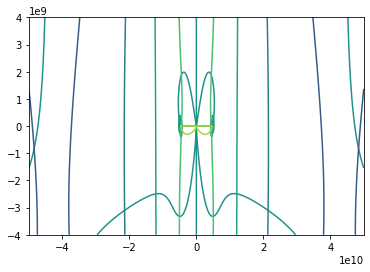

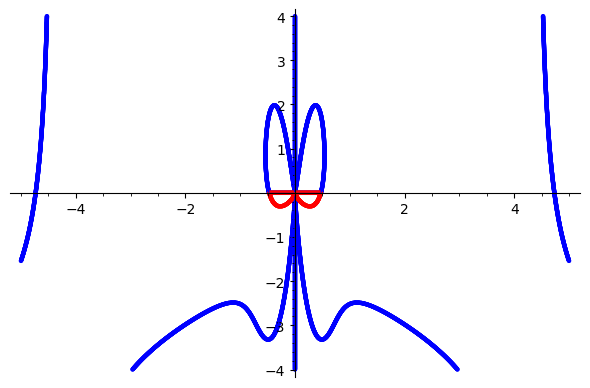

[(38259629.88196062, -650111.1243078113), (0.0, -22807998.374410424)]

In [270]:
omega_graphic_solutions = makeInvestigationPlots(
    omega_re_range = omega_re_range,
    omega_im_range = omega_im_range)

omega_graphic_solutions

In [271]:
omega_re_range=(-3e+11, +3e+11)
omega_im_range=(-3e+10, +3e+10)

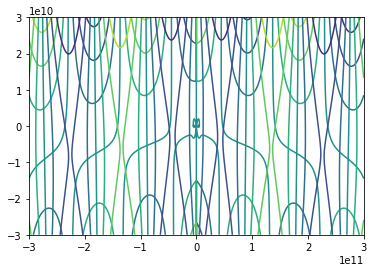

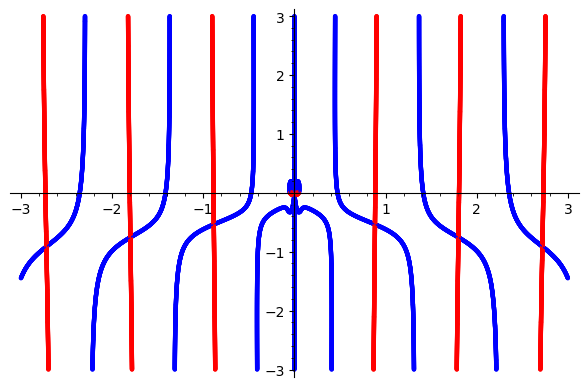

[(-88400715012.74094, -5355410703.050397),
 (88400715012.74094, -5355410703.050396),
 (-272055952547.93677, -9126950806.713875),
 (272055952547.93677, -9126950806.713877),
 (-179941894432.97717, -7561887991.060106),
 (186852910.1831911, -9840601.80431314),
 (0.0, -88838766.00850758),
 (179941894432.97717, -7561887991.060106)]

In [272]:
omega_graphic_solutions = makeInvestigationPlots(
    omega_re_range = omega_re_range,
    omega_im_range = omega_im_range)

omega_graphic_solutions

In [273]:
if make_investigation_plots:
    omegare_grid, gamma_grid, omegare_list, gamma_list, u, v = init_det_plot2d(
                                         omegare_min=omega_re_range[0], omegare_max=omega_re_range[1], nk=NK,
                                         gamma_min=omega_im_range[0], gamma_max=omega_im_range[1], ns=NK)
    # if nk == 201 I have 
    # negative number cannot be raised to a fractional power

In [274]:
if make_investigation_plots:
    u, v = make_det_plot2d(lib, omegare_list, gamma_list, u, v)

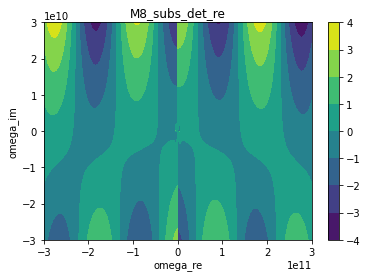

In [275]:
if make_investigation_plots:
    import matplotlib.pyplot as plt
    fig,ax=plt.subplots(1,1)

    cp = ax.contourf(omegare_grid,gamma_grid, u)
    fig.colorbar(cp) # Add a colorbar to a plot
    ax.set_title('M8_subs_det_re')
    ax.set_xlabel('omega_re')
    ax.set_ylabel('omega_im')
    plt.show()

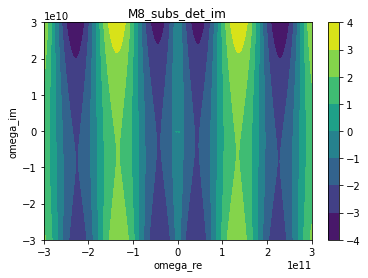

In [276]:
if make_investigation_plots:
    import matplotlib.pyplot as plt
    fig,ax=plt.subplots(1,1)

    cp = ax.contourf(omegare_grid,gamma_grid, v)
    fig.colorbar(cp) # Add a colorbar to a plot
    ax.set_title('M8_subs_det_im')
    ax.set_xlabel('omega_re')
    ax.set_ylabel('omega_im')
    plt.show()

Искомый волновой вектор можно найти графическим методом как точку пересечения двух нулевых изолиний на контурных графиках зависимости действительной и мнимой компонент детерминанта от действительной и мнимой компонент волнового вектора

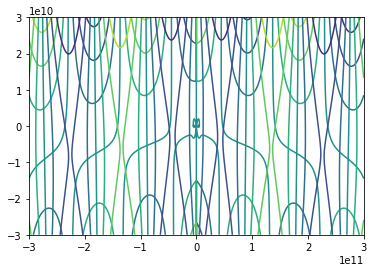

In [277]:
# Get coordinates from a contour
# https://stackoverflow.com/questions/19418901/get-coordinates-from-a-contour

import matplotlib.pyplot as plt
fig, ax=plt.subplots(1,1)
cu = ax.contour(omegare_grid,gamma_grid, u)
cv = ax.contour(omegare_grid,gamma_grid, v)
plt.show()

In [278]:
cu_index_of_zero_level=cu.levels.tolist().index(0.)
cv_index_of_zero_level=cv.levels.tolist().index(0.)
cu_zero_levels_number = len(cu.allsegs[cu_index_of_zero_level])
cv_zero_levels_number = len(cv.allsegs[cv_index_of_zero_level])
cu_zero_levels_number, cv_zero_levels_number

(9, 7)

Get coordinates from a contour

https://stackoverflow.com/questions/19418901/get-coordinates-from-a-contour

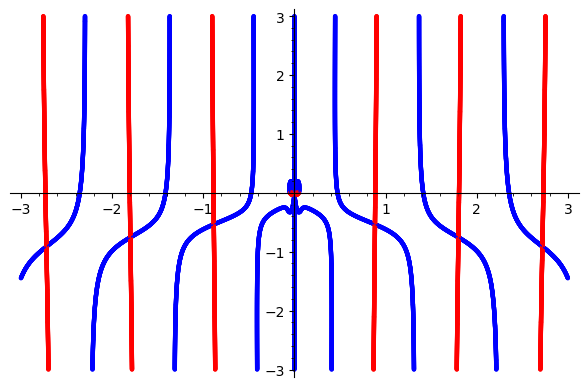

In [279]:
pl = Graphics()
for seg in cu.allsegs[cu_index_of_zero_level]:
    #print("seg", seg)
    pl += list_plot(seg)
    pl += line(seg)
for seg in cv.allsegs[cv_index_of_zero_level]:
    #print("seg", seg)
    pl += list_plot(seg, color="red")
    pl += line(seg, color="red")
pl.show()

In [280]:
def test_contour_line_intersection(M, i, j, cu, cv, cu_index, cv_index):
    dat_u = cu.allsegs[cu_index][i]
    dat_v = cv.allsegs[cv_index][j]
    
    xu = dat_u[:,0]
    yu = dat_u[:,1]
    xv = dat_v[:,0]
    yv = dat_v[:,1]
    
    if len(xu) < 2:
        return None
    if len(xv) < 2:
        return None
    
    return intersect_interp1d(M, xu, yu, xv, yv, ax)

Искомый волновой вектор можно найти графическим методом как точку пересечения двух нулевых изолиний на контурных графиках зависимости действительной и мнимой компонент детерминанта от действительной и мнимой компонент волнового вектора

Get coordinates from a contour

https://stackoverflow.com/questions/19418901/get-coordinates-from-a-contour

In [281]:
omega_graphic_solutions = find_resonance_roots_fast(lib, omega_re_range, omega_im_range)

In [282]:
omega_graphic_solutions

[(-88403915543.88295, -5356673614.448152),
 (88403915543.88295, -5356673614.448153),
 (-272057827331.98468, -9130525777.35132),
 (272057827331.98468, -9130525777.351318),
 (-179946015797.0026, -7563778270.716376),
 (179946015797.00262, -7563778270.716379)]

```
знак перед корнем будем всегда выбирать так, чтобы корень имел положительнею мнимую часть (Зоммерфельд, Электродинамика, параграф 20, Б. Волновое поле и скин-эффект в полупространстве)
```

In [283]:
omega_solution_number = len(omega_graphic_solutions)/2
omega_solution_number

3

In [284]:
max_abs_omega_sol = 0

for omega_sol_i in [omega_graphic_solutions[omega_solution_number]]:
    omega_sol_i_re = float(omega_sol_i[0])
    omega_sol_i_im = float(omega_sol_i[1])
    print(omega_sol_i_re, omega_sol_i_im)
    # знак перед корнем будем всегда выбирать так, чтобы корень имел положительнею мнимую часть (Зоммерфельд, Электродинамика, параграф 20, Б)
    # потому что нужно обеспечить затухание поля в проводнике
    # E_right_conductor_sol_z (x) = B1_zr*exp(+I * K_right_conductor*(x-a))
    # E_right_conductor_sol_x (x) = B1_xr*exp(+I * K_right_conductor*(x-a))
    for K_right_i in K_right_conductor_subs:
        K_right = K_right_i \
            .subs(kappa_vacuum_sol) \
            .subs(k_subs) \
            .subs(digit_values) \
            .subs(omega == omega_sol_i_re + I * omega_sol_i_im) \
            .subs(omega_re == omega_sol_i_re, omega_im == omega_sol_i_im)
        show(K_right)
        show(K_right.lhs() == K_right.rhs().n())
        # plot(E_right_conductor_sol_z (x).subs(K_right, a == A, B1_zr == 1+I).real(), x, 0, h_conductor).show()
    
    abs_omega_sol = omega_sol_i_re^2 + omega_sol_i_im^2
    print("abs_omega_sol,", abs_omega_sol)
    #if max_abs_k_z_sol < abs_k_z_sol:
    #    max_abs_k_z_sol = abs_k_z_sol
        # выберем решение с максимальным модулем
        # для того чтобы обеспечить лучшую сходимость итерационной процедуры

    omega_sol_re = omega_sol_i_re 
    omega_sol_im = omega_sol_i_im 

272057827331.98468 -9130525777.351318


K_H_right_conductor == 1/2*sqrt(-0.010000000000000000000000000000000000000*pi^2 + (329.0421981903417 - 22.110857899043268*I)*(-(3.1938862572157145e-05 - 0.0009516667244278432*I)*pi + 100.00000000000000000000000000000000000)*(-(4.879548448524008 - 145.39352734314272*I)*pi + 16.000000000000000000000000000000000000))

K_H_right_conductor == (1418.40699747197 + 1324.38212133835*I)

abs_omega_sol, 7.409882791357087e+22


In [285]:
omega_sol_re, omega_sol_im

(272057827331.98468, -9130525777.351318)

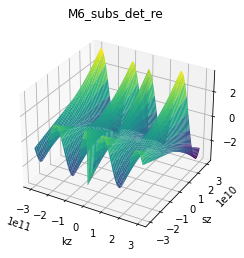

In [286]:
if make_investigation_plots:
    from mpl_toolkits import mplot3d
    import numpy as np
    import matplotlib.pyplot as plt
    fig = plt.figure()

    ax = plt.axes(projection='3d')
    ax.set_xlabel('kz')
    ax.set_ylabel('sz')
    ax.plot_surface(omegare_grid, gamma_grid, u, cmap='viridis', edgecolor='none')
    ax.set_title('M6_subs_det_re')
    plt.show()

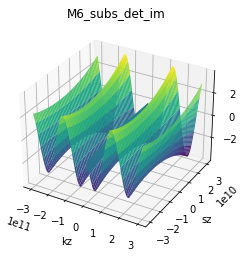

In [287]:
if make_investigation_plots:
    from mpl_toolkits import mplot3d
    import numpy as np
    import matplotlib.pyplot as plt
    fig = plt.figure()

    ax = plt.axes(projection='3d')
    ax.set_xlabel('kz')
    ax.set_ylabel('sz')
    ax.plot_surface(omegare_grid, gamma_grid, v, cmap='viridis', edgecolor='none')
    ax.set_title('M6_subs_det_im')
    plt.show()

In [288]:
solver = NewtonRootSolver(lib)
omegare_root, gamma_root = solver.solve(kz0 = omega_sol_re, sz0 = omega_sol_im)
print("Root:", omegare_root, gamma_root)

Root: 2.7205595543603445434570312500000000000e11 -9.1269178089385452270507812500000000000e9


In [289]:
omega_qnm_sol = [omega_re == omegare_root,
             omega_im == gamma_root,
             omega == omegare_root + I * gamma_root,
             j0_ext == 0, # в режиме QNM внешний ток возбуждения выключен
            ]

In [290]:
#omega_sol = [omega_re == omega_sol_re,  omega_im == omega_sol_im,
#           omega == omega_sol_re + I * omega_sol_im]

In [291]:
M4_d = M4 \
    .subs(K_vacuum_subs) \
    .subs(K_left_conductor_subs) \
    .subs(K_right_conductor_subs) \
    .subs(kappa_vacuum_sol) \
    .subs(epsilon_mu_subs) \
    .subs(k_subs) \
    .subs(sign_K_1_subs) \
    .subs(digit_values) \
    .subs(omega_qnm_sol)

In [292]:
M4_d.variables()

()

In [293]:
complex128(M4_d.det())

-1.2854327188847991995397406800064585698e-15 + 2.5808317296894499640854680467556865619e-15*I

In [294]:
omega_sol_re, omega_sol_im

(272057827331.98468, -9130525777.351318)

In [295]:
# ============================================================================
# ИСПРАВЛЕНИЕ: восстановление вектора B_ext, потерянного при GenerateMatrix
# Вставить СРАЗУ ПОСЛЕ Cell 485 (M4_K = GenerateMatrix(sys4, vars4))
# ============================================================================
 
# Свободный член (всё, что НЕ умножается на vars4) для каждого уравнения sys4.
# Это именно то, что GenerateMatrix отбросил при .coefficient(v).
 
# неизвестные амплитуды -- те же, что переданы в GenerateMatrix(sys4, vars4),
# имена зависят от режима (TE: B_H_*, TM: B_E_*)
vars4 = []
if is_TM:
    vars4 += [B_E_zl, A1_E_z, A2_E_z, B_E_zr]
if is_TE:
    vars4 += [B_H_zl, A1_H_z, A2_H_z, B_H_zr]

B_ext_symbolic = vector(SR, [
    -(eq.lhs() - eq.rhs()).expand().subs({v: 0 for v in vars4})
    for eq in sys4
])

# --- восстановление y-профиля моды в источнике j_ext ---
# sys4 нормирована делением на phase_y_* (чтобы убрать y из матрицы M4),
# но ток возбуждения j_ext профиль sin(k_y*y) не нёс -> в B_ext возник 1/phase_y_*
# (а при k_y=0 это деление на ноль). Домножение на phase_y_* сокращает 1/phase_y_*
# и эквивалентно согласованию источника с поперечным профилем моды (mode-matched).
#if is_TE:
#    B_ext_symbolic = B_ext_symbolic.apply_map(lambda e: (phase_y_TE*e).simplify_full())
#if is_TM:
#    B_ext_symbolic = B_ext_symbolic.apply_map(lambda e: (phase_y_TM*e).simplify_full())

print("Вектор B_ext (свободные члены, потерянные GenerateMatrix):")
for i, b in enumerate(B_ext_symbolic):
    show(b)

# Проверка: третья строка (eq_Ey_l) должна содержать j_ext_y(-a)
print("\nB_ext[2] должен содержать j_ext_y(-a):")
show(B_ext_symbolic[2])

# Контрольная проверка, что матрица M4_K действительно не зависит от j_ext
# (это ОЖИДАЕМО и ПРАВИЛЬНО — резонансные частоты не меняются)
print("\nM4_K.variables():")
print(M4_K.variables())
print("(в списке не должно быть j_ext_y -- это корректно)")

Вектор B_ext (свободные члены, потерянные GenerateMatrix):


0

0

-4*I*pi*j0_ext*mu_l_xx_c*omega/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

0


B_ext[2] должен содержать j_ext_y(-a):


-4*I*pi*j0_ext*mu_l_xx_c*omega/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)


M4_K.variables():
(K_H_left_conductor, K_H_right_conductor, K_H_vacuum, a, c, epsilon_l_yy_c, epsilon_r_yy_c, k_z, mu_l_xx_c, mu_r_xx_c, omega, sign_K_H_l, sign_K_H_r)
(в списке не должно быть j_ext_y -- это корректно)


In [296]:
# ============================================================================
# ПРОВЕРКА: где именно произошла подстановка j_ext_y(x) -> j0_ext?
# Вставить ПЕРЕД блоком B_ext_symbolic, чтобы проверить исходное состояние
# ============================================================================

# Тест 1: что стоит в исходном sys4[2] (eq_Ey_l) ДО любой подстановки?
print("sys4[2] (eq_Ey_l) — переменные:")
print(sys4[2].variables())
print()
print("Содержит ли sys4[2] функцию j_ext_y (символьную, не подставленную)?")
has_function_form = any('j_ext_y' in str(op) and op.operator() is not None
                         for op in sys4[2].lhs().operands() + sys4[2].rhs().operands()
                         if hasattr(op, 'operator')) if False else 'j_ext_y' in str(sys4[2])
print(f"  'j_ext_y' встречается в строковом представлении: {has_function_form}")
show(sys4[2])

# Тест 2: B_ext_symbolic[2] — что именно там стоит?
# Если там j_ext_y(-a) как ФУНКЦИЯ -- профиль ещё НЕ подставлен,
# тогда new-вариант (j0_ext == число) ОШИБОЧЕН: подставляется голая
# амплитуда без учёта exp(-I*K_l*(x+a))|_{x=-a} = exp(0) = 1 -- что
# на границе x=-a КОРРЕКТНО (экспонента вырождается в 1!), НО только
# если K_left_conductor в показателе совпадает с тем K_left_conductor,
# который уже использован в матрице M4_K -- иначе профиль рассинхронизирован.

print("\nB_ext_symbolic[2] — точная форма:")
show(B_ext_symbolic[2])
print("\nЭто j_ext_y(-a) уже свёрнутое в j0_ext, ИЛИ всё ещё функция j_ext_y(-a)?")
print(f"  variables: {B_ext_symbolic[2].variables()}")

# ВЫВОД:
# Если на экране 'j_ext_y' НЕ встречается, а виден 'j0_ext' напрямую --
# значит где-то РАНЬШЕ в блокноте (между Cell 285 и Cell 349) уже было:
#   j_ext_y_sym = j0_ext  (БЕЗ exp-профиля)
# Это означает, что скин-профиль j_ext ВООБЩЕ НЕ ВНЕДРЁН -- источник
# моделируется как ПОСТОЯННЫЙ (не зависящий от x) ток, что физически
# неверно для тока, распределённого по глубине скин-слоя.
#
# Если же на экране всё ещё 'j_ext_y(-a)' -- профиль нужно подставить
# ЯВНО перед численным решением (как в блоке ниже).

sys4[2] (eq_Ey_l) — переменные:
(A1_H_z, A2_H_z, B_H_zl, K_H_left_conductor, K_H_vacuum, a, c, epsilon_l_yy_c, j0_ext, k_z, mu_l_xx_c, omega, sign_K_H_l)

Содержит ли sys4[2] функцию j_ext_y (символьную, не подставленную)?
  'j_ext_y' встречается в строковом представлении: False


B_H_zl*K_H_left_conductor*c*mu_l_xx_c*omega*sign_K_H_l/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) + 4*I*pi*j0_ext*mu_l_xx_c*omega/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) == A1_H_z*K_H_vacuum*c*omega*e^(I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2) - A2_H_z*K_H_vacuum*c*omega*e^(-I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2)


B_ext_symbolic[2] — точная форма:


-4*I*pi*j0_ext*mu_l_xx_c*omega/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)


Это j_ext_y(-a) уже свёрнутое в j0_ext, ИЛИ всё ещё функция j_ext_y(-a)?
  variables: (c, epsilon_l_yy_c, j0_ext, k_z, mu_l_xx_c, omega)


In [297]:
B4 = B4_K \
    .subs(K_vacuum_subs) \
    .subs(K_left_conductor_subs) \
    .subs(K_right_conductor_subs) \
    .subs(kappa_vacuum_sol) \
    .subs(epsilon_mu_subs)          # аналогично M4 в M4 * X = B_ext

In [298]:
# ============================================================================
# СЛЕДУЮЩИЙ ШАГ: проверка знаменателя B_ext и решение неоднородной СЛАУ
# Вставить СРАЗУ ПОСЛЕ блока B_ext_symbolic (после Cell 485+)
# ============================================================================

# --- Проверка 1: знаменатель не должен совпадать с условием резонанса ---
denom_Bext2 = (c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)
print("Знаменатель B_ext[2]:")
show(denom_Bext2)

# Знаменатель связан с K_left_conductor:
#   K_left_conductor^2 = epsilon_l_yy_c*mu_l_xx_c*omega^2/c^2 - k_z^2  (примерно)
# Если это так, denom_Bext2 = -c^2 * K_left_conductor^2 (с точностью до знака)
# Это ВАЖНО: при численной подстановке K_left_conductor берётся из РЕШЁННОЙ
# однородной задачи -- то есть знаменатель ВСЕГДА конечен и не равен 0,
# если только сам K_left_conductor не обращается в ноль (не должно происходить
# для проводника с конечной sigma).

# --- Проверка 2: подставляем численные значения и решаем M4 * X = B_ext ---

omega_drive_d = omegare_root
#omega_drive_d = omega_sol_re
omega_drive_d_subs = [omega == omega_drive_d, omega_re == omega_drive_d, omega_im == 0]   # Добавлена строка

M4_d = M4_K \
    .subs(K_vacuum_subs) \
    .subs(K_left_conductor_subs) \
    .subs(K_right_conductor_subs) \
    .subs(kappa_vacuum_sol) \
    .subs(epsilon_mu_subs) \
    .subs(k_subs) \
    .subs(sign_K_1_subs) \
    .subs(digit_values).subs(omega_drive_d_subs).n(prec=128)

M4_det = M4_d.det()

B_ext_num = B_ext_symbolic \
    .subs(K_vacuum_subs) \
    .subs(K_left_conductor_subs) \
    .subs(K_right_conductor_subs) \
    .subs(kappa_vacuum_sol) \
    .subs(epsilon_mu_subs) \
    .subs(k_subs) \
    .subs(sign_K_1_subs) \
    .subs(digit_values).subs(omega_drive_d_subs)

print("\nM4_d (численная матрица):")
print("M4_det =", M4_det)
show(M4_d)

print("\nB_ext_num (численный вектор источника, без амплитуды j0_ext):")
#print(B_ext_num[2].variables())
show(B_ext_num)

# --- Проверка 3: задаём конкретную амплитуду j0_ext и решаем ---
j0_ext_value_d = complex128(1.0e16)  # А/см² (или с^-1 в СГС) -- варьируется

B_ext_final = B_ext_num.subs(j0_ext == j0_ext_value_d).n(prec=128)

print(f"\nB_ext_final (j0_ext = {j0_ext_value_d}):")
show(B_ext_final)

# --- Решение неоднородной СЛАУ ---
X_sol_ext = M4_d.solve_right(B_ext_final)
B1_zl_sol, A1_z_sol, A2_z_sol, B1_zr_sol = X_sol_ext

print(f"\nB1_zl_sol = {B1_zl_sol}")
print(f"A1_z_sol  = {A1_z_sol}")
print(f"A2_z_sol  = {A2_z_sol}")
print(f"B1_zr_sol = {B1_zr_sol}")

# --- Контрольная проверка: при j0_ext=0 решение должно быть нулевым ---
B_ext_zero = B_ext_num.subs(j0_ext == 0)
print(f"\nПри j0_ext=0, B_ext должен быть нулевым вектором: {B_ext_zero}")
# Если M4_d невырождена (det != 0), то решение при B_ext=0 -- тривиальное (все нули)
# Это и ожидается ВНЕ резонанса. На самой резонансной частоте det(M4_d) -> 0,
# и решение системы M4*X=0 становится неединственным (собственный вектор).

# --- Сканирование omega для построения резонансной кривой ---
print("\n" + "="*60)
print("СКАНИРОВАНИЕ ПО omega: |B1_zl(omega)| вблизи резонанса")
print("="*60)
print("Запустите отдельным циклом по omega_re, варьируя digit_values,")
print("и постройте |B1_zl_sol| -- должен показать лоренцеву кривую")
print("с максимумом на резонансной частоте, найденной из det(M4_K)=0.")


Знаменатель B_ext[2]:


c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2


M4_d (численная матрица):
M4_det = -0.63193588055312628527156919031254206661 - 0.078355326331357044394103641763623233337*I


[                                                     1.0000000000000000000000000000000000000        0.17476179951203928496498727298183894873 + 0.98461074208608641684517354362282746715*I        0.17476179951203928496498727298183894873 - 0.98461074208608641684517354362282746715*I                                                     0.00000000000000000000000000000000000000]
[                                                    0.00000000000000000000000000000000000000        0.17476179951203928496498727298183894873 - 0.98461074208608641684517354362282746715*I        0.17476179951203928496498727298183894873 + 0.98461074208608641684517354362282746715*I                                                      1.0000000000000000000000000000000000000]
[-0.00013872282800402904371021673895781019229 + 0.00013872282266645846344970052790872944328*I       -0.17478798609321394557190524419607582108 - 0.98475827769853188092062048311728808901*I        0.17478798609321394557190524419607582108 - 0.98475827769853188092062048311728808901*I                                                     0.00000000000000000000000000000000000000]
[                                                    0.00000000000000000000000000000000000000       -0.17478798609321394557190524419607582108 + 0.98475827769853188092062048311728808901*I        0.17478798609321394557190524419607582108 + 0.98475827769853188092062048311728808901*I        0.33630121209571029149856543737941306240 - 0.32473039481487542519802380281530366190*I]


B_ext_num (численный вектор источника, без амплитуды j0_ext):


(0, 0, 4.3528952869765512695312500000000000000e12*I*pi*j0_ext/(2.4485035989243100891113281250000000000e30*I*pi - 8.9875517873681764000000000000000000000e18*pi^2 + 2.9605777155285425987989749205309525132e23), 0)


B_ext_final (j0_ext = 1.0000000000000000000000000000000000000e16):


(0.00000000000000000000000000000000000000, 0.00000000000000000000000000000000000000, 0.017777777777777751458808072879579343253 + 6.8402689622100756781506907458131260461e-10*I, 0.00000000000000000000000000000000000000)


B1_zl_sol = -0.059023371512182711403559091166229385797 + 0.00080661109277434870388120639179542982622*I
A1_z_sol  = 0.0032038306819593969679639813480023229406 - 0.020381921414632382097786429603257224200*I
A2_z_sol  = 0.0071030284311545866238838064046583491403 + 0.037734574597813934953636947313279575024*I
B1_zr_sol = 0.055420881020332989333395994847920358327 - 0.0068717728859765984016086399730768586054*I

При j0_ext=0, B_ext должен быть нулевым вектором: (0, 0, 0, 0)

СКАНИРОВАНИЕ ПО omega: |B1_zl(omega)| вблизи резонанса
Запустите отдельным циклом по omega_re, варьируя digit_values,
и постройте |B1_zl_sol| -- должен показать лоренцеву кривую
с максимумом на резонансной частоте, найденной из det(M4_K)=0.


инициализируем метод Ньютона значениями найденными графическим методом

In [299]:
use_newton_prec = False

In [300]:
M4_det_d = M4_det_omega_re_im.subs(digit_values)
M4_det_d.variables()

(omega_im, omega_re, sign_K_H_l, sign_K_H_r)

In [301]:
if use_newton_prec:
    my_newton_prec = newton_prec(M_det_omega_re_im = M4_det_d, xn_re = omegare_root, xn_im = gamma_root,
                                digit_values = digit_values)

In [302]:
if use_newton_prec:
    my_newton_prec.find_newton_complex_root(nsteps = 15)

In [303]:
if use_newton_prec:
    k_z_root = my_newton_prec.get_root()
    omega_sol = [kz == k_z_root[0],   sz == k_z_root[1],
               k_z == k_z_root[0] + I * k_z_root[1]]


In [304]:
if use_newton_prec:
    print(k_z_root)

In [305]:
omega_qnm_sol

[omega_re == 2.7205595543603445434570312500000000000e11,
 omega_im == -9.1269178089385452270507812500000000000e9,
 omega == (2.7205595543603445434570312500000000000e11 - 9.1269178089385452270507812500000000000e9*I),
 j0_ext == 0]

Итак, графическим методом как точку пересечения двух нулевых изолиний на контурных графиках зависимости действительной и мнимой компонент детерминанта от действительной и мнимой компонент волнового вектора, были найдены приблизительные значения действительной и мнимой компонент волнового вектора, которые затем в итерационной процедуре были уточнены методом градиентного спуска Ньютона

# Substitutions

In [306]:
show(K_left_conductor_subs)

[K_H_left_conductor == sqrt(-(k_z^2 - (epsilon_l_yy + 4*I*pi*sigma_e_l_yy/omega)*(mu_l_xx + 4*I*pi*sigma_m_l_xx/omega)*(I*omega_im + omega_re)^2/c^2)*(k_y_H^2*(mu_l_yy + 4*I*pi*sigma_m_l_yy/omega)/(k_z^2 - (epsilon_l_xx + 4*I*pi*sigma_e_l_xx/omega)*(mu_l_yy + 4*I*pi*sigma_m_l_yy/omega)*(I*omega_im + omega_re)^2/c^2) + mu_l_zz + 4*I*pi*sigma_m_l_zz/omega)/(mu_l_xx + 4*I*pi*sigma_m_l_xx/omega))]

In [307]:
show(K_right_conductor_subs)

[K_H_right_conductor == sqrt(-(k_z^2 - (epsilon_r_yy + 4*I*pi*sigma_e_r_yy/omega)*(mu_r_xx + 4*I*pi*sigma_m_r_xx/omega)*(I*omega_im + omega_re)^2/c^2)*(k_y_H^2*(mu_r_yy + 4*I*pi*sigma_m_r_yy/omega)/(k_z^2 - (epsilon_r_xx + 4*I*pi*sigma_e_r_xx/omega)*(mu_r_yy + 4*I*pi*sigma_m_r_yy/omega)*(I*omega_im + omega_re)^2/c^2) + mu_r_zz + 4*I*pi*sigma_m_r_zz/omega)/(mu_r_xx + 4*I*pi*sigma_m_r_xx/omega))]

In [308]:
K_vacuum_qnm_subs_d          = [K_v_s.subs(k_subs).subs(kappa_vacuum_sol).subs(omega_qnm_sol).subs(digit_values) for K_v_s in K_vacuum_subs]
K_left_conductor_qnm_subs_d  = [K_l_s.subs(k_subs).subs(kappa_vacuum_sol).subs(omega_qnm_sol).subs(digit_values) for K_l_s in K_left_conductor_subs]
K_right_conductor_qnm_subs_d = [K_r_s.subs(k_subs).subs(kappa_vacuum_sol).subs(omega_qnm_sol).subs(digit_values) for K_r_s in K_right_conductor_subs]

In [309]:
[complex128(eq.rhs()) for eq in K_left_conductor_qnm_subs_d]

[33261.597102974479685480643033716488666 + 32164.449796012527512135158481649922659*I]

In [310]:
[complex128(eq.rhs()) for eq in K_right_conductor_qnm_subs_d]

[1418.3933417957697153756650583983690666 + 1324.3869913840153020662507212935681658*I]

знак перед корнем будем всегда выбирать так, чтобы корень имел положительнею мнимую часть (Зоммерфельд, Электродинамика, параграф 20, Б)

In [311]:
K_vacuum_qnm_subs_d

[K_E_vacuum == 1/2*sqrt(-0.010000000000000000000000000000000000000*pi^2 + 329.03795831666274935437989042621032619 - 22.101968620079930510147644643961737516*I),
 K_H_vacuum == 1/2*sqrt(-0.010000000000000000000000000000000000000*pi^2 + 329.03795831666274935437989042621032619 - 22.101968620079930510147644643961737516*I)]

In [312]:
#if complex128(K_vacuum_subs_d.rhs()).imag() < 0:
#    K_vacuum_subs_d = K_vacuum_subs_d.lhs() == - complex128(K_vacuum_subs_d.rhs())
#else:
#    K_vacuum_subs_d = K_vacuum_subs_d.lhs() == + complex128(K_vacuum_subs_d.rhs())

In [313]:
# if complex128(K_right_conductor_subs_d.rhs()).imag() < 0:
#     K_right_conductor_subs_d = K_right_conductor_subs_d.lhs() == - complex128(K_right_conductor_subs_d.rhs())
# else:
#     K_right_conductor_subs_d = K_right_conductor_subs_d.lhs() == + complex128(K_right_conductor_subs_d.rhs())

In [314]:
# if complex128(K_left_conductor_subs_d.rhs()).imag() < 0:
#     K_left_conductor_subs_d = K_left_conductor_subs_d.lhs() == - complex128(K_left_conductor_subs_d.rhs())
# else:
#     K_left_conductor_subs_d = K_left_conductor_subs_d.lhs() == + complex128(K_left_conductor_subs_d.rhs())

In [315]:
# Выбираем знак корня (Im > 0 для затухания в глубину)
# K_vacuum_subs_d          = fix_K_sign(K_vacuum_subs_d)
K_left_conductor_qnm_subs_d  = fix_K_sign(K_left_conductor_qnm_subs_d)
K_right_conductor_qnm_subs_d = fix_K_sign(K_right_conductor_qnm_subs_d)

In [316]:
K_right_conductor_qnm_subs_d

[K_H_right_conductor == 1/2*sqrt(-0.010000000000000000000000000000000000000*pi^2 + (329.03795831666274935437989042621032619 - 22.101968620079930510147644643961737516*I)*(-(0.000031926709016950833035229833119636677649 - 0.00095167410371858867811908815687849135968*I)*pi + 100.00000000000000000000000000000000000)*(-(4.8776916553674883803823356155000479742 - 145.39465473478438137930513507865840217*I)*pi + 16.000000000000000000000000000000000000))]

In [317]:
K_left_conductor_qnm_subs_d

[K_H_left_conductor == 1/2*sqrt((9.1395590505410166038402846873585261277e7 + 2.7243276665906200845580225276425137860e9*I)*pi - 0.010000000000000000000000000000000000000*pi^2 + 329.03795831666274935437989042621032619 - 22.101968620079930510147644643961737516*I)]

In [319]:
M4_qnm_d = M4 \
    .subs(K_vacuum_subs) \
    .subs(K_left_conductor_subs) \
    .subs(K_right_conductor_subs) \
    .subs(kappa_vacuum_sol) \
    .subs(epsilon_mu_subs) \
    .subs(k_subs) \
    .subs(sign_K_1_subs) \
    .subs(digit_values) \
    .subs(omega_qnm_sol)

In [320]:
M4_qnm_d.variables()

()

In [321]:
complex128(M4_qnm_d.det())

-1.2854327188847991995397406800064585698e-15 + 2.5808317296894499640854680467556865619e-15*I

Используем SVD для гарантированной симметрии

Самый надёжный метод — найти ядро матрицы через сингулярное разложение:

In [322]:
X4, residual = svd_X4(M4_qnm_d)
X4, residual

(array([ 0.63239269-0.j        , -0.04742388+0.26740721j,
        -0.06428585-0.36248628j, -0.62150935+0.06723832j]),
 {'residual': 6.037236470234411e-16, 'valid': True, 'candidate_id': 3})

In [323]:
coeffs_qnm_subs = [vars4[i] == X4[i] for i in range(len(vars4))]
coeffs_qnm_subs

[B_H_zl == 0.6323926946947668,
 A1_H_z == (-0.04742387531305803 + 0.2674072121809439*I),
 A2_H_z == (-0.06428585164144934 - 0.3624862815096104*I),
 B_H_zr == (-0.621509349782808 + 0.06723832054133301*I)]

In [324]:
sys4

[B_H_zl == A1_H_z*e^(I*K_H_vacuum*a) + A2_H_z*e^(-I*K_H_vacuum*a),
 B_H_zr == A2_H_z*e^(I*K_H_vacuum*a) + A1_H_z*e^(-I*K_H_vacuum*a),
 B_H_zl*K_H_left_conductor*c*mu_l_xx_c*omega*sign_K_H_l/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) + 4*I*pi*j0_ext*mu_l_xx_c*omega/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) == A1_H_z*K_H_vacuum*c*omega*e^(I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2) - A2_H_z*K_H_vacuum*c*omega*e^(-I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2),
 -B_H_zr*K_H_right_conductor*c*mu_r_xx_c*omega*sign_K_H_r/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2) == -A2_H_z*K_H_vacuum*c*omega*e^(I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2) + A1_H_z*K_H_vacuum*c*omega*e^(-I*K_H_vacuum*a)/(c^2*k_z^2 - omega^2)]

In [326]:
sys4_subs_d = [eq.subs(K_vacuum_qnm_subs_d) \
                 .subs(K_left_conductor_qnm_subs_d) \
                 .subs(K_right_conductor_qnm_subs_d)
                 .subs(epsilon_mu_subs) \
                 .subs(k_subs).subs(sign_K_1_subs).subs(omega_qnm_sol) \
                 .subs(digit_values) for eq in sys4]
#sys4_subs_d

In [327]:
for i, eq in enumerate(sys4_subs_d):
    diff_expr = (eq.lhs() - eq.rhs())
    free_vars = set(diff_expr.variables()) - set(vars4)
    print(f"Уравнение {i}: посторонние переменные = {free_vars}")

Уравнение 0: посторонние переменные = set()
Уравнение 1: посторонние переменные = set()
Уравнение 2: посторонние переменные = set()
Уравнение 3: посторонние переменные = set()


In [329]:
Ex_left_conductor_d, Ex_right_conductor_d, Ex_vacuum_d, \
Ey_left_conductor_d, Ey_right_conductor_d, Ey_vacuum_d, \
Ez_left_conductor_d, Ez_right_conductor_d, Ez_vacuum_d, \
Dx_left_conductor_d, Dx_right_conductor_d, Dx_vacuum_d, \
Dy_left_conductor_d, Dy_right_conductor_d, Dy_vacuum_d, \
Dz_left_conductor_d, Dz_right_conductor_d, Dz_vacuum_d, \
Hx_left_conductor_d, Hx_right_conductor_d, Hx_vacuum_d, \
Hy_left_conductor_d, Hy_right_conductor_d, Hy_vacuum_d, \
Hz_left_conductor_d, Hz_right_conductor_d, Hz_vacuum_d, \
Bx_left_conductor_d, Bx_right_conductor_d, Bx_vacuum_d, \
By_left_conductor_d, By_right_conductor_d, By_vacuum_d, \
Bz_left_conductor_d, Bz_right_conductor_d, Bz_vacuum_d, \
div_B_left_conductor_d, div_B_right_conductor_d, div_B_vacuum_d, \
div_D_left_conductor_d, div_D_right_conductor_d, div_D_vacuum_d \
    = subs_fields(k_subs,
                  K_left_conductor_qnm_subs_d,
                  K_vacuum_qnm_subs_d,
                  K_right_conductor_qnm_subs_d,
                  omega_qnm_sol + coeffs_qnm_subs, digit_values)

In [330]:
# divE_vacuum = I*k_z * Ez_vacuum_d (x=x) + Ex_vacuum_d (x=x).diff(x)

In [331]:
# divE_vacuum_d = divE_vacuum.subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

In [332]:
#divE_left_conductor  = I*k_z * Ez_left_conductor_d (x=x) + Ex_left_conductor_d (x=x).diff(x)
#divE_right_conductor = I*k_z * Ez_right_conductor_d (x=x) + Ex_right_conductor_d (x=x).diff(x)

In [333]:
#divE_left_conductor_d  = divE_left_conductor .subs(K_left_conductor_subs) .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
#divE_right_conductor_d = divE_right_conductor.subs(K_right_conductor_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

In [334]:
x = var('x')
print(set(div_B_left_conductor_d.variables()) - {x})
print(set(div_B_vacuum_d.variables()) - {x})
print(set(div_B_right_conductor_d.variables()) - {x})

set()
set()
set()


In [335]:
test_val = div_B_left_conductor_d.subs(x == -A - h_conductor_l)
print(type(test_val))
print(test_val)
print(test_val.variables() if hasattr(test_val, 'variables') else "не символьное")

<class 'sage.symbolic.expression.Expression'>
0.03161963473473834*I*pi*e^((9.375000000000355e-05*I)*sqrt((9.1395590505410166038402846873585261277e7 + 2.7243276665906200845580225276425137860e9*I)*pi - 0.010000000000000000000000000000000000000*pi^2 + 329.03795831666274935437989042621032619 - 22.101968620079930510147644643961737516*I)) - (1.1367324187045057e+20*I)*pi*((2.2848897626352541509600711718396315319e7 + 6.8108191664765502113950563191062844650e8*I)*pi - 0.0025000000000000000000000000000000000000*pi^2 + 82.259489579165687338594972606552581549 - 5.5254921550199826275369111609904343790*I)*e^((9.375000000000355e-05*I)*sqrt((9.1395590505410166038402846873585261277e7 + 2.7243276665906200845580225276425137860e9*I)*pi - 0.010000000000000000000000000000000000000*pi^2 + 329.03795831666274935437989042621032619 - 22.101968620079930510147644643961737516*I))/((8.2142260280446907043457031250000000000e28 + 2.4485035989243100891113281250000000000e30*I)*pi - 8.9875517873681764000000000000000000000e

In [336]:
print(div_B_left_conductor_d.variables())

(x,)


In [337]:
h_conductor_l_step = h_conductor_l / 10
for x in np.arange(-A-h_conductor_l, -A+h_conductor_l_step, h_conductor_l_step):
    print(x, div_B_left_conductor_d(x = x).n(prec=128))

-0.5001875 4.2421190103835688069616174104429558038e-22 + 9.0896662806144407752018062274217962051e-21*I
-0.50016875 1.0331832371792848225683352686035309677e-20 + 1.3033269353299445480916661921337079918e-20*I
-0.50015 2.9240945957613296508809116553725429826e-20 + 8.3087436675169721360569189876681624014e-21*I
-0.50013125 5.2252832802172234725873609340586140472e-20 - 1.8884761990535039588351785308359477368e-20*I
-0.5001125 5.7368173443878175899550466506365219728e-20 - 8.3794213531494544336734750002978704403e-20*I
-0.50009375000000000003 -4.3276284646686946009667645233058224882e-21 - 1.8555870877207989899516215798673443517e-19*I
-0.50007500000000000003 -2.0448882852724341017805351706280089143e-19 - 2.7068880409291945947040314154805415339e-19*I
-0.50005625000000000004 -5.9233140163328843331085537323931971126e-19 - 1.8333894500487199840893453792709986462e-19*I
-0.50003750000000000004 -1.0745238908907248291316918808128197231e-18 + 3.6024832743790813042427933549565385951e-19*I
-0.50001875000000

In [338]:
h_conductor_r_step = h_conductor_r / 10
for x in np.arange(A, A+h_conductor_r+h_conductor_r_step, h_conductor_r_step):
    print(x, div_B_right_conductor_d(x = x).n(prec=128))

0.5 -1.1554508488604834913331196496893203298e-16 - 9.1833972429403541331086183044871109280e-16*I
0.500625 2.7906715069670381883339665775144515176e-16 - 2.9283209002878316885090615585312287781e-16*I
0.50125 1.7626118737286897751553213733709542937e-16 + 1.3604938536302403732291145378323446727e-17*I
0.50187500000000000004 4.4087328736945134180385557112265098326e-17 + 6.3447918591308211278172247034953774298e-17*I
0.50250000000000000005 -9.3063865347828662299689309444689351295e-18 + 3.2458145728463938440786334036849606552e-17*I
0.50312500000000000007 -1.3562693129340175694536110011643722705e-17 + 5.8154702539634774008201227753072266711e-18*I
0.5037500000000000001 -5.7162368128219877172593214834233033288e-18 - 2.9862901643341922466923926390263907390e-18*I
0.5043750000000000001 -5.6790531796427283092266236154980780404e-19 - 2.7607584768661045935932533845942284982e-18*I
0.5050000000000000001 7.7801618409185857832856417009161070450e-19 - 9.5501307910399809309774156315116152231e-19*I
0.505625000

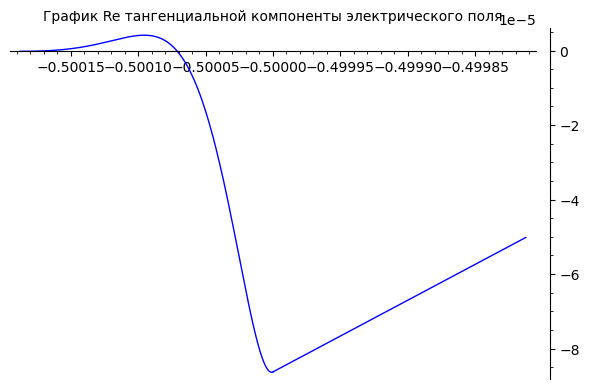

In [339]:
if is_TM:
    pl  = plot(Ez_left_conductor_d.real(), (x, -A-h_conductor_l, -A))
    pl += plot(Ez_vacuum_d.real(), (x, -A, -A+h_conductor_l))
if is_TE:
    pl  = plot(Ey_left_conductor_d.real(), (x, -A-h_conductor_l, -A))
    pl += plot(Ey_vacuum_d.real(), (x, -A, -A+h_conductor_l))

pl.show(title="График Re тангенциальной компоненты электрического поля")

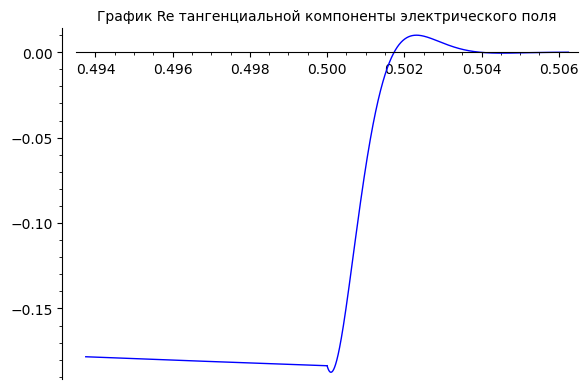

In [340]:
if is_TM:
    pl = plot(Ez_vacuum_d.real(), (x, A-h_conductor_r, A))
    pl += plot(Ez_right_conductor_d.real(), (x, A, A+h_conductor_r))
if is_TE:
    pl = plot(Ey_vacuum_d.real(), (x, A-h_conductor_r, A))
    pl += plot(Ey_right_conductor_d.real(), (x, A, A+h_conductor_r))

pl.show(title="График Re тангенциальной компоненты электрического поля")

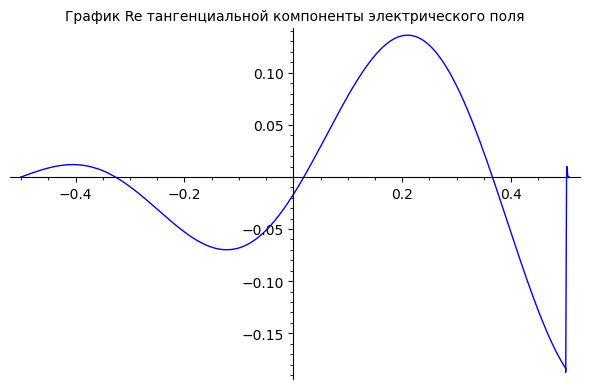

In [341]:
pl = Graphics()
if is_TM:
    pl  = plot(Ez_left_conductor_d.real(), (x, -A-h_conductor_l, -A))
    pl += plot(Ez_vacuum_d.real(), (x, -A, A))
    pl += plot(Ez_right_conductor_d.real(), (x, A, A+h_conductor_r))
if is_TE:
    pl  = plot(Ey_left_conductor_d.real(), (x, -A-h_conductor_l, -A))
    pl += plot(Ey_vacuum_d.real(), (x, -A, A))
    pl += plot(Ey_right_conductor_d.real(), (x, A, A+h_conductor_r))

pl.show(title="График Re тангенциальной компоненты электрического поля")

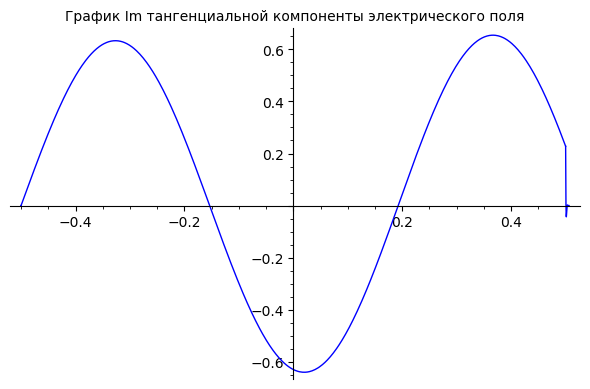

In [342]:
if is_TM:
    pl  = plot(Ez_left_conductor_d.imag(), (x, -A-h_conductor_l, -A))
    pl += plot(Ez_vacuum_d.imag(), (x, -A, A))
    pl += plot(Ez_right_conductor_d.imag(), (x, A, A+h_conductor_r))
if is_TE:
    pl  = plot(Ey_left_conductor_d.imag(), (x, -A-h_conductor_l, -A))
    pl += plot(Ey_vacuum_d.imag(), (x, -A, A))
    pl += plot(Ey_right_conductor_d.imag(), (x, A, A+h_conductor_r))

pl.show(title="График Im тангенциальной компоненты электрического поля")

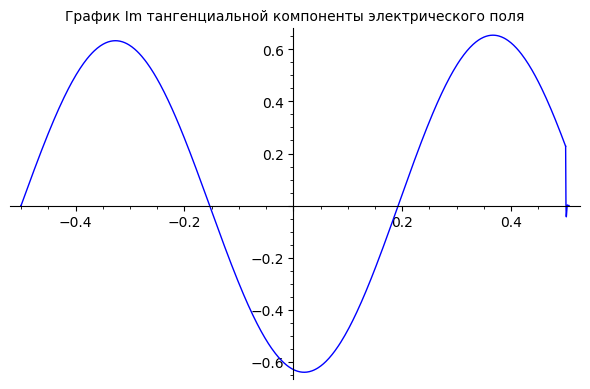

In [343]:
if is_TM:
    pl  = plot(Ez_left_conductor_d.imag(), (x, -A-h_conductor_l, -A))
    pl += plot(Ez_vacuum_d.imag(), (x, -A, A))
    pl += plot(Ez_right_conductor_d.imag(), (x, A, A+h_conductor_r))
if is_TE:
    pl  = plot(Ey_left_conductor_d.imag(), (x, -A-h_conductor_l, -A))
    pl += plot(Ey_vacuum_d.imag(), (x, -A, A))
    pl += plot(Ey_right_conductor_d.imag(), (x, A, A+h_conductor_r))

pl.show(title="График Im тангенциальной компоненты электрического поля")

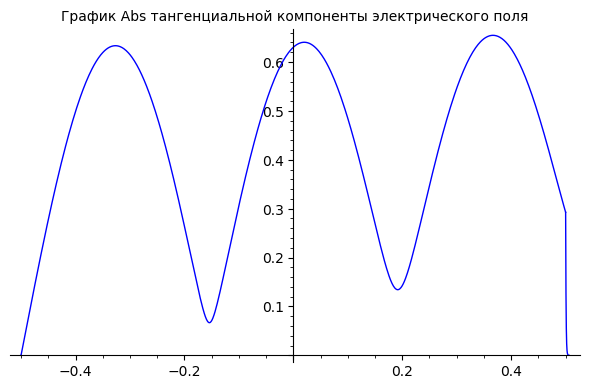

In [344]:
if is_TM:
    pl =  plot(Ez_left_conductor_d.abs(), (x, -A-h_conductor_l, -A))
    pl += plot(Ez_vacuum_d.abs(), (x, -A, A))
    pl += plot(Ez_right_conductor_d.abs(), (x, A, A+h_conductor_r))
if is_TE:
    pl =  plot(Ey_left_conductor_d.abs(), (x, -A-h_conductor_l, -A))
    pl += plot(Ey_vacuum_d.abs(), (x, -A, A))
    pl += plot(Ey_right_conductor_d.abs(), (x, A, A+h_conductor_r))

pl.show(title="График Abs тангенциальной компоненты электрического поля")

verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.5)'


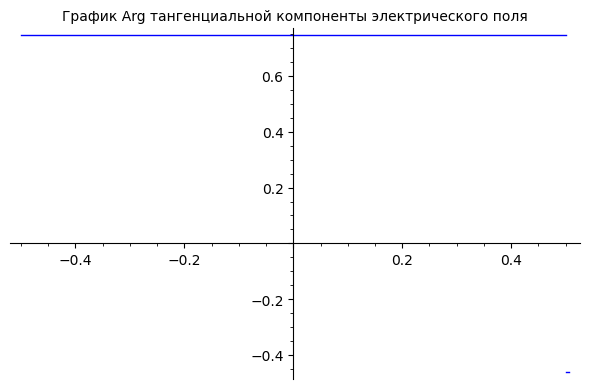

In [345]:
if is_TM:
    pl  = plot(arg(Ez_left_conductor_d(x=x))/pi, (x, -h_conductor_l-A, -A))
    pl += plot(arg(Ez_vacuum_d(x=x))/pi, (x, -A, A))
    pl += plot(arg(Ez_right_conductor_d(x=x))/pi, (x, A, A+h_conductor_r))
if is_TE:
    pl  = plot(arg(Ey_left_conductor_d(x=x))/pi, (x, -h_conductor_l-A, -A))
    pl += plot(arg(Ey_vacuum_d(x=x))/pi, (x, -A, A))
    pl += plot(arg(Ey_right_conductor_d(x=x))/pi, (x, A, A+h_conductor_r))

pl.show(title="График Arg тангенциальной компоненты электрического поля")

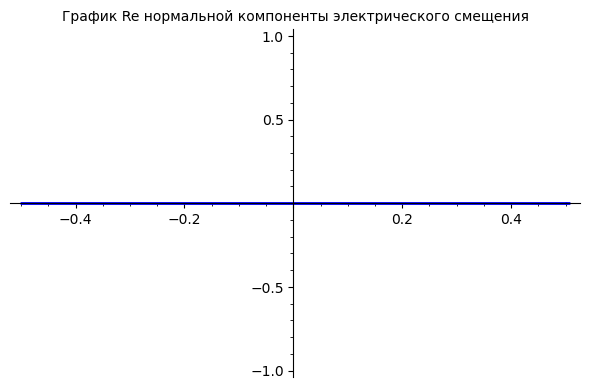

In [346]:
pl = Graphics()
for y_d in np.arange(-B, B+y_step, y_step):
    pl += plot(Dx_left_conductor_d.subs(y == y_d).real(), (x, -A-h_conductor_l, -A))
    pl += plot(Dx_vacuum_d.subs(y == y_d).real(), (x, -A, A))
    pl += plot(Dx_right_conductor_d.subs(y == y_d).real(), (x, A, A+h_conductor_r))

pl.show(title="График Re нормальной компоненты электрического смещения")

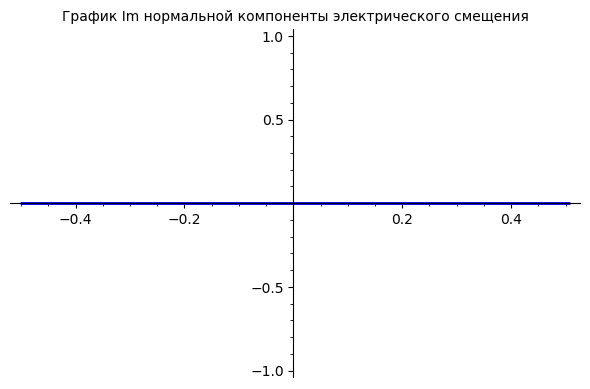

In [347]:
pl = Graphics()
for y_d in np.arange(-B, B+y_step, y_step):
    pl += plot(Dx_left_conductor_d.subs(y == y_d).imag(), (x, -h_conductor_l-A, -A))
    pl += plot(Dx_vacuum_d.subs(y == y_d).imag(), (x, -A, A))
    pl += plot(Dx_right_conductor_d.subs(y == y_d).imag(), (x, A, A+h_conductor_r))

pl.show(title="График Im нормальной компоненты электрического смещения")

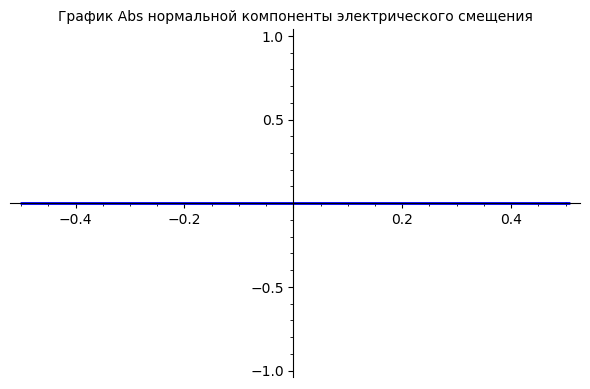

In [348]:
pl = Graphics()
for y_d in np.arange(-B, B+y_step, y_step):
    pl += plot(Dx_left_conductor_d.subs(y == y_d).abs(), (x, -h_conductor_l-A, -A))
    pl += plot(Dx_vacuum_d.subs(y == y_d).abs(), (x, -A, A))
    pl += plot(Dx_right_conductor_d.subs(y == y_d).abs(), (x, A, A+h_conductor_r))

pl.show(title="График Abs нормальной компоненты электрического смещения")

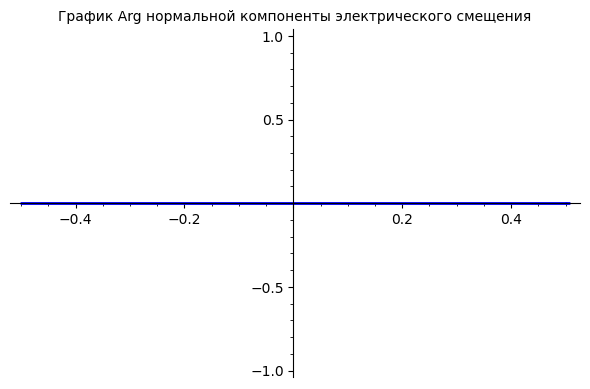

In [349]:
pl = Graphics()

for y_d in np.arange(-B, B+y_step, y_step):
    pl += plot(arg(Dx_left_conductor_d.subs(y == y_d))/pi, (x, -h_conductor_l-A, -A))
    pl += plot(arg(Dx_vacuum_d.subs(y == y_d))/pi, (x, -A, A))
    pl += plot(arg(Dx_right_conductor_d.subs(y == y_d))/pi, (x, A, A+h_conductor_r))

pl.show(title="График Arg нормальной компоненты электрического смещения")

In [350]:
Hz_left_conductor_d

(x, y) |--> 0.6323926946947668*e^(-1/2*I*sqrt((9.1395590505410166038402846873585261277e7 + 2.7243276665906200845580225276425137860e9*I)*pi - 0.010000000000000000000000000000000000000*pi^2 + 329.03795831666274935437989042621032619 - 22.101968620079930510147644643961737516*I)*x - 0.25000000000000000000000000000000000000*I*sqrt((9.1395590505410166038402846873585261277e7 + 2.7243276665906200845580225276425137860e9*I)*pi - 0.010000000000000000000000000000000000000*pi^2 + 329.03795831666274935437989042621032619 - 22.101968620079930510147644643961737516*I))

verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.5)'
verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.5)'
verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.5)'
verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.5)'
verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_p

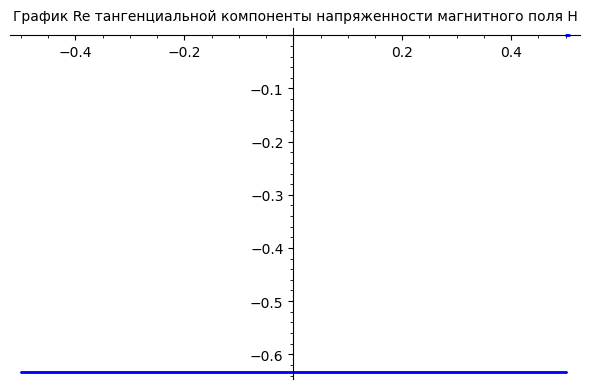

In [351]:
pl = Graphics()
if is_TM:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(Hy_left_conductor_d(x=x, y=y_d).real(), (x, -h_conductor_l-A, -A))
        pl += plot(Hy_vacuum_d(x=x, y=y_d).real(), (x, -A, A))
        pl += plot(Hy_right_conductor_d(x=x, y=y_d).real(), (x, A, A+h_conductor_r))
if is_TE:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(Hz_left_conductor_d(x=x, y=y_d).real(), (x, -h_conductor_l-A, -A))
        pl += plot(Hz_vacuum_d(x=x, y=y_d).real(), (x, -A, A))
        pl += plot(Hz_right_conductor_d(x=x, y=y_d).real(), (x, A, A+h_conductor_r))

pl.show(title="График Re тангенциальной компоненты напряженности магнитного поля H")

verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.5)'
verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.5)'
verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.5)'
verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.5)'
verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_p

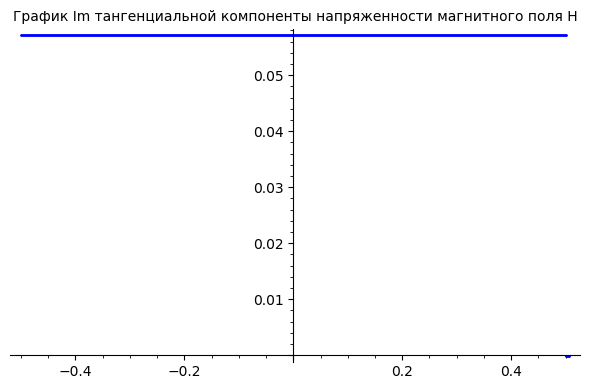

In [352]:
pl = Graphics()
if is_TM:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(Hy_left_conductor_d(x=x, y=y_d).imag(), (x, -h_conductor_l-A, -A))
        pl += plot(Hy_vacuum_d(x=x, y=y_d).imag(), (x, -A, A))
        pl += plot(Hy_right_conductor_d(x=x, y=y_d).imag(), (x, A, A+h_conductor_r))
if is_TE:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(Hz_left_conductor_d(x=x, y=y_d).imag(), (x, -h_conductor_l-A, -A))
        pl += plot(Hz_vacuum_d(x=x, y=y_d).imag(), (x, -A, A))
        pl += plot(Hz_right_conductor_d(x=x, y=y_d).imag(), (x, A, A+h_conductor_r))

pl.show(title="График Im тангенциальной компоненты напряженности магнитного поля H")

verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.5)'
verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.5)'
verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.5)'
verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_points) Last error message: 'Unable to compute f(-0.5)'
verbose 0 (3885: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 200 points.
verbose 0 (3885: plot.py, generate_plot_p

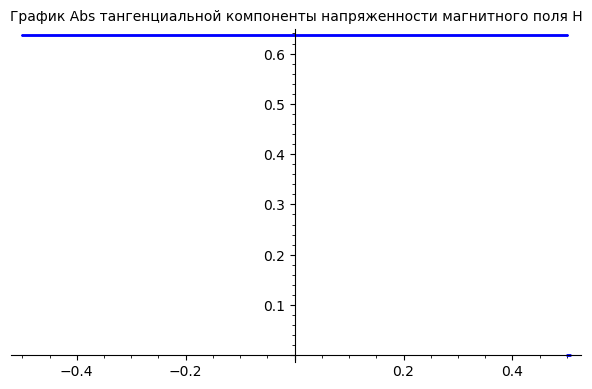

In [353]:
pl = Graphics()
if is_TM:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(Hy_left_conductor_d(x=x, y=y_d).abs(), (x, -h_conductor_l-A, -A))
        pl += plot(Hy_vacuum_d(x=x, y=y_d).abs(), (x, -A, A))
        pl += plot(Hy_right_conductor_d(x=x, y=y_d).abs(), (x, A, A+h_conductor_r))
if is_TE:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(Hz_left_conductor_d(x=x, y=y_d).abs(), (x, -h_conductor_l-A, -A))
        pl += plot(Hz_vacuum_d(x=x, y=y_d).abs(), (x, -A, A))
        pl += plot(Hz_right_conductor_d(x=x, y=y_d).abs(), (x, A, A+h_conductor_r))

pl.show(title="График Abs тангенциальной компоненты напряженности магнитного поля H")

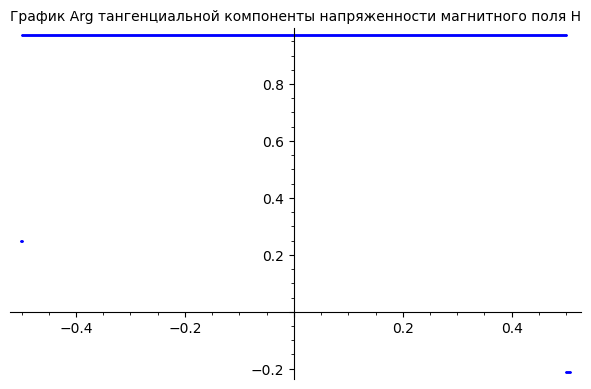

In [354]:
pl = Graphics()
if is_TM:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(arg(Hy_left_conductor_d(x=x, y=y_d))/pi, (x, -h_conductor_l-A, -A))
        pl += plot(arg(Hy_vacuum_d(x=x, y=y_d))/pi, (x, -A, A))
        pl += plot(arg(Hy_right_conductor_d(x=x, y=y_d))/pi, (x, A, A+h_conductor_r))
if is_TE:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(arg(Hz_left_conductor_d(x=x, y=y_d))/pi, (x, -h_conductor_l-A, -A))
        pl += plot(arg(Hz_vacuum_d(x=x, y=y_d))/pi, (x, -A, A))
        pl += plot(arg(Hz_right_conductor_d(x=x, y=y_d))/pi, (x, A, A+h_conductor_r))

pl.show(title="График Arg тангенциальной компоненты напряженности магнитного поля H")

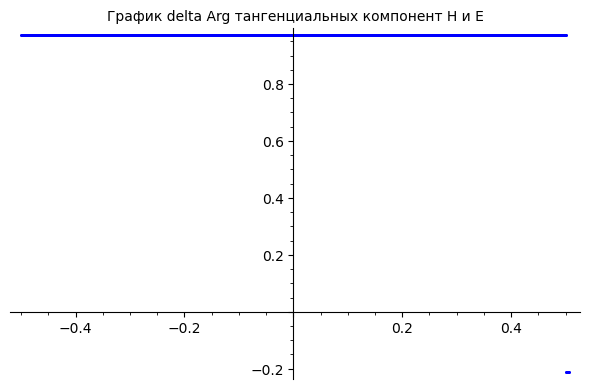

In [355]:
if is_TM:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(arg(Hy_left_conductor_d(x=x, y=y_d))/pi  - arg(Ez_left_conductor_d(x=x))/pi, (x, -h_conductor_l-A, -A))
        pl += plot(arg(Hy_vacuum_d(x=x, y=y_d))/pi          - arg(Ez_vacuum_d(x=x))/pi, (x, -A, A))
        pl += plot(arg(Hy_right_conductor_d(x=x, y=y_d))/pi - arg(Ez_right_conductor_d(x=x))/pi, (x, A, A+h_conductor_r))
if is_TE:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(arg(Hz_left_conductor_d(x=x, y=y_d))/pi  - arg(Ez_left_conductor_d(x=x))/pi, (x, -h_conductor_l-A, -A))
        pl += plot(arg(Hz_vacuum_d(x=x, y=y_d))/pi          - arg(Ez_vacuum_d(x=x))/pi, (x, -A, A))
        pl += plot(arg(Hz_right_conductor_d(x=x, y=y_d))/pi - arg(Ez_right_conductor_d(x=x))/pi, (x, A, A+h_conductor_r))

pl.show(title="График delta Arg тангенциальных компонент H и E")

In [356]:
phase_EzEx_left (x, y) = (arg(Ez_left_conductor_d(x=x, y=y))/pi
                    -  arg(Ex_left_conductor_d(x=x, y=y))/pi)

In [357]:
phase_EzEx_right (x, y) = (arg(Ez_right_conductor_d(x=x, y=y))/pi
                     -  arg(Ex_right_conductor_d(x=x, y=y))/pi)

In [358]:
phase_EzEx_left (x =-h_conductor_l-A), \
phase_EzEx_right(x = A+h_conductor_r)

(0, 0)

In [359]:
# - pi/4 + phi
if is_TM:
    phase_EH_left_ (x, y) = ((arg(Ez_left_conductor_d(x=x, y=y))/pi
                       -  arg(Hy_left_conductor_d(x=x, y=y))/pi))
    phase_EH_right_ (x, y) = ((arg(Ez_right_conductor_d(x=x, y=y))/pi
                        -  arg(Hy_right_conductor_d(x=x, y=y))/pi))
if is_TE:
    phase_EH_left_ (x, y) = ((arg(Ey_left_conductor_d(x=x, y=y))/pi
                       -  arg(Hz_left_conductor_d(x=x, y=y))/pi))
    phase_EH_right_ (x, y) = ((arg(Ey_right_conductor_d(x=x, y=y))/pi
                        -  arg(Hz_right_conductor_d(x=x, y=y))/pi))

In [360]:
# - pi/4 + phi
if is_TM:
    phase_EB_left (x, y) = ((arg(Ez_left_conductor_d(x=x, y=y))/pi
                      -  arg(By_left_conductor_d(x=x, y=y))/pi))
    phase_EB_right (x, y) = ((arg(Ez_right_conductor_d(x=x, y=y))/pi
                       -  arg(By_right_conductor_d(x=x, y=y))/pi))
if is_TE:
    phase_EB_left (x, y) = ((arg(Ey_left_conductor_d(x=x, y=y))/pi
                      -  arg(Bz_left_conductor_d(x=x, y=y))/pi))
    phase_EB_right (x, y) = ((arg(Ey_right_conductor_d(x=x, y=y))/pi
                       -  arg(Bz_right_conductor_d(x=x, y=y))/pi))

In [361]:
print(Ey_left_conductor_d(x=-A))
print(Hz_left_conductor_d(x=-A))
print(Ey_right_conductor_d(x=A))
print(Hz_right_conductor_d(x=A))

-(1.0315630563520336e+22 - 3.4606819082393125e+20*I)*sqrt((9.1395590505410166038402846873585261277e7 + 2.7243276665906200845580225276425137860e9*I)*pi - 0.010000000000000000000000000000000000000*pi^2 + 329.03795831666274935437989042621032619 - 22.101968620079930510147644643961737516*I)/((8.2142260280446907043457031250000000000e28 + 2.4485035989243100891113281250000000000e30*I)*pi - 8.9875517873681764000000000000000000000e18*pi^2 + 2.9572456903808978157926690315483487211e23 - 1.9864258757575472677876728178115561604e22*I)
0.6323926946947668
-(1.0101305492266417e+22 - 1.4369082664910266e+21*I)*(-(0.000031926709016950833035229833119636677649 - 0.00095167410371858867811908815687849135968*I)*pi + 100.00000000000000000000000000000000000)*sqrt(-0.010000000000000000000000000000000000000*pi^2 + (329.03795831666274935437989042621032619 - 22.101968620079930510147644643961737516*I)*(-(0.000031926709016950833035229833119636677649 - 0.00095167410371858867811908815687849135968*I)*pi + 100.000000000000

In [362]:
phase_EH_left_ (x = -A).n(prec=128), \
phase_EH_right_(x = A).n(prec=128)

(0.74466268681322823706186945866910707663,
 -0.24975960328520824814037307485118896515)

In [363]:
phase_EB_left (x = -A).n(prec=128), \
phase_EB_right(x = A).n(prec=128)

(0.74466268681322823706186945866910707663,
 -0.24976912003578795539670470315406444092)

In [364]:
phase_EB_left (x = -h_conductor_l-A).n(prec=128), \
phase_EB_right(x = A+h_conductor_r).n(prec=128)

(0.74466268681322823706186945866910707664,
 -0.24976912003578795696866428592476562622)

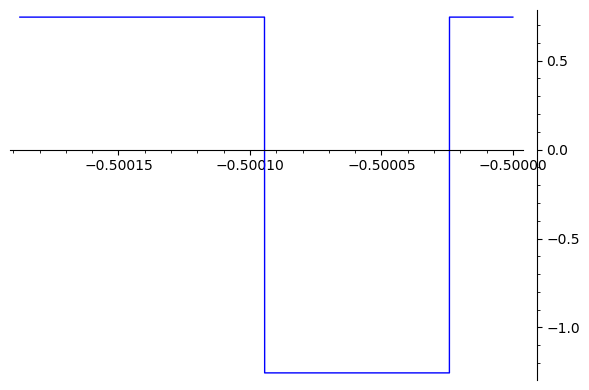

In [365]:
plot(phase_EB_left (x), -h_conductor_l-A, -A)

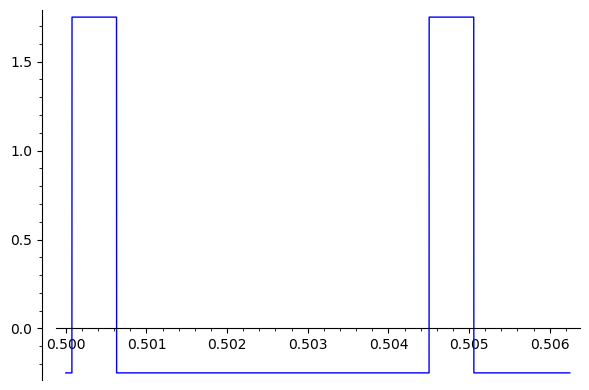

In [366]:
plot(phase_EB_right (x), A, A+h_conductor_r)

Решение получено.

In [367]:
F_I_rotB_conj_l_d = calc_F_I_rotB_conj_l_d(K_left_conductor_qnm_subs_d, digit_values, omega_qnm_sol, coeffs_qnm_subs)
F_P_rotE_conj_l_d = calc_F_P_rotE_conj_l_d(K_left_conductor_qnm_subs_d, digit_values, omaga_qnm_sol, coeffs_qnm_subs)

F_I_rotB_conj_r_d = calc_F_I_rotB_conj_r_d(K_right_conductor_qnm_subs_d, digit_values, omega_qnm_sol, coeffs_qnm_subs)
F_P_rotE_conj_r_d = calc_F_P_rotE_conj_r_d(K_right_conductor_qnm_subs_d, digit_values, omaga_qnm_sol, coeffs_qnm_subs)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

ZeroDivisionError: symbolic division by zero

In [ ]:
F_P_rotE_conj_d = F_P_rotE_conj_l_d + F_P_rotE_conj_r_d
F_P_rotE_conj_d

In [ ]:
F_I_rotB_conj_d = F_I_rotB_conj_l_d + F_I_rotB_conj_r_d
F_I_rotB_conj_d

In [ ]:
def plot_r(expression, y):
    v = []
    s = [(A,0)]
    sum_int = 0

    mn = 0
    mx = h_conductor_r
    st = h_conductor_r / 250

    import numpy as np
    for vx in np.arange(mn, mx+st, st):
        _Wx = expression(x = A + vx, y=y)
        #if not isinstance(_Wx, float) and not isinstance(_Wx, RealField):
        #    _Wx = _Wx.n()
        v += [(A + vx, _Wx)]
        if vx != 0:
            sum_int += (_Wx + _Wx_pre) / 2 * st
            s += [(A + vx, sum_int)]
        #print("x =", vx, "_Wx =", _Wx, "sum_int = ", sum_int)
        _Wx_pre = _Wx

    return v, s, sum_int

In [ ]:
def plot_l(expression, y):
    v = []
    s = [(-A,0)]
    sum_int = 0

    mn = 0
    mx = h_conductor_l
    st = h_conductor_l / 250

    import numpy as np
    for vx in np.arange(mn, mx+st, st):
        _Wx = expression(x = -A - vx, y=y)
        #if not isinstance(_Wx, float) and not isinstance(_Wx, RealField):
        #    _Wx = _Wx.n()
        v += [(-A - vx, _Wx)]
        if vx != 0:
            sum_int += (_Wx + _Wx_pre) / 2 * st
            s += [(-A - vx, sum_int)]
        #print("x =", vx, "_Wx =", _Wx, "sum_int = ", sum_int)
        _Wx_pre = _Wx

    return v, s, sum_int

1) пондеромоторная сила, приложенная к идеальному проводнику

In [ ]:
p_Ht_left_jeH_conj  = calc_p_Ht_left_jeH_conj (K_left_conductor_qnm_subs_d,  digit_values, omega_sol, coeffs_subs)

In [ ]:
print("p_Ht_left_jeH_conj =", p_Ht_left_jeH_conj)

In [ ]:
p_Bt_left_jeB_conj = calc_p_Bt_left_jeB_conj (K_left_conductor_subs_d,  digit_values, omega_sol, coeffs_subs)

print("p_Bt_left_jeB_conj =", p_Bt_left_jeB_conj)

In [ ]:
F_jmD_conj_left  = calc_F_jmD_conj_left (K_left_conductor_subs_d,  digit_values, omega_sol, coeffs_subs)
F_jmD_conj_right = calc_F_jmD_conj_right(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
F_jmD_conj_left, F_jmD_conj_right

2) пондеромоторная сила, приложенная к плохому проводнику

In [ ]:
p_Ht_right_jeH_conj = calc_p_Ht_right_jeH_conj(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)
print("p_Ht_right_jeH_conj =", p_Ht_right_jeH_conj)

In [ ]:
p_Bt_right_jeB_conj = calc_p_Bt_right_jeB_conj (K_right_conductor_subs_d,  digit_values, omega_sol, coeffs_subs)

print("p_Bt_right_jeB_conj =", p_Bt_right_jeB_conj)

In [ ]:
p_Ht_left_conductor + p_Ht_right_conductor

In [ ]:
# skin_force_m_phi
# arg(E/H) = - pi/4 + -2*pi + phi        :  cos(phi) + sin(phi)
# arg(E/H) = - pi/4 + -3/2*pi + phi      :  cos(phi) - sin(phi)
# arg(E/H) = - pi/4 + -pi + phi          : -cos(phi) - sin(phi)
# arg(E/H) = - pi/4 + -1/2*pi + phi      : -cos(phi) + sin(phi)
# arg(E/H) = - pi/4 + phi                :  cos(phi) + sin(phi)
# arg(E/H) = - pi/4 + 1/2*pi + phi       :  cos(phi) - sin(phi)
# arg(E/H) = - pi/4 + pi + phi           : -cos(phi) - sin(phi)
# arg(E/H) = - pi/4 + 3/2*pi + phi       : -cos(phi) + sin(phi)
# arg(E/H) = - pi/4 + 2*pi + phi         :  cos(phi) + sin(phi)

In [ ]:
#                  (- pi/4 + phi)
#                   -1.249875
def get_m_phi(phase_EH):
    # arg(E/H) = - pi/4 + -pi + phi          : -cos(phi) - sin(phi)
    if -1.5 < phase_EH and phase_EH <= -1.0:
        print(f"-1.5 < phase_EH and phase_EH < -1.0 : {phase_EH}")
        print("arg(E/H) = - pi/4 + -pi + phi          : -cos(phi) - sin(phi)")
        phi = +1.25 + phase_EH
        m_phi = (-cos(phi * pi) - sin(phi * pi))

    # arg(E/H) = - pi/4 + -1/2*pi + phi      : -cos(phi) + sin(phi)
    if  -1.0 < phase_EH  and phase_EH <= -0.5:
        print(f"-1.0 < phase_EH  and phase_EH < -0.5 : {phase_EH}")
        print("arg(E/H) = - pi/4 + -1/2*pi + phi      : -cos(phi) + sin(phi)")
        phi = 0.75 + phase_EH
        m_phi  = (-cos(phi  * pi) + sin(phi  * pi))

    # arg(E/H) = - pi/4 + phi                :  cos(phi) + sin(phi)
    if  -0.5 < phase_EH  and phase_EH <= 0:
        print(f"-0.5 < phase_EH  and phase_EH < 0 :  {phase_EH}")
        print("arg(E/H) = - pi/4 + phi                :  cos(phi) + sin(phi)")
        phi = 0.25 + phase_EH
        m_phi  = ( cos(phi  * pi) + sin(phi  * pi))

    # arg(E/H) = - pi/4 + 1/2*pi + phi       :  cos(phi) - sin(phi)
    if  0 < phase_EH  and phase_EH <= 0.5:
        print(f"0 < phase_EH  and phase_EH < 0.5 :  {phase_EH}")
        print("arg(E/H) = - pi/4 + 1/2*pi + phi       :  cos(phi) - sin(phi)")
        phi = -0.25 + phase_EH
        m_phi  = ( cos(phi  * pi) - sin(phi  * pi))

    # arg(E/H) = - pi/4 + pi + phi           : -cos(phi) - sin(phi)
    if  0.5 < phase_EH  and phase_EH <= 1:
        print(f"0.5 < phase_EH  and phase_EH < 1 : {phase_EH}")
        print("arg(E/H) = - pi/4 + pi + phi           : -cos(phi) - sin(phi)")
        phi = -0.75 + phase_EH
        m_phi  = (-cos(phi  * pi) - sin(phi  * pi))

    return phi, m_phi.n(prec=128)

In [ ]:
# "руками подобранный" множитель для p_Ht
# исходя из того что для левого (немагнитный металл) и
# правого (феррит) материала
# знаки этих множителей различны
# это подтверждает идею Каравашкина в статье
# https://karavashkin3.blogspot.com/2025/06/the-reality-of-emdrive-in-terms-of.html
# The Reality of EmDrive in Terms of Discoveries in Electromagnetism

In [ ]:
(p_Ht_left_conductor  * m_phi_EH_left, 
 p_Ht_right_conductor * m_phi_EH_right )

In [ ]:
(p_Ht_left_conductor  * m_phi_EB_left, 
 p_Ht_right_conductor * m_phi_EB_right )

In [ ]:
(p_Ht_left_conductor  * m_phi_EH_left + \
 p_Ht_right_conductor * m_phi_EH_right ).n()

In [ ]:
(p_Ht_left_conductor  * m_phi_EB_left + \
 p_Ht_right_conductor * m_phi_EB_right ).n()


$$\vec{E} = \vec{E}(x, y)\,e^{i\,(k_z + i\,s_z)\,z}\,e^{-i\,\omega\,t}$$


In [ ]:
# Произведём расчёт пондеромоторной силы p_Ht 
# способом аналогичному в skin_force_phi.ipynb
# а именно интегрированием по объёму
# силы взамодействия поверхностных токов Фуко
# с магнитным полем проникшим внутрь материала


In [ ]:
# магнитное поле в проводнике
# Ландау Лифшиц. Электродинамика сплошных сред (59.3)
# H_y(x) = H_0 * exp(-x/delta) * exp(I*(x/delta - omega * t))
# Ландау Лифшиц. Электродинамика сплошных сред (59.6)
# re_H_y(x) = H_0 * exp(-x/delta) * cos(x/delta - omega * t)

# а что если в данном расчете изменится сдвиг фаз между электрическим и магнитным полем?
# re_E_z(x) = H_0 * sqrt(omega/(4*pi*sigma)) * exp(-x/delta) * cos(x/delta - omega * t - pi - pi/4 + phi)

# ток проводимости вызванный электрическим полем
# Ландау Лифшиц. Электродинамика сплошных сред (58.4)
# j_z(x) = sigma * re_E_z(x)
# je_z_l(x) = sigma_e_l_d * (Ez_left_conductor_d (x=x)*exp(-I*omega_t)).real()
# je_z_r(x) = sigma_e_r_d * (Ez_right_conductor_d(x=x)*exp(-I*omega_t)).real()
if is_TM:
    je_z_l(x, y) = sigma_e_l_zz.subs(digit_values) * Ez_left_conductor_d (x=x, y=y)*exp(-I*omega_t)
    je_z_r(x, y) = sigma_e_r_zz.subs(digit_values) * Ez_right_conductor_d(x=x, y=y)*exp(-I*omega_t)
if is_TE:
    je_y_l(x, y) = sigma_e_l_yy.subs(digit_values) * Ey_left_conductor_d (x=x, y=y)*exp(-I*omega_t)
    je_y_r(x, y) = sigma_e_r_yy.subs(digit_values) * Ey_right_conductor_d(x=x, y=y)*exp(-I*omega_t)

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# fe_x(x) = 1 / c * je_z(x) * re_H_y(x)
if is_TM:
    fjeH_x_l(x, y, omega_t) = - 1 / c_d * je_z_l(x=x, y=y) * (Hy_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
    fjeH_x_r(x, y, omega_t) = - 1 / c_d * je_z_r(x=x, y=y) * (Hy_right_conductor_d(x=x, y=y) * exp(-I*omega_t))
if is_TE:
    fjeH_x_l(x, y, omega_t) = + 1 / c_d * je_y_l(x=x, y=y) * (Hz_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
    fjeH_x_r(x, y, omega_t) = + 1 / c_d * je_y_r(x=x, y=y) * (Hz_right_conductor_d(x=x, y=y) * exp(-I*omega_t))

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# fe_x(x) = 1 / c * je_z(x) * re_B_y(x)
if is_TM:
    fjeB_x_l(x, y, omega_t) = - 1 / c_d * je_z_l(x=x, y=y) * (By_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
    fjeB_x_r(x, y, omega_t) = - 1 / c_d * je_z_r(x=x, y=y) * (By_right_conductor_d(x=x, y=y) * exp(-I*omega_t))
if is_TE:
    fjeB_x_l(x, y, omega_t) = + 1 / c_d * je_y_l(x=x, y=y) * (Bz_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
    fjeB_x_r(x, y, omega_t) = + 1 / c_d * je_y_r(x=x, y=y) * (Bz_right_conductor_d(x=x, y=y) * exp(-I*omega_t))

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# fe_x(x) = 1 / c * je_z(x) * re_H_y(x)
# здесь учитываем то
if is_TM:
    fjeH_x_l_rere(x, y, omega_t) = - 1 / c_d * je_z_l(x=x, y=y).real() * ( Hy_left_conductor_d (x=x, y=y) * exp(-I*omega_t)).real()
    fjeH_x_r_rere(x, y, omega_t) = - 1 / c_d * je_z_r(x=x, y=y).real() * ( Hy_right_conductor_d(x=x, y=y) * exp(-I*omega_t)).real()

    fjeH_x_l_conj(x, y, omega_t) = (
                              - 1 / 2 / c_d * je_z_l(x=x, y=y) * conjugate( Hy_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
                              ).real()
    fjeH_x_r_conj(x, y, omega_t) = (
                              - 1 / 2 / c_d * je_z_r(x=x, y=y) * conjugate( Hy_right_conductor_d(x=x, y=y) * exp(-I*omega_t))
                              ).real()
if is_TE:
    fjeH_x_l_rere(x, y, omega_t) = + 1 / c_d * je_y_l(x=x, y=y).real() * ( Hz_left_conductor_d (x=x, y=y) * exp(-I*omega_t)).real()
    fjeH_x_r_rere(x, y, omega_t) = + 1 / c_d * je_y_r(x=x, y=y).real() * ( Hz_right_conductor_d(x=x, y=y) * exp(-I*omega_t)).real()

    fjeH_x_l_conj(x, y, omega_t) = (
                              + 1 / 2 / c_d * je_y_l(x=x, y=y) * conjugate( Hz_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
                              ).real()
    fjeH_x_r_conj(x, y, omega_t) = (
                              + 1 / 2 / c_d * je_y_r(x=x, y=y) * conjugate( Hz_right_conductor_d(x=x, y=y) * exp(-I*omega_t))
                              ).real()

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# fe_x(x) = 1 / c * je_z(x) * re_B_y(x)
# здесь учитываем то
if is_TM:
    fjeB_x_l_rere(x, y, omega_t) = - 1 / c_d * je_z_l(x=x, y=y).real() * ( By_left_conductor_d (x=x, y=y) * exp(-I*omega_t)).real()
    fjeB_x_r_rere(x, y, omega_t) = - 1 / c_d * je_z_r(x=x, y=y).real() * ( By_right_conductor_d(x=x, y=y) * exp(-I*omega_t)).real()

    fjeB_x_l_conj(x, y, omega_t) = (
                              - 1 / 2 / c_d * je_z_l(x=x, y=y) * conjugate( By_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
                              ).real()
    fjeB_x_r_conj(x, y, omega_t) = (
                              - 1 / 2 / c_d * je_z_r(x=x, y=y) * conjugate( By_right_conductor_d(x=x, y=y) * exp(-I*omega_t))
                              ).real()
if is_TE:
    fjeB_x_l_rere(x, y, omega_t) = + 1 / c_d * je_y_l(x=x, y=y).real() * ( Bz_left_conductor_d (x=x, y=y) * exp(-I*omega_t)).real()
    fjeB_x_r_rere(x, y, omega_t) = + 1 / c_d * je_y_r(x=x, y=y).real() * ( Bz_right_conductor_d(x=x, y=y) * exp(-I*omega_t)).real()

    fjeB_x_l_conj(x, y, omega_t) = (
                              + 1 / 2 / c_d * je_y_l(x=x, y=y) * conjugate( Bz_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
                              ).real()
    fjeB_x_r_conj(x, y, omega_t) = (
                              + 1 / 2 / c_d * je_y_r(x=x, y=y) * conjugate( Bz_right_conductor_d(x=x, y=y) * exp(-I*omega_t))
                              ).real()

In [ ]:
# усредняем по периоду колебаний
# F_x(x) = (1/(2*pi))*integrate(fe_x(x), (omega_t, 0, 2*pi))
# display(Math(latex(F_x(x))))

In [ ]:
# интегрируем по глубине
#int_fe_x(x, omega_t) = integrate(fe_x(x, omega_t), x)

In [ ]:
# интегрируем по глубине
#int_F_x(x) = integrate(F_x(x), x)

In [ ]:
from scipy import integrate as scipy_integrate
opts = {'epsabs': 1e-15, 'epsrel': 1e-12, 'limit': 200}

In [ ]:
# усредняем по периоду колебаний
fjeH_l = lambda x, y : scipy_integrate.quad( \
    lambda _omega_t_ : \
        real128(fjeH_x_l_conj(x = x, y = y, omega_t = _omega_t_)), \
            0, real128(2*pi))[0] / real128(2*pi)

In [ ]:
# усредняем по периоду колебаний
fjeB_l = lambda x, y : scipy_integrate.quad( \
    lambda _omega_t_ : \
        real128(fjeB_x_l_conj(x = x, y = y, omega_t = _omega_t_)), \
            0, real128(2*pi))[0] / real128(2*pi)

In [ ]:
# усредняем по периоду колебаний
fjeH_r = lambda x, y : scipy_integrate.quad( \
    lambda _omega_t_ : \
        real128(fjeH_x_r_conj(x = x, y = y, omega_t = _omega_t_)), \
            0, real128(2*pi))[0] / real128(2*pi)

In [ ]:
# усредняем по периоду колебаний
fjeB_r = lambda x, y : scipy_integrate.quad( \
    lambda _omega_t_ : \
        real128(fjeB_x_r_conj(x = x, y = y, omega_t = _omega_t_)), \
            0, real128(2*pi))[0] / real128(2*pi)

In [ ]:
fjeH_l(x=-A), fjeH_l(x=-A-h_conductor_l)

In [ ]:
fjeB_l(x=-A), fjeB_l(x=-A-h_conductor_l)

In [ ]:
fjeH_r(x=A), fjeH_r(x=A+h_conductor_r)

In [ ]:
fjeB_r(x=A), fjeB_r(x=A+h_conductor_r)

In [ ]:
fjeHr_x, sfjeHr_x, sum_int_fjeHr = plot_r(fjeH_r)

In [ ]:
fjeBr_x, sfjeBr_x, sum_int_fjeBr = plot_r(fjeB_r)

In [ ]:
fjeHl_x, sfjeHl_x, sum_int_fjeHl = plot_l(fjeH_l)

In [ ]:
fjeBl_x, sfjeBl_x, sum_int_fjeBl = plot_l(fjeB_l)

In [ ]:
list_plt_fjeHr_x = list_plot(fjeHr_x)
list_plt_sfjeHr_x = list_plot(sfjeHr_x)

In [ ]:
list_plt_fjeBr_x = list_plot(fjeBr_x)
list_plt_sfjer_x = list_plot(sfjeBr_x)

In [ ]:
list_plt_fjeHl_x = list_plot(fjeHl_x)
list_plt_sfjeHl_x = list_plot(sfjeHl_x)

In [ ]:
list_plt_fjeBl_x = list_plot(fjeBl_x)
list_plt_sfjeBl_x = list_plot(sfjeBl_x)

In [ ]:
if make_investigation_plots:
    (list_plt_fjeHr_x).show(title = "сила действующая на ток Фуко со стороны магнитного поля,\n проникшего в правый проводник\n")

In [ ]:
if make_investigation_plots:
    (list_plt_fjeBr_x).show(title = "сила действующая на ток Фуко со стороны магнитного поля,\n проникшего в правый проводник\n")

In [ ]:
if make_investigation_plots:
    (list_plt_fjeHl_x).show(title = "сила действующая на ток Фуко со стороны магнитного поля,\n проникшего в левый проводник\n")

In [ ]:
if make_investigation_plots:
    (list_plt_fjeBl_x).show(title = "сила действующая на ток Фуко со стороны магнитного поля,\n проникшего в левый проводник\n")

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# усредняем по периоду колебаний
# и интегрируем по глубине
FjeHl_conj = scipy_integrate.nquad( \
    lambda _x_, _omega_t_ : \
        real128(fjeH_x_l_conj(x = _x_, omega_t = _omega_t_)), \
            [[real128(-A-h_conductor_l), -real128(A)], [0, real128(2*pi)]])[0] / real128(2*pi)

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# усредняем по периоду колебаний
# и интегрируем по глубине
FjeBl_conj = scipy_integrate.nquad( \
    lambda _x_, _omega_t_ : \
        real128(fjeB_x_l_conj(x = _x_, omega_t = _omega_t_)), \
            [[real128(-A-h_conductor_l), -real128(A)], [0, real128(2*pi)]])[0] / real128(2*pi)

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# усредняем по периоду колебаний
# и интегрируем по глубине
FjeHr_conj = scipy_integrate.nquad( \
    lambda _x_, _omega_t_ : \
        real128(fjeH_x_r_conj(x = _x_, omega_t = _omega_t_)), \
            [[real128(A), real128(A +h_conductor_r)],[0, real128(2*pi)]])[0] / real128(2*pi)

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# усредняем по периоду колебаний
# и интегрируем по глубине
FjeBr_conj = scipy_integrate.nquad( \
    lambda _x_, _omega_t_ : \
        real128(fjeB_x_r_conj(x = _x_, omega_t = _omega_t_)), \
            [[real128(A), real128(A +h_conductor_r)],[0, real128(2*pi)]])[0] / real128(2*pi)

In [ ]:
t_I_conv_Hn_left  = calc_t_I_conv_Hn_left_conductor (Hx_vacuum_d, digit_values)
t_I_conv_Hn_right = calc_t_I_conv_Hn_right_conductor(Hx_vacuum_d, digit_values)

In [ ]:
p_Bt_left_jeB_conj  = calc_p_Bt_left_jeB_conj (K_left_conductor_subs_d,  digit_values, omega_sol, coeffs_subs)
p_Bt_right_jeB_conj = calc_p_Bt_right_jeB_conj(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs)

p_I_conv_Ht_left    = calc_p_I_conv_Ht_left_conductor (Hy_vacuum_d, Hz_vacuum_d, digit_values)
p_I_conv_Ht_right   = calc_p_I_conv_Ht_right_conductor(Hy_vacuum_d, Hz_vacuum_d, digit_values)

In [ ]:
t_I_conv_Hn_left, t_I_conv_Hn_right

In [ ]:
t_I_conv_Hn_left + t_I_conv_Hn_right

In [ ]:
sum_int_fjeHl, sum_int_fjeHr

In [ ]:
sum_int_fjeBl, sum_int_fjeBr

### интеграл усреднённой по периоду силы действующей на ток проводимости со стороны магнитного поля


In [ ]:
# численный интеграл комплексно сопряжённого произведения
FjeHl_conj, FjeHr_conj

In [ ]:
# численный интеграл комплексно сопряжённого произведения
FjeBl_conj, FjeBr_conj

In [ ]:
# аналитический интеграл комплексно сопряжённого произведения
p_Ht_left_jeH_conj, p_Ht_right_jeH_conj

In [ ]:
# давление тангенциального магнитного поля на проводник, книжная формула H^2/16pi
(p_Ht_left_conductor), (p_Ht_right_conductor)

In [ ]:
# Static and dynamic electricity by William R. Smythe, second edition, 1950
# paragraph 18 formula 1.47
# давление на границу равно разности давлений по обе стороны от нее
# $$ P_n = \frac{1}{2} \epsilon'{{E'}_t}^2 - \frac{1}{2} \epsilon''{{E''}_t}^2 $$

$$ P_n = \frac{1}{2} \epsilon'{{E'}_t}^2 - \frac{1}{2} \epsilon''{{E''}_t}^2 $$

In [ ]:
# bad conductor force
# additional 1/2 arises as result of integration on period
p_Et_left_conductor = calc_p_Et_left_conductor_conj(Ez_vacuum_d, Ey_vacuum_d, digit_values)
print("p_Et_left_conductor =", p_Et_left_conductor)

In [ ]:
# bad conductor force
# additional 1/2 arises as result of integration on period
p_Et_right_conductor = calc_p_Et_right_conductor_conj(Ez_vacuum_d, Ey_vacuum_d, digit_values)
print("p_Et_right_conductor =", p_Et_right_conductor)

In [ ]:
# Static and dynamic electricity by William R. Smythe, second edition, 1950
# paragraph 18 formula 1.45
# натяжение на границе, созданное нормальными компонентами индукции
# должно равняться разности натяжений по обе стороны от границы
# $$ T_n = \frac{{{D'}_n}^2}{2 \epsilon'} - \frac{{{D''}_n}^2}{2 \epsilon''} $$

$$ T_n = \frac{{{D'}_n}^2}{2 \epsilon'} - \frac{{{D''}_n}^2}{2 \epsilon''} $$

In [ ]:
# super conductor tension
# additional 1/2 arises as result of integration on period
# epsilon_superconductor -> Infinity
# 1 / epsilon_superconductor -> 0.0

t_Dn_left_conductor = calc_t_Dn_left_conductor_conj(Ex_left_conductor_d, digit_values)
print("t_Dn_left_conductor =", t_Dn_left_conductor.n(prec=128))

In [ ]:
# super conductor tension
# additional 1/2 arises as result of integration on period
# epsilon_superconductor -> Infinity
# 1 / epsilon_superconductor -> 0.0

t_Dn_left_conductor = calc_t_Dn_left_conductor(Dx_left_conductor_d, Dx_vacuum_d, digit_values)
print("t_Dn_left_conductor =", t_Dn_left_conductor.n())

In [ ]:
# bad conductor force
# additional 1/2 arises as result of integration on period
t_Dn_right_conductor = (((1.0/1.0 - 1/epsilon_r_xx_complex)*Dx_vacuum_d (x=A)) * Dx_vacuum_d(x=A)/(2*8*pi)).subs(digit_values).abs()
print("t_Dn_right_conductor =", t_Dn_right_conductor.n())

In [ ]:
# bad conductor force
# additional 1/2 arises as result of integration on period
t_Dn_right_conductor = calc_t_Dn_right_conductor(Dx_right_conductor_d, Dx_vacuum_d, digit_values)
print("t_Dn_right_conductor =", t_Dn_right_conductor.n())

Результаты вычислений показывают, что тяга в волновом двигателе с внутренним расходом энергии Ф.Ф.Менде (MenDrive) ненулевая и равна

In [ ]:
((+ p_Ht_left_conductor + p_Ht_right_conductor) +
 (+ t_Dn_left_conductor + t_Dn_right_conductor) )

In [ ]:
((+ p_Ht_left_conductor + p_Ht_right_conductor) +
 (+ t_Dn_left_conductor + t_Dn_right_conductor) +
 (+ p_Et_left_conductor + p_Et_right_conductor)
)

In [ ]:
(
 (+ F_P_conj_l_d + F_P_conj_r_d)
)

In [ ]:
(
 (+ F_I_conj_l_d + F_I_conj_r_d)
)

In [ ]:
(+ t_I_conv_Hn_left + t_I_conv_Hn_right)

In [ ]:
(
 (+ F_P_conj_l_d + F_P_conj_r_d) +
 (+ F_I_conj_l_d + F_I_conj_r_d)
)

In [ ]:
(
 (+ t_I_conv_Hn_left + t_I_conv_Hn_right) +
 (+ F_P_conj_l_d + F_P_conj_r_d) +
 (+ F_I_conj_l_d + F_I_conj_r_d)
)

In [ ]:
(
 (+ p_Ht_left_conductor + p_Ht_right_conductor) +
 (+ t_Dn_left_conductor + t_Dn_right_conductor) +
 (+ p_Et_left_conductor + p_Et_right_conductor) +
 (+ t_I_conv_Hn_left    + t_I_conv_Hn_right) +
 (+ F_P_conj_l_d        + F_P_conj_r_d) +
 (+ F_I_conj_l_d        + F_I_conj_r_d)
)

In [ ]:
f_dyne_full_left = (
    + F_jmD_conj_left
    + p_Bt_left_jeB_conj
    + p_I_conv_Ht_left
    + t_I_conv_Hn_left
    + F_I_conj_l_d
    + t_Dn_left_conductor
    + p_Et_left_conductor
    + F_P_conj_l_d
)

f_dyne_full_left

In [ ]:
f_dyne_full_right = (
    + F_jmD_conj_right
    + p_Bt_right_jeB_conj
    + p_I_conv_Ht_right
    + t_I_conv_Hn_right
    + F_I_conj_r_d
    + t_Dn_right_conductor
    + p_Et_right_conductor
    + F_P_conj_r_d
)

f_dyne_full_right

In [ ]:
f_dyne_full = (
    + F_jmD_conj_left     + F_jmD_conj_right
    + p_Bt_left_jeB_conj  + p_Bt_right_jeB_conj
    + p_I_conv_Ht_left    + p_I_conv_Ht_right
    + t_I_conv_Hn_left    + t_I_conv_Hn_right
    + F_I_conj_l_d + F_I_conj_r_d
    + t_Dn_left_conductor + t_Dn_right_conductor
    + p_Et_left_conductor + p_Et_right_conductor
    + F_P_conj_l_d + F_P_conj_r_d
)

f_dyne_full

In [ ]:
(
    + F_jmD_conj_left,     + F_jmD_conj_right,
    + p_Bt_left_jeB_conj,  + p_Bt_right_jeB_conj,
    + p_I_conv_Ht_left,    + p_I_conv_Ht_right,
    + t_I_conv_Hn_left ,   + t_I_conv_Hn_right,
    + F_I_conj_l_d, + F_I_conj_r_d,
    + t_Dn_left_conductor, + t_Dn_right_conductor,
    + p_Et_left_conductor, + p_Et_right_conductor,
    + F_P_conj_l_d, + F_P_conj_r_d,
)

In [ ]:
f_dyne_F_jm = + F_jmD_conj_left     + F_jmD_conj_right
f_dyne_p_Bt = + p_Bt_left_jeB_conj  + p_Bt_right_jeB_conj
f_dyne_p_I  = + p_I_conv_Ht_left    + p_I_conv_Ht_right
f_dyne_t_I  = + t_I_conv_Hn_left    + t_I_conv_Hn_right
f_dyne_F_I  = + F_I_conj_l_d        + F_I_conj_r_d
f_dyne_t_Dn = + t_Dn_left_conductor + t_Dn_right_conductor
f_dyne_p_Et = + p_Et_left_conductor + p_Et_right_conductor
f_dyne_F_P  = + F_P_conj_l_d        + F_P_conj_r_d

In [ ]:
f_dyne_F_jm, \
f_dyne_p_Bt, \
f_dyne_p_I, \
f_dyne_t_I, \
f_dyne_F_I, \
f_dyne_t_Dn, \
f_dyne_p_Et, \
f_dyne_F_P

In [ ]:
# H^2/8 pi

In [ ]:
# тяга суммарного давления
# тангенциальной компоненты магнитного поля
# по книжным формулам
(+ p_Ht_left_conductor + p_Ht_right_conductor)

In [ ]:
# тяга суммарного давления
# тангенциальной компоненты магнитного поля
# с учётом сдвига фаз
# численный интеграл комплексно сопряжённого произведения
(FjeHl_conj + FjeHr_conj)

In [ ]:
# тяга суммарного давления
# тангенциальной компоненты магнитного поля
# с учётом сдвига фаз
# численный интеграл комплексно сопряжённого произведения
(FjeBl_conj + FjeBr_conj)

In [ ]:
# тяга суммарного давления
# тангенциальной компоненты магнитного поля
# с учётом сдвига фаз аналитически
(p_Ht_left_jeH_conj + p_Ht_right_jeH_conj)

In [ ]:
# тяга суммарного давления
# тангенциальной компоненты магнитного поля
# с учётом сдвига фаз аналитически
(p_Bt_left_jeB_conj + p_Bt_right_jeB_conj)

In [ ]:
# тяга суммарного давления
# тангенциальной компоненты магнитного поля
# с учётом сдвига фаз численно
FjeHl_conj + FjeHr_conj

In [ ]:
# тяга суммарного давления
# тангенциальной компоненты магнитного поля
# с учётом сдвига фаз численно
FjeBl_conj + FjeBr_conj

In [ ]:
(+ t_Dn_left_conductor + t_Dn_right_conductor)

In [ ]:
(+ p_Et_left_conductor + p_Et_right_conductor)

In [ ]:
+ p_Et_left_conductor, + p_Et_right_conductor

In [ ]:
wr_x, sr_x, sum_int_r = plot_r(lambda x : wr(Ex_right_conductor_d, Ey_right_conductor_d, Ez_right_conductor_d, digit_values, x=x))

In [ ]:
wl_x, sl_x, sum_int_l = plot_l(lambda x : wl(Ex_left_conductor_d, Ey_left_conductor_d, Ez_left_conductor_d, digit_values, x=x))

In [ ]:
list_plt_wr_x = list_plot(wr_x)
list_plt_sr_x = list_plot(sr_x)

In [ ]:
list_plt_wl_x = list_plot(wl_x)
list_plt_sl_x = list_plot(sl_x)

In [ ]:
if make_investigation_plots:
    plt_wr = plot(wr(Ex_right_conductor_d, Ey_right_conductor_d, Ez_right_conductor_d, digit_values, x=x), (x, A, A+h_conductor_r))
    (list_plt_wr_x + plt_wr).show()

if make_investigation_plots:
    plt_wl = plot(wl(Ex_left_conductor_d, Ey_left_conductor_d, Ez_left_conductor_d, digit_values, x=x), (x, -A-h_conductor_l, -A))
    (list_plt_wl_x + plt_wl).show()

In [ ]:
if make_investigation_plots:
    Wr_integrate_x = wr(Ex_right_conductor_d, Ey_right_conductor_d, Ez_right_conductor_d, digit_values, x=x).integrate(x)
    Wl_integrate_x = wl(Ex_left_conductor_d, Ey_left_conductor_d, Ez_left_conductor_d, digit_values, x=x).integrate(x)

In [ ]:
if make_investigation_plots:
    (list_plt_sr_x + plot(Wr_integrate_x - Wr_integrate_x.subs(x == A), (x, A, A+h_conductor_r))).show()

if make_investigation_plots:
    (list_plt_sl_x + plot(-Wl_integrate_x + Wl_integrate_x.subs(x == -A), (x, -A-h_conductor_l, -A))).show()

In [ ]:
plot(Wr_integrate_x, (x, A, A+h_conductor_r))

In [ ]:
plot(Wl_integrate_x, (x, -A-h_conductor_l, -A))

In [ ]:
W_r =  Wr_integrate_x.subs(x == A+h_conductor_r).n() - Wr_integrate_x.subs(x == A+0).n()
W_l = -Wl_integrate_x.subs(x == -A-h_conductor_l).n() + Wl_integrate_x.subs(x == -A+0).n()
W_l, W_r

In [ ]:
if make_investigation_plots:
    W_r = Wr_integrate_x.subs(x == A+h_conductor_r).n() - Wr_integrate_x.subs(x == A+0).n()
    print(sum_int_r.n(prec=128), W_r, sum_int_r.n(prec=128) / W_r)
else:
    W_r = sum_int_r.n(prec=128)
    print(W_r)

In [ ]:
if make_investigation_plots:
    W_l = -Wl_integrate_x.subs(x == -A-h_conductor_l).n() + Wl_integrate_x.subs(x == -A+0).n()
    print(sum_int_l.n(prec=128), W_l, sum_int_l.n(prec=128) / W_l)
else:
    W_l = sum_int_l.n(prec=128)
    print(W_l)

In [ ]:
W = W_r + W_l
W, W_l, W_r

In [ ]:
# F / P
# dyne / (erg/s)

# 1 erg  = 10^-7 joule
# 1 dyne = 10^-5 N

# 1 dyne / (erg/s) = 10^-5 / (10^-7) = 100 N/watt = 10^5 N/kwatt

интеграл усреднённой по периоду силы действующей на ток проводимости со стороны магнитного поля

In [ ]:
# компонент тяги - давление тангенциального магнитного поля на левый проводник, книжная формула H^2/16pi
N_kwatt_p_Ht_left = 10^5*(+ p_Ht_left_conductor)/(W)
N_kwatt_p_Ht_left

In [ ]:
# компонент тяги - давление тангенциального магнитного поля на правый проводник, книжная формула H^2/16pi
N_kwatt_p_Ht_right = 10^5*(+ p_Ht_right_conductor)/(W)
N_kwatt_p_Ht_right

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника, книжная формула H^2/16pi
N_kwatt_p_Ht = 10^5*(+ p_Ht_left_conductor \
                     + p_Ht_right_conductor)/(W)
N_kwatt_p_Ht

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# аналитический интеграл комплексно сопряжённого произведения
N_kwatt_p_Ht_jeH_conj = 10^5*(+ p_Ht_left_jeH_conj \
                              + p_Ht_right_jeH_conj)/(W)
N_kwatt_p_Ht_jeH_conj

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# аналитический интеграл комплексно сопряжённого произведения
N_kwatt_p_Bt_jeB_conj = 10^5*(+ p_Bt_left_jeB_conj \
                              + p_Bt_right_jeB_conj)/(W)
N_kwatt_p_Bt_jeB_conj

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# с учётом сдвига фаз
# численный интеграл комплексно сопряжённого произведения
N_kwatt_p_Ht_FjeH_conj = 10^5*(FjeHl_conj + FjeHr_conj)/(W)
N_kwatt_p_Ht_FjeH_conj

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# с учётом сдвига фаз
# численный интеграл комплексно сопряжённого произведения
N_kwatt_p_Ht_FjeB_conj = 10^5*(FjeBl_conj + FjeBr_conj)/(W)
N_kwatt_p_Ht_FjeB_conj

In [ ]:
#TODO: investigate sign is not correct

# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# книжная формула H^2/16pi с учётом попраки на сдвиг фаз
N_kwatt_p_Ht_phi_EH = 10^5*(+ p_Ht_left_conductor  * m_phi_EH_left \
                            + p_Ht_right_conductor * m_phi_EH_right).n(prec=128)/(W)
N_kwatt_p_Ht_phi_EH

In [ ]:
#TODO: investigate sign is not correct

# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# книжная формула H^2/16pi с учётом попраки на сдвиг фаз
N_kwatt_p_Ht_phi_EB = 10^5*(+ p_Ht_left_conductor  * m_phi_EB_left \
                            + p_Ht_right_conductor * m_phi_EB_right).n(prec=128)/(W)
N_kwatt_p_Ht_phi_EB

In [ ]:
# компонент тяги - сумма давления нормальной компоненты электрического смещения на оба проводника,
# книжная формула из электростатики Смайта

N_kwatt_t_Dn = 10^5*(+ t_Dn_left_conductor \
                     + t_Dn_right_conductor).n()/(W)
N_kwatt_t_Dn

In [ ]:
# компонент тяги - давления тангенциальной компоненты электрического поля на левый проводник,
# книжная формула из электростатики Смайта

N_kwatt_p_Et_left = 10^5*(+ p_Et_left_conductor ).n()/(W)
N_kwatt_p_Et_left

In [ ]:
# компонент тяги - давления тангенциальной компоненты электрического поля на правый проводник,
# книжная формула из электростатики Смайта

N_kwatt_p_Et_right = 10^5*(+ p_Et_right_conductor).n()/(W)
N_kwatt_p_Et_right

In [ ]:
# компонент тяги - сумма давления тангенциальной компоненты электрического поля на оба проводника,
# книжная формула из электростатики Смайта

N_kwatt_p_Et = 10^5*(+ p_Et_left_conductor \
                     + p_Et_right_conductor).n()/(W)
N_kwatt_p_Et

In [ ]:
# N/kwatt

In [ ]:
# суммарная тяга к левому проводнику
# по книжным формулам без учёта сдвига фаз

N_kwatt_left_full = 10^5*(
    + F_jmD_conj_left
    + p_Bt_left_jeB_conj
    + p_I_conv_Ht_left
    + t_I_conv_Hn_left
    + F_I_conj_l_d
    + t_Dn_left_conductor
    + p_Et_left_conductor
    + F_P_conj_l_d
).n()/(W)

N_kwatt_left_full

In [ ]:
# суммарная тяга к правому проводнику
# по книжным формулам без учёта сдвига фаз

N_kwatt_right_full = 10^5 * (
    + F_jmD_conj_right
    + p_Bt_right_jeB_conj
    + p_I_conv_Ht_right
    + t_I_conv_Hn_right
    + F_I_conj_r_d
    + t_Dn_right_conductor
    + p_Et_right_conductor
    + F_P_conj_r_d
).n()/(W)

N_kwatt_right_full

In [ ]:
# суммарная тяга
# по книжным формулам без учёта сдвига фаз
N_kwatt = 10^5 * (
    + p_Ht_left_conductor + p_Ht_right_conductor
    + t_Dn_left_conductor + t_Dn_right_conductor
    + p_Et_left_conductor + p_Et_right_conductor
    + t_I_conv_Hn_left + t_I_conv_Hn_right
    + F_P_conj_l_d + F_P_conj_r_d
    + F_I_conj_l_d + F_I_conj_r_d
).n()/(W)

N_kwatt

In [ ]:
# суммарная тяга
# по книжным формулам но по магнитному полю с аналитическим учётом сдвига фаз
N_kwatt_jeH_conj = 10^5 * (
    + p_Ht_left_jeH_conj + p_Ht_right_jeH_conj
    + t_Dn_left_conductor + t_Dn_right_conductor
    + p_Et_left_conductor + p_Et_right_conductor
    + t_I_conv_Hn_left + t_I_conv_Hn_right
    + F_P_conj_l_d + F_P_conj_r_d
    + F_I_conj_l_d + F_I_conj_r_d
).n()/(W)

N_kwatt_jeH_conj

In [ ]:
# суммарная тяга
# по книжным формулам но по магнитному полю с аналитическим учётом сдвига фаз
N_kwatt_jeB_conj = 10^5 * (
    + p_Bt_left_jeB_conj  + p_Bt_right_jeB_conj
    + t_Dn_left_conductor + t_Dn_right_conductor
    + p_Et_left_conductor + p_Et_right_conductor
    + t_I_conv_Hn_left    + t_I_conv_Hn_right
    + F_P_conj_l_d        + F_P_conj_r_d
    + F_I_conj_l_d        + F_I_conj_r_d
).n()/(W)

N_kwatt_jeB_conj

In [ ]:
# суммарная тяга
# по книжным формулам но по магнитному полю с численным учётом сдвига фаз
N_kwatt_FjeH_conj = 10^5 * (
    + FjeHl_conj          + FjeHr_conj
    + t_Dn_left_conductor + t_Dn_right_conductor
    + p_Et_left_conductor + p_Et_right_conductor
    + t_I_conv_Hn_left    + t_I_conv_Hn_right
    + F_P_conj_l_d        + F_P_conj_r_d
    + F_I_conj_l_d        + F_I_conj_r_d
).n()/(W)

N_kwatt_FjeH_conj

In [ ]:
# суммарная тяга
# по книжным формулам но по магнитному полю с численным учётом сдвига фаз
N_kwatt_FjeB_conj = 10^5 * (
    + FjeBl_conj          + FjeBr_conj
    + p_I_conv_Ht_left    + p_I_conv_Ht_right
    + t_I_conv_Hn_left    + t_I_conv_Hn_right
    + F_I_conj_l_d        + F_I_conj_r_d
    + t_Dn_left_conductor + t_Dn_right_conductor
    + p_Et_left_conductor + p_Et_right_conductor
    + F_P_conj_l_d        + F_P_conj_r_d
).n()/(W)

N_kwatt_FjeB_conj

In [ ]:
N_kwatt_full = 10^5 * (
    + F_jmD_conj_left     + F_jmD_conj_right
    + p_Bt_left_jeB_conj  + p_Bt_right_jeB_conj
    + p_I_conv_Ht_left    + p_I_conv_Ht_right
    + t_I_conv_Hn_left    + t_I_conv_Hn_right
    + F_I_conj_l_d        + F_I_conj_r_d
    + t_Dn_left_conductor + t_Dn_right_conductor
    + p_Et_left_conductor + p_Et_right_conductor
    + F_P_conj_l_d        + F_P_conj_r_d
).n()/(W)

N_kwatt_full

положительный знак соответствует направлению тяги в сторону увеличения значений x

In [ ]:
#Propulsion and Energy Forum
#July 28-30, 2014, Cleveland, OH
#50th AIAA/ASME/SAE/ASEE Joint Propulsion Conference
#Anomalous Thrust Production from an RF Test Device
#Measured on a Low-Thrust Torsion Pendulum
#David A. Brady * , Harold G. White † , Paul March ‡ , James T. Lawrence § , and Frank J. Davies **
#NASA Lyndon B. Johnson Space Center, Houston, Texas 77058


#Tapered Cavity RF Evaluation and Testing, TE012 mode
#Prior to the TM211 evaluations, COMSOL® analysis indicated that the TE012 was an effective thrust generation
#mode for the tapered cavity thruster being evaluated, so this mode was explored early in the evaluation process.
#Figure 22 shows a test run at the TE012 mode with an operating frequency of 1880.4 MHz. The measured quality
#factor was ~22,000, with a COMSOL prediction of 21,817. The measured power applied to the test article was
#measured to be 2.6 watts, and the (net) measured thrust was 55.4 micronewtons. With an input power of 2.6 watts,
#correcting for the quality factor, the predicted thrust is 50 micronewtons. However, since the TE012 mode had
#numerous other RF modes in very close proximity, it was impractical to repeatedly operate the system in this mode,
#so the decision was made to evaluate the TM211 modes instead.

#E. Tapered Cavity Testing: Summary of Results
# Mode 
# Frequency (MHz)
# Quality Factor, Q 

# Input Power (W) 
# Peak Thrust (μN) 
# Mean Thrust (μN) 
# Number of Test Runs
# TM211 1932.6   7320  16.9  116.0   91.2  5
# TM211 1936.7 18,100  16.7   54.1   50.1  2
# TE012 1880.4 22,000   2.6   55.4   55.4  1

# Harrington, Roger F. (1961). Time-Harmonic Electromagnetic Fields. McGraw-Hill. ISBN 9780070267459.

# EEE TRANSACTIONS ON MICROWAVE THEORY AND TECHNIQUES, VOL. 54, NO. 4, APRIL 2006
# Two-Resonator Method for Measurement of Dielectric Anisotropy in Multilayer SamplesPlamen I. Dankov, Member, IEEE
# https://www.researchgate.net/publication/3131333_Two-resonator_method_for_measurement_of_dielectric_anisotropy_in_multilayer_samples

In [ ]:
# they have obtained
# 0,005396449704142
# 0,003
# 0,0213076923076923
# N/kwatt

# test found solution with Maxwell equations

$$rot\,\vec{E} = \mu\,\frac{i\,\omega}{c}\,\vec{H}$$

$$rot\,\vec{H} = \frac{1}{c}\frac{\partial \vec D}{\partial t} + \frac{4\pi}{c} \vec j = - \frac{i\,\omega}{c} \epsilon \vec{E} + \frac{4\pi}{c}\sigma \vec E$$

$$rot\,rot\,\vec{E} = \mu\,\frac{i\,\omega}{c}rot\,\vec{H}$$

$$rot\,rot\,\vec{E} = \mu\,\frac{i\,\omega}{c}\left(- \frac{i\,\omega}{c} \epsilon \vec{E} + \frac{4\pi}{c}\sigma \vec E\right)$$

$$rot\,rot\,\vec{E} = \epsilon \mu\,\frac{\omega^2}{c^2} \vec{E} + i\,\omega\,\sigma\,\mu\,\frac{4\pi}{c^2} \vec E$$

$$rot\,rot\,\vec{E} = grad\,div\,\vec{E} - Laplasian\,\vec{E}$$

$$Laplasian\,\vec{E} + \epsilon \mu \frac{\omega^2}{c^2}\,\vec{E} + i\,\omega\,\sigma\,\mu\,\frac{4\pi}{c^2} \vec E - grad\,div\,\vec{E} = 0$$

In [ ]:
# уравнение Максвелла для тока смещения
# rot_H   = - I * epsilon * omega / c * E
# rot_H_x = diff(H_z, y) - diff(H_y, z)
# rot_H_y = diff(H_x, z) - diff(H_z, x)
# rot_H_z = diff(H_y, x) - diff(H_x, y)

In [ ]:
rot_H_vacuum_x_d = diff(Hz_vacuum_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_sol) \
                 - diff(Hy_vacuum_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_sol)
rot_H_vacuum_y_d = diff(Hx_vacuum_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_sol) \
                 - diff(Hz_vacuum_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_sol)
rot_H_vacuum_z_d = diff(Hy_vacuum_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_sol) \
                 - diff(Hx_vacuum_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_sol)

In [ ]:
eq_rot_H_vacuum_x_d = (rot_H_vacuum_x_d == -I*omega/c*Ex_vacuum_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_sol).subs(digit_values)

In [ ]:
eq_rot_H_vacuum_y_d = (rot_H_vacuum_y_d == -I*omega/c*Ey_vacuum_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_sol).subs(digit_values)

In [ ]:
eq_rot_H_vacuum_z_d = (rot_H_vacuum_z_d == -I*omega/c*Ez_vacuum_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_sol).subs(digit_values)

In [ ]:
def plot_eq_rot(eq_rot, limits):
    plt  = plot(eq_rot.lhs().real().subs(z == 0), limits, color="red", thickness=5)
    plt += plot(eq_rot.rhs().real().subs(z == 0), limits, thickness=2)
    plt += plot(eq_rot.lhs().imag().subs(z == 0), limits, color="green", thickness=5)
    plt += plot(eq_rot.rhs().imag().subs(z == 0), limits, thickness=2)
    plt.show()

In [ ]:
plot_eq_rot(eq_rot_H_vacuum_x_d, (x, -A, A))

In [ ]:
plot_eq_rot(eq_rot_H_vacuum_y_d, (x, -A, A))

In [ ]:
plot_eq_rot(eq_rot_H_vacuum_z_d, (x, -A, A))

$$rot\,\vec{H} = \frac{1}{c}\frac{\partial \vec D}{\partial t} + \frac{4\pi}{c} \vec j = - \frac{i\,\omega}{c} \epsilon \vec{E} + \frac{4\pi}{c}\sigma \vec E$$

In [ ]:
# уравнение Максвелла для тока смещения
# rot_H   = - I * epsilon * omega / c * E + 4 * pi / c * sigma * E
# rot_H_x = diff(H_z, y) - diff(H_y, z)
# rot_H_y = diff(H_x, z) - diff(H_z, x)
# rot_H_z = diff(H_y, x) - diff(H_x, y)

In [ ]:
rot_H_left_conductor_x_d = diff(Hz_left_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_sol) \
                         - diff(Hy_left_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_sol)
rot_H_left_conductor_y_d = diff(Hx_left_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_sol) \
                         - diff(Hz_left_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_sol)
rot_H_left_conductor_z_d = diff(Hy_left_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_sol) \
                         - diff(Hx_left_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_sol)

In [ ]:
rot_H_right_conductor_x_d = diff(Hz_right_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_sol) \
                          - diff(Hy_right_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_sol)
rot_H_right_conductor_y_d = diff(Hx_right_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_sol) \
                          - diff(Hz_right_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_sol)
rot_H_right_conductor_z_d = diff(Hy_right_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_sol) \
                          - diff(Hx_right_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_sol)

In [ ]:
eq_rot_H_left_conductor_x_d = rot_H_left_conductor_x_d == \
    ((-I*epsilon_l_xx_complex*omega/c) * Ex_left_conductor_d(x=x)*e^(I*k_z*z)) \
    .subs(k_subs).subs(omega_sol).subs(digit_values).subs(z == 0)

In [ ]:
eq_rot_H_right_conductor_x_d = (rot_H_right_conductor_x_d == 
    (-I*epsilon_r_xx_complex*omega/c) * Ex_right_conductor_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_sol).subs(digit_values).subs(z == 0)

In [ ]:
eq_rot_H_left_conductor_y_d = rot_H_left_conductor_y_d == \
    ((-I*epsilon_l_yy_complex*omega/c) * Ey_left_conductor_d(x=x)*e^(I*k_z*z)) \
    .subs(k_subs).subs(omega_sol).subs(digit_values).subs(z == 0)

In [ ]:
eq_rot_H_right_conductor_y_d = (rot_H_right_conductor_y_d == 
    (-I*epsilon_r_yy_complex*omega/c) * Ey_right_conductor_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_sol).subs(digit_values).subs(z == 0)

In [ ]:
eq_rot_H_left_conductor_z_d = (rot_H_left_conductor_z_d ==
    (-I*epsilon_l_zz_complex*omega/c) * Ez_left_conductor_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_sol).subs(digit_values).subs(z == 0)

In [ ]:
eq_rot_H_right_conductor_z_d = (rot_H_right_conductor_z_d ==
    (-I*epsilon_r_zz_complex*omega/c) * Ez_right_conductor_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_sol).subs(digit_values).subs(z == 0)

In [ ]:
plot_eq_rot(eq_rot_H_left_conductor_x_d, (x, -A-h_conductor_l, -A))
plot_eq_rot(eq_rot_H_left_conductor_y_d, (x, -A-h_conductor_l, -A))
plot_eq_rot(eq_rot_H_left_conductor_z_d, (x, -A-h_conductor_l, -A))

In [ ]:
plot_eq_rot(eq_rot_H_right_conductor_x_d, (x, A, A + h_conductor_r))
plot_eq_rot(eq_rot_H_right_conductor_y_d, (x, A, A + h_conductor_r))
plot_eq_rot(eq_rot_H_right_conductor_z_d, (x, A, A + h_conductor_r))

$$rot\,\vec{E} = \mu\,\frac{i\,\omega}{c}\,\vec{H}$$

In [ ]:
# уравнение Максвелла для
# rot_E   = I * mu * omega / c * H
# rot_E_x = diff(E_z, y) - diff(E_y, z)
# rot_E_y = diff(E_x, z) - diff(E_z, x)
# rot_E_z = diff(E_y, x) - diff(E_x, y)

In [ ]:
rot_E_vacuum_x_d = diff(Ez_vacuum_d(x=x)*e^(I*k_z*z), y) - diff(Ey_vacuum_d(x=x)*e^(I*k_z*z), z)
rot_E_vacuum_y_d = diff(Ex_vacuum_d(x=x)*e^(I*k_z*z), z) - diff(Ez_vacuum_d(x=x)*e^(I*k_z*z), x)
rot_E_vacuum_z_d = diff(Ey_vacuum_d(x=x)*e^(I*k_z*z), x) - diff(Ex_vacuum_d(x=x)*e^(I*k_z*z), y)

In [ ]:
eq_rot_E_vacuum_x_d = (rot_E_vacuum_x_d ==
    I * omega / c * Hx_vacuum_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_sol).subs(digit_values)

In [ ]:
eq_rot_E_vacuum_y_d = (rot_E_vacuum_y_d == \
    I *  omega / c * Hy_vacuum_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_sol).subs(digit_values)

In [ ]:
eq_rot_E_vacuum_z_d = (rot_E_vacuum_z_d == \
    I *  omega / c * Hz_vacuum_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_sol).subs(digit_values)

In [ ]:
plot_eq_rot(eq_rot_E_vacuum_x_d, (x, -A, A))
plot_eq_rot(eq_rot_E_vacuum_y_d, (x, -A, A))
plot_eq_rot(eq_rot_E_vacuum_z_d, (x, -A, A))

In [ ]:
# test Ex
Ex_ (x) = (-I*c^2*k_z/(c^2*k_z^2-omega^2)*diff(Ez_vacuum_d(x=x), x))
plt = plot(Ex_ (x = x).real().subs(k_subs)
           .subs(omega_sol)
           .subs(digit_values)
           , (x, -A, A), color = "red", thickness=5)
plt +=plot(Ex_vacuum_d(x=x).real(), (x, -A, A), thickness=2)
plt.show()

In [ ]:
# test Hy

Hy_ (x) = (-I*c*omega/(c^2*k_z^2-omega^2)*diff(Ez_vacuum(x=x), x)
          ).subs(K_vacuum_subs).subs(kappa_vacuum_sol) \
.subs(k_subs).subs(omega_sol).subs(digit_values) \
.subs(coeffs_subs)



plt = plot(Hy_(x=x).real(), (x, -A, A), color = "red", thickness=8)

Hy_ (x) = (H_inner_vacuum_sub_y(x=x)
          ).subs(K_vacuum_subs).subs(kappa_vacuum_sol) \
.subs(k_subs).subs(omega_sol).subs(digit_values) \
.subs(coeffs_subs)


plt += plot(Hy_(x=x).real(), (x, -A, A), color = "green", thickness=6)

plt += plot(Hy_vacuum_d(x=x).real(), (x, -A, A), thickness=2)
plt.show()

In [ ]:
# test Hy
Hy_ (x) = -I*c*omega/(c^2*k_z^2-omega^2)*diff(Ez_vacuum_d(x=x), x)
plt = plot((Hy_ (x=x)
           ).subs(k_subs)
           .subs(omega_sol)
           .subs(digit_values)
           .real(), (x, -A, A), color = "red", thickness=5)
plt +=plot(Hy_vacuum_d(x=x).real(), (x, -A, A), thickness=2)
plt.show()

In [ ]:
# уравнение Максвелла для
# rot_E   = I * mu * omega / c * H
# rot_E_x = diff(E_z, y) - diff(E_y, z)
# rot_E_y = diff(E_x, z) - diff(E_z, x)
# rot_E_z = diff(E_y, x) - diff(E_x, y)

In [ ]:
rot_E_left_conductor_x_d = diff(Ez_left_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_sol) \
                         - diff(Ey_left_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_sol)
rot_E_left_conductor_y_d = diff(Ex_left_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_sol) \
                         - diff(Ez_left_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_sol)
rot_E_left_conductor_z_d = diff(Ey_left_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_sol) \
                         - diff(Ex_left_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_sol)

In [ ]:
rot_E_right_conductor_x_d = diff(Ez_right_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_sol) \
                          - diff(Ey_right_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_sol)
rot_E_right_conductor_y_d = diff(Ex_right_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_sol) \
                          - diff(Ez_right_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_sol)
rot_E_right_conductor_z_d = diff(Ey_right_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_sol) \
                          - diff(Ex_right_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_sol)

In [ ]:
eq_rot_E_left_conductor_x_d  = (rot_E_left_conductor_x_d == \
    I * omega / c * Bx_left_conductor_d*e^(I*k_z*z)
).subs(omega_sol).subs(digit_values).subs(z == 0)

eq_rot_E_right_conductor_x_d = (rot_E_right_conductor_x_d == \
    I * omega / c * Bx_right_conductor_d*e^(I*k_z*z)
).subs(omega_sol).subs(digit_values).subs(z == 0)

In [ ]:
# TODO: include mu_yz, mu_zy

eq_rot_E_left_conductor_y_d  = (rot_E_left_conductor_y_d == \
    I *omega / c * By_left_conductor_d*e^(I*k_z*z)
).subs(omega_sol).subs(digit_values).subs(z == 0)

eq_rot_E_right_conductor_y_d = (rot_E_right_conductor_y_d == \
    I * omega / c * By_right_conductor_d*e^(I*k_z*z)
).subs(omega_sol).subs(digit_values).subs(z == 0)

In [ ]:
# TODO: include mu_yz, mu_zy

eq_rot_E_left_conductor_z_d  = (rot_E_left_conductor_z_d == \
    I * omega / c * Bz_left_conductor_d*e^(I*k_z*z)
).subs(omega_sol).subs(digit_values).subs(z == 0)

eq_rot_E_right_conductor_z_d = (rot_E_right_conductor_z_d == \
    I * omega / c * Bz_right_conductor_d*e^(I*k_z*z)
).subs(omega_sol).subs(digit_values).subs(z == 0)

In [ ]:
plot_eq_rot(eq_rot_E_left_conductor_x_d, (x, -A-h_conductor_l, -A))
plot_eq_rot(eq_rot_E_left_conductor_y_d, (x, -A-h_conductor_l, -A))
plot_eq_rot(eq_rot_E_left_conductor_z_d, (x, -A-h_conductor_l, -A))

In [ ]:
plot_eq_rot(eq_rot_E_right_conductor_x_d, (x, A, A + h_conductor_r))
plot_eq_rot(eq_rot_E_right_conductor_y_d, (x, A, A + h_conductor_r))
plot_eq_rot(eq_rot_E_right_conductor_z_d, (x, A, A + h_conductor_r))

# test found solution with boundary conditions

In [ ]:
# граничные условия на границе вакуума внутри резонатора и проводящего металла с потерями
# тангенциальная компонента электрического поля
eqEz_l_d = Ez_left_conductor_d(x=-A) == Ez_vacuum_d (x=-A)
eqEz_r_d = Ez_vacuum_d (x=A) == Ez_right_conductor_d (x=A)

print ("eqEz_l_d = ")
# display(Math(latex(eqEz_l_d)))
display(Math(latex(eqEz_l_d.lhs().n())))
display(Math(latex(eqEz_l_d.rhs().n())))

print ("eqEz_r_d = ")
display(Math(latex(eqEz_r_d.lhs().n())))
display(Math(latex(eqEz_r_d.rhs().n())))

In [ ]:
# граничные условия на границе вакуума внутри резонатора и проводящего металла с потерями
# тангенциальная компонента электрического поля
eqEy_l_d = Ey_left_conductor_d(x=-A) == Ey_vacuum_d (x=-A)
eqEy_r_d = Ey_vacuum_d (x=A) == Ey_right_conductor_d (x=A)

print ("eqEy_l_d = ")
display(Math(latex(eqEy_l_d.lhs().n())))
display(Math(latex(eqEy_l_d.rhs().n())))

print ("eqEy_r_d = ")
display(Math(latex(eqEy_r_d.lhs().n())))
display(Math(latex(eqEy_r_d.rhs().n())))

In [ ]:
# нормальная компонента электрического смещения

eqDx_l_d = Dx_left_conductor_d (x=-A) == Ex_vacuum_d (x=-A)

print ("eqDx_l_d =")
display(Math(latex(eqDx_l_d.lhs().n(prec=128))))
display(Math(latex(eqDx_l_d.rhs().n(prec=128))))

eqDx_r_d = Ex_vacuum_d (x=A) == Dx_right_conductor_d (x=A)
print ("eqDx_r_d =")
display(Math(latex(eqDx_r_d.lhs().n(prec=128))))
display(Math(latex(eqDx_r_d.rhs().n(prec=128))))

In [ ]:
eq_Hy_r_d = eq_Hy_r.subs(epsilon_mu_subs) \
    .subs(K_left_conductor_subs_d) \
    .subs(K_right_conductor_subs_d) \
    .subs(k_subs) \
    .subs(digit_values) \
    .subs(omega_sol) \
    .subs(coeffs_subs).expand()
show(eq_Hy_r_d.lhs().n(prec=128))
show(eq_Hy_r_d.rhs())

In [ ]:
# тангенциальная компонента напряженности магнитного поля

eqHy_l_d = Hy_left_conductor_d(x=-A) == Hy_vacuum_d(x=-A)

print ("eqHy_l_d =")
display(Math(latex(eqHy_l_d.lhs().n(prec=128))))
display(Math(latex(eqHy_l_d.rhs().n(prec=128))))


eqHy_r_d = Hy_right_conductor_d(x=A) == Hy_vacuum_d(x=A)

print ("eqHy_r_d =")
display(Math(latex(eqHy_r_d.lhs().n(prec=128))))
display(Math(latex(eqHy_r_d.rhs().n(prec=128))))

In [ ]:
# тангенциальная компонента напряженности магнитного поля

eqHz_l_d = Hz_left_conductor_d(x=-A) == Hz_vacuum_d(x=-A)

print ("eqHz_l_d =")
display(Math(latex(eqHz_l_d.lhs().n(prec=128))))
display(Math(latex(eqHz_l_d.rhs().n(prec=128))))


eqHz_r_d = Hz_right_conductor_d(x=A) == Hz_vacuum_d(x=A)

print ("eqHz_r_d =")
display(Math(latex(eqHz_r_d.lhs().n(prec=128))))
display(Math(latex(eqHz_r_d.rhs().n(prec=128))))

In [ ]:
# normal component of magnetic induction
eqBx_l  = Bx_left_conductor_d (x=-A).n(prec=128)  == Hx_vacuum_d (x=-A)
eqBx_r  = Bx_right_conductor_d (x=A).n(prec=128)  == Hx_vacuum_d (x=A)

print ("eqBx_l =")
display(Math(latex(eqBx_l.lhs())))
display(Math(latex(eqBx_l.rhs())))
print ("eqBx_r =")
display(Math(latex(eqBx_r.lhs())))
display(Math(latex(eqBx_r.rhs())))

In [ ]:
f_dyne_full

In [ ]:
W, W_l, W_r

In [ ]:
displ("\\frac{F_{conj_l}}{F_{book_l}} =" + latex(m_phi_ld.n(prec=128)))
displ("\\frac{F_{conj_r}}{F_{book_r}} =" + latex(m_phi_rd.n(prec=128)))

In [ ]:
# компонент тяги - давление тангенциального магнитного поля на левый проводник, книжная формула H^2/16pi
N_kwatt_p_Ht_left

In [ ]:
# компонент тяги - давление тангенциального магнитного поля на правый проводник, книжная формула H^2/16pi
N_kwatt_p_Ht_right

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника, книжная формула H^2/16pi
N_kwatt_p_Ht

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# аналитический интеграл комплексно сопряжённого произведения
N_kwatt_p_Ht_jeH_conj

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# аналитический интеграл комплексно сопряжённого произведения
N_kwatt_p_Bt_jeB_conj

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# аналитический интеграл комплексно сопряжённого произведения
N_kwatt_FjeH_conj

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# аналитический интеграл комплексно сопряжённого произведения
N_kwatt_FjeB_conj

In [ ]:
#TODO: investigate sign is not correct

# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# книжная формула H^2/16pi с учётом попраки на сдвиг фаз
N_kwatt_p_Ht_phi_EH

In [ ]:
#TODO: investigate sign is not correct

# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# книжная формула H^2/16pi с учётом попраки на сдвиг фаз
N_kwatt_p_Ht_phi_EB

In [ ]:
# компонент тяги - сумма давления нормальной компоненты электрического смещения на оба проводника,
# книжная формула из электростатики Смайта
N_kwatt_t_Dn

In [ ]:
# компонент тяги - давления тангенциальной компоненты электрического поля на левый проводник,
# книжная формула из электростатики Смайта

N_kwatt_p_Et_left

In [ ]:
# компонент тяги - давления тангенциальной компоненты электрического поля на правый проводник,
# книжная формула из электростатики Смайта

N_kwatt_p_Et_right

In [ ]:
# компонент тяги - сумма давления тангенциальной компоненты электрического поля на оба проводника,
# книжная формула из электростатики Смайта

N_kwatt_p_Et

In [ ]:
# N/kwatt

In [ ]:
# суммарная тяга к левому проводнику
# по книжным формулам без учёта сдвига фаз

N_kwatt_left_full

In [ ]:
# суммарная тяга к правому проводнику
# по книжным формулам без учёта сдвига фаз

N_kwatt_right_full

In [ ]:
# суммарная тяга
# по книжным формулам без учёта сдвига фаз

N_kwatt

In [ ]:
# суммарная тяга
# по книжным формулам но по магнитному полю с аналитическим учётом сдвига фаз
N_kwatt_jeH_conj

In [ ]:
# суммарная тяга
# по книжным формулам но по магнитному полю с аналитическим учётом сдвига фаз
N_kwatt_jeB_conj

In [ ]:
# суммарная тяга
# по книжным формулам но по магнитному полю с численным учётом сдвига фаз

N_kwatt_FjeH_conj

In [ ]:
# суммарная тяга
# по книжным формулам но по магнитному полю с численным учётом сдвига фаз

N_kwatt_FjeB_conj

In [ ]:
N_kwatt_full